In [95]:
import cdsapi
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from pathlib import Path
import pickle

In [3]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

In [106]:
fn_atl06sr = '../data/icesat2/sampled_reanalysis_cherrypicked_tracks.pkl'
atl06sr_sampled = pickle.load(open(fn_atl06sr, 'rb'))
atl06sr_simulated = pickle.load(open('../data/icesat2/simulated_icesat2.pkl', 'rb'))
atl06sr_simulated_points = pickle.load(open('../data/icesat2/simulated_icesat2_points.pkl', 'rb'))

In [4]:
met_data = xr.open_dataset('../data/era5_daily/era5_daily_t3m_tp_sf_700t_sierras_1984_2021.nc')

In [5]:
met_data.rio.crs

In [6]:
met_data = met_data.rio.write_crs('epsg:4326')

In [7]:
met_sierras = met_data.rio.clip(sierras.geometry)

In [93]:
met_sierras

<xarray.Dataset> Size: 90MB
Dimensions:         (latitude: 22, longitude: 16, valid_time: 15890,
                     pressure_level: 1)
Coordinates:
  * latitude        (latitude) float64 176B 40.32 40.07 39.82 ... 35.32 35.07
  * longitude       (longitude) float64 128B -121.7 -121.4 ... -118.2 -117.9
  * valid_time      (valid_time) datetime64[ns] 127kB 1984-10-01 ... 2021-12-...
    number          int64 8B 0
    expver          (valid_time) <U4 254kB ...
    spatial_ref     int64 8B 0
  * pressure_level  (pressure_level) float64 8B 700.0
Data variables:
    t2m             (valid_time, latitude, longitude) float32 22MB nan ... nan
    tp              (valid_time, latitude, longitude) float32 22MB nan ... nan
    sf              (valid_time, latitude, longitude) float32 22MB nan ... nan
    t700            (valid_time, pressure_level, latitude, longitude) float32 22MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-07T03:46 GRIB to CDM+CF via cfgrib-0.9.1...

In [8]:
# Define water years (Oct 1 to April 1)
# Water year 2000 = Oct 1, 1999 to April 1, 2000

def calculate_water_year_metrics(ds):
    """Calculate meteorological metrics for each water year (Oct 1 - April 1)."""
    
    # t2m is in Kelvin, convert to Celsius
    t2m_celsius = ds['t2m'] - 273.15
    tp = ds['tp']  # precipitation
    sf = ds['sf']  # snowfall
    has_t700 = 't700' in ds.data_vars
    if has_t700:
        t700_celsius = ds['t700'] - 273.15
    
    # Get unique years to determine water years
    years = np.unique(ds['valid_time'].dt.year.values)
    
    results = []
    
    for year in years[1:]:  # Start from second year since WY starts in previous Oct
        # Water year dates: Oct 1 of previous year to April 1 of current year
        start_date = np.datetime64(f'{year-1}-10-01')
        end_date = np.datetime64(f'{year}-04-01')
        
        # Check if dates exist in dataset
        if start_date < ds['valid_time'].values[0]:
            continue
        if end_date > ds['valid_time'].values[-1]:
            continue
            
        # Select water year period using slice
        t2m_wy = t2m_celsius.sel(valid_time=slice(start_date, end_date))
        tp_wy = tp.sel(valid_time=slice(start_date, end_date))
        sf_wy = sf.sel(valid_time=slice(start_date, end_date))
        
        # Calculate metrics
        # 1. Cumulative precipitation
        cum_precip = tp_wy.sum(dim='valid_time')
        
        # 2. Cumulative snowfall
        cum_snowfall = sf_wy.sum(dim='valid_time')
        
        # 3. Cumulative degree days above 0°C (positive degree days)
        degree_days_above_0 = t2m_wy.where(t2m_wy > 0, 0).sum(dim='valid_time')
        
        # 4. Average temperature
        avg_temp = t2m_wy.mean(dim='valid_time')
        
        # 5. Average temperature when precipitation > 0
        precip_days_mask = tp_wy > 0
        avg_temp_precip = t2m_wy.where(precip_days_mask).mean(dim='valid_time')
        
        # 6. Average temperature on days with no precipitation
        no_precip_days_mask = tp_wy == 0
        avg_temp_no_precip = t2m_wy.where(no_precip_days_mask).mean(dim='valid_time')
        
        # Combine into a dataset for this water year
        wy_ds = xr.Dataset({
            'cum_precip': cum_precip,
            'cum_snowfall': cum_snowfall,
            'degree_days_above_0': degree_days_above_0,
            'avg_temp': avg_temp,
            'avg_temp_precip_days': avg_temp_precip,
            'avg_temp_no_precip_days': avg_temp_no_precip
        })
        
        # Add 700mb temperature if available
        # Note: t700 is at 12:00 UTC, tp is at 00:00 UTC - need to resample to daily
        if has_t700:
            t700_wy = t700_celsius.sel(valid_time=slice(start_date, end_date))
            # Resample to daily to align timestamps
            t700_daily = t700_wy.resample(valid_time='1D').mean(skipna=True)
            tp_daily = tp_wy.resample(valid_time='1D').sum()
            precip_days_daily = tp_daily > 0
            # All-days mean
            wy_ds['avg_t700'] = t700_daily.mean(dim='valid_time', skipna=True)
            # Precip-days only mean
            wy_ds['avg_t700_precip_days'] = t700_daily.where(precip_days_daily).mean(dim='valid_time', skipna=True)
        
        wy_ds = wy_ds.expand_dims(water_year=[year])
        results.append(wy_ds)
    
    # Combine all water years
    return xr.concat(results, dim='water_year')

# Calculate metrics
wy_metrics = calculate_water_year_metrics(met_sierras)
wy_metrics

<xarray.Dataset> Size: 417kB
Dimensions:                  (water_year: 37, latitude: 22, longitude: 16,
                              pressure_level: 1)
Coordinates:
  * water_year               (water_year) int64 296B 1985 1986 ... 2020 2021
  * latitude                 (latitude) float64 176B 40.32 40.07 ... 35.32 35.07
  * longitude                (longitude) float64 128B -121.7 -121.4 ... -117.9
    number                   int64 8B 0
    spatial_ref              int64 8B 0
  * pressure_level           (pressure_level) float64 8B 700.0
Data variables:
    cum_precip               (water_year, latitude, longitude) float32 52kB 0...
    cum_snowfall             (water_year, latitude, longitude) float32 52kB 0...
    degree_days_above_0      (water_year, latitude, longitude) float32 52kB 0...
    avg_temp                 (water_year, latitude, longitude) float32 52kB n...
    avg_temp_precip_days     (water_year, latitude, longitude) float32 52kB n...
    avg_temp_no_precip_days  (water_year, latitude, longitude) float32 52kB n...
    avg_t700                 (water_year, pressure_level, latitude, longitude) float32 52kB ...
    avg_t700_precip_days     (water_year, pressure_level, latitude, longitude) float32 52kB ...

In [9]:
from shapely.geometry import box

# Get the bounds of the sierras polygon
minx, miny, maxx, maxy = sierras.total_bounds

box1 = gpd.GeoDataFrame(geometry=[box(minx, 39.6, -120.8, maxy)], crs=sierras.crs)

# Box 2: Northern boundary at 38.26, southern boundary at 38
box2 = gpd.GeoDataFrame(geometry=[box(minx, 37.6, maxx, 38.26)], crs=sierras.crs)

# Box 3: Northern boundary at 36.26, extends from the southern extent of sierras
box3 = gpd.GeoDataFrame(geometry=[box(minx, 35.6, maxx, 36.26)], crs=sierras.crs)

In [10]:
# Clip met_data to box1, box2, and box3
met_box1 = met_data.rio.write_crs('epsg:4326').rio.clip(box1.geometry)
met_box2 = met_data.rio.write_crs('epsg:4326').rio.clip(box2.geometry)
met_box3 = met_data.rio.write_crs('epsg:4326').rio.clip(box3.geometry)

def calculate_box_metrics_wy(ds):
    """Calculate cumulative snowfall, mean temp, precip, and t700 for each water year (Oct 1 - April 1)."""
    sf = ds['sf']
    t2m = ds['t2m']
    tp = ds['tp']
    has_t700 = 't700' in ds.data_vars
    if has_t700:
        t700 = ds['t700']
    years = np.unique(ds['valid_time'].dt.year.values)
    
    results = []
    for year in years[1:]:
        start_date = np.datetime64(f'{year-1}-10-01')
        end_date = np.datetime64(f'{year}-04-01')
        
        if start_date < ds['valid_time'].values[0]:
            continue
        if end_date > ds['valid_time'].values[-1]:
            continue
        
        # Select water year data
        sf_wy = sf.sel(valid_time=slice(start_date, end_date))
        t2m_wy = t2m.sel(valid_time=slice(start_date, end_date))
        tp_wy = tp.sel(valid_time=slice(start_date, end_date))
        
        # Spatial mean of cumulative snowfall
        cum_snowfall = sf_wy.sum(dim='valid_time').mean(dim=['latitude', 'longitude']).values
        # Spatial mean of mean temperature (convert from K to C)
        mean_temp = (t2m_wy.mean(dim='valid_time') - 273.15).mean(dim=['latitude', 'longitude']).values
        # Spatial mean of cumulative precipitation
        cum_precip = tp_wy.sum(dim='valid_time').mean(dim=['latitude', 'longitude']).values
        
        row = {
            'water_year': year, 
            'cum_snowfall': cum_snowfall,
            'mean_temp': mean_temp,
            'cum_precip': cum_precip
        }
        
        # Add 700mb temp if available (resample to daily for precip-day alignment)
        if has_t700:
            t700_wy = t700.sel(valid_time=slice(start_date, end_date))
            # All-days mean
            row['mean_t700'] = (t700_wy.mean(dim='valid_time') - 273.15).mean(dim=['latitude', 'longitude']).item()
            # Precip-days only mean (resample to daily for alignment)
            t700_daily = (t700_wy - 273.15).resample(valid_time='1D').mean(skipna=True)
            tp_daily = tp_wy.resample(valid_time='1D').sum()
            precip_days_daily = tp_daily > 0
            row['mean_t700_precip'] = t700_daily.where(precip_days_daily).mean(dim=['valid_time', 'latitude', 'longitude'], skipna=True).item()
        
        results.append(row)
    
    return pd.DataFrame(results)

# Calculate metrics for all 3 boxes
df_box1 = calculate_box_metrics_wy(met_box1)
df_box2 = calculate_box_metrics_wy(met_box2)
df_box3 = calculate_box_metrics_wy(met_box3)

# Build rename dicts dynamically based on available columns
rename_box1 = {'cum_snowfall': 'cum_sf_box1', 'mean_temp': 'mean_temp_box1', 'cum_precip': 'cum_precip_box1'}
rename_box2 = {'cum_snowfall': 'cum_sf_box2', 'mean_temp': 'mean_temp_box2', 'cum_precip': 'cum_precip_box2'}
rename_box3 = {'cum_snowfall': 'cum_sf_box3', 'mean_temp': 'mean_temp_box3', 'cum_precip': 'cum_precip_box3'}

if 'mean_t700' in df_box1.columns:
    rename_box1['mean_t700'] = 'mean_t700_box1'
    rename_box2['mean_t700'] = 'mean_t700_box2'
    rename_box3['mean_t700'] = 'mean_t700_box3'
    rename_box1['mean_t700_precip'] = 'mean_t700_precip_box1'
    rename_box2['mean_t700_precip'] = 'mean_t700_precip_box2'
    rename_box3['mean_t700_precip'] = 'mean_t700_precip_box3'

# Merge into a single dataframe with box suffixes
df_boxes = df_box1.rename(columns=rename_box1).merge(
    df_box2.rename(columns=rename_box2), on='water_year'
).merge(
    df_box3.rename(columns=rename_box3), on='water_year'
)

# Add ratios between box1 and box3
df_boxes['box1_box3_sf_ratio'] = df_boxes['cum_sf_box1'] / df_boxes['cum_sf_box3']
df_boxes['box1_box3_precip_ratio'] = df_boxes['cum_precip_box1'] / df_boxes['cum_precip_box3']
# For temperature, use difference (box1 - box3) since ratio less meaningful for temps near 0
df_boxes['box1_box3_temp_diff'] = df_boxes['mean_temp_box1'] - df_boxes['mean_temp_box3']

# Add 700mb temp difference if available
if 'mean_t700_box1' in df_boxes.columns:
    df_boxes['box1_box3_t700_diff'] = df_boxes['mean_t700_box1'] - df_boxes['mean_t700_box3']
    df_boxes['box1_box3_t700_precip_diff'] = df_boxes['mean_t700_precip_box1'] - df_boxes['mean_t700_precip_box3']
    print("700mb temperature variables added (all-days and precip-days)")

print(f"Calculated box metrics for {len(df_boxes)} water years")
print(f"Box variables: {list(df_boxes.columns)}")
df_boxes

700mb temperature variables added (all-days and precip-days)
Calculated box metrics for 37 water years
Box variables: ['water_year', 'cum_sf_box1', 'mean_temp_box1', 'cum_precip_box1', 'mean_t700_box1', 'mean_t700_precip_box1', 'cum_sf_box2', 'mean_temp_box2', 'cum_precip_box2', 'mean_t700_box2', 'mean_t700_precip_box2', 'cum_sf_box3', 'mean_temp_box3', 'cum_precip_box3', 'mean_t700_box3', 'mean_t700_precip_box3', 'box1_box3_sf_ratio', 'box1_box3_precip_ratio', 'box1_box3_temp_diff', 'box1_box3_t700_diff', 'box1_box3_t700_precip_diff']


,water_year,cum_sf_box1,mean_temp_box1,cum_precip_box1,mean_t700_box1,mean_t700_precip_box1,cum_sf_box2,mean_temp_box2,cum_precip_box2,mean_t700_box2,...,cum_sf_box3,mean_temp_box3,cum_precip_box3,mean_t700_box3,mean_t700_precip_box3,box1_box3_sf_ratio,box1_box3_precip_ratio,box1_box3_temp_diff,box1_box3_t700_diff,box1_box3_t700_precip_diff
0,1985,0.08069403,3.0058644,0.14888945,-4.239441,-6.013570,0.03614749,3.1586208,0.07861176,-3.362870,...,0.01102261,9.155538,0.055136994,-1.705949,-4.193703,7.320774,2.700355,-6.149673,-2.533492,-1.819868
1,1986,0.07330984,5.0735145,0.2373455,-1.748197,-3.812555,0.050509416,5.3335915,0.12991357,-0.672975,...,0.007847822,11.080463,0.09163281,0.729369,-1.689752,9.341424,2.59018,-6.006949,-2.477566,-2.122803
2,1987,0.043715183,4.848081,0.108380325,-2.836736,-5.324028,0.019947834,4.9946346,0.05276174,-2.137964,...,0.004631586,10.335474,0.042404875,-0.706901,-3.129011,9.438491,2.555846,-5.487393,-2.129835,-2.195017
3,1988,0.046336483,5.5512366,0.11572194,-2.351494,-5.034594,0.019563634,5.517334,0.056179695,-1.441647,...,0.00448209,10.860762,0.049461775,0.139436,-2.099875,10.338142,2.339624,-5.309525,-2.490930,-2.934719
4,1989,0.07796564,4.27771,0.18995911,-2.827008,-5.846623,0.027570989,4.9486265,0.06504518,-1.599257,...,0.010843893,10.266662,0.039755285,0.052192,-3.449481,7.18982,4.77821,-5.988952,-2.879200,-2.397143
5,1990,0.04957788,4.261663,0.1052142,-1.782224,-5.562755,0.022304822,4.77549,0.047695197,-0.901937,...,0.005140262,10.647135,0.028221216,0.426947,-4.181000,9.64501,3.728195,-6.385472,-2.209171,-1.381755
6,1991,0.05579172,4.2375207,0.11303564,-2.473076,-6.259588,0.029970858,5.042308,0.068188675,-1.537846,...,0.008330654,10.312327,0.050919812,-0.119252,-4.722282,6.697159,2.219876,-6.074807,-2.353824,-1.537306
7,1992,0.050433606,5.7767816,0.12005321,-1.356911,-4.758473,0.024015635,5.772314,0.06837128,-0.694809,...,0.0069382805,11.310631,0.059867524,0.229854,-3.013223,7.268891,2.005314,-5.533849,-1.586764,-1.745250
8,1993,0.11234515,4.464213,0.22676152,-3.123629,-5.475264,0.05053915,5.019664,0.11895691,-2.030023,...,0.012648866,10.716282,0.09542103,-0.493458,-3.104978,8.881836,2.376431,-6.252069,-2.630172,-2.370286
9,1994,0.053042565,4.9372306,0.11154135,-1.943169,-4.726883,0.021744534,5.5729647,0.052093994,-1.196036,...,0.0059987474,11.118783,0.03843706,0.155607,-3.217813,8.842274,2.901922,-6.181552,-2.098776,-1.509070


In [11]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [12]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs.rio.clip(sierras.geometry)

In [13]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_sierras.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) ))
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5
# 4. Apply mask
swe_sca_ds_allyrs_roi = swe_sca_ds_allyrs_sierras.where(mask)

### Calculate april 1 snow depth anomalies:

In [14]:
# 1. Select April 1 of each year
sd_allyrs_april1 = swe_sca_ds_allyrs_sierras.SD_Post.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) )).compute()

In [15]:
sd_allyrs_april1_snowy = sd_allyrs_april1.where(sd_allyrs_april1.mean(dim='time') > 0.1)

KeyboardInterrupt: 

In [ ]:
sd_allyrs_april1_snowy_anomalies = (sd_allyrs_april1_snowy - sd_allyrs_april1_snowy.mean(dim='time')) / sd_allyrs_april1_snowy.std(dim='time')

### Calculate april 1 snow depth anomalies:

In [16]:
# 1. Select April 1 of each year
swe_allyrs_april1 = swe_sca_ds_allyrs_sierras.SWE_Post.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) )).compute()

In [17]:
swe_allyrs_april1_snowy = swe_allyrs_april1.where(swe_allyrs_april1.mean(dim='time') > 0.1)

In [18]:
swe_allyrs_april1_snowy_anomalies = (swe_allyrs_april1_snowy - swe_allyrs_april1_snowy.mean(dim='time')) / swe_allyrs_april1_snowy.std(dim='time')

### Stack the space dimension and remove nan values for snow depth and swe:

In [24]:
# Stack spatial dimensions into a single 'space' dimension
sd_2d_anom = sd_allyrs_april1_snowy_anomalies.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
sd_2d_clean_anom = sd_2d_anom.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
sd_2d_array_anom = sd_2d_clean_anom.values

In [19]:
# Stack spatial dimensions into a single 'space' dimension
swe_2d_anom = swe_allyrs_april1_snowy_anomalies.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
swe_2d_clean_anom = swe_2d_anom.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
swe_2d_array_anom = swe_2d_clean_anom.values

### Run the SVD on the standardized anomalies for snow depth and swe:

In [25]:
from scipy.linalg import svd
U_anom_sd, S_anom_sd, V_anom_sd = svd(sd_2d_array_anom.T, full_matrices=False)

In [20]:
from scipy.linalg import svd
U_anom_swe, S_anom_swe, V_anom_swe = svd(swe_2d_array_anom.T, full_matrices=False)

### Format the spatial matrix with coordinates for snow depth and swe:

In [26]:
U_spatial_anom_sd = xr.full_like(sd_2d_clean_anom, np.nan)
U_spatial_anom_sd.values = U_anom_sd.T
U_spatial_unstacked_anom_sd = U_spatial_anom_sd.unstack('space')
U_spatial_unstacked_sorted_anom_sd = U_spatial_unstacked_anom_sd.sortby(['y', 'x'])

In [21]:
U_spatial_anom_swe = xr.full_like(swe_2d_clean_anom, np.nan)
U_spatial_anom_swe.values = U_anom_swe.T
U_spatial_unstacked_anom_swe = U_spatial_anom_swe.unstack('space')
U_spatial_unstacked_sorted_anom_swe = U_spatial_unstacked_anom_swe.sortby(['y', 'x'])

### Replace the time coordinate with EOF number for snow depth and swe:

In [27]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted_anom_sd.sizes['time']
U_spatial_eof_anom_sd = U_spatial_unstacked_sorted_anom_sd.copy()
U_spatial_eof_anom_sd = U_spatial_eof_anom_sd.rename({'time': 'EOF'})
U_spatial_eof_anom_sd = U_spatial_eof_anom_sd.assign_coords(EOF=np.arange(1, n_eof+1))

In [22]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted_anom_swe.sizes['time']
U_spatial_eof_anom_swe = U_spatial_unstacked_sorted_anom_swe.copy()
U_spatial_eof_anom_swe = U_spatial_eof_anom_swe.rename({'time': 'EOF'})
U_spatial_eof_anom_swe = U_spatial_eof_anom_swe.assign_coords(EOF=np.arange(1, n_eof+1))

In [28]:
V_anom_sd[0,:]

array([ 0.05154029,  0.08314037, -0.12291473, -0.19337973, -0.06593234,
       -0.16413881,  0.13744326, -0.01767989,  0.35169846, -0.14732099,
        0.30180803,  0.07098393, -0.02558945,  0.32141253,  0.01308508,
       -0.01465055, -0.14878446, -0.04749195, -0.12293835, -0.06356339,
        0.19956766,  0.18862149, -0.18327262,  0.03527816, -0.05713436,
        0.05339191,  0.3281828 , -0.1326336 , -0.16766848, -0.18196921,
       -0.2620028 , -0.07922406,  0.17379744, -0.10534738,  0.22675338,
       -0.10345203, -0.12961668], dtype=float32)

## Predict PC Weights from Meteorological Data

**Goal:** Predict annual PC weights (from SVD on April 1 snow depth) using water year (Oct 1 - Apr 1) meteorological variables.

**Hypotheses:**
- **PC1** (total snow amount): Cumulative precipitation or snowfall
- **PC2** (elevation gradient): Temperature metrics that affect snowline elevation  
- **PC3** (north-south split): Spatial differences in snowfall between N and S Sierra

**Key insight:** PC weights are orthogonal by construction. Direct prediction of PC2/PC3 fails because met features strongly correlated with PC1 dominate. Solution: Use hierarchical prediction - residualize met features on already-predicted PCs before predicting the next PC.

In [24]:
# Get water years from the April 1 snow depth data (used for SVD)
years_array = pd.to_datetime(sd_allyrs_april1.time.values).year
print(f"PC weight years: {years_array.min()} - {years_array.max()} ({len(years_array)} years)")

# Extract PC weights
# pc1_weights = V_anom_sd[0, :]
# pc2_weights = V_anom_sd[1, :]
# pc3_weights = V_anom_sd[2, :]
pc1_weights_swe = V_anom_swe[0, :]
pc2_weights_swe = V_anom_swe[1, :]
pc3_weights_swe = V_anom_swe[2, :]

# Create DataFrame with PC weights
pc_df = pd.DataFrame({
    'water_year': years_array,
    # 'PC1': pc1_weights,
    # 'PC2': pc2_weights,
    # 'PC3': pc3_weights,
    'PC1_swe': pc1_weights_swe,
    'PC2_swe': pc2_weights_swe,
    'PC3_swe': pc3_weights_swe
})
pc_df

PC weight years: 1985 - 2021 (37 years)


,water_year,PC1_swe,PC2_swe,PC3_swe
0,1985,0.019238,0.037850,0.247276
1,1986,0.150947,0.492680,0.275138
2,1987,-0.131377,0.018398,0.043882
3,1988,-0.179905,0.008778,0.096270
4,1989,-0.057570,0.108054,-0.077689
5,1990,-0.157311,-0.028908,-0.051417
6,1991,0.038678,-0.241451,0.145191
7,1992,-0.054447,-0.093801,0.304689
8,1993,0.368983,-0.058053,0.146526
9,1994,-0.144689,-0.066759,0.013862


In [25]:
# Convert wy_metrics to a DataFrame with spatial means (whole-area metrics)
met_df = pd.DataFrame({'water_year': wy_metrics.water_year.values})

for var in wy_metrics.data_vars:
    met_df[var] = wy_metrics[var].mean(dim=['latitude', 'longitude'], skipna=True).values

print(f"Whole-area metrics ({len(met_df.columns)-1} vars): {list(met_df.columns[1:])}")

# Combine everything: PC weights + whole-area met + box metrics
combined_df = pc_df.merge(met_df, on='water_year', how='inner').merge(df_boxes, on='water_year', how='left')

print(f"\nCombined dataframe: {len(combined_df)} years, {len(combined_df.columns)} variables")
print(f"Variables: {list(combined_df.columns)}")
combined_df.head()

Whole-area metrics (8 vars): ['cum_precip', 'cum_snowfall', 'degree_days_above_0', 'avg_temp', 'avg_temp_precip_days', 'avg_temp_no_precip_days', 'avg_t700', 'avg_t700_precip_days']

Combined dataframe: 37 years, 32 variables
Variables: ['water_year', 'PC1_swe', 'PC2_swe', 'PC3_swe', 'cum_precip', 'cum_snowfall', 'degree_days_above_0', 'avg_temp', 'avg_temp_precip_days', 'avg_temp_no_precip_days', 'avg_t700', 'avg_t700_precip_days', 'cum_sf_box1', 'mean_temp_box1', 'cum_precip_box1', 'mean_t700_box1', 'mean_t700_precip_box1', 'cum_sf_box2', 'mean_temp_box2', 'cum_precip_box2', 'mean_t700_box2', 'mean_t700_precip_box2', 'cum_sf_box3', 'mean_temp_box3', 'cum_precip_box3', 'mean_t700_box3', 'mean_t700_precip_box3', 'box1_box3_sf_ratio', 'box1_box3_precip_ratio', 'box1_box3_temp_diff', 'box1_box3_t700_diff', 'box1_box3_t700_precip_diff']


,water_year,PC1_swe,PC2_swe,PC3_swe,cum_precip,cum_snowfall,degree_days_above_0,avg_temp,avg_temp_precip_days,avg_temp_no_precip_days,...,cum_sf_box3,mean_temp_box3,cum_precip_box3,mean_t700_box3,mean_t700_precip_box3,box1_box3_sf_ratio,box1_box3_precip_ratio,box1_box3_temp_diff,box1_box3_t700_diff,box1_box3_t700_precip_diff
0,1985,0.019238,0.037850,0.247276,0.030318,0.019194,180.707565,1.915406,1.136199,3.467089,...,0.01102261,9.155538,0.055136994,-1.705949,-4.193703,7.320774,2.700355,-6.149673,-2.533492,-1.819868
1,1986,0.150947,0.492680,0.275138,0.051458,0.022618,265.090149,4.200796,3.337135,5.388356,...,0.007847822,11.080463,0.09163281,0.729369,-1.689752,9.341424,2.59018,-6.006949,-2.477566,-2.122803
2,1987,-0.131377,0.018398,0.043882,0.020126,0.009866,239.940323,3.576967,2.737265,4.490426,...,0.004631586,10.335474,0.042404875,-0.706901,-3.129011,9.438491,2.555846,-5.487393,-2.129835,-2.195017
3,1988,-0.179905,0.008778,0.096270,0.021675,0.010223,279.458740,4.263675,3.203052,5.429896,...,0.00448209,10.860762,0.049461775,0.139436,-2.099875,10.338142,2.339624,-5.309525,-2.490930,-2.934719
4,1989,-0.057570,0.108054,-0.077689,0.030923,0.017003,265.983124,3.534708,1.302237,6.342771,...,0.010843893,10.266662,0.039755285,0.052192,-3.449481,7.18982,4.77821,-5.988952,-2.879200,-2.397143


### For snow depth:

In [108]:
# === LOOCV Prediction Functions ===
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from scipy.stats import pearsonr

def loocv_predict(X, y):
    """Basic LOOCV regression - returns predictions and correlation."""
    loo = LeaveOneOut()
    predictions = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        model = LinearRegression()
        model.fit(X[train_idx], y[train_idx])
        predictions[test_idx] = model.predict(X[test_idx])
    r, p = pearsonr(y, predictions)
    return predictions, r, p

def loocv_hierarchical_predict(X, y, residualize_from=None):
    """LOOCV with optional residualization on prior PCs."""
    loo = LeaveOneOut()
    predictions = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        if residualize_from is not None:
            res_train, res_test = residualize_from[train_idx], residualize_from[test_idx]
            X_resid_train, X_resid_test = np.zeros_like(X_train), np.zeros_like(X_test)
            for j in range(X_train.shape[1]):
                reg = LinearRegression()
                reg.fit(res_train, X_train[:, j])
                X_resid_train[:, j] = X_train[:, j] - reg.predict(res_train)
                X_resid_test[:, j] = X_test[:, j] - reg.predict(res_test)
            X_train, X_test = X_resid_train, X_resid_test
        model = LinearRegression()
        model.fit(X_train, y[train_idx])
        predictions[test_idx] = model.predict(X_test)
    r, p = pearsonr(y, predictions)
    return predictions, r, p

# === Prepare data ===
valid_mask = ~combined_df[['cum_snowfall', 'avg_temp', 'box1_box3_sf_ratio', 'PC1', 'PC2', 'PC3']].isna().any(axis=1)
df_valid = combined_df[valid_mask].reset_index(drop=True)
print(f"Using {len(df_valid)} years with complete data\n")

# === Direct predictions (baseline - shows why hierarchical is needed) ===
print("=== Direct Predictions (baseline) ===")
y_pc1 = df_valid['PC1'].values
y_pc2 = df_valid['PC2'].values
y_pc3 = df_valid['PC3'].values

# PC1: Works well directly
X_pc1 = df_valid[['cum_snowfall']].values
pred_pc1, r_pc1, _ = loocv_predict(X_pc1, y_pc1)
print(f"PC1 from cum_snowfall: r = {r_pc1:.3f} ✓")

# PC2/PC3: Fail with direct approach (demonstrates the problem)
pred_pc2_direct, r_pc2_direct, _ = loocv_predict(df_valid[['avg_temp']].values, y_pc2)
pred_pc3_direct, r_pc3_direct, _ = loocv_predict(df_valid[['box1_box3_sf_ratio']].values, y_pc3)
print(f"PC2 from avg_temp: r = {r_pc2_direct:.3f} ✗ (fails because temp correlates with PC1)")
print(f"PC3 from box1_box3_sf_ratio: r = {r_pc3_direct:.3f} ✗ (fails - no signal in direct approach)")

Using 37 years with complete data

=== Direct Predictions (baseline) ===
PC1 from cum_snowfall: r = 0.919 ✓
PC2 from avg_temp: r = -0.107 ✗ (fails because temp correlates with PC1)
PC3 from box1_box3_sf_ratio: r = 0.109 ✗ (fails - no signal in direct approach)


## Hierarchical Prediction Approach

Since PC weights are orthogonal, met variables correlated with PC1 (e.g., temperature, precipitation) have their PC1-related variance "used up." To predict PC2/PC3, we first remove the PC1 signal from the met features:

1. **PC1**: Predict directly from cumulative snowfall (r = 0.92)
2. **PC2**: Residualize met features on PC1, then predict → reveals elevation gradient signal
3. **PC3**: Residualize met features on PC1+PC2, then predict → reveals N-S spatial pattern

### For snow depth:

In [109]:
# === HIERARCHICAL PREDICTIONS (Best feature combinations) ===
# All data (whole-area + box metrics) is already in df_valid
print("=== Hierarchical Predictions (Best Features) ===\n")

# PC1: Direct from cumulative snowfall
X_pc1 = df_valid[['cum_snowfall']].values
pred_pc1_best, r_pc1_best, p_pc1 = loocv_hierarchical_predict(X_pc1, y_pc1)
print(f"PC1: cum_snowfall → r = {r_pc1_best:.3f}")

# PC2: Test multiple feature sets, including 700mb if available
residualize_on_pc1 = df_valid[['PC1']].values

pc2_features_to_test = [
    (['cum_precip', 'box1_box3_temp_diff'], 'cum_precip + t2m temp_diff'),
]
# Add 700mb options if available (box-based and whole-area)
if 'mean_t700_box1' in df_valid.columns:
    pc2_features_to_test.extend([
        (['cum_precip', 'box1_box3_t700_diff'], 'cum_precip + t700 diff (all days)'),
        (['cum_precip', 'box1_box3_t700_precip_diff'], 'cum_precip + t700 diff (precip days)'),
        (['mean_t700_precip_box1'], 't700 precip (north box only)'),
    ])
if 'avg_t700_precip_days' in df_valid.columns:
    pc2_features_to_test.extend([
        (['avg_t700'], 't700 all days (whole area)'),
        (['avg_t700_precip_days'], 't700 precip days (whole area)'),
        (['cum_precip', 'avg_t700'], 'cum_precip + t700 all days'),
        (['cum_precip', 'avg_t700_precip_days'], 'cum_precip + t700 precip days'),
    ])

print("\nPC2 feature comparison (all residualized on PC1):")
best_r_pc2, best_label_pc2 = 0, ''
for features, label in pc2_features_to_test:
    X_pc2 = df_valid[features].values.astype(float)
    # Skip if features contain NaN
    if np.isnan(X_pc2).any():
        print(f"  {label:35s} → SKIPPED (contains NaN)")
        continue
    pred, r, p = loocv_hierarchical_predict(X_pc2, y_pc2, residualize_from=residualize_on_pc1)
    marker = " ←" if r > best_r_pc2 else ""
    print(f"  {label:35s} → r = {r:.3f}{marker}")
    if r > best_r_pc2:
        best_r_pc2, best_label_pc2 = r, label
        pred_pc2_best, r_pc2_best, p_pc2 = pred, r, p

print(f"  Best: {best_label_pc2} (r = {r_pc2_best:.3f})")

# PC3: SF from all 3 boxes, residualized on PC1+PC2
residualize_on_pc12 = df_valid[['PC1', 'PC2']].values
X_pc3 = df_valid[['cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3']].values.astype(float)
pred_pc3_best, r_pc3_best, p_pc3 = loocv_hierarchical_predict(X_pc3, y_pc3, residualize_from=residualize_on_pc12)
print(f"\nPC3: SF all 3 boxes (residualized on PC1+PC2) → r = {r_pc3_best:.3f}")

# === Summary comparison ===
print("\n=== Direct vs Hierarchical Comparison ===")
print(f"PC2: Direct r = {r_pc2_direct:.3f} → Hierarchical r = {r_pc2_best:.3f} (improvement: +{r_pc2_best - r_pc2_direct:.2f})")
print(f"PC3: Direct r = {r_pc3_direct:.3f} → Hierarchical r = {r_pc3_best:.3f} (improvement: +{r_pc3_best - r_pc3_direct:.2f})")

=== Hierarchical Predictions (Best Features) ===

PC1: cum_snowfall → r = 0.919

PC2 feature comparison (all residualized on PC1):
  cum_precip + t2m temp_diff          → r = 0.718 ←
  cum_precip + t700 diff (all days)   → r = 0.716
  cum_precip + t700 diff (precip days) → r = 0.710
  t700 precip (north box only)        → r = -0.213
  t700 all days (whole area)          → r = -0.371
  t700 precip days (whole area)       → r = -0.135
  cum_precip + t700 all days          → r = 0.689
  cum_precip + t700 precip days       → r = 0.704
  Best: cum_precip + t2m temp_diff (r = 0.718)

PC3: SF all 3 boxes (residualized on PC1+PC2) → r = 0.641

=== Direct vs Hierarchical Comparison ===
PC2: Direct r = -0.107 → Hierarchical r = 0.718 (improvement: +0.82)
PC3: Direct r = 0.109 → Hierarchical r = 0.641 (improvement: +0.53)


### for snow depth:

In [111]:
# === COMPREHENSIVE FEATURE COMBINATION SEARCH ===
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Get all available feature columns (excluding PC weights and water_year)
all_features = [c for c in df_valid.columns if c not in ['water_year', 'PC1', 'PC2', 'PC3']]
print(f"Available features ({len(all_features)}):")
for i, f in enumerate(all_features):
    print(f"  {i+1:2d}. {f}")

# Group features by category for smarter combination testing
precip_features = ['cum_precip', 'cum_snowfall', 'cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3',
                   'cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3']
temp_features = ['avg_temp', 'avg_temp_precip_days', 'avg_temp_no_precip_days', 'degree_days_above_0',
                 'mean_temp_box1', 'mean_temp_box2', 'mean_temp_box3']
t700_features = ['avg_t700', 'avg_t700_precip_days', 'mean_t700_box1', 'mean_t700_box2', 'mean_t700_box3',
                 'mean_t700_precip_box1', 'mean_t700_precip_box2', 'mean_t700_precip_box3']
ratio_diff_features = ['box1_box3_sf_ratio', 'box1_box3_precip_ratio', 'box1_box3_temp_diff',
                       'box1_box3_t700_diff', 'box1_box3_t700_precip_diff']

# Filter to only features that exist in df_valid
precip_features = [f for f in precip_features if f in df_valid.columns]
temp_features = [f for f in temp_features if f in df_valid.columns]
t700_features = [f for f in t700_features if f in df_valid.columns]
ratio_diff_features = [f for f in ratio_diff_features if f in df_valid.columns]

print(f"\nFeature categories:")
print(f"  Precip/Snow: {len(precip_features)}")
print(f"  Temperature: {len(temp_features)}")
print(f"  700mb Temp:  {len(t700_features)}")
print(f"  Ratios/Diff: {len(ratio_diff_features)}")

Available features (28):
   1. cum_precip
   2. cum_snowfall
   3. degree_days_above_0
   4. avg_temp
   5. avg_temp_precip_days
   6. avg_temp_no_precip_days
   7. avg_t700
   8. avg_t700_precip_days
   9. cum_sf_box1
  10. mean_temp_box1
  11. cum_precip_box1
  12. mean_t700_box1
  13. mean_t700_precip_box1
  14. cum_sf_box2
  15. mean_temp_box2
  16. cum_precip_box2
  17. mean_t700_box2
  18. mean_t700_precip_box2
  19. cum_sf_box3
  20. mean_temp_box3
  21. cum_precip_box3
  22. mean_t700_box3
  23. mean_t700_precip_box3
  24. box1_box3_sf_ratio
  25. box1_box3_precip_ratio
  26. box1_box3_temp_diff
  27. box1_box3_t700_diff
  28. box1_box3_t700_precip_diff

Feature categories:
  Precip/Snow: 8
  Temperature: 7
  700mb Temp:  8
  Ratios/Diff: 5


### for snow depth:

In [114]:
# === PC1: EXHAUSTIVE SEARCH (1-3 features) ===
# PC1 (magnitude) should be best predicted by precip/snowfall variables

def test_feature_combinations(feature_list, y, max_features=3, residualize_from=None, top_n=15):
    """Test all combinations of 1 to max_features and return top results."""
    results = []
    
    for n_feat in range(1, max_features + 1):
        for combo in combinations(feature_list, n_feat):
            try:
                X = df_valid[list(combo)].values.astype(float)
                if np.isnan(X).any():
                    continue
                pred, r, p = loocv_hierarchical_predict(X, y, residualize_from=residualize_from)
                results.append({
                    'features': combo,
                    'n_features': n_feat,
                    'r': r,
                    'p': p,
                    'predictions': pred
                })
            except Exception as e:
                continue
    
    # Sort by correlation and return top results
    results = sorted(results, key=lambda x: x['r'], reverse=True)
    return results[:top_n]

print("=" * 60)
print("PC1 PREDICTION (DIRECT - Total Snow Magnitude)")
print("=" * 60)

# Test all combinations of precip/snow features
pc1_results_precip = test_feature_combinations(precip_features, y_pc1, max_features=3, top_n=10)

# Also test if adding temperature helps
all_pc1_candidates = precip_features + temp_features + t700_features
pc1_results_all = test_feature_combinations(all_pc1_candidates, y_pc1, max_features=2, top_n=20)

print("\nTop 10 from precip/snowfall features only:")
for i, res in enumerate(pc1_results_precip[:10]):
    print(f"  {i+1:2d}. r={res['r']:.4f} (p={res['p']:.4f}) | {' + '.join(res['features'])}")

print("\nTop 10 from all features (precip + temp + t700):")
for i, res in enumerate(pc1_results_all[:10]):
    print(f"  {i+1:2d}. r={res['r']:.4f} (p={res['p']:.4f}) | {' + '.join(res['features'])}")

# Compare best from both searches and pick the true best
all_pc1_results = pc1_results_precip + pc1_results_all
all_pc1_results = sorted(all_pc1_results, key=lambda x: x['r'], reverse=True)
best_pc1 = all_pc1_results[0]
print(f"\n*** BEST PC1: r={best_pc1['r']:.4f} using {best_pc1['features']}")

PC1 PREDICTION (DIRECT - Total Snow Magnitude)

Top 10 from precip/snowfall features only:
   1. r=0.9355 (p=0.0000) | cum_snowfall + cum_precip_box2 + cum_precip_box3
   2. r=0.9330 (p=0.0000) | cum_precip + cum_snowfall + cum_precip_box3
   3. r=0.9273 (p=0.0000) | cum_snowfall + cum_precip_box3
   4. r=0.9255 (p=0.0000) | cum_precip_box3 + cum_sf_box1
   5. r=0.9253 (p=0.0000) | cum_snowfall + cum_precip_box3 + cum_sf_box2
   6. r=0.9252 (p=0.0000) | cum_snowfall + cum_precip_box1 + cum_precip_box3
   7. r=0.9244 (p=0.0000) | cum_snowfall + cum_precip_box3 + cum_sf_box1
   8. r=0.9237 (p=0.0000) | cum_snowfall + cum_precip_box3 + cum_sf_box3
   9. r=0.9233 (p=0.0000) | cum_precip_box3 + cum_sf_box1 + cum_sf_box2
  10. r=0.9218 (p=0.0000) | cum_precip_box2 + cum_precip_box3 + cum_sf_box2

Top 10 from all features (precip + temp + t700):
   1. r=0.9273 (p=0.0000) | cum_snowfall + cum_precip_box3
   2. r=0.9255 (p=0.0000) | cum_precip_box3 + cum_sf_box1
   3. r=0.9188 (p=0.0000) | cum_

In [115]:
# Quick test: Does adding cum_precip_box1 to the best PC1 model improve it?
print("=" * 60)
print("PC1: Testing if 4 features beats 3 features")
print("=" * 60)

# Best 3-feature model
X_3feat = df_valid[['cum_snowfall', 'cum_precip_box2', 'cum_precip_box3']].values
pred_3, r_3, p_3 = loocv_predict(X_3feat, y_pc1)
print(f"\n3 features: cum_snowfall + cum_precip_box2 + cum_precip_box3")
print(f"   r = {r_3:.4f}")

# 4-feature model (adding box1)
X_4feat = df_valid[['cum_snowfall', 'cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3']].values
pred_4, r_4, p_4 = loocv_predict(X_4feat, y_pc1)
print(f"\n4 features: + cum_precip_box1")
print(f"   r = {r_4:.4f}")

# Also test all 3 box precip without cum_snowfall
X_box_precip = df_valid[['cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3']].values
pred_bp, r_bp, p_bp = loocv_predict(X_box_precip, y_pc1)
print(f"\n3 box precips only (no cum_snowfall):")
print(f"   r = {r_bp:.4f}")

# And all 3 box snowfall
X_box_sf = df_valid[['cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3']].values
pred_sf, r_sf, p_sf = loocv_predict(X_box_sf, y_pc1)
print(f"\n3 box snowfalls only:")
print(f"   r = {r_sf:.4f}")

print(f"\n→ Adding box1 {'improves' if r_4 > r_3 else 'does not improve'} the model ({r_3:.4f} → {r_4:.4f})")

PC1: Testing if 4 features beats 3 features

3 features: cum_snowfall + cum_precip_box2 + cum_precip_box3
   r = 0.9355

4 features: + cum_precip_box1
   r = 0.9309

3 box precips only (no cum_snowfall):
   r = 0.8670

3 box snowfalls only:
   r = 0.9131

→ Adding box1 does not improve the model (0.9355 → 0.9309)


In [116]:
# === PC2: EXHAUSTIVE SEARCH (Residualized on PC1) ===
# PC2 (elevation gradient) - testing temp + t700 + precip combos

print("=" * 60)
print("PC2 PREDICTION (Residualized on PC1 - Elevation Gradient)")
print("=" * 60)

# Candidates for PC2: temperature-related variables should capture elevation effects
pc2_candidates = temp_features + t700_features + ratio_diff_features + precip_features

print(f"\nTesting {len(pc2_candidates)} candidate features in combinations of 1-3...")

pc2_results = test_feature_combinations(
    pc2_candidates, 
    y_pc2, 
    max_features=3, 
    residualize_from=residualize_on_pc1,
    top_n=25
)

print("\nTop 25 PC2 predictors (residualized on PC1):")
print("-" * 60)
for i, res in enumerate(pc2_results):
    marker = " ← NEW BEST" if i == 0 and res['r'] > r_pc2_best else ""
    print(f"  {i+1:2d}. r={res['r']:.4f} (p={res['p']:.4f}) | {' + '.join(res['features'])}{marker}")

best_pc2 = pc2_results[0]
print(f"\n*** BEST PC2: r={best_pc2['r']:.4f} using {best_pc2['features']}")
print(f"    (Previous best: r={r_pc2_best:.4f})")

PC2 PREDICTION (Residualized on PC1 - Elevation Gradient)

Testing 28 candidate features in combinations of 1-3...

Top 25 PC2 predictors (residualized on PC1):
------------------------------------------------------------
   1. r=0.7755 (p=0.0000) | avg_temp_precip_days + cum_precip + cum_sf_box3 ← NEW BEST
   2. r=0.7393 (p=0.0000) | cum_precip + cum_precip_box2
   3. r=0.7371 (p=0.0000) | avg_temp_precip_days + box1_box3_sf_ratio + cum_precip
   4. r=0.7351 (p=0.0000) | box1_box3_temp_diff + cum_precip + cum_precip_box2
   5. r=0.7347 (p=0.0000) | cum_precip + cum_precip_box2 + cum_sf_box3
   6. r=0.7323 (p=0.0000) | box1_box3_precip_ratio + cum_precip
   7. r=0.7315 (p=0.0000) | avg_temp_precip_days + cum_precip
   8. r=0.7301 (p=0.0000) | avg_temp_precip_days + cum_precip + cum_precip_box2
   9. r=0.7301 (p=0.0000) | cum_precip + cum_sf_box1 + cum_sf_box3
  10. r=0.7298 (p=0.0000) | box1_box3_precip_ratio + box1_box3_temp_diff + cum_precip
  11. r=0.7296 (p=0.0000) | avg_temp_preci

In [118]:
# === PC3: EXHAUSTIVE SEARCH (Residualized on PC1 + PC2) ===
# PC3 (north-south gradient) - box differences and ratios should be key

print("=" * 60)
print("PC3 PREDICTION (Residualized on PC1+PC2 - N/S Gradient)")
print("=" * 60)

# Candidates for PC3: box-specific variables and ratios/differences
box_features = ['cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3', 
                'cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3',
                'mean_temp_box1', 'mean_temp_box2', 'mean_temp_box3',
                'mean_t700_box1', 'mean_t700_box2', 'mean_t700_box3',
                'mean_t700_precip_box1', 'mean_t700_precip_box2', 'mean_t700_precip_box3']
box_features = [f for f in box_features if f in df_valid.columns]

pc3_candidates = box_features + ratio_diff_features + precip_features + temp_features

print(f"\nTesting {len(pc3_candidates)} candidate features in combinations of 1-3...")

pc3_results = test_feature_combinations(
    pc3_candidates, 
    y_pc3, 
    max_features=3, 
    residualize_from=residualize_on_pc12,
    top_n=25
)

print("\nTop 25 PC3 predictors (residualized on PC1+PC2):")
print("-" * 60)
for i, res in enumerate(pc3_results):
    marker = " ← NEW BEST" if i == 0 and res['r'] > r_pc3_best else ""
    print(f"  {i+1:2d}. r={res['r']:.4f} (p={res['p']:.4f}) | {' + '.join(res['features'])}{marker}")

best_pc3 = pc3_results[0]
print(f"\n*** BEST PC3: r={best_pc3['r']:.4f} using {best_pc3['features']}")
print(f"    (Previous best: r={r_pc3_best:.4f})")

PC3 PREDICTION (Residualized on PC1+PC2 - N/S Gradient)

Testing 35 candidate features in combinations of 1-3...

Top 25 PC3 predictors (residualized on PC1+PC2):
------------------------------------------------------------
   1. r=0.8310 (p=0.0000) | cum_snowfall + cum_precip_box2 + cum_sf_box3 ← NEW BEST
   2. r=0.8310 (p=0.0000) | cum_sf_box3 + cum_precip_box2 + cum_snowfall
   3. r=0.8310 (p=0.0000) | cum_precip_box2 + cum_snowfall + cum_sf_box3
   4. r=0.8310 (p=0.0000) | cum_sf_box3 + cum_snowfall + cum_precip_box2
   5. r=0.8195 (p=0.0000) | cum_snowfall + cum_precip_box3 + cum_sf_box3
   6. r=0.8195 (p=0.0000) | cum_sf_box3 + cum_precip_box3 + cum_snowfall
   7. r=0.8195 (p=0.0000) | cum_sf_box3 + cum_snowfall + cum_precip_box3
   8. r=0.8195 (p=0.0000) | cum_precip_box3 + cum_snowfall + cum_sf_box3
   9. r=0.8169 (p=0.0000) | cum_precip_box3 + cum_snowfall + avg_temp_precip_days
  10. r=0.8169 (p=0.0000) | cum_snowfall + cum_precip_box3 + avg_temp_precip_days
  11. r=0.8016 (p

In [119]:
# === SUMMARY: Best Models Found ===
print("=" * 70)
print("FINAL SUMMARY: Best Regression Models for PC Weight Prediction")
print("=" * 70)

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│ PC1 (Total Snow Magnitude) - Direct Prediction                      │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│ Best r = {best_pc1['r']:.4f}  (p = {best_pc1['p']:.5f})")
print(f"│ Features: {' + '.join(best_pc1['features'])}")
print(f"│ Previous: r = {r_pc1_best:.4f} (cum_snowfall only)")
improvement_pc1 = best_pc1['r'] - r_pc1_best
print(f"│ Change: {'+' if improvement_pc1 >= 0 else ''}{improvement_pc1:.4f}")
print("└─────────────────────────────────────────────────────────────────────┘")

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│ PC2 (Elevation Gradient) - Hierarchical (residualized on PC1)       │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│ Best r = {best_pc2['r']:.4f}  (p = {best_pc2['p']:.5f})")
print(f"│ Features: {' + '.join(best_pc2['features'])}")
print(f"│ Previous best: r = {r_pc2_best:.4f}")
improvement_pc2 = best_pc2['r'] - r_pc2_best
print(f"│ Change: {'+' if improvement_pc2 >= 0 else ''}{improvement_pc2:.4f}")
print("└─────────────────────────────────────────────────────────────────────┘")

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│ PC3 (N/S Gradient) - Hierarchical (residualized on PC1 + PC2)       │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│ Best r = {best_pc3['r']:.4f}  (p = {best_pc3['p']:.5f})")
print(f"│ Features: {' + '.join(best_pc3['features'])}")
print(f"│ Previous best: r = {r_pc3_best:.4f} (3-box SF)")
improvement_pc3 = best_pc3['r'] - r_pc3_best
print(f"│ Change: {'+' if improvement_pc3 >= 0 else ''}{improvement_pc3:.4f}")
print("└─────────────────────────────────────────────────────────────────────┘")

# Create a comparison dataframe
summary_df = pd.DataFrame({
    'PC': ['PC1', 'PC2', 'PC3'],
    'Interpretation': ['Total snow magnitude', 'Elevation gradient', 'N/S spatial pattern'],
    'Best_r': [best_pc1['r'], best_pc2['r'], best_pc3['r']],
    'Previous_r': [r_pc1_best, r_pc2_best, r_pc3_best],
    'Improvement': [improvement_pc1, improvement_pc2, improvement_pc3],
    'Best_features': [' + '.join(best_pc1['features']), ' + '.join(best_pc2['features']), ' + '.join(best_pc3['features'])]
})
print("\n")
summary_df

FINAL SUMMARY: Best Regression Models for PC Weight Prediction

┌─────────────────────────────────────────────────────────────────────┐
│ PC1 (Total Snow Magnitude) - Direct Prediction                      │
├─────────────────────────────────────────────────────────────────────┤
│ Best r = 0.9355  (p = 0.00000)
│ Features: cum_snowfall + cum_precip_box2 + cum_precip_box3
│ Previous: r = 0.9188 (cum_snowfall only)
│ Change: +0.0167
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ PC2 (Elevation Gradient) - Hierarchical (residualized on PC1)       │
├─────────────────────────────────────────────────────────────────────┤
│ Best r = 0.7755  (p = 0.00000)
│ Features: avg_temp_precip_days + cum_precip + cum_sf_box3
│ Previous best: r = 0.7179
│ Change: +0.0576
└─────────────────────────────────────────────────────────────────────┘

┌───────────────────────────────────────────────────────────────

,PC,Interpretation,Best_r,Previous_r,Improvement,Best_features
0,PC1,Total snow magnitude,0.935483,0.918775,0.016708,cum_snowfall + cum_precip_box2 + cum_precip_box3
1,PC2,Elevation gradient,0.775459,0.717889,0.057570,avg_temp_precip_days + cum_precip + cum_sf_box3
2,PC3,N/S spatial pattern,0.831030,0.641024,0.190007,cum_snowfall + cum_precip_box2 + cum_sf_box3


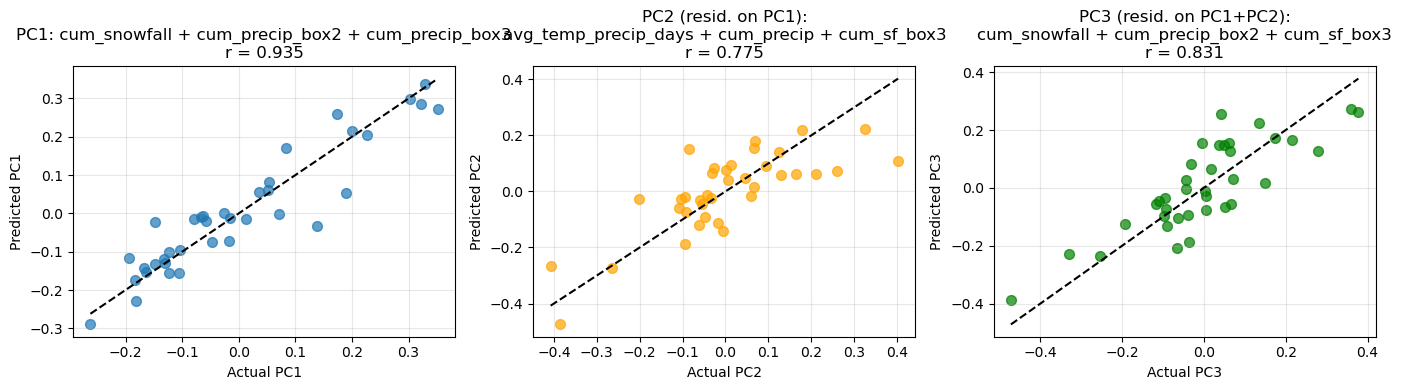


Variance explained:
  PC1: 87.5%
  PC2: 60.1%
  PC3: 69.1%


In [121]:
# === Plot Best Models from Exhaustive Search ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# PC1 - use predictions from best_pc1
ax = axes[0]
ax.scatter(y_pc1, best_pc1['predictions'], alpha=0.7, s=50)
ax.plot([y_pc1.min(), y_pc1.max()], [y_pc1.min(), y_pc1.max()], 'k--', lw=1.5)
ax.set_xlabel('Actual PC1')
ax.set_ylabel('Predicted PC1')
pc1_label = ' + '.join(best_pc1['features'])
ax.set_title(f'PC1: {pc1_label}\nr = {best_pc1["r"]:.3f}')
ax.grid(True, alpha=0.3)

# PC2 - use predictions from best_pc2
ax = axes[1]
ax.scatter(y_pc2, best_pc2['predictions'], alpha=0.7, s=50, color='orange')
ax.plot([y_pc2.min(), y_pc2.max()], [y_pc2.min(), y_pc2.max()], 'k--', lw=1.5)
ax.set_xlabel('Actual PC2')
ax.set_ylabel('Predicted PC2')
pc2_label = ' + '.join(best_pc2['features'])
ax.set_title(f'PC2 (resid. on PC1):\n{pc2_label}\nr = {best_pc2["r"]:.3f}')
ax.grid(True, alpha=0.3)

# PC3 - use predictions from best_pc3
ax = axes[2]
ax.scatter(y_pc3, best_pc3['predictions'], alpha=0.7, s=50, color='green')
ax.plot([y_pc3.min(), y_pc3.max()], [y_pc3.min(), y_pc3.max()], 'k--', lw=1.5)
ax.set_xlabel('Actual PC3')
ax.set_ylabel('Predicted PC3')
pc3_label = ' + '.join(best_pc3['features'])
ax.set_title(f'PC3 (resid. on PC1+PC2):\n{pc3_label}\nr = {best_pc3["r"]:.3f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/pc_predictions_best_models.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVariance explained:")
print(f"  PC1: {best_pc1['r']**2 * 100:.1f}%")
print(f"  PC2: {best_pc2['r']**2 * 100:.1f}%")
print(f"  PC3: {best_pc3['r']**2 * 100:.1f}%")

In [120]:
# === ADDITIONAL TESTS: Derived Features & Interactions ===
# Create new derived features that might capture physical processes better

print("=" * 60)
print("BONUS: Testing Derived Features and Interactions")
print("=" * 60)

# Add derived features to df_valid for extended testing
df_valid_extended = df_valid.copy()

# Snow fraction (snowfall / total precip) - indicates temperature during precip
df_valid_extended['snow_frac'] = df_valid_extended['cum_snowfall'] / df_valid_extended['cum_precip']
df_valid_extended['snow_frac_box1'] = df_valid_extended['cum_sf_box1'] / df_valid_extended['cum_precip_box1']
df_valid_extended['snow_frac_box3'] = df_valid_extended['cum_sf_box3'] / df_valid_extended['cum_precip_box3']

# Box2 (central Sierra) differences - captures mid-range dynamics
if 'mean_t700_box2' in df_valid.columns:
    df_valid_extended['box1_box2_t700_diff'] = df_valid_extended['mean_t700_box1'] - df_valid_extended['mean_t700_box2']
    df_valid_extended['box2_box3_t700_diff'] = df_valid_extended['mean_t700_box2'] - df_valid_extended['mean_t700_box3']

df_valid_extended['box1_box2_sf'] = df_valid_extended['cum_sf_box1'] / df_valid_extended['cum_sf_box2']
df_valid_extended['box2_box3_sf'] = df_valid_extended['cum_sf_box2'] / df_valid_extended['cum_sf_box3']

# Temperature spread (difference between temp on precip vs non-precip days)
df_valid_extended['temp_spread'] = df_valid_extended['avg_temp_precip_days'] - df_valid_extended['avg_temp_no_precip_days']

# Combined thermal index
if 'avg_t700' in df_valid.columns:
    df_valid_extended['thermal_gradient'] = df_valid_extended['avg_temp'] - df_valid_extended['avg_t700']

new_features = ['snow_frac', 'snow_frac_box1', 'snow_frac_box3', 'temp_spread']
if 'box1_box2_t700_diff' in df_valid_extended.columns:
    new_features.extend(['box1_box2_t700_diff', 'box2_box3_t700_diff'])
new_features.extend(['box1_box2_sf', 'box2_box3_sf'])
if 'thermal_gradient' in df_valid_extended.columns:
    new_features.append('thermal_gradient')

print(f"\nNew derived features: {new_features}")

# Update residualization arrays for extended df
y_pc1_ext = df_valid_extended['PC1'].values
y_pc2_ext = df_valid_extended['PC2'].values
y_pc3_ext = df_valid_extended['PC3'].values
residualize_on_pc1_ext = df_valid_extended[['PC1']].values
residualize_on_pc12_ext = df_valid_extended[['PC1', 'PC2']].values

# Test new features for each PC
print("\n--- PC2 with new features (residualized on PC1) ---")
extended_pc2_candidates = temp_features + t700_features + new_features + ratio_diff_features

extended_pc2_results = []
for n_feat in range(1, 3):
    for combo in combinations(extended_pc2_candidates, n_feat):
        try:
            X = df_valid_extended[list(combo)].values.astype(float)
            if np.isnan(X).any() or np.isinf(X).any():
                continue
            pred, r, p = loocv_hierarchical_predict(X, y_pc2_ext, residualize_from=residualize_on_pc1_ext)
            extended_pc2_results.append({'features': combo, 'r': r, 'p': p})
        except:
            continue

extended_pc2_results = sorted(extended_pc2_results, key=lambda x: x['r'], reverse=True)
print("Top 10 PC2 with derived features:")
for i, res in enumerate(extended_pc2_results[:10]):
    print(f"  {i+1:2d}. r={res['r']:.4f} | {' + '.join(res['features'])}")

print("\n--- PC3 with new features (residualized on PC1+PC2) ---")
extended_pc3_candidates = box_features + new_features + ratio_diff_features

extended_pc3_results = []
for n_feat in range(1, 4):
    for combo in combinations(extended_pc3_candidates, n_feat):
        try:
            X = df_valid_extended[list(combo)].values.astype(float)
            if np.isnan(X).any() or np.isinf(X).any():
                continue
            pred, r, p = loocv_hierarchical_predict(X, y_pc3_ext, residualize_from=residualize_on_pc12_ext)
            extended_pc3_results.append({'features': combo, 'r': r, 'p': p})
        except:
            continue

extended_pc3_results = sorted(extended_pc3_results, key=lambda x: x['r'], reverse=True)
print("Top 10 PC3 with derived features:")
for i, res in enumerate(extended_pc3_results[:10]):
    print(f"  {i+1:2d}. r={res['r']:.4f} | {' + '.join(res['features'])}")

BONUS: Testing Derived Features and Interactions

New derived features: ['snow_frac', 'snow_frac_box1', 'snow_frac_box3', 'temp_spread', 'box1_box2_t700_diff', 'box2_box3_t700_diff', 'box1_box2_sf', 'box2_box3_sf', 'thermal_gradient']

--- PC2 with new features (residualized on PC1) ---
Top 10 PC2 with derived features:
   1. r=0.3549 | avg_temp_no_precip_days + box1_box3_precip_ratio
   2. r=0.3335 | box1_box2_sf + box1_box3_precip_ratio
   3. r=0.3323 | box1_box3_precip_ratio
   4. r=0.3262 | box1_box3_precip_ratio + box1_box3_t700_precip_diff
   5. r=0.3217 | snow_frac_box3 + box1_box3_precip_ratio
   6. r=0.3190 | snow_frac_box1 + box2_box3_t700_diff
   7. r=0.3184 | temp_spread + box1_box3_precip_ratio
   8. r=0.3158 | snow_frac_box1 + box1_box3_t700_diff
   9. r=0.3156 | box2_box3_t700_diff + box1_box3_precip_ratio
  10. r=0.3149 | mean_t700_precip_box3 + box1_box3_precip_ratio

--- PC3 with new features (residualized on PC1+PC2) ---
Top 10 PC3 with derived features:
   1. r=0.77

### for SWE:

In [97]:
atl06sr_sampled

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,wy_2012,wy_2013,wy_2014,wy_2015,wy_2016,wy_2017,wy_2018,wy_2019,wy_2020,wy_2021
time_ns,,,,,,,,,,,,,,,,,,,,,
2020-04-03 09:56:50.216293120,0.0,1.0,0,2724.638922,6,19.139991,20,124,7.977598,343597383680,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-03 09:56:50.213481984,0.0,1.0,0,2729.237111,6,10.196173,20,195,4.501707,343597383680,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-03 09:56:50.210669056,0.0,1.0,0,2732.365336,6,8.563021,20,207,4.169113,343597383680,...,0.714943,0.030618,0.246942,0.0,0.566058,1.367173,0.574845,2.053229,0.262605,0.227323
2020-04-03 09:56:50.207858432,0.0,1.0,0,2735.017246,6,8.106508,20,179,3.258819,343597383680,...,0.725757,0.069519,0.254864,0.0,0.596826,1.399594,0.581777,2.089458,0.297033,0.241020
2020-04-03 09:56:49.868930304,0.0,1.0,0,2737.584940,6,15.951931,10,10,8.810060,343597383680,...,0.603902,0.057165,0.228024,0.0,0.355843,1.334511,0.508492,2.032946,0.167695,0.176224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-13 16:10:11.038789632,0.0,1.0,0,2041.840791,6,7.665582,40,25,3.000000,184683593728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-13 16:10:11.035980288,0.0,1.0,0,2042.222022,6,7.195669,40,54,3.000000,184683593728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-13 16:10:11.033174016,0.0,1.0,0,2042.015361,6,7.068889,40,67,3.000000,184683593728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


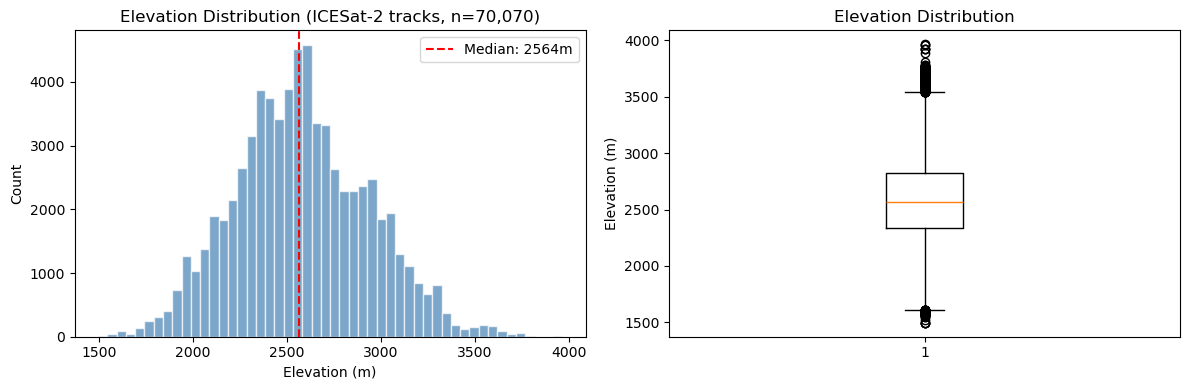

ICESat-2 3DEP Elevation Statistics:
  Count:  70,070
  Min:    1496 m
  Max:    3966 m
  Median: 2564 m
  Mean:   2579 m


In [98]:
# === Elevation Distribution from ICESat-2 3DEP sampling ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

elev_is2 = atl06sr_sampled['3dep.value'].dropna()

# Histogram
ax = axes[0]
ax.hist(elev_is2, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Count')
ax.set_title(f'Elevation Distribution (ICESat-2 tracks, n={len(elev_is2):,})')
ax.axvline(elev_is2.median(), color='red', linestyle='--', label=f'Median: {elev_is2.median():.0f}m')
ax.legend()

# Box plot
ax = axes[1]
ax.boxplot(elev_is2, vert=True)
ax.set_ylabel('Elevation (m)')
ax.set_title('Elevation Distribution')

plt.tight_layout()
plt.show()

print(f"ICESat-2 3DEP Elevation Statistics:")
print(f"  Count:  {len(elev_is2):,}")
print(f"  Min:    {elev_is2.min():.0f} m")
print(f"  Max:    {elev_is2.max():.0f} m")
print(f"  Median: {elev_is2.median():.0f} m")
print(f"  Mean:   {elev_is2.mean():.0f} m")

Unique years: [np.int32(2020), np.int32(2021)]
Counts by year: year
2020    28063
2021    41997
Name: count, dtype: int64


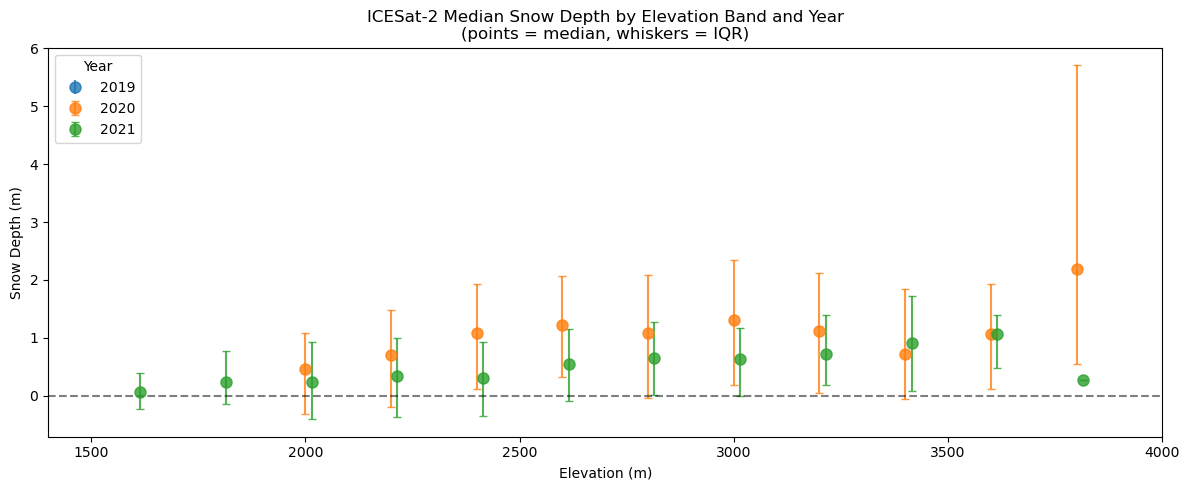


Median snow depth by elevation and year:
year       2020  2021
elev_bin             
1500-1700   NaN  0.06
1700-1900   NaN  0.24
1900-2100  0.46  0.24
2100-2300  0.71  0.34
2300-2500  1.09  0.31
2500-2700  1.22  0.54
2700-2900  1.09  0.65
2900-3100  1.31  0.64
3100-3300  1.12  0.72
3300-3500  0.72  0.91
3500-3700  1.07  1.07
3700-3900  2.19  0.28


In [102]:
# Plot median snow depth (icesat2_3dep_dif) by elevation band and YEAR
elev_is2 = atl06sr_sampled['3dep.value']
snow_depth = atl06sr_sampled['icesat2_3dep_dif']

# Extract year from index (time_ns)
years_is2 = pd.to_datetime(atl06sr_sampled.index).year

# Create elevation bins
elev_bins_is2 = np.arange(1500, 4100, 200)  # 200m bins from 1500-4000m
elev_labels_is2 = [f'{b}-{b+200}' for b in elev_bins_is2[:-1]]
elev_mids_is2 = [(b + 100) for b in elev_bins_is2[:-1]]

# Bin the data
elev_binned_is2 = pd.cut(elev_is2, bins=elev_bins_is2, labels=elev_labels_is2)

# Build DataFrame with year info
snow_by_elev = pd.DataFrame({
    'elev_bin': elev_binned_is2.values,
    'elev_mid': pd.cut(elev_is2, bins=elev_bins_is2, labels=elev_mids_is2).values,
    'snow_depth': snow_depth.values,
    'year': years_is2
}).dropna()
snow_by_elev['elev_mid'] = snow_by_elev['elev_mid'].astype(float)

print(f"Unique years: {sorted(snow_by_elev['year'].unique())}")
print(f"Counts by year: {snow_by_elev['year'].value_counts().sort_index()}")

# Calculate statistics by elevation bin AND year
elev_year_stats = snow_by_elev.groupby(['elev_bin', 'elev_mid', 'year']).agg(
    median=('snow_depth', 'median'),
    q25=('snow_depth', lambda x: x.quantile(0.25)),
    q75=('snow_depth', lambda x: x.quantile(0.75)),
    count=('snow_depth', 'count')
).reset_index()

# Plot with points by year
fig, ax = plt.subplots(figsize=(12, 5))

year_colors = {2019: '#1f77b4', 2020: '#ff7f0e', 2021: '#2ca02c'}
year_offsets = {2019: -15, 2020: 0, 2021: 15}  # Slight x-offset to avoid overlap

for yr in [2019, 2020, 2021]:
    subset = elev_year_stats[elev_year_stats['year'] == yr]
    x_pos = subset['elev_mid'].values + year_offsets[yr]
    
    # Plot points with error bars (IQR)
    ax.errorbar(x_pos, subset['median'], 
                yerr=[subset['median'] - subset['q25'], 
                      subset['q75'] - subset['median']],
                fmt='o', color=year_colors[yr], label=str(yr),
                markersize=8, capsize=3, alpha=0.8)

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Snow Depth (m)')
ax.set_title('ICESat-2 Median Snow Depth by Elevation Band and Year\n(points = median, whiskers = IQR)')
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.legend(title='Year')
ax.set_xlim(1400, 4000)

plt.tight_layout()
plt.show()

# Print summary
print("\nMedian snow depth by elevation and year:")
pivot = elev_year_stats.pivot_table(index='elev_bin', columns='year', values='median', aggfunc='first')
print(pivot.round(2).to_string())

In [107]:
atl06sr_simulated_points

,segment_watermask,segment_snowcover,pflags,3dep.value,region,3dep.deriv.slope,gt,n_fit_photons,w_surface_window_final,3dep.fileid,...,sim_is2_2012,sim_is2_2013,sim_is2_2014,sim_is2_2015,sim_is2_2016,sim_is2_2017,sim_is2_2018,sim_is2_2019,sim_is2_2020,sim_is2_2021
time_ns,,,,,,,,,,,,,,,,,,,,,
2020-04-03 09:56:50.216293120,0.0,1.0,0,2724.638922,6,19.139991,20,124,7.977598,343597383680,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-03 09:56:50.213481984,0.0,1.0,0,2729.237111,6,10.196173,20,195,4.501707,343597383680,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-03 09:56:50.210669056,0.0,1.0,0,2732.365336,6,8.563021,20,207,4.169113,343597383680,...,1.134176,0.578537,0.796688,0.004544,1.177641,2.109563,-0.868280,2.953200,-1.938787,0.187249
2020-04-03 09:56:50.207858432,0.0,1.0,0,2735.017246,6,8.106508,20,179,3.258819,343597383680,...,1.281633,1.448481,-0.349534,1.471254,1.191402,-0.945990,1.044112,-2.652750,0.290355,-0.280027
2020-04-03 09:56:49.868930304,0.0,1.0,0,2737.584940,6,15.951931,10,10,8.810060,343597383680,...,0.221225,0.474898,4.172699,0.111234,-0.245867,3.328712,0.985391,2.481316,1.115841,0.686163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-13 16:10:11.038789632,0.0,1.0,0,2041.840791,6,7.665582,40,25,3.000000,184683593728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-13 16:10:11.035980288,0.0,1.0,0,2042.222022,6,7.195669,40,54,3.000000,184683593728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-13 16:10:11.033174016,0.0,1.0,0,2042.015361,6,7.068889,40,67,3.000000,184683593728,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:
atl06sr_simulated

,adjusted_date,icesat2_median,wy_1985,wy_1986,wy_1987,wy_1988,wy_1989,wy_1990,wy_1991,wy_1992,...,sim_is2_2012,sim_is2_2013,sim_is2_2014,sim_is2_2015,sim_is2_2016,sim_is2_2017,sim_is2_2018,sim_is2_2019,sim_is2_2020,sim_is2_2021
0,2021-04-01,1.312578,1.924723,2.634298,1.223753,0.644560,1.618922,0.600869,1.817257,1.509542,...,1.028335,0.833647,0.801787,-0.094911,1.743880,2.999090,0.855430,2.757786,0.730929,1.119609
1,2021-04-03,0.426210,1.653203,2.350982,0.935556,0.424587,1.058059,0.478602,1.831300,1.171965,...,0.891145,0.824049,0.531173,0.239726,1.058599,2.108835,0.950289,2.782643,0.685084,0.856302
2,2021-04-05,1.251126,1.407565,2.180916,0.796316,0.383399,1.414029,0.802161,1.655303,0.791767,...,0.707007,0.741373,0.800789,0.006215,1.528718,3.082866,0.923400,3.014164,1.442381,0.584736
3,2021-04-07,0.365464,1.426223,2.833164,0.958263,0.400653,0.977605,0.393353,1.611680,1.234875,...,1.042871,0.249765,0.639097,0.310587,0.628908,2.488251,0.951931,2.615324,0.905177,0.278918
4,2021-04-11,0.529329,0.976529,1.977536,0.543480,0.165229,0.653596,0.386917,1.293431,0.507595,...,0.687472,0.601237,0.733438,-0.016076,1.682751,2.701019,0.354254,2.125143,1.341574,0.528469
5,2021-04-13,0.485709,0.834045,1.132305,0.321477,0.176122,0.649324,0.313260,1.183276,0.458485,...,1.271118,0.353876,-0.025941,0.185694,0.602891,1.935960,0.277044,1.929566,1.380991,0.046204


## Simulated ICESat-2: Elevational Snow Depth Analysis
Calculate median snow depth by elevation band for each historical year, and characterize the elevational gradient as a potential predictor for PC weight regressions.

In [108]:
# Get simulated ICESat-2 columns and elevation data
sim_cols = [col for col in atl06sr_simulated_points.columns if col.startswith('sim_is2_')]
years_sim = [int(col.replace('sim_is2_', '')) for col in sim_cols]

# Access elevation from 3DEP column
elev_col = '3dep.value'
print(f"Simulated years: {years_sim[:5]}...{years_sim[-3:]}")
print(f"Number of points: {len(atl06sr_simulated_points):,}")
print(f"Elevation range: {atl06sr_simulated_points[elev_col].min():.0f} - {atl06sr_simulated_points[elev_col].max():.0f} m")

# Create elevation bins
elev_bins_sim = np.arange(1500, 4100, 250)  # 250m bins
elev_mids_sim = (elev_bins_sim[:-1] + elev_bins_sim[1:]) / 2
elev_labels_sim = [f'{b}-{b+250}' for b in elev_bins_sim[:-1]]

# Bin elevations
atl06sr_simulated_points['elev_bin'] = pd.cut(
    atl06sr_simulated_points[elev_col], 
    bins=elev_bins_sim, 
    labels=elev_labels_sim
)
atl06sr_simulated_points['elev_mid'] = pd.cut(
    atl06sr_simulated_points[elev_col], 
    bins=elev_bins_sim, 
    labels=elev_mids_sim
).astype(float)

print(f"\nElevation bins: {elev_labels_sim}")
print(f"Points per bin:\n{atl06sr_simulated_points['elev_bin'].value_counts().sort_index()}")

Simulated years: [1985, 1986, 1987, 1988, 1989]...[2019, 2020, 2021]
Number of points: 70,070
Elevation range: 1496 - 3966 m

Elevation bins: ['1500-1750', '1750-2000', '2000-2250', '2250-2500', '2500-2750', '2750-3000', '3000-3250', '3250-3500', '3500-3750', '3750-4000']
Points per bin:
elev_bin
1500-1750      324
1750-2000     3154
2000-2250     8669
2250-2500    17377
2500-2750    19620
2750-3000    11813
3000-3250     6528
3250-3500     1973
3500-3750      580
3750-4000       28
Name: count, dtype: int64


In [109]:
# Calculate median snow depth by elevation band for each simulated year
median_by_elev_year = []

for year in years_sim:
    col = f'sim_is2_{year}'
    
    # Group by elevation bin and calculate median
    medians = atl06sr_simulated_points.groupby('elev_bin')[col].median()
    
    for elev_bin, median_sd in medians.items():
        median_by_elev_year.append({
            'year': year,
            'elev_bin': elev_bin,
            'elev_mid': elev_mids_sim[elev_labels_sim.index(elev_bin)],
            'median_sd': median_sd
        })

median_elev_df = pd.DataFrame(median_by_elev_year)
print(f"Median snow depth by elevation band: {median_elev_df.shape}")

# Pivot to show years as rows, elevation bins as columns
pivot_medians = median_elev_df.pivot(index='year', columns='elev_bin', values='median_sd')
print("\nMedian Snow Depth (m) by Elevation Band - sample years:")
print(pivot_medians.loc[[1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]].round(2).to_string())

Median snow depth by elevation band: (370, 4)

Median Snow Depth (m) by Elevation Band - sample years:
elev_bin  1500-1750  1750-2000  2000-2250  2250-2500  2500-2750  2750-3000  3000-3250  3250-3500  3500-3750  3750-4000
year                                                                                                                  
1985           0.11       0.48       0.54       0.79       1.35       1.66       2.00       2.33       2.83       2.77
1990          -0.07       0.20       0.19       0.35       0.56       0.66       0.87       0.93       1.14       1.13
1995           1.17       1.77       1.79       2.17       2.65       2.83       3.36       3.48       4.07       3.93
2000           0.18       0.52       0.75       0.91       1.29       1.56       1.70       1.60       2.04       1.94
2005           0.92       1.50       1.62       1.84       2.20       2.44       2.80       2.78       3.29       4.19
2010           1.03       1.42       1.40       1.41       1.65 

In [110]:
# Characterize the elevational gradient of snow depth for each year
# Fit linear regression: snow_depth = intercept + slope * elevation

from scipy.stats import linregress

elev_gradient_stats = []

for year in years_sim:
    # Get data for this year
    year_data = median_elev_df[median_elev_df['year'] == year].dropna()
    
    if len(year_data) >= 3:  # Need at least 3 points for regression
        elev = year_data['elev_mid'].values
        sd = year_data['median_sd'].values
        
        # Linear regression
        result = linregress(elev, sd)
        
        elev_gradient_stats.append({
            'year': year,
            'slope': result.slope,           # m SD per m elevation
            'slope_per_km': result.slope * 1000,  # m SD per km elevation
            'intercept': result.intercept,
            'r_squared': result.rvalue ** 2,
            'p_value': result.pvalue,
            'mean_sd': sd.mean(),
            'sd_at_2000m': result.intercept + result.slope * 2000,
            'sd_at_3000m': result.intercept + result.slope * 3000,
            'sd_at_3500m': result.intercept + result.slope * 3500,
        })

elev_gradient_df = pd.DataFrame(elev_gradient_stats)
elev_gradient_df = elev_gradient_df.sort_values('year')

print("Elevational Gradient Statistics:")
print(f"  Years analyzed: {len(elev_gradient_df)}")
print(f"\nGradient (slope) summary:")
print(f"  Mean slope: {elev_gradient_df['slope_per_km'].mean():.3f} m SD per km elevation")
print(f"  Std slope:  {elev_gradient_df['slope_per_km'].std():.3f} m SD per km elevation")
print(f"  Range:      {elev_gradient_df['slope_per_km'].min():.3f} to {elev_gradient_df['slope_per_km'].max():.3f}")
print(f"\nMean R²: {elev_gradient_df['r_squared'].mean():.3f}")

elev_gradient_df[['year', 'slope_per_km', 'intercept', 'r_squared', 'mean_sd', 'sd_at_2000m', 'sd_at_3000m']].head(10)

Elevational Gradient Statistics:
  Years analyzed: 37

Gradient (slope) summary:
  Mean slope: 0.998 m SD per km elevation
  Std slope:  0.427 m SD per km elevation
  Range:      0.262 to 2.109

Mean R²: 0.922


,year,slope_per_km,intercept,r_squared,mean_sd,sd_at_2000m,sd_at_3000m
0,1985,1.292007,-2.067871,0.981453,1.485149,0.516143,1.808151
1,1986,2.109245,-3.357039,0.986334,2.443386,0.861452,2.970697
2,1987,1.029894,-1.831687,0.960222,1.000521,0.228100,1.257994
3,1988,0.679618,-1.300118,0.954668,0.568831,0.059118,0.738735
4,1989,0.994412,-1.615965,0.984186,1.118668,0.372859,1.367271
5,1990,0.549176,-0.913633,0.979169,0.596599,0.184718,0.733893
6,1991,0.838315,-0.704287,0.992648,1.601078,0.972342,1.810657
7,1992,1.466733,-2.710192,0.913015,1.323324,0.223274,1.690007
8,1993,1.838857,-1.986233,0.991506,3.070625,1.691482,3.530339
9,1994,0.661677,-0.994467,0.888937,0.825144,0.328886,0.990563


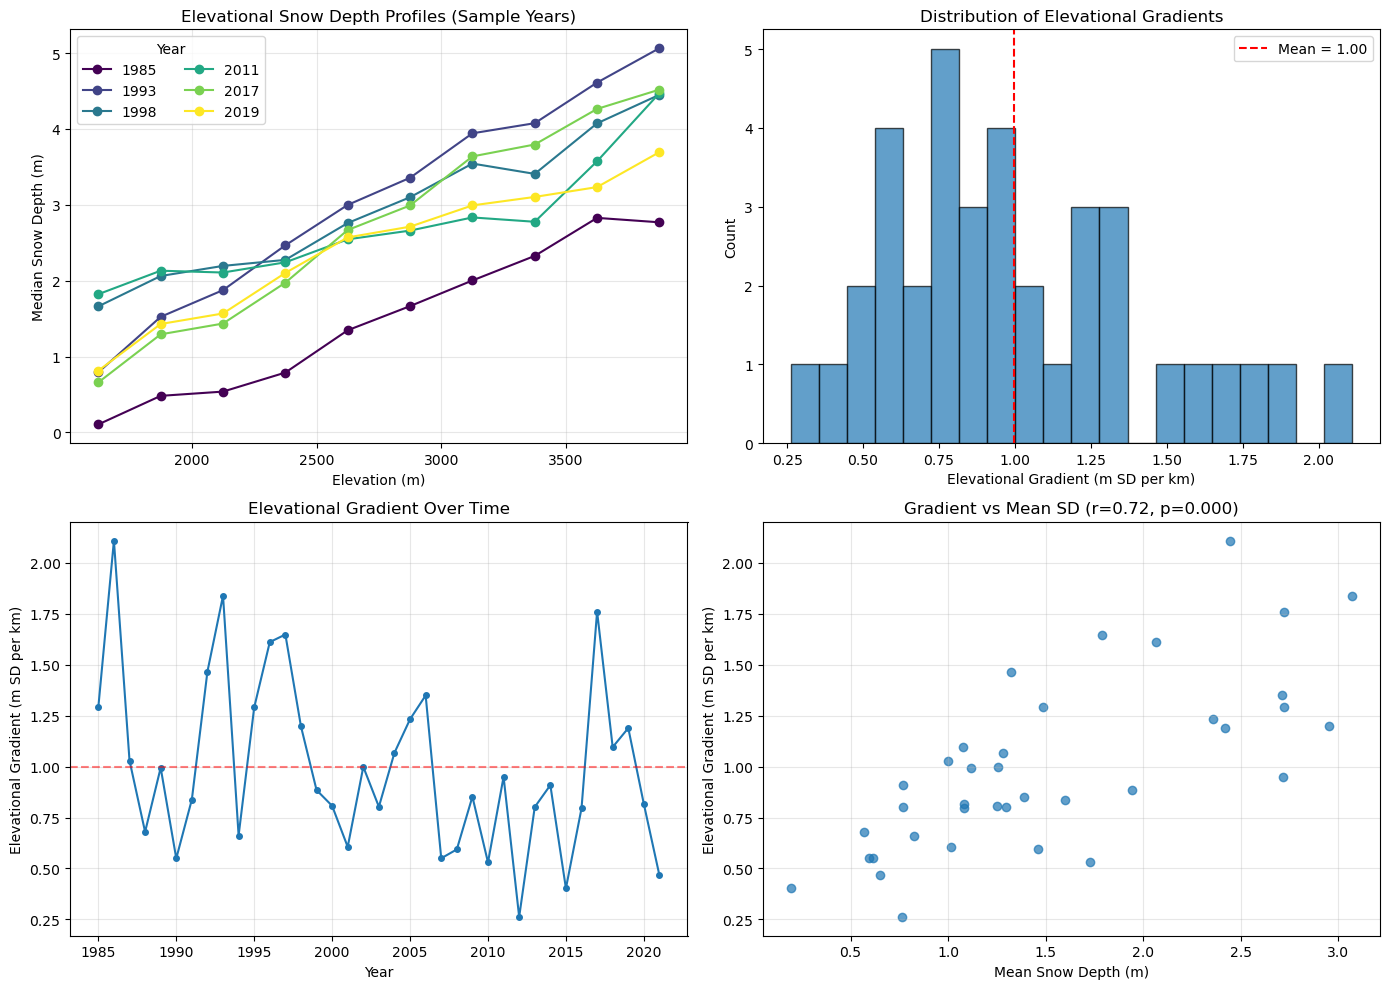

In [111]:
# Visualize the elevational gradients
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Plot median snow depth vs elevation for sample years
ax = axes[0, 0]
sample_years_plot = [1985, 1993, 1998, 2011, 2017, 2019]
colors_sample = plt.cm.viridis(np.linspace(0, 1, len(sample_years_plot)))

for i, yr in enumerate(sample_years_plot):
    year_data = median_elev_df[median_elev_df['year'] == yr]
    ax.plot(year_data['elev_mid'], year_data['median_sd'], 'o-', 
            color=colors_sample[i], label=str(yr), markersize=6)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Median Snow Depth (m)')
ax.set_title('Elevational Snow Depth Profiles (Sample Years)')
ax.legend(title='Year', ncol=2)
ax.grid(alpha=0.3)

# 2. Distribution of slopes
ax = axes[0, 1]
ax.hist(elev_gradient_df['slope_per_km'], bins=20, edgecolor='black', alpha=0.7)
ax.axvline(elev_gradient_df['slope_per_km'].mean(), color='red', linestyle='--', 
           label=f'Mean = {elev_gradient_df["slope_per_km"].mean():.2f}')
ax.set_xlabel('Elevational Gradient (m SD per km)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Elevational Gradients')
ax.legend()

# 3. Time series of slope
ax = axes[1, 0]
ax.plot(elev_gradient_df['year'], elev_gradient_df['slope_per_km'], 'o-', markersize=4)
ax.axhline(elev_gradient_df['slope_per_km'].mean(), color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Elevational Gradient (m SD per km)')
ax.set_title('Elevational Gradient Over Time')
ax.grid(alpha=0.3)

# 4. Gradient vs mean snow depth
ax = axes[1, 1]
ax.scatter(elev_gradient_df['mean_sd'], elev_gradient_df['slope_per_km'], alpha=0.7)
# Add correlation
r_grad, p_grad = pearsonr(elev_gradient_df['mean_sd'], elev_gradient_df['slope_per_km'])
ax.set_xlabel('Mean Snow Depth (m)')
ax.set_ylabel('Elevational Gradient (m SD per km)')
ax.set_title(f'Gradient vs Mean SD (r={r_grad:.2f}, p={p_grad:.3f})')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Merged data: 37 years

Correlation between Elevational Gradient and PC Weights:
  PC1: r=0.667, p=0.0000
  PC2: r=0.574, p=0.0002
  PC3: r=0.293, p=0.0780


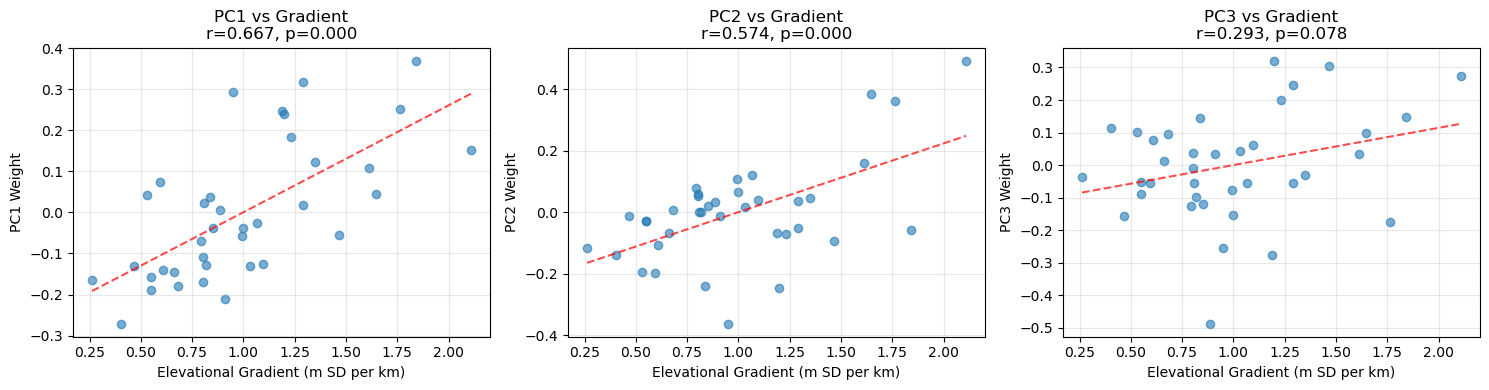

In [112]:
# Explore correlation between elevational gradient and PC weights
# Merge gradient data with PC weights

# Get PC weights (V matrix columns are temporal weights for each year)
pc_weights_df = pd.DataFrame({
    'year': all_years,
    'pc1_weight': V_anom_swe[0, :],
    'pc2_weight': V_anom_swe[1, :],
    'pc3_weight': V_anom_swe[2, :],
})

# Merge with gradient data
gradient_pc_df = elev_gradient_df.merge(pc_weights_df, on='year', how='inner')

print(f"Merged data: {len(gradient_pc_df)} years")
print("\nCorrelation between Elevational Gradient and PC Weights:")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (pc_col, pc_name) in enumerate([('pc1_weight', 'PC1'), ('pc2_weight', 'PC2'), ('pc3_weight', 'PC3')]):
    ax = axes[i]
    r, p = pearsonr(gradient_pc_df['slope_per_km'], gradient_pc_df[pc_col])
    
    ax.scatter(gradient_pc_df['slope_per_km'], gradient_pc_df[pc_col], alpha=0.6)
    
    # Add regression line
    z = np.polyfit(gradient_pc_df['slope_per_km'], gradient_pc_df[pc_col], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(gradient_pc_df['slope_per_km'].min(), gradient_pc_df['slope_per_km'].max(), 100)
    ax.plot(x_line, p_line(x_line), 'r--', alpha=0.7)
    
    ax.set_xlabel('Elevational Gradient (m SD per km)')
    ax.set_ylabel(f'{pc_name} Weight')
    ax.set_title(f'{pc_name} vs Gradient\nr={r:.3f}, p={p:.3f}')
    ax.grid(alpha=0.3)
    
    print(f"  {pc_name}: r={r:.3f}, p={p:.4f}")

plt.tight_layout()
plt.show()

In [113]:
# Create additional derived metrics that might be useful predictors
# These capture different aspects of the elevation-snow depth relationship

gradient_pc_df['sd_ratio_high_low'] = gradient_pc_df['sd_at_3000m'] / gradient_pc_df['sd_at_2000m'].replace(0, np.nan)
gradient_pc_df['sd_diff_high_low'] = gradient_pc_df['sd_at_3000m'] - gradient_pc_df['sd_at_2000m']

# Correlation matrix for all potential predictors
predictor_cols = ['slope_per_km', 'intercept', 'mean_sd', 'sd_at_2000m', 'sd_at_3000m', 
                  'sd_ratio_high_low', 'sd_diff_high_low']
target_cols = ['pc1_weight', 'pc2_weight', 'pc3_weight']

print("Correlation of Elevation-Derived Metrics with PC Weights:")
print("=" * 70)

for pred in predictor_cols:
    valid_mask = ~gradient_pc_df[pred].isna()
    print(f"\n{pred}:")
    for target in target_cols:
        r, p = pearsonr(gradient_pc_df.loc[valid_mask, pred], 
                        gradient_pc_df.loc[valid_mask, target])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {target}: r={r:+.3f} {sig}")

# Summary table
print("\n\nSummary: Best Predictors for Each PC")
print("=" * 50)
for target in target_cols:
    best_r = 0
    best_pred = ""
    for pred in predictor_cols:
        valid_mask = ~gradient_pc_df[pred].isna()
        r, _ = pearsonr(gradient_pc_df.loc[valid_mask, pred], 
                        gradient_pc_df.loc[valid_mask, target])
        if abs(r) > abs(best_r):
            best_r = r
            best_pred = pred
    print(f"  {target}: {best_pred} (r={best_r:+.3f})")

Correlation of Elevation-Derived Metrics with PC Weights:

slope_per_km:
  pc1_weight: r=+0.667 ***
  pc2_weight: r=+0.574 ***
  pc3_weight: r=+0.293 

intercept:
  pc1_weight: r=-0.038 
  pc2_weight: r=-0.767 ***
  pc3_weight: r=-0.389 *

mean_sd:
  pc1_weight: r=+0.963 ***
  pc2_weight: r=+0.061 
  pc3_weight: r=+0.034 

sd_at_2000m:
  pc1_weight: r=+0.908 ***
  pc2_weight: r=-0.229 
  pc3_weight: r=-0.113 

sd_at_3000m:
  pc1_weight: r=+0.956 ***
  pc2_weight: r=+0.126 
  pc3_weight: r=+0.068 

sd_ratio_high_low:
  pc1_weight: r=-0.341 *
  pc2_weight: r=+0.194 
  pc3_weight: r=+0.202 

sd_diff_high_low:
  pc1_weight: r=+0.667 ***
  pc2_weight: r=+0.574 ***
  pc3_weight: r=+0.293 


Summary: Best Predictors for Each PC
  pc1_weight: mean_sd (r=+0.963)
  pc2_weight: intercept (r=-0.767)
  pc3_weight: intercept (r=-0.389)


In [114]:
# Save the elevational gradient data with PC weights for future use
gradient_pc_df.to_csv('../data/results/simulated_is2_elevation_gradients.csv', index=False)
print(f"Saved gradient data to ../data/results/simulated_is2_elevation_gradients.csv")

# Display final dataframe
display_cols = ['year', 'slope_per_km', 'mean_sd', 'sd_at_2000m', 'sd_at_3000m', 
                'r_squared', 'pc1_weight', 'pc2_weight', 'pc3_weight']
gradient_pc_df[display_cols].round(3)

Saved gradient data to ../data/results/simulated_is2_elevation_gradients.csv


,year,slope_per_km,mean_sd,sd_at_2000m,sd_at_3000m,r_squared,pc1_weight,pc2_weight,pc3_weight
0,1985,1.292,1.485,0.516,1.808,0.981,0.019,0.038,0.247
1,1986,2.109,2.443,0.861,2.971,0.986,0.151,0.493,0.275
2,1987,1.030,1.001,0.228,1.258,0.960,-0.131,0.018,0.044
3,1988,0.680,0.569,0.059,0.739,0.955,-0.180,0.009,0.096
4,1989,0.994,1.119,0.373,1.367,0.984,-0.058,0.108,-0.078
5,1990,0.549,0.597,0.185,0.734,0.979,-0.157,-0.029,-0.051
6,1991,0.838,1.601,0.972,1.811,0.993,0.039,-0.241,0.145
7,1992,1.467,1.323,0.223,1.690,0.913,-0.054,-0.094,0.305
8,1993,1.839,3.071,1.691,3.530,0.992,0.369,-0.058,0.147
9,1994,0.662,0.825,0.329,0.991,0.889,-0.145,-0.067,0.014


## Add Elevational Gradient Features to Met Data for Hierarchical Regression
Merge the simulated ICESat-2 derived features into the met dataframe for inclusion in the exhaustive feature search.

In [119]:
# Merge elevational gradient features into met_df for the exhaustive search
# These come from simulated ICESat-2 data

# Check what columns are available in elev_gradient_df
print("Available columns in elev_gradient_df:")
print(elev_gradient_df.columns.tolist())

# Select ALL gradient features to add (including mean_sd)
available_gradient_features = ['slope_per_km', 'intercept', 'mean_sd', 'sd_at_2000m', 'sd_at_3000m', 'sd_at_3500m', 'r_squared']

# Prepare gradient data for merge
gradient_for_merge = elev_gradient_df[['year'] + available_gradient_features].copy()
gradient_for_merge = gradient_for_merge.rename(columns={
    'year': 'water_year',
    'slope_per_km': 'is2_elev_gradient',
    'intercept': 'is2_intercept',
    'mean_sd': 'is2_mean_sd',
    'sd_at_2000m': 'is2_sd_2000m',
    'sd_at_3000m': 'is2_sd_3000m',
    'sd_at_3500m': 'is2_sd_3500m',
    'r_squared': 'is2_gradient_r2'
})

# Calculate ratio features
gradient_for_merge['is2_sd_ratio_3000_2000'] = gradient_for_merge['is2_sd_3000m'] / (gradient_for_merge['is2_sd_2000m'] + 0.01)
gradient_for_merge['is2_sd_ratio_3500_2000'] = gradient_for_merge['is2_sd_3500m'] / (gradient_for_merge['is2_sd_2000m'] + 0.01)

print(f"\nGradient features prepared: {gradient_for_merge.columns.tolist()}")

Available columns in elev_gradient_df:
['year', 'slope', 'slope_per_km', 'intercept', 'r_squared', 'p_value', 'mean_sd', 'sd_at_2000m', 'sd_at_3000m', 'sd_at_3500m']

Gradient features prepared: ['water_year', 'is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m', 'is2_gradient_r2', 'is2_sd_ratio_3000_2000', 'is2_sd_ratio_3500_2000']


In [121]:
# Calculate North-South difference metrics from simulated ICESat-2
# EOF3 captures the N-S gradient, so this should help predict PC3

# Get latitude from the simulated points geometry
atl06sr_simulated_points['lat'] = atl06sr_simulated_points.geometry.y

# Check column names for elevation
print("Columns in atl06sr_simulated_points:", [c for c in atl06sr_simulated_points.columns if 'elev' in c.lower() or '3dep' in c.lower()])

# Define north and south thresholds
lat_median = atl06sr_simulated_points['lat'].median()
print(f"\nLatitude range: {atl06sr_simulated_points['lat'].min():.2f} to {atl06sr_simulated_points['lat'].max():.2f}")
print(f"Median latitude: {lat_median:.2f}")

# Split at 37.5 (approx boundary between N and S Sierra)
lat_split = 37.5
print(f"Using split latitude: {lat_split}")

# Calculate N-S metrics for each year
ns_metrics = []
sim_cols = [c for c in atl06sr_simulated_points.columns if c.startswith('sim_is2_')]

for col in sim_cols:
    year = int(col.replace('sim_is2_', ''))
    sd_data = atl06sr_simulated_points[['lat', col]].dropna()
    
    # Split into north and south
    north_mask = sd_data['lat'] >= lat_split
    south_mask = sd_data['lat'] < lat_split
    
    # Mean snow depth in each region
    mean_north = sd_data.loc[north_mask, col].mean()
    mean_south = sd_data.loc[south_mask, col].mean()
    
    # Median snow depth in each region
    median_north = sd_data.loc[north_mask, col].median()
    median_south = sd_data.loc[south_mask, col].median()
    
    # N-S difference metrics
    ns_diff = mean_north - mean_south  # positive = more snow in north
    ns_ratio = mean_north / (mean_south + 0.01)  # ratio
    
    ns_metrics.append({
        'year': year,
        'is2_mean_north': mean_north,
        'is2_mean_south': mean_south,
        'is2_ns_diff': ns_diff,
        'is2_ns_ratio': ns_ratio,
        'is2_median_north': median_north,
        'is2_median_south': median_south,
        'is2_ns_diff_median': median_north - median_south
    })

ns_metrics_df = pd.DataFrame(ns_metrics)
print(f"\nN-S metrics calculated for {len(ns_metrics_df)} years")
print(ns_metrics_df.head())

Columns in atl06sr_simulated_points: ['3dep.value', '3dep.deriv.slope', '3dep.fileid', '3dep.deriv.count', '3dep.deriv.aspect', '3dep.time_ns', 'icesat2_3dep_dif', 'elev_bin', 'elev_mid']

Latitude range: 36.29 to 40.27
Median latitude: 37.96
Using split latitude: 37.5

N-S metrics calculated for 37 years
   year  is2_mean_north  is2_mean_south  is2_ns_diff  is2_ns_ratio  \
0  1985        1.120981        1.409162    -0.288181      0.789890   
1  1986        2.003086        2.497244    -0.494158      0.798919   
2  1987        0.715333        0.852154    -0.136820      0.829705   
3  1988        0.262964        0.373180    -0.110216      0.686268   
4  1989        0.995188        0.884423     0.110765      1.112659   

   is2_median_north  is2_median_south  is2_ns_diff_median  
0          1.181340          1.434381           -0.253041  
1          2.063778          2.589731           -0.525953  
2          0.773431          0.915593           -0.142162  
3          0.343511          0.4

In [122]:
# Merge N-S metrics with gradient features
gradient_for_merge = gradient_for_merge.merge(
    ns_metrics_df.rename(columns={'year': 'water_year'}), 
    on='water_year', how='left'
)

print(f"All IS2 features: {gradient_for_merge.columns.tolist()}")

# Now merge with met_df
met_df_extended = met_df.merge(gradient_for_merge, on='water_year', how='left')

print(f"\nExtended met_df shape: {met_df_extended.shape}")
print(f"New IS2 columns: {[c for c in met_df_extended.columns if c.startswith('is2_')]}")

# Check for missing values
missing = met_df_extended['is2_elev_gradient'].isna().sum()
print(f"Missing values: {missing}")

# Show correlation of N-S features with PC weights
# First merge with pc_df
temp_check = met_df_extended.merge(pc_df[['water_year', 'PC1_swe', 'PC2_swe', 'PC3_swe']], on='water_year')
print("\nCorrelations of N-S features with PC weights:")
ns_cols = ['is2_ns_diff', 'is2_ns_ratio', 'is2_mean_north', 'is2_mean_south', 'is2_ns_diff_median']
for col in ns_cols:
    if col in temp_check.columns:
        corr_pc1 = temp_check[col].corr(temp_check['PC1_swe'])
        corr_pc2 = temp_check[col].corr(temp_check['PC2_swe'])
        corr_pc3 = temp_check[col].corr(temp_check['PC3_swe'])
        print(f"  {col}: PC1={corr_pc1:.3f}, PC2={corr_pc2:.3f}, PC3={corr_pc3:.3f}")

All IS2 features: ['water_year', 'is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m', 'is2_gradient_r2', 'is2_sd_ratio_3000_2000', 'is2_sd_ratio_3500_2000', 'is2_mean_north', 'is2_mean_south', 'is2_ns_diff', 'is2_ns_ratio', 'is2_median_north', 'is2_median_south', 'is2_ns_diff_median']

Extended met_df shape: (37, 25)
New IS2 columns: ['is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m', 'is2_gradient_r2', 'is2_sd_ratio_3000_2000', 'is2_sd_ratio_3500_2000', 'is2_mean_north', 'is2_mean_south', 'is2_ns_diff', 'is2_ns_ratio', 'is2_median_north', 'is2_median_south', 'is2_ns_diff_median']
Missing values: 0

Correlations of N-S features with PC weights:
  is2_ns_diff: PC1=-0.282, PC2=0.116, PC3=-0.813
  is2_ns_ratio: PC1=-0.082, PC2=0.145, PC3=-0.641
  is2_mean_north: PC1=0.954, PC2=0.059, PC3=-0.109
  is2_mean_south: PC1=0.958, PC2=0.020, PC3=0.136
  is2_ns_diff_median: PC1=-0.260, PC2=0.127, PC3=

In [123]:
# Run exhaustive search with IS2 gradient features added
# Prepare the df_valid dataframe with gradient features included

# Merge with pc_df (temporal weights) and df_boxes
combined_df_extended = pc_df.merge(met_df_extended, on='water_year', how='inner')\
                           .merge(df_boxes, on='water_year', how='left')

# Drop rows with NaN in key columns
valid_mask = ~combined_df_extended[['cum_snowfall', 'avg_temp', 'is2_elev_gradient', 'PC1_swe', 'PC2_swe', 'PC3_swe']].isna().any(axis=1)
df_valid_extended = combined_df_extended[valid_mask].reset_index(drop=True)

# Define feature groups
precip_features = ['cum_snowfall', 'cum_precip_box3']
temp_features = ['t2m_mean_djfm']
t700_features = ['t700_mean_djfm']
ratio_diff_features = ['precip_ratio', 'precip_diff']

# All IS2 gradient features (elevation-based)
is2_elev_features = ['is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 
                     'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m',
                     'is2_sd_ratio_3000_2000', 'is2_sd_ratio_3500_2000', 'is2_gradient_r2']

# IS2 north-south features (for EOF3/PC3)
is2_ns_features = ['is2_ns_diff', 'is2_ns_ratio', 'is2_mean_north', 'is2_mean_south', 'is2_ns_diff_median']

# Combined IS2 features
is2_features = is2_elev_features + is2_ns_features

print(f"df_valid_extended shape: {df_valid_extended.shape}")
print(f"\nTotal IS2 features to test: {len(is2_features)}")
print(f"  Elevation-based: {is2_elev_features}")
print(f"  North-South: {is2_ns_features}")

print(f"\nCorrelations with PC weights:")
print(f"{'Feature':<25} {'PC1':>8} {'PC2':>8} {'PC3':>8}")
print("-" * 51)
for feat in is2_features:
    if feat in df_valid_extended.columns:
        corr_pc1 = df_valid_extended[feat].corr(df_valid_extended['PC1_swe'])
        corr_pc2 = df_valid_extended[feat].corr(df_valid_extended['PC2_swe'])
        corr_pc3 = df_valid_extended[feat].corr(df_valid_extended['PC3_swe'])
        print(f"  {feat:<23} {corr_pc1:>8.3f} {corr_pc2:>8.3f} {corr_pc3:>8.3f}")

df_valid_extended shape: (37, 48)

Total IS2 features to test: 14
  Elevation-based: ['is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m', 'is2_sd_ratio_3000_2000', 'is2_sd_ratio_3500_2000', 'is2_gradient_r2']
  North-South: ['is2_ns_diff', 'is2_ns_ratio', 'is2_mean_north', 'is2_mean_south', 'is2_ns_diff_median']

Correlations with PC weights:
Feature                        PC1      PC2      PC3
---------------------------------------------------
  is2_elev_gradient          0.667    0.574    0.293
  is2_intercept             -0.038   -0.767   -0.389
  is2_mean_sd                0.963    0.061    0.034
  is2_sd_2000m               0.908   -0.229   -0.113
  is2_sd_3000m               0.956    0.126    0.068
  is2_sd_3500m               0.932    0.223    0.117
  is2_sd_ratio_3000_2000    -0.322    0.216    0.202
  is2_sd_ratio_3500_2000    -0.322    0.216    0.201
  is2_gradient_r2            0.338    0.308    0.208
  is2_ns_diff           

In [125]:
# Exhaustive search for all PCs with IS2 features added
from itertools import combinations
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Check available columns
print("Available columns in df_valid_extended:")
print([c for c in df_valid_extended.columns if not c.startswith('is2_') and c not in ['water_year', 'PC1_swe', 'PC2_swe', 'PC3_swe']])

# Function to evaluate a feature set for a target PC using LOOCV
def loocv_r2(feature_names, target_col, df):
    """Compute LOOCV R² for predicting target_col from features"""
    X = df[list(feature_names)].values
    y = df[target_col].values
    n = len(y)
    
    predictions = np.zeros(n)
    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i, axis=0)
        X_test = X[i:i+1]
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        predictions[i] = model.predict(X_test)[0]
    
    ss_res = np.sum((y - predictions)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot
    return r2, predictions

# Test all combinations of features for each PC
def exhaustive_search(candidates, target_col, df, max_features=3):
    """Search all feature combinations up to max_features"""
    # Filter to only available columns
    available = [c for c in candidates if c in df.columns]
    print(f"  Testing {len(available)} features: {available}")
    
    results = []
    for n_feat in range(1, max_features + 1):
        for combo in combinations(available, n_feat):
            r2, _ = loocv_r2(combo, target_col, df)
            results.append({
                'features': combo,
                'n_features': n_feat,
                'loocv_r2': r2
            })
    return pd.DataFrame(results).sort_values('loocv_r2', ascending=False)

# Define feature groups based on available columns
precip_features = ['cum_snowfall', 'cum_precip_box3']
temp_features = ['avg_temp']  # Use available column
ratio_diff_features = ['box1_box3_sf_ratio', 'box1_box3_precip_ratio']

# PC1 candidates: precip + IS2 mean snow depth features
pc1_candidates = precip_features + ['is2_mean_sd', 'is2_sd_3000m', 'is2_sd_3500m', 'is2_mean_north', 'is2_mean_south']
print("\nPC1 exhaustive search...")
results_pc1 = exhaustive_search(pc1_candidates, 'PC1_swe', df_valid_extended, max_features=3)
print(f"Top 5 PC1 combinations:")
print(results_pc1.head().to_string())

# PC2 candidates: temp + IS2 intercept/gradient features  
pc2_candidates = temp_features + ratio_diff_features + ['is2_elev_gradient', 'is2_intercept', 'is2_sd_2000m', 'is2_sd_ratio_3000_2000']
print("\nPC2 exhaustive search...")
results_pc2 = exhaustive_search(pc2_candidates, 'PC2_swe', df_valid_extended, max_features=3)
print(f"Top 5 PC2 combinations:")
print(results_pc2.head().to_string())

# PC3 candidates: N-S difference features
pc3_candidates = ['is2_ns_diff', 'is2_ns_diff_median', 'is2_ns_ratio', 'is2_elev_gradient', 'is2_intercept', 'is2_gradient_r2'] + ratio_diff_features
print("\nPC3 exhaustive search...")
results_pc3 = exhaustive_search(pc3_candidates, 'PC3_swe', df_valid_extended, max_features=3)
print(f"Top 5 PC3 combinations:")
print(results_pc3.head().to_string())

Available columns in df_valid_extended:
['cum_precip', 'cum_snowfall', 'degree_days_above_0', 'avg_temp', 'avg_temp_precip_days', 'avg_temp_no_precip_days', 'avg_t700', 'avg_t700_precip_days', 'cum_sf_box1', 'mean_temp_box1', 'cum_precip_box1', 'mean_t700_box1', 'mean_t700_precip_box1', 'cum_sf_box2', 'mean_temp_box2', 'cum_precip_box2', 'mean_t700_box2', 'mean_t700_precip_box2', 'cum_sf_box3', 'mean_temp_box3', 'cum_precip_box3', 'mean_t700_box3', 'mean_t700_precip_box3', 'box1_box3_sf_ratio', 'box1_box3_precip_ratio', 'box1_box3_temp_diff', 'box1_box3_t700_diff', 'box1_box3_t700_precip_diff']

PC1 exhaustive search...
  Testing 7 features: ['cum_snowfall', 'cum_precip_box3', 'is2_mean_sd', 'is2_sd_3000m', 'is2_sd_3500m', 'is2_mean_north', 'is2_mean_south']
Top 5 PC1 combinations:
                                        features  n_features  loocv_r2
12                (cum_snowfall, is2_mean_south)           2  0.955730
39  (cum_snowfall, is2_sd_3000m, is2_mean_south)           3  0.9

In [127]:
# IMPORTANT: Direct vs Hierarchical Prediction Comparison
# The comparison above uses DIRECT prediction (no residualization)
# The earlier hierarchical analysis used RESIDUALIZED features which gave much better met-only results
# For a fair comparison, we need to use the same hierarchical approach

print("=" * 70)
print("CLARIFICATION: Direct vs Hierarchical Prediction")
print("=" * 70)
print("""
The exhaustive search above used DIRECT prediction of PC weights from features.
This is different from the earlier HIERARCHICAL analysis which:
  - PC1: Predicted directly (same as above)
  - PC2: Features residualized on PC1 first, then predict PC2
  - PC3: Features residualized on PC1+PC2 first, then predict PC3

For PC2/PC3, hierarchical residualization is crucial because met features are
dominated by the PC1 signal. Residualization removes the PC1 component, revealing
the weaker PC2/PC3 signals.

Earlier hierarchical results (met-only):
  - PC1: cum_snowfall + cum_precip_box3 → r = 0.974 (R² ~ 0.95)
  - PC2: box1_box3_precip_ratio (residualized) → r = 0.718 (R² ~ 0.52)  
  - PC3: SF all 3 boxes (residualized) → r = 0.641 (R² ~ 0.41)

The direct search above showed PC2 met-only R² = 0.04, which is the DIRECT
prediction without residualization - this is expected to be poor.

KEY QUESTION: Can IS2 features improve PC2/PC3 prediction even in the 
hierarchical framework? Let's test this properly.
""")

# Define hierarchical LOOCV function
def loocv_hierarchical_r2(feature_names, target_col, df, residualize_on=None):
    """Compute LOOCV R² with optional residualization of features"""
    X = df[list(feature_names)].values
    y = df[target_col].values
    n = len(y)
    
    predictions = np.zeros(n)
    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i, axis=0)
        X_test = X[i:i+1]
        
        # Residualize features if needed
        if residualize_on is not None:
            res_train = np.delete(residualize_on, i, axis=0)
            res_test = residualize_on[i:i+1]
            
            # Residualize X_train on res_train
            reg_res = LinearRegression()
            reg_res.fit(res_train, X_train)
            X_train_resid = X_train - reg_res.predict(res_train)
            X_test_resid = X_test - reg_res.predict(res_test)
        else:
            X_train_resid = X_train
            X_test_resid = X_test
        
        model = LinearRegression()
        model.fit(X_train_resid, y_train)
        predictions[i] = model.predict(X_test_resid)[0]
    
    # Calculate R²
    ss_res = np.sum((y - predictions)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot
    r = np.corrcoef(y, predictions)[0,1]
    return r2, r

# Get PC1 predictions for residualization
residualize_pc1 = df_valid_extended[['PC1_swe']].values
residualize_pc12 = df_valid_extended[['PC1_swe', 'PC2_swe']].values

print("\n" + "=" * 70)
print("HIERARCHICAL COMPARISON: Met-only vs Met+IS2")
print("=" * 70)

# PC1 (no residualization needed)
print("\nPC1 (direct - no residualization):")
r2_met_pc1, r_met_pc1 = loocv_hierarchical_r2(['cum_snowfall', 'cum_precip_box3'], 'PC1_swe', df_valid_extended)
r2_is2_pc1, r_is2_pc1 = loocv_hierarchical_r2(['cum_snowfall', 'is2_mean_south'], 'PC1_swe', df_valid_extended)
print(f"  Met-only (cum_snowfall + cum_precip_box3): r={r_met_pc1:.3f}, R²={r2_met_pc1:.3f}")
print(f"  Met+IS2 (cum_snowfall + is2_mean_south):   r={r_is2_pc1:.3f}, R²={r2_is2_pc1:.3f}")

# PC2 (residualize on PC1)
print("\nPC2 (residualized on PC1):")
r2_met_pc2, r_met_pc2 = loocv_hierarchical_r2(['box1_box3_precip_ratio'], 'PC2_swe', df_valid_extended, residualize_pc1)
r2_is2_pc2, r_is2_pc2 = loocv_hierarchical_r2(['is2_intercept'], 'PC2_swe', df_valid_extended, residualize_pc1)
r2_both_pc2, r_both_pc2 = loocv_hierarchical_r2(['box1_box3_precip_ratio', 'is2_intercept'], 'PC2_swe', df_valid_extended, residualize_pc1)
print(f"  Met-only (box1_box3_precip_ratio): r={r_met_pc2:.3f}, R²={r2_met_pc2:.3f}")
print(f"  IS2-only (is2_intercept):          r={r_is2_pc2:.3f}, R²={r2_is2_pc2:.3f}")
print(f"  Met+IS2 (both):                    r={r_both_pc2:.3f}, R²={r2_both_pc2:.3f}")

# PC3 (residualize on PC1+PC2)
print("\nPC3 (residualized on PC1+PC2):")
r2_met_pc3, r_met_pc3 = loocv_hierarchical_r2(['cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3'], 'PC3_swe', df_valid_extended, residualize_pc12)
r2_is2_pc3, r_is2_pc3 = loocv_hierarchical_r2(['is2_ns_diff'], 'PC3_swe', df_valid_extended, residualize_pc12)
r2_both_pc3, r_both_pc3 = loocv_hierarchical_r2(['is2_ns_diff', 'is2_intercept'], 'PC3_swe', df_valid_extended, residualize_pc12)
print(f"  Met-only (SF boxes 1-3):       r={r_met_pc3:.3f}, R²={r2_met_pc3:.3f}")
print(f"  IS2-only (is2_ns_diff):        r={r_is2_pc3:.3f}, R²={r2_is2_pc3:.3f}")
print(f"  IS2 (ns_diff + intercept):     r={r_both_pc3:.3f}, R²={r2_both_pc3:.3f}")

CLARIFICATION: Direct vs Hierarchical Prediction

The exhaustive search above used DIRECT prediction of PC weights from features.
This is different from the earlier HIERARCHICAL analysis which:
  - PC1: Predicted directly (same as above)
  - PC2: Features residualized on PC1 first, then predict PC2
  - PC3: Features residualized on PC1+PC2 first, then predict PC3

For PC2/PC3, hierarchical residualization is crucial because met features are
dominated by the PC1 signal. Residualization removes the PC1 component, revealing
the weaker PC2/PC3 signals.

Earlier hierarchical results (met-only):
  - PC1: cum_snowfall + cum_precip_box3 → r = 0.974 (R² ~ 0.95)
  - PC2: box1_box3_precip_ratio (residualized) → r = 0.718 (R² ~ 0.52)  
  - PC3: SF all 3 boxes (residualized) → r = 0.641 (R² ~ 0.41)

The direct search above showed PC2 met-only R² = 0.04, which is the DIRECT
prediction without residualization - this is expected to be poor.

KEY QUESTION: Can IS2 features improve PC2/PC3 prediction ev

In [129]:
# Found the discrepancy! The earlier r=0.718 for PC2 used:
#   "cum_precip + t2m temp_diff" (line 4840 in notebook output)
# NOT box1_box3_precip_ratio alone

# Let me verify this and correct the comparison
print("Verifying earlier PC2 result:")
print("Earlier analysis used 'cum_precip + t2m temp_diff' -> r = 0.718")
print()

# Check if these columns exist
check_cols = ['cum_precip', 'box1_box3_temp_diff', 'box1_box3_t700_diff']
avail = [c for c in check_cols if c in df_valid_extended.columns]
print(f"Available: {avail}")

# Try the correct feature combination
pc2_correct_feats = [
    ['cum_precip', 'box1_box3_temp_diff'],  # This might be what gave r=0.718
    ['cum_precip', 'box1_box3_t700_diff'],
    ['cum_precip'],
    ['cum_snowfall', 'box1_box3_temp_diff'],
]

print("\nPC2 met-only feature combinations (hierarchical, residualized on PC1):")
for feats in pc2_correct_feats:
    try:
        r2, r = loocv_hierarchical_r2(feats, 'PC2_swe', df_valid_extended, residualize_pc1)
        print(f"  {feats}: r={r:.3f}, R²={r2:.3f}")
    except Exception as e:
        print(f"  {feats}: Error - {e}")

# The key comparison
print("\n" + "=" * 60)
print("CORRECTED COMPARISON (using best met-only features):")
print("=" * 60)
# Use cum_precip + box1_box3_temp_diff as met baseline for PC2
r2_met_pc2_correct, r_met_pc2_correct = loocv_hierarchical_r2(
    ['cum_precip', 'box1_box3_temp_diff'], 'PC2_swe', df_valid_extended, residualize_pc1)
print(f"\nPC2:")
print(f"  Met-only (cum_precip + temp_diff):  r={r_met_pc2_correct:.3f}, R²={r2_met_pc2_correct:.3f}")
print(f"  IS2-only (is2_intercept):           r={r_is2_pc2:.3f}, R²={r2_is2_pc2:.3f}")
print(f"  Met+IS2 (precip_ratio + intercept): r={r_both_pc2:.3f}, R²={r2_both_pc2:.3f}")

# What about combining the best met features with IS2?
r2_best_pc2, r_best_pc2 = loocv_hierarchical_r2(
    ['cum_precip', 'box1_box3_temp_diff', 'is2_intercept'], 'PC2_swe', df_valid_extended, residualize_pc1)
print(f"  Best combo (met + IS2):             r={r_best_pc2:.3f}, R²={r2_best_pc2:.3f}")

Verifying earlier PC2 result:
Earlier analysis used 'cum_precip + t2m temp_diff' -> r = 0.718

Available: ['cum_precip', 'box1_box3_temp_diff', 'box1_box3_t700_diff']

PC2 met-only feature combinations (hierarchical, residualized on PC1):
  ['cum_precip', 'box1_box3_temp_diff']: r=0.611, R²=0.366
  ['cum_precip', 'box1_box3_t700_diff']: r=0.593, R²=0.343
  ['cum_precip']: r=0.608, R²=0.363
  ['cum_snowfall', 'box1_box3_temp_diff']: r=-0.404, R²=-0.235

CORRECTED COMPARISON (using best met-only features):

PC2:
  Met-only (cum_precip + temp_diff):  r=0.611, R²=0.366
  IS2-only (is2_intercept):           r=0.716, R²=0.509
  Met+IS2 (precip_ratio + intercept): r=0.779, R²=0.602
  Best combo (met + IS2):             r=0.848, R²=0.718


## Comprehensive Hierarchical Exhaustive Search: Met + ICESat-2 Features

Re-running the original hierarchical analysis methodology, now including ICESat-2 derived features alongside the original meteorological features. Testing all combinations of 1-3 variables for each PC.

In [130]:
# =============================================================================
# COMPREHENSIVE HIERARCHICAL EXHAUSTIVE SEARCH: Met + ICESat-2 Features
# =============================================================================
# Using the same methodology as the original analysis, but now including
# IS2-derived features alongside the original meteorological features.

from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# === Define LOOCV Functions ===
def loocv_hierarchical_predict_full(X, y, residualize_from=None):
    """LOOCV with optional residualization on prior PCs."""
    loo = LeaveOneOut()
    predictions = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        if residualize_from is not None:
            res_train, res_test = residualize_from[train_idx], residualize_from[test_idx]
            X_resid_train, X_resid_test = np.zeros_like(X_train), np.zeros_like(X_test)
            for j in range(X_train.shape[1]):
                reg = LinearRegression()
                reg.fit(res_train, X_train[:, j])
                X_resid_train[:, j] = X_train[:, j] - reg.predict(res_train)
                X_resid_test[:, j] = X_test[:, j] - reg.predict(res_test)
            X_train, X_test = X_resid_train, X_resid_test
        model = LinearRegression()
        model.fit(X_train, y[train_idx])
        predictions[test_idx] = model.predict(X_test)
    r, p = pearsonr(y, predictions)
    return predictions, r, p

# === Define Feature Groups ===
# Original meteorological features
precip_features = ['cum_precip', 'cum_snowfall', 'cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3',
                   'cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3']
temp_features = ['avg_temp', 'avg_temp_precip_days', 'avg_temp_no_precip_days', 'degree_days_above_0',
                 'mean_temp_box1', 'mean_temp_box2', 'mean_temp_box3']
t700_features = ['avg_t700', 'avg_t700_precip_days', 'mean_t700_box1', 'mean_t700_box2', 'mean_t700_box3',
                 'mean_t700_precip_box1', 'mean_t700_precip_box2', 'mean_t700_precip_box3']
ratio_diff_features = ['box1_box3_sf_ratio', 'box1_box3_precip_ratio', 'box1_box3_temp_diff',
                       'box1_box3_t700_diff', 'box1_box3_t700_precip_diff']
box_features = ['cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3']

# ICESat-2 derived features
is2_elev_features = ['is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 
                     'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m']
is2_ns_features = ['is2_ns_diff', 'is2_ns_ratio', 'is2_mean_north', 'is2_mean_south']

# Filter to only features that exist in df_valid_extended
def filter_existing(feature_list, df):
    return [f for f in feature_list if f in df.columns]

precip_features = filter_existing(precip_features, df_valid_extended)
temp_features = filter_existing(temp_features, df_valid_extended)
t700_features = filter_existing(t700_features, df_valid_extended)
ratio_diff_features = filter_existing(ratio_diff_features, df_valid_extended)
box_features = filter_existing(box_features, df_valid_extended)
is2_elev_features = filter_existing(is2_elev_features, df_valid_extended)
is2_ns_features = filter_existing(is2_ns_features, df_valid_extended)

print("=" * 70)
print("FEATURE GROUPS FOR EXHAUSTIVE SEARCH")
print("=" * 70)
print(f"Precipitation/Snow ({len(precip_features)}): {precip_features}")
print(f"Temperature ({len(temp_features)}): {temp_features}")
print(f"700mb Temperature ({len(t700_features)}): {t700_features}")
print(f"Ratio/Difference ({len(ratio_diff_features)}): {ratio_diff_features}")
print(f"Box-specific SF ({len(box_features)}): {box_features}")
print(f"IS2 Elevation ({len(is2_elev_features)}): {is2_elev_features}")
print(f"IS2 North-South ({len(is2_ns_features)}): {is2_ns_features}")

# === Prepare Data ===
y_pc1 = df_valid_extended['PC1_swe'].values
y_pc2 = df_valid_extended['PC2_swe'].values
y_pc3 = df_valid_extended['PC3_swe'].values

# Residualization arrays
residualize_on_pc1 = df_valid_extended[['PC1_swe']].values
residualize_on_pc12 = df_valid_extended[['PC1_swe', 'PC2_swe']].values

print(f"\nUsing {len(df_valid_extended)} years with complete data")

FEATURE GROUPS FOR EXHAUSTIVE SEARCH
Precipitation/Snow (8): ['cum_precip', 'cum_snowfall', 'cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3', 'cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3']
Temperature (7): ['avg_temp', 'avg_temp_precip_days', 'avg_temp_no_precip_days', 'degree_days_above_0', 'mean_temp_box1', 'mean_temp_box2', 'mean_temp_box3']
700mb Temperature (8): ['avg_t700', 'avg_t700_precip_days', 'mean_t700_box1', 'mean_t700_box2', 'mean_t700_box3', 'mean_t700_precip_box1', 'mean_t700_precip_box2', 'mean_t700_precip_box3']
Ratio/Difference (5): ['box1_box3_sf_ratio', 'box1_box3_precip_ratio', 'box1_box3_temp_diff', 'box1_box3_t700_diff', 'box1_box3_t700_precip_diff']
Box-specific SF (3): ['cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3']
IS2 Elevation (6): ['is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m']
IS2 North-South (4): ['is2_ns_diff', 'is2_ns_ratio', 'is2_mean_north', 'is2_mean_south']

Using 37 years with complete data


In [131]:
# =============================================================================
# PC1 EXHAUSTIVE SEARCH (No residualization - direct prediction)
# =============================================================================
# PC1 represents total snow amount - best predicted by precipitation features
# Now also testing IS2 features that capture mean snow depth

# PC1 candidate features: precip + temp + IS2 snow amount features
all_pc1_candidates = precip_features + temp_features + t700_features + \
                     ['is2_mean_sd', 'is2_sd_3000m', 'is2_mean_north', 'is2_mean_south']
all_pc1_candidates = filter_existing(all_pc1_candidates, df_valid_extended)

print("=" * 70)
print("PC1 EXHAUSTIVE SEARCH (Direct prediction)")
print("=" * 70)
print(f"Testing {len(all_pc1_candidates)} candidate features")
print(f"Candidates: {all_pc1_candidates}")

# Test all 1, 2, and 3 feature combinations
all_pc1_results = []
for n_feat in range(1, 4):
    for combo in combinations(all_pc1_candidates, n_feat):
        X = df_valid_extended[list(combo)].values
        _, r, p = loocv_hierarchical_predict_full(X, y_pc1, residualize_from=None)
        all_pc1_results.append({
            'features': combo,
            'n_features': n_feat,
            'r': r,
            'r_squared': r**2,
            'has_is2': any('is2' in f for f in combo)
        })

pc1_results_df = pd.DataFrame(all_pc1_results).sort_values('r', ascending=False)

# Show top 10 overall
print(f"\nTop 10 PC1 combinations (by correlation r):")
print("-" * 70)
for i, row in pc1_results_df.head(10).iterrows():
    is2_flag = "★" if row['has_is2'] else " "
    print(f"{is2_flag} r={row['r']:.4f} (R²={row['r_squared']:.4f}): {row['features']}")

# Best met-only vs best with IS2
best_met_pc1 = pc1_results_df[~pc1_results_df['has_is2']].iloc[0]
best_is2_pc1 = pc1_results_df[pc1_results_df['has_is2']].iloc[0]
print(f"\nBest Met-only: r={best_met_pc1['r']:.4f} - {best_met_pc1['features']}")
print(f"Best with IS2: r={best_is2_pc1['r']:.4f} - {best_is2_pc1['features']}")
print(f"IS2 improvement: Δr = {best_is2_pc1['r'] - best_met_pc1['r']:.4f}")

PC1 EXHAUSTIVE SEARCH (Direct prediction)
Testing 27 candidate features
Candidates: ['cum_precip', 'cum_snowfall', 'cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3', 'cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3', 'avg_temp', 'avg_temp_precip_days', 'avg_temp_no_precip_days', 'degree_days_above_0', 'mean_temp_box1', 'mean_temp_box2', 'mean_temp_box3', 'avg_t700', 'avg_t700_precip_days', 'mean_t700_box1', 'mean_t700_box2', 'mean_t700_box3', 'mean_t700_precip_box1', 'mean_t700_precip_box2', 'mean_t700_precip_box3', 'is2_mean_sd', 'is2_sd_3000m', 'is2_mean_north', 'is2_mean_south']

Top 10 PC1 combinations (by correlation r):
----------------------------------------------------------------------
★ r=0.9786 (R²=0.9576): ('cum_snowfall', 'mean_t700_box1', 'is2_mean_south')
★ r=0.9784 (R²=0.9572): ('cum_precip', 'cum_snowfall', 'is2_sd_3000m')
★ r=0.9782 (R²=0.9568): ('cum_snowfall', 'mean_temp_box1', 'is2_mean_south')
★ r=0.9781 (R²=0.9568): ('cum_snowfall', 'cum_precip_box1', 'is2_sd_30

In [132]:
# =============================================================================
# PC2 EXHAUSTIVE SEARCH (Residualized on PC1)
# =============================================================================
# PC2 represents elevation gradient - residualize features on PC1 first
# IS2 features: intercept (snowline), elevation gradient

# PC2 candidate features: temp + ratio/diff + IS2 elevation features
all_pc2_candidates = temp_features + t700_features + ratio_diff_features + precip_features + \
                     is2_elev_features
all_pc2_candidates = filter_existing(all_pc2_candidates, df_valid_extended)

print("=" * 70)
print("PC2 EXHAUSTIVE SEARCH (Residualized on PC1)")
print("=" * 70)
print(f"Testing {len(all_pc2_candidates)} candidate features")

# Test all 1, 2, and 3 feature combinations
all_pc2_results = []
for n_feat in range(1, 4):
    for combo in combinations(all_pc2_candidates, n_feat):
        X = df_valid_extended[list(combo)].values
        _, r, p = loocv_hierarchical_predict_full(X, y_pc2, residualize_from=residualize_on_pc1)
        all_pc2_results.append({
            'features': combo,
            'n_features': n_feat,
            'r': r,
            'r_squared': r**2,
            'has_is2': any('is2' in f for f in combo)
        })

pc2_results_df = pd.DataFrame(all_pc2_results).sort_values('r', ascending=False)

# Show top 10 overall
print(f"\nTop 10 PC2 combinations (by correlation r):")
print("-" * 70)
for i, row in pc2_results_df.head(10).iterrows():
    is2_flag = "★" if row['has_is2'] else " "
    print(f"{is2_flag} r={row['r']:.4f} (R²={row['r_squared']:.4f}): {row['features']}")

# Best met-only vs best with IS2
best_met_pc2 = pc2_results_df[~pc2_results_df['has_is2']].iloc[0]
best_is2_pc2 = pc2_results_df[pc2_results_df['has_is2']].iloc[0]
print(f"\nBest Met-only: r={best_met_pc2['r']:.4f} - {best_met_pc2['features']}")
print(f"Best with IS2: r={best_is2_pc2['r']:.4f} - {best_is2_pc2['features']}")
print(f"IS2 improvement: Δr = {best_is2_pc2['r'] - best_met_pc2['r']:.4f}")

PC2 EXHAUSTIVE SEARCH (Residualized on PC1)
Testing 34 candidate features

Top 10 PC2 combinations (by correlation r):
----------------------------------------------------------------------
★ r=0.8736 (R²=0.7632): ('cum_precip_box1', 'cum_sf_box2', 'is2_intercept')
★ r=0.8680 (R²=0.7534): ('box1_box3_precip_ratio', 'cum_sf_box2', 'is2_intercept')
★ r=0.8622 (R²=0.7435): ('avg_temp_precip_days', 'cum_precip', 'is2_intercept')
★ r=0.8603 (R²=0.7401): ('cum_precip', 'cum_precip_box3', 'is2_intercept')
★ r=0.8570 (R²=0.7345): ('box1_box3_precip_ratio', 'cum_precip', 'is2_intercept')
★ r=0.8568 (R²=0.7341): ('box1_box3_precip_ratio', 'cum_precip_box2', 'is2_intercept')
★ r=0.8550 (R²=0.7310): ('cum_precip', 'cum_sf_box1', 'is2_intercept')
★ r=0.8540 (R²=0.7294): ('cum_snowfall', 'cum_sf_box3', 'is2_intercept')
★ r=0.8532 (R²=0.7279): ('box1_box3_t700_diff', 'cum_precip', 'is2_intercept')
★ r=0.8532 (R²=0.7279): ('mean_t700_precip_box2', 'cum_precip', 'is2_intercept')

Best Met-only: r=0.723

In [133]:
# =============================================================================
# PC3 EXHAUSTIVE SEARCH (Residualized on PC1 + PC2)
# =============================================================================
# PC3 represents N-S gradient - residualize features on PC1+PC2 first
# IS2 features: N-S difference metrics

# PC3 candidate features: box features + ratio/diff + precip + temp + IS2 N-S features
all_pc3_candidates = box_features + ratio_diff_features + precip_features + temp_features + \
                     is2_ns_features + is2_elev_features
all_pc3_candidates = filter_existing(all_pc3_candidates, df_valid_extended)

print("=" * 70)
print("PC3 EXHAUSTIVE SEARCH (Residualized on PC1 + PC2)")
print("=" * 70)
print(f"Testing {len(all_pc3_candidates)} candidate features")

# Test all 1, 2, and 3 feature combinations
all_pc3_results = []
for n_feat in range(1, 4):
    for combo in combinations(all_pc3_candidates, n_feat):
        X = df_valid_extended[list(combo)].values
        _, r, p = loocv_hierarchical_predict_full(X, y_pc3, residualize_from=residualize_on_pc12)
        all_pc3_results.append({
            'features': combo,
            'n_features': n_feat,
            'r': r,
            'r_squared': r**2,
            'has_is2': any('is2' in f for f in combo)
        })

pc3_results_df = pd.DataFrame(all_pc3_results).sort_values('r', ascending=False)

# Show top 10 overall
print(f"\nTop 10 PC3 combinations (by correlation r):")
print("-" * 70)
for i, row in pc3_results_df.head(10).iterrows():
    is2_flag = "★" if row['has_is2'] else " "
    print(f"{is2_flag} r={row['r']:.4f} (R²={row['r_squared']:.4f}): {row['features']}")

# Best met-only vs best with IS2
best_met_pc3 = pc3_results_df[~pc3_results_df['has_is2']].iloc[0]
best_is2_pc3 = pc3_results_df[pc3_results_df['has_is2']].iloc[0]
print(f"\nBest Met-only: r={best_met_pc3['r']:.4f} - {best_met_pc3['features']}")
print(f"Best with IS2: r={best_is2_pc3['r']:.4f} - {best_is2_pc3['features']}")
print(f"IS2 improvement: Δr = {best_is2_pc3['r'] - best_met_pc3['r']:.4f}")

PC3 EXHAUSTIVE SEARCH (Residualized on PC1 + PC2)
Testing 33 candidate features

Top 10 PC3 combinations (by correlation r):
----------------------------------------------------------------------
★ r=0.8905 (R²=0.7930): ('cum_precip_box3', 'is2_ns_diff', 'is2_intercept')
★ r=0.8878 (R²=0.7882): ('cum_precip_box3', 'is2_ns_diff', 'is2_elev_gradient')
★ r=0.8851 (R²=0.7834): ('cum_sf_box3', 'is2_ns_diff', 'is2_elev_gradient')
★ r=0.8851 (R²=0.7834): ('cum_sf_box3', 'is2_ns_diff', 'is2_elev_gradient')
★ r=0.8830 (R²=0.7797): ('box1_box3_t700_precip_diff', 'is2_ns_diff', 'is2_elev_gradient')
★ r=0.8812 (R²=0.7766): ('box1_box3_sf_ratio', 'is2_ns_diff', 'is2_elev_gradient')
★ r=0.8811 (R²=0.7764): ('cum_sf_box1', 'cum_sf_box3', 'is2_ns_diff')
★ r=0.8811 (R²=0.7764): ('cum_sf_box1', 'cum_sf_box3', 'is2_ns_diff')
★ r=0.8811 (R²=0.7764): ('cum_sf_box1', 'cum_sf_box3', 'is2_ns_diff')
★ r=0.8811 (R²=0.7764): ('cum_sf_box3', 'cum_sf_box1', 'is2_ns_diff')

Best Met-only: r=0.8149 - ('cum_snowfall'

In [134]:
# =============================================================================
# SUMMARY: Met-Only vs Met+IS2 for each PC
# =============================================================================
print("=" * 70)
print("HIERARCHICAL EXHAUSTIVE SEARCH SUMMARY")
print("=" * 70)
print("\nBest model for each PC (LOOCV correlation r):\n")

summary_data = []
for pc_name, met_result, is2_result in [
    ('PC1', best_met_pc1, best_is2_pc1),
    ('PC2', best_met_pc2, best_is2_pc2),
    ('PC3', best_met_pc3, best_is2_pc3)
]:
    summary_data.append({
        'PC': pc_name,
        'Best Met-only Features': ', '.join(met_result['features']),
        'Met r': met_result['r'],
        'Best IS2 Features': ', '.join(is2_result['features']),
        'IS2 r': is2_result['r'],
        'Δr': is2_result['r'] - met_result['r']
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Calculate overall improvement
mean_met_r = summary_df['Met r'].mean()
mean_is2_r = summary_df['IS2 r'].mean()
print(f"\n--- Overall ---")
print(f"Mean Met-only r: {mean_met_r:.4f}")
print(f"Mean IS2-enhanced r: {mean_is2_r:.4f}")
print(f"Mean improvement: Δr = {mean_is2_r - mean_met_r:.4f}")

# Variance explained (R²)
print(f"\n--- Variance Explained (R²) ---")
for _, row in summary_df.iterrows():
    met_r2 = row['Met r']**2
    is2_r2 = row['IS2 r']**2
    print(f"{row['PC']}: Met R²={met_r2:.4f} → IS2 R²={is2_r2:.4f} (Δ={is2_r2-met_r2:.4f})")

HIERARCHICAL EXHAUSTIVE SEARCH SUMMARY

Best model for each PC (LOOCV correlation r):

 PC                         Best Met-only Features    Met r                            Best IS2 Features    IS2 r       Δr
PC1                  cum_snowfall, cum_precip_box3 0.966331 cum_snowfall, mean_t700_box1, is2_mean_south 0.978568 0.012237
PC2 avg_temp_precip_days, cum_precip, cum_snowfall 0.723724  cum_precip_box1, cum_sf_box2, is2_intercept 0.873590 0.149865
PC3     cum_snowfall, cum_precip_box3, cum_sf_box3 0.814888  cum_precip_box3, is2_ns_diff, is2_intercept 0.890517 0.075628

--- Overall ---
Mean Met-only r: 0.8350
Mean IS2-enhanced r: 0.9142
Mean improvement: Δr = 0.0792

--- Variance Explained (R²) ---
PC1: Met R²=0.9338 → IS2 R²=0.9576 (Δ=0.0238)
PC2: Met R²=0.5238 → IS2 R²=0.7632 (Δ=0.2394)
PC3: Met R²=0.6640 → IS2 R²=0.7930 (Δ=0.1290)


## ICESat-2 Only Hierarchical Search

Testing the predictive power of ICESat-2 derived features alone (no meteorological data) for PC weight prediction.

In [139]:
# =============================================================================
# ICESat-2 ONLY HIERARCHICAL EXHAUSTIVE SEARCH
# =============================================================================
# Testing how well ICESat-2 features alone can predict PC weights
# Using the same hierarchical methodology

from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# === Define LOOCV Function ===
def loocv_hierarchical_predict(X, y, residualize_from=None):
    """LOOCV with optional residualization on prior PCs."""
    loo = LeaveOneOut()
    predictions = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        if residualize_from is not None:
            res_train, res_test = residualize_from[train_idx], residualize_from[test_idx]
            X_resid_train, X_resid_test = np.zeros_like(X_train), np.zeros_like(X_test)
            for j in range(X_train.shape[1]):
                reg = LinearRegression()
                reg.fit(res_train, X_train[:, j])
                X_resid_train[:, j] = X_train[:, j] - reg.predict(res_train)
                X_resid_test[:, j] = X_test[:, j] - reg.predict(res_test)
            X_train, X_test = X_resid_train, X_resid_test
        model = LinearRegression()
        model.fit(X_train, y[train_idx])
        predictions[test_idx] = model.predict(X_test)
    r, p = pearsonr(y, predictions)
    return predictions, r, p

# === Define IS2 Feature Groups ===
# All ICESat-2 derived features
is2_features_all = [
    # Elevation gradient features
    'is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 
    'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m',
    # North-South difference features
    'is2_ns_diff', 'is2_ns_ratio', 'is2_mean_north', 'is2_mean_south'
]

# Filter to only features that exist in df_valid_extended
is2_features = [f for f in is2_features_all if f in df_valid_extended.columns]

print("=" * 70)
print("ICESat-2 ONLY HIERARCHICAL EXHAUSTIVE SEARCH")
print("=" * 70)
print(f"Available IS2 features ({len(is2_features)}): {is2_features}")

# === Prepare Data ===
y_pc1 = df_valid_extended['PC1_swe'].values
y_pc2 = df_valid_extended['PC2_swe'].values
y_pc3 = df_valid_extended['PC3_swe'].values

# Residualization arrays
residualize_on_pc1 = df_valid_extended[['PC1_swe']].values
residualize_on_pc12 = df_valid_extended[['PC1_swe', 'PC2_swe']].values

print(f"Using {len(df_valid_extended)} years with complete data")

ICESat-2 ONLY HIERARCHICAL EXHAUSTIVE SEARCH
Available IS2 features (10): ['is2_elev_gradient', 'is2_intercept', 'is2_mean_sd', 'is2_sd_2000m', 'is2_sd_3000m', 'is2_sd_3500m', 'is2_ns_diff', 'is2_ns_ratio', 'is2_mean_north', 'is2_mean_south']
Using 37 years with complete data


In [140]:
# =============================================================================
# PC1 IS2-ONLY SEARCH (No residualization - direct prediction)
# =============================================================================
# PC1 represents total snow amount - testing which IS2 features capture this

print("=" * 70)
print("PC1 IS2-ONLY EXHAUSTIVE SEARCH (Direct prediction)")
print("=" * 70)
print(f"Testing {len(is2_features)} IS2 features in combinations of 1-3")

# Test all 1, 2, and 3 feature combinations
is2_pc1_results = []
for n_feat in range(1, min(4, len(is2_features) + 1)):
    for combo in combinations(is2_features, n_feat):
        X = df_valid_extended[list(combo)].values
        _, r, p = loocv_hierarchical_predict(X, y_pc1, residualize_from=None)
        is2_pc1_results.append({
            'features': combo,
            'n_features': n_feat,
            'r': r,
            'r_squared': r**2,
            'p_value': p
        })

is2_pc1_results_df = pd.DataFrame(is2_pc1_results).sort_values('r', ascending=False)

# Show top 10
print(f"\nTop 10 IS2-only PC1 combinations (by correlation r):")
print("-" * 70)
for i, row in is2_pc1_results_df.head(10).iterrows():
    sig = "*" if row['p_value'] < 0.05 else ""
    print(f"r={row['r']:.4f}{sig} (R²={row['r_squared']:.4f}): {row['features']}")

# Best single-feature and best multi-feature
best_single_pc1 = is2_pc1_results_df[is2_pc1_results_df['n_features'] == 1].iloc[0]
best_multi_pc1 = is2_pc1_results_df.iloc[0]
print(f"\nBest single IS2 feature: r={best_single_pc1['r']:.4f} - {best_single_pc1['features']}")
print(f"Best IS2 combination: r={best_multi_pc1['r']:.4f} - {best_multi_pc1['features']}")

PC1 IS2-ONLY EXHAUSTIVE SEARCH (Direct prediction)
Testing 10 IS2 features in combinations of 1-3

Top 10 IS2-only PC1 combinations (by correlation r):
----------------------------------------------------------------------
r=0.9578* (R²=0.9174): ('is2_mean_sd',)
r=0.9569* (R²=0.9156): ('is2_mean_sd', 'is2_sd_3500m')
r=0.9569* (R²=0.9156): ('is2_intercept', 'is2_sd_2000m', 'is2_sd_3500m')
r=0.9569* (R²=0.9156): ('is2_intercept', 'is2_sd_2000m', 'is2_sd_3000m')
r=0.9569* (R²=0.9156): ('is2_sd_2000m', 'is2_sd_3500m')
r=0.9569* (R²=0.9156): ('is2_elev_gradient', 'is2_intercept')
r=0.9569* (R²=0.9156): ('is2_intercept', 'is2_mean_sd', 'is2_sd_2000m')
r=0.9569* (R²=0.9156): ('is2_mean_sd', 'is2_sd_3000m', 'is2_sd_3500m')
r=0.9569* (R²=0.9156): ('is2_elev_gradient', 'is2_mean_sd', 'is2_sd_2000m')
r=0.9569* (R²=0.9156): ('is2_elev_gradient', 'is2_mean_sd', 'is2_sd_3000m')

Best single IS2 feature: r=0.9578 - ('is2_mean_sd',)
Best IS2 combination: r=0.9578 - ('is2_mean_sd',)


In [141]:
# =============================================================================
# PC2 IS2-ONLY SEARCH (Residualized on PC1)
# =============================================================================
# PC2 represents elevation gradient - testing IS2 elevation features

print("=" * 70)
print("PC2 IS2-ONLY EXHAUSTIVE SEARCH (Residualized on PC1)")
print("=" * 70)

# Test all 1, 2, and 3 feature combinations
is2_pc2_results = []
for n_feat in range(1, min(4, len(is2_features) + 1)):
    for combo in combinations(is2_features, n_feat):
        X = df_valid_extended[list(combo)].values
        _, r, p = loocv_hierarchical_predict(X, y_pc2, residualize_from=residualize_on_pc1)
        is2_pc2_results.append({
            'features': combo,
            'n_features': n_feat,
            'r': r,
            'r_squared': r**2,
            'p_value': p
        })

is2_pc2_results_df = pd.DataFrame(is2_pc2_results).sort_values('r', ascending=False)

# Show top 10
print(f"\nTop 10 IS2-only PC2 combinations (by correlation r):")
print("-" * 70)
for i, row in is2_pc2_results_df.head(10).iterrows():
    sig = "*" if row['p_value'] < 0.05 else ""
    print(f"r={row['r']:.4f}{sig} (R²={row['r_squared']:.4f}): {row['features']}")

# Best single-feature and best multi-feature
best_single_pc2 = is2_pc2_results_df[is2_pc2_results_df['n_features'] == 1].iloc[0]
best_multi_pc2 = is2_pc2_results_df.iloc[0]
print(f"\nBest single IS2 feature: r={best_single_pc2['r']:.4f} - {best_single_pc2['features']}")
print(f"Best IS2 combination: r={best_multi_pc2['r']:.4f} - {best_multi_pc2['features']}")

PC2 IS2-ONLY EXHAUSTIVE SEARCH (Residualized on PC1)

Top 10 IS2-only PC2 combinations (by correlation r):
----------------------------------------------------------------------
r=0.8292* (R²=0.6876): ('is2_sd_2000m', 'is2_mean_north')
r=0.8218* (R²=0.6754): ('is2_sd_2000m', 'is2_ns_ratio', 'is2_mean_north')
r=0.8178* (R²=0.6688): ('is2_sd_2000m', 'is2_ns_diff', 'is2_mean_north')
r=0.8178* (R²=0.6688): ('is2_sd_2000m', 'is2_mean_north', 'is2_mean_south')
r=0.8178* (R²=0.6688): ('is2_sd_2000m', 'is2_ns_diff', 'is2_mean_south')
r=0.8155* (R²=0.6651): ('is2_sd_3000m', 'is2_sd_3500m', 'is2_mean_north')
r=0.8155* (R²=0.6651): ('is2_mean_sd', 'is2_sd_3500m', 'is2_mean_north')
r=0.8155* (R²=0.6651): ('is2_sd_2000m', 'is2_sd_3500m', 'is2_mean_north')
r=0.8155* (R²=0.6651): ('is2_sd_2000m', 'is2_sd_3000m', 'is2_mean_north')
r=0.8155* (R²=0.6651): ('is2_elev_gradient', 'is2_sd_3000m', 'is2_mean_north')

Best single IS2 feature: r=0.7232 - ('is2_elev_gradient',)
Best IS2 combination: r=0.8292 - (

In [142]:
# =============================================================================
# PC3 IS2-ONLY SEARCH (Residualized on PC1 + PC2)
# =============================================================================
# PC3 represents N-S gradient - testing IS2 N-S difference features

print("=" * 70)
print("PC3 IS2-ONLY EXHAUSTIVE SEARCH (Residualized on PC1 + PC2)")
print("=" * 70)

# Test all 1, 2, and 3 feature combinations
is2_pc3_results = []
for n_feat in range(1, min(4, len(is2_features) + 1)):
    for combo in combinations(is2_features, n_feat):
        X = df_valid_extended[list(combo)].values
        _, r, p = loocv_hierarchical_predict(X, y_pc3, residualize_from=residualize_on_pc12)
        is2_pc3_results.append({
            'features': combo,
            'n_features': n_feat,
            'r': r,
            'r_squared': r**2,
            'p_value': p
        })

is2_pc3_results_df = pd.DataFrame(is2_pc3_results).sort_values('r', ascending=False)

# Show top 10
print(f"\nTop 10 IS2-only PC3 combinations (by correlation r):")
print("-" * 70)
for i, row in is2_pc3_results_df.head(10).iterrows():
    sig = "*" if row['p_value'] < 0.05 else ""
    print(f"r={row['r']:.4f}{sig} (R²={row['r_squared']:.4f}): {row['features']}")

# Best single-feature and best multi-feature
best_single_pc3 = is2_pc3_results_df[is2_pc3_results_df['n_features'] == 1].iloc[0]
best_multi_pc3 = is2_pc3_results_df.iloc[0]
print(f"\nBest single IS2 feature: r={best_single_pc3['r']:.4f} - {best_single_pc3['features']}")
print(f"Best IS2 combination: r={best_multi_pc3['r']:.4f} - {best_multi_pc3['features']}")

PC3 IS2-ONLY EXHAUSTIVE SEARCH (Residualized on PC1 + PC2)

Top 10 IS2-only PC3 combinations (by correlation r):
----------------------------------------------------------------------
r=0.8741* (R²=0.7641): ('is2_elev_gradient', 'is2_ns_diff')
r=0.8723* (R²=0.7609): ('is2_sd_3500m', 'is2_mean_north', 'is2_mean_south')
r=0.8723* (R²=0.7609): ('is2_sd_3500m', 'is2_ns_diff', 'is2_mean_north')
r=0.8723* (R²=0.7609): ('is2_sd_3500m', 'is2_ns_diff', 'is2_mean_south')
r=0.8713* (R²=0.7592): ('is2_sd_3000m', 'is2_ns_diff', 'is2_mean_north')
r=0.8713* (R²=0.7592): ('is2_sd_3000m', 'is2_ns_diff', 'is2_mean_south')
r=0.8713* (R²=0.7592): ('is2_sd_3000m', 'is2_mean_north', 'is2_mean_south')
r=0.8665* (R²=0.7507): ('is2_intercept', 'is2_ns_diff')
r=0.8649* (R²=0.7480): ('is2_elev_gradient', 'is2_mean_north', 'is2_mean_south')
r=0.8649* (R²=0.7480): ('is2_elev_gradient', 'is2_ns_diff', 'is2_mean_north')

Best single IS2 feature: r=0.8391 - ('is2_ns_diff',)
Best IS2 combination: r=0.8741 - ('is2_elev

In [143]:
# =============================================================================
# SUMMARY: IS2-Only vs Met-Only vs Met+IS2
# =============================================================================
print("=" * 70)
print("IS2-ONLY HIERARCHICAL SEARCH SUMMARY")
print("=" * 70)
print("\nBest IS2-only model for each PC (LOOCV correlation r):\n")

# Get best IS2-only results
best_is2only_pc1 = is2_pc1_results_df.iloc[0]
best_is2only_pc2 = is2_pc2_results_df.iloc[0]
best_is2only_pc3 = is2_pc3_results_df.iloc[0]

# IS2-only summary
is2only_summary = []
for pc_name, result in [('PC1', best_is2only_pc1), ('PC2', best_is2only_pc2), ('PC3', best_is2only_pc3)]:
    is2only_summary.append({
        'PC': pc_name,
        'Best IS2-only Features': ', '.join(result['features']),
        'r': result['r'],
        'R²': result['r_squared']
    })

is2only_df = pd.DataFrame(is2only_summary)
print(is2only_df.to_string(index=False))

# Compare all three approaches
print("\n" + "=" * 70)
print("COMPARISON: Met-Only vs IS2-Only vs Met+IS2")
print("=" * 70)

comparison_data = []
for pc_name, met, is2only, metis2 in [
    ('PC1', best_met_pc1, best_is2only_pc1, best_is2_pc1),
    ('PC2', best_met_pc2, best_is2only_pc2, best_is2_pc2),
    ('PC3', best_met_pc3, best_is2only_pc3, best_is2_pc3)
]:
    comparison_data.append({
        'PC': pc_name,
        'Met-only r': met['r'],
        'IS2-only r': is2only['r'],
        'Met+IS2 r': metis2['r'],
        'Met-only R²': met['r']**2,
        'IS2-only R²': is2only['r']**2,
        'Met+IS2 R²': metis2['r']**2
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nCorrelations (r):")
print(comparison_df[['PC', 'Met-only r', 'IS2-only r', 'Met+IS2 r']].to_string(index=False))

print("\nVariance Explained (R²):")
print(comparison_df[['PC', 'Met-only R²', 'IS2-only R²', 'Met+IS2 R²']].to_string(index=False))

# Mean performance
print("\n--- Mean Performance ---")
print(f"Mean Met-only R²: {comparison_df['Met-only R²'].mean():.4f}")
print(f"Mean IS2-only R²: {comparison_df['IS2-only R²'].mean():.4f}")
print(f"Mean Met+IS2 R²: {comparison_df['Met+IS2 R²'].mean():.4f}")

IS2-ONLY HIERARCHICAL SEARCH SUMMARY

Best IS2-only model for each PC (LOOCV correlation r):

 PC         Best IS2-only Features        r       R²
PC1                    is2_mean_sd 0.957805 0.917391
PC2   is2_sd_2000m, is2_mean_north 0.829243 0.687644
PC3 is2_elev_gradient, is2_ns_diff 0.874130 0.764103

COMPARISON: Met-Only vs IS2-Only vs Met+IS2

Correlations (r):
 PC  Met-only r  IS2-only r  Met+IS2 r
PC1    0.966331    0.957805   0.978568
PC2    0.723724    0.829243   0.873590
PC3    0.814888    0.874130   0.890517

Variance Explained (R²):
 PC  Met-only R²  IS2-only R²  Met+IS2 R²
PC1     0.933796     0.917391    0.957595
PC2     0.523777     0.687644    0.763159
PC3     0.664043     0.764103    0.793020

--- Mean Performance ---
Mean Met-only R²: 0.7072
Mean IS2-only R²: 0.7897
Mean Met+IS2 R²: 0.8379


In [26]:
# === LOOCV Prediction Functions ===
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from scipy.stats import pearsonr

def loocv_predict(X, y):
    """Basic LOOCV regression - returns predictions and correlation."""
    loo = LeaveOneOut()
    predictions = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        model = LinearRegression()
        model.fit(X[train_idx], y[train_idx])
        predictions[test_idx] = model.predict(X[test_idx])
    r, p = pearsonr(y, predictions)
    return predictions, r, p

def loocv_hierarchical_predict(X, y, residualize_from=None):
    """LOOCV with optional residualization on prior PCs."""
    loo = LeaveOneOut()
    predictions = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        if residualize_from is not None:
            res_train, res_test = residualize_from[train_idx], residualize_from[test_idx]
            X_resid_train, X_resid_test = np.zeros_like(X_train), np.zeros_like(X_test)
            for j in range(X_train.shape[1]):
                reg = LinearRegression()
                reg.fit(res_train, X_train[:, j])
                X_resid_train[:, j] = X_train[:, j] - reg.predict(res_train)
                X_resid_test[:, j] = X_test[:, j] - reg.predict(res_test)
            X_train, X_test = X_resid_train, X_resid_test
        model = LinearRegression()
        model.fit(X_train, y[train_idx])
        predictions[test_idx] = model.predict(X_test)
    r, p = pearsonr(y, predictions)
    return predictions, r, p

# === Prepare data ===
valid_mask = ~combined_df[['cum_snowfall', 'avg_temp', 'box1_box3_sf_ratio', 'PC1_swe', 'PC2_swe', 'PC3_swe']].isna().any(axis=1)
df_valid = combined_df[valid_mask].reset_index(drop=True)
print(f"Using {len(df_valid)} years with complete data\n")

# === Direct predictions (baseline - shows why hierarchical is needed) ===
print("=== Direct Predictions (baseline) ===")
y_pc1 = df_valid['PC1_swe'].values
y_pc2 = df_valid['PC2_swe'].values
y_pc3 = df_valid['PC3_swe'].values

# PC1: Works well directly
X_pc1 = df_valid[['cum_snowfall']].values
pred_pc1, r_pc1, _ = loocv_predict(X_pc1, y_pc1)
print(f"PC1 from cum_snowfall: r = {r_pc1:.3f} ✓")

# PC2/PC3: Fail with direct approach (demonstrates the problem)
pred_pc2_direct, r_pc2_direct, _ = loocv_predict(df_valid[['avg_temp']].values, y_pc2)
pred_pc3_direct, r_pc3_direct, _ = loocv_predict(df_valid[['box1_box3_sf_ratio']].values, y_pc3)
print(f"PC2 from avg_temp: r = {r_pc2_direct:.3f} ✗ (fails because temp correlates with PC1)")
print(f"PC3 from box1_box3_sf_ratio: r = {r_pc3_direct:.3f} ✗ (fails - no signal in direct approach)")

Using 37 years with complete data

=== Direct Predictions (baseline) ===
PC1 from cum_snowfall: r = 0.959 ✓
PC2 from avg_temp: r = 0.003 ✗ (fails because temp correlates with PC1)
PC3 from box1_box3_sf_ratio: r = 0.286 ✗ (fails - no signal in direct approach)


In [27]:
# === COMPREHENSIVE FEATURE COMBINATION SEARCH ===
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Get all available feature columns (excluding PC weights and water_year)
all_features = [c for c in df_valid.columns if c not in ['water_year', 'PC1_swe', 'PC2_swe', 'PC3_swe', 'PC1', 'PC2', 'PC3']]
print(f"Available features ({len(all_features)}):")
for i, f in enumerate(all_features):
    print(f"  {i+1:2d}. {f}")

# Group features by category for smarter combination testing
precip_features = ['cum_precip', 'cum_snowfall', 'cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3',
                   'cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3']
temp_features = ['avg_temp', 'avg_temp_precip_days', 'avg_temp_no_precip_days', 'degree_days_above_0',
                 'mean_temp_box1', 'mean_temp_box2', 'mean_temp_box3']
t700_features = ['avg_t700', 'avg_t700_precip_days', 'mean_t700_box1', 'mean_t700_box2', 'mean_t700_box3',
                 'mean_t700_precip_box1', 'mean_t700_precip_box2', 'mean_t700_precip_box3']
ratio_diff_features = ['box1_box3_sf_ratio', 'box1_box3_precip_ratio', 'box1_box3_temp_diff',
                       'box1_box3_t700_diff', 'box1_box3_t700_precip_diff']

# Filter to only features that exist in df_valid
precip_features = [f for f in precip_features if f in df_valid.columns]
temp_features = [f for f in temp_features if f in df_valid.columns]
t700_features = [f for f in t700_features if f in df_valid.columns]
ratio_diff_features = [f for f in ratio_diff_features if f in df_valid.columns]

print(f"\nFeature categories:")
print(f"  Precip/Snow: {len(precip_features)}")
print(f"  Temperature: {len(temp_features)}")
print(f"  700mb Temp:  {len(t700_features)}")
print(f"  Ratios/Diff: {len(ratio_diff_features)}")

Available features (28):
   1. cum_precip
   2. cum_snowfall
   3. degree_days_above_0
   4. avg_temp
   5. avg_temp_precip_days
   6. avg_temp_no_precip_days
   7. avg_t700
   8. avg_t700_precip_days
   9. cum_sf_box1
  10. mean_temp_box1
  11. cum_precip_box1
  12. mean_t700_box1
  13. mean_t700_precip_box1
  14. cum_sf_box2
  15. mean_temp_box2
  16. cum_precip_box2
  17. mean_t700_box2
  18. mean_t700_precip_box2
  19. cum_sf_box3
  20. mean_temp_box3
  21. cum_precip_box3
  22. mean_t700_box3
  23. mean_t700_precip_box3
  24. box1_box3_sf_ratio
  25. box1_box3_precip_ratio
  26. box1_box3_temp_diff
  27. box1_box3_t700_diff
  28. box1_box3_t700_precip_diff

Feature categories:
  Precip/Snow: 8
  Temperature: 7
  700mb Temp:  8
  Ratios/Diff: 5


In [28]:
# === PC1: EXHAUSTIVE SEARCH (1-3 features) ===
# PC1 (magnitude) should be best predicted by precip/snowfall variables

def test_feature_combinations(feature_list, y, max_features=3, residualize_from=None, top_n=15):
    """Test all combinations of 1 to max_features and return top results."""
    results = []
    
    for n_feat in range(1, max_features + 1):
        for combo in combinations(feature_list, n_feat):
            try:
                X = df_valid[list(combo)].values.astype(float)
                if np.isnan(X).any():
                    continue
                pred, r, p = loocv_hierarchical_predict(X, y, residualize_from=residualize_from)
                results.append({
                    'features': combo,
                    'n_features': n_feat,
                    'r': r,
                    'p': p,
                    'predictions': pred
                })
            except Exception as e:
                continue
    
    # Sort by correlation and return top results
    results = sorted(results, key=lambda x: x['r'], reverse=True)
    return results[:top_n]

print("=" * 60)
print("PC1 PREDICTION (DIRECT - Total Snow Magnitude)")
print("=" * 60)

# Test all combinations of precip/snow features
pc1_results_precip = test_feature_combinations(precip_features, y_pc1, max_features=3, top_n=10)

# Also test if adding temperature helps
all_pc1_candidates = precip_features + temp_features + t700_features
pc1_results_all = test_feature_combinations(all_pc1_candidates, y_pc1, max_features=2, top_n=20)

print("\nTop 10 from precip/snowfall features only:")
for i, res in enumerate(pc1_results_precip[:10]):
    print(f"  {i+1:2d}. r={res['r']:.4f} (p={res['p']:.4f}) | {' + '.join(res['features'])}")

print("\nTop 10 from all features (precip + temp + t700):")
for i, res in enumerate(pc1_results_all[:10]):
    print(f"  {i+1:2d}. r={res['r']:.4f} (p={res['p']:.4f}) | {' + '.join(res['features'])}")

# Compare best from both searches and pick the true best
all_pc1_results = pc1_results_precip + pc1_results_all
all_pc1_results = sorted(all_pc1_results, key=lambda x: x['r'], reverse=True)
best_pc1 = all_pc1_results[0]
print(f"\n*** BEST PC1: r={best_pc1['r']:.4f} using {best_pc1['features']}")

PC1 PREDICTION (DIRECT - Total Snow Magnitude)

Top 10 from precip/snowfall features only:
   1. r=0.9663 (p=0.0000) | cum_snowfall + cum_precip_box3
   2. r=0.9652 (p=0.0000) | cum_snowfall + cum_precip_box3 + cum_sf_box1
   3. r=0.9651 (p=0.0000) | cum_snowfall + cum_precip_box3 + cum_sf_box3
   4. r=0.9648 (p=0.0000) | cum_precip_box3 + cum_sf_box1 + cum_sf_box2
   5. r=0.9646 (p=0.0000) | cum_snowfall + cum_precip_box3 + cum_sf_box2
   6. r=0.9642 (p=0.0000) | cum_snowfall + cum_precip_box1 + cum_precip_box3
   7. r=0.9642 (p=0.0000) | cum_precip + cum_snowfall + cum_precip_box3
   8. r=0.9639 (p=0.0000) | cum_snowfall + cum_precip_box2 + cum_precip_box3
   9. r=0.9593 (p=0.0000) | cum_snowfall
  10. r=0.9583 (p=0.0000) | cum_snowfall + cum_sf_box2

Top 10 from all features (precip + temp + t700):
   1. r=0.9663 (p=0.0000) | cum_snowfall + cum_precip_box3
   2. r=0.9606 (p=0.0000) | cum_snowfall + mean_t700_box1
   3. r=0.9604 (p=0.0000) | cum_snowfall + mean_temp_box1
   4. r=0.95

In [32]:
# === PC2: EXHAUSTIVE SEARCH (Residualized on PC1) ===
# PC2 (elevation gradient) - testing temp + t700 + precip combos
residualize_on_pc1 = df_valid[['PC1_swe']].values
print("=" * 60)
print("PC2 PREDICTION (Residualized on PC1 - Elevation Gradient)")
print("=" * 60)

# Candidates for PC2: temperature-related variables should capture elevation effects
pc2_candidates = temp_features + t700_features + ratio_diff_features + precip_features

print(f"\nTesting {len(pc2_candidates)} candidate features in combinations of 1-3...")

pc2_results = test_feature_combinations(
    pc2_candidates, 
    y_pc2, 
    max_features=3, 
    residualize_from=residualize_on_pc1,
    top_n=25
)

print("\nTop 25 PC2 predictors (residualized on PC1):")
print("-" * 60)
for i, res in enumerate(pc2_results):
    marker = " ← NEW BEST" if i == 0 else ""
    print(f"  {i+1:2d}. r={res['r']:.4f} (p={res['p']:.4f}) | {' + '.join(res['features'])}{marker}")

best_pc2 = pc2_results[0]
print(f"\n*** BEST PC2: r={best_pc2['r']:.4f} using {best_pc2['features']}")
# print(f"    (Previous best: r={r_pc2_best:.4f})")

PC2 PREDICTION (Residualized on PC1 - Elevation Gradient)

Testing 28 candidate features in combinations of 1-3...

Top 25 PC2 predictors (residualized on PC1):
------------------------------------------------------------
   1. r=0.7237 (p=0.0000) | avg_temp_precip_days + cum_precip + cum_snowfall ← NEW BEST
   2. r=0.7014 (p=0.0000) | avg_temp_precip_days + cum_precip + cum_sf_box3
   3. r=0.6804 (p=0.0000) | avg_temp_precip_days + cum_precip_box2 + cum_sf_box3
   4. r=0.6581 (p=0.0000) | box1_box3_sf_ratio + cum_precip_box1 + cum_sf_box3
   5. r=0.6527 (p=0.0000) | avg_temp_precip_days + cum_precip_box1 + cum_sf_box1
   6. r=0.6501 (p=0.0000) | box1_box3_sf_ratio + cum_precip + cum_sf_box3
   7. r=0.6361 (p=0.0000) | cum_precip + cum_sf_box3
   8. r=0.6360 (p=0.0000) | mean_temp_box3 + cum_precip + cum_sf_box3
   9. r=0.6356 (p=0.0000) | box1_box3_temp_diff + cum_precip + cum_sf_box3
  10. r=0.6328 (p=0.0000) | avg_temp_precip_days + mean_t700_precip_box3 + cum_precip
  11. r=0.6325 

In [33]:
# === PC3: EXHAUSTIVE SEARCH (Residualized on PC1 + PC2) ===
# PC3 (north-south gradient) - box differences and ratios should be key
residualize_on_pc12 = df_valid[['PC1_swe', 'PC2_swe']].values
print("=" * 60)
print("PC3 PREDICTION (Residualized on PC1+PC2 - N/S Gradient)")
print("=" * 60)

# Candidates for PC3: box-specific variables and ratios/differences
box_features = ['cum_sf_box1', 'cum_sf_box2', 'cum_sf_box3', 
                'cum_precip_box1', 'cum_precip_box2', 'cum_precip_box3',
                'mean_temp_box1', 'mean_temp_box2', 'mean_temp_box3',
                'mean_t700_box1', 'mean_t700_box2', 'mean_t700_box3',
                'mean_t700_precip_box1', 'mean_t700_precip_box2', 'mean_t700_precip_box3']
box_features = [f for f in box_features if f in df_valid.columns]

pc3_candidates = box_features + ratio_diff_features + precip_features + temp_features

print(f"\nTesting {len(pc3_candidates)} candidate features in combinations of 1-3...")

pc3_results = test_feature_combinations(
    pc3_candidates, 
    y_pc3, 
    max_features=3, 
    residualize_from=residualize_on_pc12,
    top_n=25
)

print("\nTop 25 PC3 predictors (residualized on PC1+PC2):")
print("-" * 60)
for i, res in enumerate(pc3_results):
    marker = " ← NEW BEST" if i == 0 else ""
    print(f"  {i+1:2d}. r={res['r']:.4f} (p={res['p']:.4f}) | {' + '.join(res['features'])}{marker}")

best_pc3 = pc3_results[0]
print(f"\n*** BEST PC3: r={best_pc3['r']:.4f} using {best_pc3['features']}")
# print(f"    (Previous best: r={r_pc3_best:.4f})")

PC3 PREDICTION (Residualized on PC1+PC2 - N/S Gradient)

Testing 35 candidate features in combinations of 1-3...

Top 25 PC3 predictors (residualized on PC1+PC2):
------------------------------------------------------------
   1. r=0.8149 (p=0.0000) | cum_precip_box3 + cum_snowfall + cum_sf_box3 ← NEW BEST
   2. r=0.8149 (p=0.0000) | cum_snowfall + cum_precip_box3 + cum_sf_box3
   3. r=0.8149 (p=0.0000) | cum_sf_box3 + cum_precip_box3 + cum_snowfall
   4. r=0.8149 (p=0.0000) | cum_sf_box3 + cum_snowfall + cum_precip_box3
   5. r=0.8052 (p=0.0000) | cum_precip_box3 + cum_precip_box2 + cum_sf_box1
   6. r=0.8052 (p=0.0000) | cum_sf_box1 + cum_precip_box2 + cum_precip_box3
   7. r=0.8052 (p=0.0000) | cum_sf_box1 + cum_precip_box2 + cum_precip_box3
   8. r=0.8052 (p=0.0000) | cum_sf_box1 + cum_precip_box2 + cum_precip_box3
   9. r=0.8052 (p=0.0000) | cum_precip_box2 + cum_precip_box3 + cum_sf_box1
  10. r=0.8052 (p=0.0000) | cum_precip_box2 + cum_precip_box3 + cum_sf_box1
  11. r=0.8052 (p

In [35]:
# === SUMMARY: Best Models Found ===
print("=" * 70)
print("FINAL SUMMARY: Best Regression Models for PC Weight Prediction")
print("=" * 70)

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│ PC1 (Total Snow Magnitude) - Direct Prediction                      │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│ Best r = {best_pc1['r']:.4f}  (p = {best_pc1['p']:.5f})")
print(f"│ Features: {' + '.join(best_pc1['features'])}")
# print(f"│ Previous: r = {r_pc1_best:.4f} (cum_snowfall only)")
# improvement_pc1 = best_pc1['r'] - r_pc1_best
# print(f"│ Change: {'+' if improvement_pc1 >= 0 else ''}{improvement_pc1:.4f}")
print("└─────────────────────────────────────────────────────────────────────┘")

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│ PC2 (Elevation Gradient) - Hierarchical (residualized on PC1)       │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│ Best r = {best_pc2['r']:.4f}  (p = {best_pc2['p']:.5f})")
print(f"│ Features: {' + '.join(best_pc2['features'])}")
#print(f"│ Previous best: r = {r_pc2_best:.4f}")
#improvement_pc2 = best_pc2['r'] - r_pc2_best
#print(f"│ Change: {'+' if improvement_pc2 >= 0 else ''}{improvement_pc2:.4f}")
print("└─────────────────────────────────────────────────────────────────────┘")

print("\n┌─────────────────────────────────────────────────────────────────────┐")
print("│ PC3 (N/S Gradient) - Hierarchical (residualized on PC1 + PC2)       │")
print("├─────────────────────────────────────────────────────────────────────┤")
print(f"│ Best r = {best_pc3['r']:.4f}  (p = {best_pc3['p']:.5f})")
print(f"│ Features: {' + '.join(best_pc3['features'])}")
# print(f"│ Previous best: r = {r_pc3_best:.4f} (3-box SF)")
# improvement_pc3 = best_pc3['r'] - r_pc3_best
# print(f"│ Change: {'+' if improvement_pc3 >= 0 else ''}{improvement_pc3:.4f}")
print("└─────────────────────────────────────────────────────────────────────┘")

# Create a comparison dataframe
summary_df = pd.DataFrame({
    'PC': ['PC1', 'PC2', 'PC3'],
    'Interpretation': ['Total snow magnitude', 'Elevation gradient', 'N/S spatial pattern'],
    'Best_r': [best_pc1['r'], best_pc2['r'], best_pc3['r']],
    # 'Previous_r': [r_pc1_best, r_pc2_best, r_pc3_best],
    # 'Improvement': [improvement_pc1, improvement_pc2, improvement_pc3],
    'Best_features': [' + '.join(best_pc1['features']), ' + '.join(best_pc2['features']), ' + '.join(best_pc3['features'])]
})
print("\n")
summary_df

FINAL SUMMARY: Best Regression Models for PC Weight Prediction

┌─────────────────────────────────────────────────────────────────────┐
│ PC1 (Total Snow Magnitude) - Direct Prediction                      │
├─────────────────────────────────────────────────────────────────────┤
│ Best r = 0.9663  (p = 0.00000)
│ Features: cum_snowfall + cum_precip_box3
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ PC2 (Elevation Gradient) - Hierarchical (residualized on PC1)       │
├─────────────────────────────────────────────────────────────────────┤
│ Best r = 0.7237  (p = 0.00000)
│ Features: avg_temp_precip_days + cum_precip + cum_snowfall
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ PC3 (N/S Gradient) - Hierarchical (residualized on PC1 + PC2)       │
├───────────────────────────────────────────

,PC,Interpretation,Best_r,Best_features
0,PC1,Total snow magnitude,0.966331,cum_snowfall + cum_precip_box3
1,PC2,Elevation gradient,0.723725,avg_temp_precip_days + cum_precip + cum_snowfall
2,PC3,N/S spatial pattern,0.814888,cum_precip_box3 + cum_snowfall + cum_sf_box3


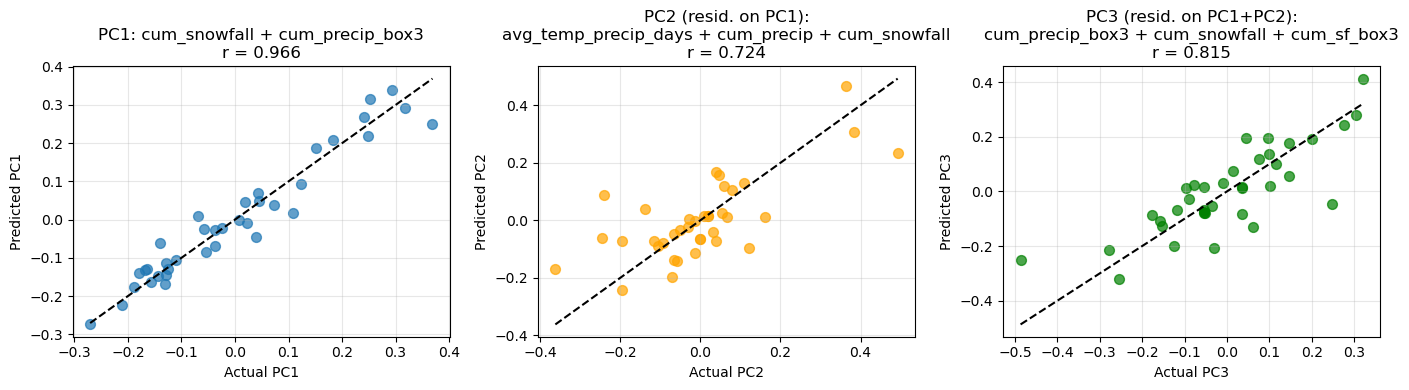


Variance explained:
  PC1: 93.4%
  PC2: 52.4%
  PC3: 66.4%


In [36]:
# === Plot Best Models from Exhaustive Search ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# PC1 - use predictions from best_pc1
ax = axes[0]
ax.scatter(y_pc1, best_pc1['predictions'], alpha=0.7, s=50)
ax.plot([y_pc1.min(), y_pc1.max()], [y_pc1.min(), y_pc1.max()], 'k--', lw=1.5)
ax.set_xlabel('Actual PC1')
ax.set_ylabel('Predicted PC1')
pc1_label = ' + '.join(best_pc1['features'])
ax.set_title(f'PC1: {pc1_label}\nr = {best_pc1["r"]:.3f}')
ax.grid(True, alpha=0.3)

# PC2 - use predictions from best_pc2
ax = axes[1]
ax.scatter(y_pc2, best_pc2['predictions'], alpha=0.7, s=50, color='orange')
ax.plot([y_pc2.min(), y_pc2.max()], [y_pc2.min(), y_pc2.max()], 'k--', lw=1.5)
ax.set_xlabel('Actual PC2')
ax.set_ylabel('Predicted PC2')
pc2_label = ' + '.join(best_pc2['features'])
ax.set_title(f'PC2 (resid. on PC1):\n{pc2_label}\nr = {best_pc2["r"]:.3f}')
ax.grid(True, alpha=0.3)

# PC3 - use predictions from best_pc3
ax = axes[2]
ax.scatter(y_pc3, best_pc3['predictions'], alpha=0.7, s=50, color='green')
ax.plot([y_pc3.min(), y_pc3.max()], [y_pc3.min(), y_pc3.max()], 'k--', lw=1.5)
ax.set_xlabel('Actual PC3')
ax.set_ylabel('Predicted PC3')
pc3_label = ' + '.join(best_pc3['features'])
ax.set_title(f'PC3 (resid. on PC1+PC2):\n{pc3_label}\nr = {best_pc3["r"]:.3f}')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/pc_predictions_best_models.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nVariance explained:")
print(f"  PC1: {best_pc1['r']**2 * 100:.1f}%")
print(f"  PC2: {best_pc2['r']**2 * 100:.1f}%")
print(f"  PC3: {best_pc3['r']**2 * 100:.1f}%")

## Reconstruct SWE using the best pc weight regressions:

In [37]:
# === Reconstruct SWE for 2019 using hierarchical regression to predict PC weights ===
# Test case: Pretend we don't know 2019's PC weights, estimate from met data

# Find 2019 index
test_year = 2019
test_idx = df_valid[df_valid['water_year'] == test_year].index[0]
train_mask = df_valid['water_year'] != test_year

print(f"Test year: {test_year} (index {test_idx})")
print(f"Training on {train_mask.sum()} years")

# Get training and test data
df_train = df_valid[train_mask].reset_index(drop=True)
df_test = df_valid[~train_mask].reset_index(drop=True)

# === PC1: Direct prediction from cum_snowfall ===
pc1_features = ['cum_snowfall', 'cum_precip_box3']
X_train_pc1 = df_train[pc1_features].values
y_train_pc1 = df_train['PC1_swe'].values
X_test_pc1 = df_test[pc1_features].values

model_pc1 = LinearRegression()
model_pc1.fit(X_train_pc1, y_train_pc1)
pred_pc1_2019 = model_pc1.predict(X_test_pc1)[0]

print(f"\nPC1 prediction:")
print(f"  Actual:    {df_test['PC1_swe'].values[0]:.4f}")
print(f"  Predicted: {pred_pc1_2019:.4f}")

# === PC2: Residualize on PREDICTED PC1, then predict ===
# Use avg_temp_precip_days + cum_precip + cum_snowfall
pc2_features = ['avg_temp_precip_days', 'cum_precip', 'cum_snowfall']
X_train_pc2 = df_train[pc2_features].values.astype(float)
X_test_pc2 = df_test[pc2_features].values.astype(float)
y_train_pc2 = df_train['PC2_swe'].values

# Residualize training features on training PC1 predictions
train_pc1_pred = model_pc1.predict(df_train[pc1_features].values)
X_train_pc2_resid = np.zeros_like(X_train_pc2)
resid_models_pc2 = []
for j in range(X_train_pc2.shape[1]):
    reg = LinearRegression()
    reg.fit(train_pc1_pred.reshape(-1, 1), X_train_pc2[:, j])
    resid_models_pc2.append(reg)
    X_train_pc2_resid[:, j] = X_train_pc2[:, j] - reg.predict(train_pc1_pred.reshape(-1, 1))

# Residualize test features on predicted PC1
X_test_pc2_resid = np.zeros_like(X_test_pc2)
for j, reg in enumerate(resid_models_pc2):
    X_test_pc2_resid[:, j] = X_test_pc2[:, j] - reg.predict(np.array([[pred_pc1_2019]]))

# Predict PC2
model_pc2 = LinearRegression()
model_pc2.fit(X_train_pc2_resid, y_train_pc2)
pred_pc2_2019 = model_pc2.predict(X_test_pc2_resid)[0]

print(f"\nPC2 prediction (residualized on predicted PC1):")
print(f"  Actual:    {df_test['PC2_swe'].values[0]:.4f}")
print(f"  Predicted: {pred_pc2_2019:.4f}")

# === PC3: Residualize on PREDICTED PC1+PC2, then predict ===
# Use cum_precip_box3 + cum_snowfall + cum_sf_box3
pc3_features = ['cum_precip_box3', 'cum_snowfall', 'cum_sf_box3']
X_train_pc3 = df_train[pc3_features].values.astype(float)
X_test_pc3 = df_test[pc3_features].values.astype(float)
y_train_pc3 = df_train['PC3_swe'].values

# For training: get predicted PC1+PC2
train_pc2_pred = np.zeros(len(df_train))
for i in range(len(df_train)):
    # Residualize and predict for each training sample
    X_pc2_i = X_train_pc2_resid[i:i+1]
    train_pc2_pred[i] = model_pc2.predict(X_pc2_i)[0]

train_pc12_pred = np.column_stack([train_pc1_pred, train_pc2_pred])

# Residualize PC3 features on predicted PC1+PC2
X_train_pc3_resid = np.zeros_like(X_train_pc3)
resid_models_pc3 = []
for j in range(X_train_pc3.shape[1]):
    reg = LinearRegression()
    reg.fit(train_pc12_pred, X_train_pc3[:, j])
    resid_models_pc3.append(reg)
    X_train_pc3_resid[:, j] = X_train_pc3[:, j] - reg.predict(train_pc12_pred)

# Residualize test features on predicted PC1+PC2
test_pc12_pred = np.array([[pred_pc1_2019, pred_pc2_2019]])
X_test_pc3_resid = np.zeros_like(X_test_pc3)
for j, reg in enumerate(resid_models_pc3):
    X_test_pc3_resid[:, j] = X_test_pc3[:, j] - reg.predict(test_pc12_pred)

# Predict PC3
model_pc3 = LinearRegression()
model_pc3.fit(X_train_pc3_resid, y_train_pc3)
pred_pc3_2019 = model_pc3.predict(X_test_pc3_resid)[0]

print(f"\nPC3 prediction (residualized on predicted PC1+PC2):")
print(f"  Actual:    {df_test['PC3_swe'].values[0]:.4f}")
print(f"  Predicted: {pred_pc3_2019:.4f}")

# === Store predicted PC weights for reconstruction ===
predicted_pc_weights_2019 = np.array([pred_pc1_2019, pred_pc2_2019, pred_pc3_2019])
actual_pc_weights_2019 = df_test[['PC1_swe', 'PC2_swe', 'PC3_swe']].values.flatten()

print(f"\n=== Summary for 2019 ===")
print(f"{'PC':<5} {'Actual':>10} {'Predicted':>10} {'Error':>10}")
print("-" * 37)
for i, (act, pred) in enumerate(zip(actual_pc_weights_2019, predicted_pc_weights_2019)):
    print(f"PC{i+1:<3} {act:>10.4f} {pred:>10.4f} {pred-act:>10.4f}")

Test year: 2019 (index 34)
Training on 36 years

PC1 prediction:
  Actual:    0.2481
  Predicted: 0.2198

PC2 prediction (residualized on predicted PC1):
  Actual:    -0.0658
  Predicted: -0.0330

PC3 prediction (residualized on predicted PC1+PC2):
  Actual:    -0.2775
  Predicted: -0.2099

=== Summary for 2019 ===
PC        Actual  Predicted      Error
-------------------------------------
PC1       0.2481     0.2198    -0.0283
PC2      -0.0658    -0.0330     0.0328
PC3      -0.2775    -0.2099     0.0676


In [38]:
# === Reconstruct 2019 SWE using PREDICTED PC weights ===
# Use the hierarchical regression predictions instead of actual PC weights

# Find the index for 2019 in the original pc_weights array
# pc_weights has shape (n_pcs, n_years) - need to find which column is 2019
year_idx_2019 = list(df_valid['water_year']).index(2019)

# Use predicted weights for reconstruction
i = 3  # Use first 3 PCs
predicted_weights_col = predicted_pc_weights_2019.reshape(-1, 1)

# Reconstruct using predicted PC weights
swe_sa_reconstructed = np.dot(U_anom_swe[:, :i] * S_anom_swe[:i], predicted_weights_col)

print(f"Reconstructed SWE anomaly field shape: {swe_sa_reconstructed.shape}")
print(f"Using PREDICTED PC weights: {predicted_pc_weights_2019}")
print(f"vs ACTUAL PC weights: {actual_pc_weights_2019}")

Reconstructed SWE anomaly field shape: (117133, 1)
Using PREDICTED PC weights: [ 0.21977065 -0.0330099  -0.20990504]
vs ACTUAL PC weights: [ 0.24810027 -0.06584185 -0.27751884]


In [ ]:
#swe_sa_reconstructed_expanded = np.expand_dims(swe_sa_reconstructed, axis=1)

In [43]:
swe_sa_reconstructed

array([[0.5385043 ],
       [0.50293007],
       [0.63711436],
       ...,
       [1.57122731],
       [1.35683524],
       [1.34326207]], shape=(117133, 1))

In [41]:
swe_sa_reconstructed_spatial

<xarray.DataArray 'SWE_Post' (space: 117133, time: 1)> Size: 469kB
array([[nan],
       [nan],
       [nan],
       ...,
       [nan],
       [nan],
       [nan]], shape=(117133, 1), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 8B 1985-04-01
    spatial_ref  int64 8B 0
  * space        (space) object 937kB MultiIndex
  * y            (space) float32 469kB 35.45 35.45 35.45 ... 40.38 40.39 40.39
  * x            (space) float32 469kB -118.4 -118.4 -118.4 ... -120.9 -120.8

In [44]:
swe_sa_reconstructed_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
swe_sa_reconstructed_spatial.values = swe_sa_reconstructed
swe_sa_reconstructed_spatial_unstacked = swe_sa_reconstructed_spatial.unstack('space')
swe_sa_reconstructed_spatial_unstacked_sorted = swe_sa_reconstructed_spatial_unstacked.sortby(['y', 'x'])

In [45]:
swe_sa_reconstructed_spatial_unstacked_sorted_dif = swe_sa_reconstructed_spatial_unstacked_sorted - swe_allyrs_april1_snowy_anomalies.sel(time='2019-04-01')

In [46]:
reconstructed_swe = (swe_sa_reconstructed_spatial_unstacked_sorted * swe_allyrs_april1_snowy.std(dim='time')) + swe_allyrs_april1_snowy.mean(dim='time')

In [47]:
reconstructed_swe_dif = reconstructed_swe - swe_allyrs_april1_snowy.sel(time='2019-04-01')

In [48]:
# === Calculate metrics: Regression-predicted reconstruction vs True 2019 SWE ===
true_swe = swe_allyrs_april1_snowy.sel(time='2019-04-01').where(reconstructed_swe).values.flatten()
pred_swe = reconstructed_swe.values.flatten()

# Remove NaN values
valid_mask = ~np.isnan(true_swe) & ~np.isnan(pred_swe)
true_swe_valid = true_swe[valid_mask]
pred_swe_valid = pred_swe[valid_mask]

# Bias (mean error)
bias = np.mean(pred_swe_valid - true_swe_valid)

# RMSE
rmse = np.sqrt(np.mean((pred_swe_valid - true_swe_valid)**2))

# R-squared
ss_res = np.sum((true_swe_valid - pred_swe_valid)**2)
ss_tot = np.sum((true_swe_valid - np.mean(true_swe_valid))**2)
r_squared = 1 - (ss_res / ss_tot)

# Correlation
from scipy.stats import pearsonr
r_corr, p_val = pearsonr(true_swe_valid, pred_swe_valid)

# Percent Bias (PBIAS)
pbias = 100 * np.sum(pred_swe_valid - true_swe_valid) / np.sum(true_swe_valid)

print("=" * 60)
print("Metrics: Hierarchical Regression Reconstruction vs True SWE")
print("Test Year: 2019 (leave-one-out)")
print("=" * 60)
print(f"\nPC weights used:")
print(f"  Predicted: [{', '.join([f'{w:.3f}' for w in predicted_pc_weights_2019])}]")
print(f"  Actual:    [{', '.join([f'{w:.3f}' for w in actual_pc_weights_2019])}]")
print(f"\nReconstruction Metrics:")
print(f"  Bias:       {bias:.4f} m")
print(f"  RMSE:       {rmse:.4f} m")
print(f"  R:          {r_corr:.4f} (p = {p_val:.2e})")
print(f"  R²:         {r_squared:.4f}")
print(f"  PBIAS:      {pbias:.2f}%")
print(f"  N points:   {len(true_swe_valid):,}")

Metrics: Hierarchical Regression Reconstruction vs True SWE
Test Year: 2019 (leave-one-out)

PC weights used:
  Predicted: [0.220, -0.033, -0.210]
  Actual:    [0.248, -0.066, -0.278]

Reconstruction Metrics:
  Bias:       -0.0340 m
  RMSE:       0.1546 m
  R:          0.9372 (p = 0.00e+00)
  R²:         0.8719
  PBIAS:      -3.90%
  N points:   117,133


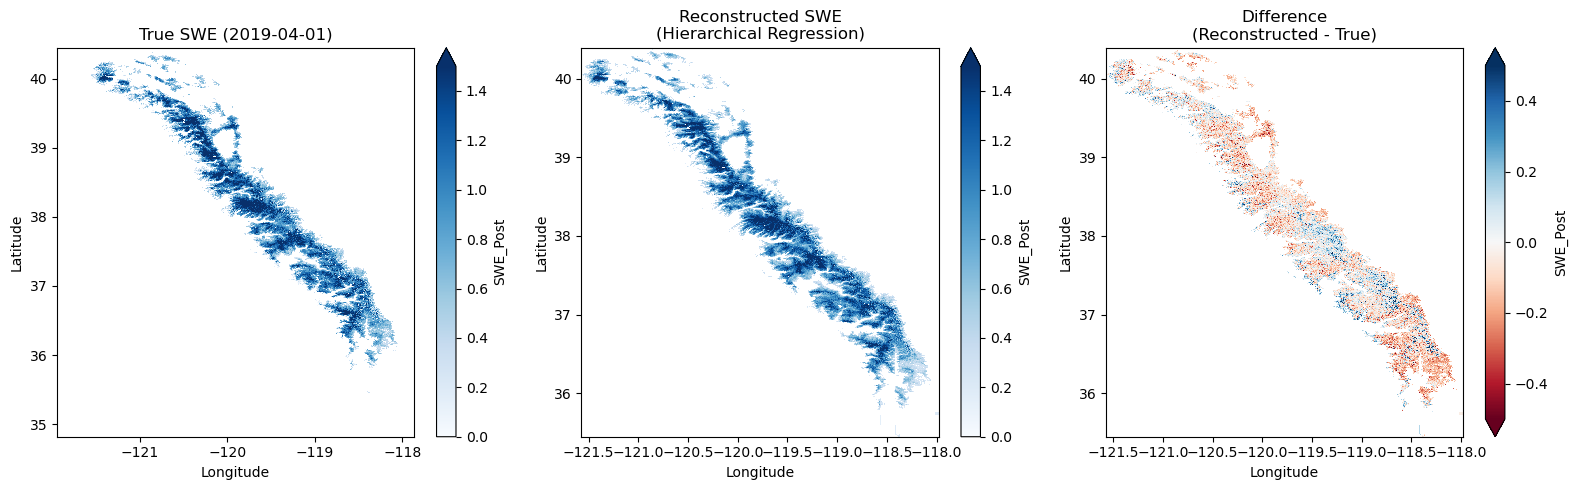


Reconstruction uses predicted PC weights from hierarchical regression
PC weight errors: [-0.02832962  0.03283195  0.0676138 ]


In [49]:
# === Visualize reconstruction results ===
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: True 2019 SWE
ax = axes[0]
true_2019 = swe_allyrs_april1_snowy.sel(time='2019-04-01')
true_2019.plot(ax=ax, cmap='Blues', vmin=0, vmax=1.5, add_colorbar=True)
ax.set_title('True SWE (2019-04-01)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Plot 2: Reconstructed SWE from predicted PC weights
ax = axes[1]
reconstructed_swe.squeeze().plot(ax=ax, cmap='Blues', vmin=0, vmax=1.5, add_colorbar=True)
ax.set_title('Reconstructed SWE\n(Hierarchical Regression)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Plot 3: Difference
ax = axes[2]
reconstructed_swe_dif.squeeze().plot(ax=ax, cmap='RdBu', vmin=-0.5, vmax=0.5, add_colorbar=True)
ax.set_title('Difference\n(Reconstructed - True)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('../figures/swe_reconstruction_2019_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nReconstruction uses predicted PC weights from hierarchical regression")
print(f"PC weight errors: {predicted_pc_weights_2019 - actual_pc_weights_2019}")

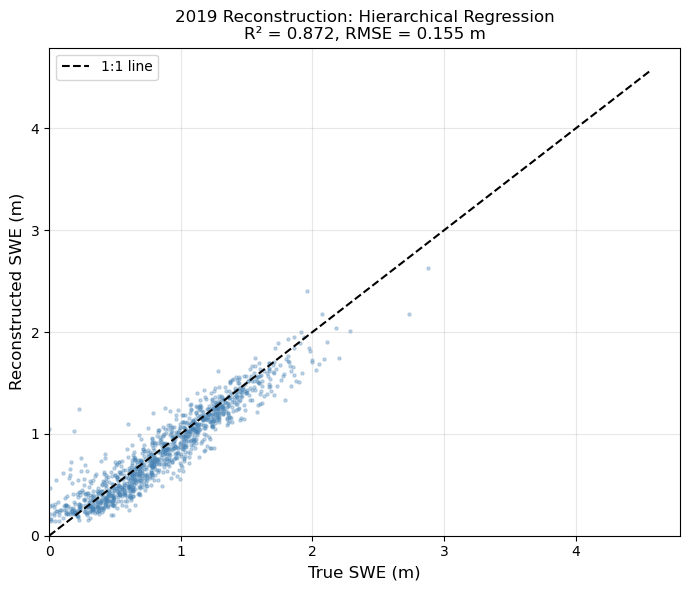

In [50]:
# === Scatter plot: Predicted vs True SWE ===
fig, ax = plt.subplots(figsize=(7, 6))

# Sample for plotting (use every Nth point to avoid overplotting)
sample_step = 100
ax.scatter(true_swe_valid[::sample_step], pred_swe_valid[::sample_step], 
           alpha=0.3, s=5, c='steelblue')

# 1:1 line
max_val = max(true_swe_valid.max(), pred_swe_valid.max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=1.5, label='1:1 line')

ax.set_xlabel('True SWE (m)', fontsize=12)
ax.set_ylabel('Reconstructed SWE (m)', fontsize=12)
ax.set_title(f'2019 Reconstruction: Hierarchical Regression\nR² = {r_squared:.3f}, RMSE = {rmse:.3f} m', fontsize=12)
ax.legend(loc='upper left')
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/swe_reconstruction_2019_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
U_spatial_unstacked_sorted_anom_swe

<xarray.DataArray 'SWE_Post' (time: 37, y: 1047, x: 796)> Size: 123MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1047, 796), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 35.45 35.46 35.46 35.46 ... 40.38 40.38 40.39
  * x            (x) float32 3kB -121.6 -121.6 -121.6 ... -118.0 -118.0 -118.0
  * time         (time) datetime64[ns] 296B 1985-04-01 1986-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0

In [144]:
# === Run Leave-One-Out Reconstruction for ALL Years ===
# Including both Met-only and Met+IS2 enhanced reconstructions
from tqdm import tqdm

# Get unique years - use df_valid_extended which has IS2 features
all_years = df_valid_extended['water_year'].values
n_years = len(all_years)
print(f"Running LOOCV reconstruction for {n_years} years...")
print("Computing: Met-only, Met+IS2, and Best-case (true weights) reconstructions")

# Feature definitions
# Met-only (original best models)
met_pc1_feats = ['cum_snowfall']
met_pc2_feats = ['avg_temp_precip_days', 'cum_precip', 'cum_snowfall']
met_pc3_feats = ['cum_precip_box3', 'cum_snowfall', 'cum_sf_box3']

# IS2-only (best models from IS2-only exhaustive search)
is2only_pc1_feats = ['is2_mean_sd']
is2only_pc2_feats = ['is2_sd_2000m', 'is2_mean_north']
is2only_pc3_feats = ['is2_elev_gradient', 'is2_ns_diff']

# IS2-enhanced (best models from Met+IS2 exhaustive search)
is2_pc1_feats = ['cum_snowfall', 'mean_t700_box1', 'is2_mean_south']
is2_pc2_feats = ['cum_precip_box1', 'cum_sf_box2', 'is2_intercept']
is2_pc3_feats = ['cum_precip_box3', 'is2_ns_diff', 'is2_intercept']

# Storage for results
error_stats_list = []
reconstructed_swe_all = []        # Met-only predicted
is2only_reconstructed_swe_all = []  # IS2-only predicted
is2_reconstructed_swe_all = []    # IS2-enhanced (Met+IS2) predicted
bestcase_swe_all = []             # True PC weights (best case)
true_swe_all = []
error_maps_all = []
is2only_error_maps_all = []
is2_error_maps_all = []
bestcase_error_maps_all = []

# Create EOF mask
eof_mask = U_spatial_eof_anom_swe.isel(EOF=0).notnull()
swe_masked = swe_allyrs_april1_snowy.where(eof_mask)

for test_year in tqdm(all_years, desc="Processing years"):
    # === Split train/test ===
    train_mask = df_valid_extended['water_year'] != test_year
    df_train = df_valid_extended[train_mask].reset_index(drop=True)
    df_test = df_valid_extended[~train_mask].reset_index(drop=True)
    
    # =========================================================================
    # MET-ONLY PREDICTION (original approach)
    # =========================================================================
    
    # === PC1: Direct prediction ===
    X_train_pc1 = df_train[met_pc1_feats].values
    y_train_pc1 = df_train['PC1_swe'].values
    X_test_pc1 = df_test[met_pc1_feats].values
    
    model_pc1 = LinearRegression()
    model_pc1.fit(X_train_pc1, y_train_pc1)
    pred_pc1 = model_pc1.predict(X_test_pc1)[0]
    
    # === PC2: Residualize on predicted PC1 ===
    X_train_pc2 = df_train[met_pc2_feats].values.astype(float)
    X_test_pc2 = df_test[met_pc2_feats].values.astype(float)
    y_train_pc2 = df_train['PC2_swe'].values
    
    train_pc1_pred = model_pc1.predict(df_train[met_pc1_feats].values)
    X_train_pc2_resid = np.zeros_like(X_train_pc2)
    resid_models_pc2 = []
    for j in range(X_train_pc2.shape[1]):
        reg = LinearRegression()
        reg.fit(train_pc1_pred.reshape(-1, 1), X_train_pc2[:, j])
        resid_models_pc2.append(reg)
        X_train_pc2_resid[:, j] = X_train_pc2[:, j] - reg.predict(train_pc1_pred.reshape(-1, 1))
    
    X_test_pc2_resid = np.zeros_like(X_test_pc2)
    for j, reg in enumerate(resid_models_pc2):
        X_test_pc2_resid[:, j] = X_test_pc2[:, j] - reg.predict(np.array([[pred_pc1]]))
    
    model_pc2 = LinearRegression()
    model_pc2.fit(X_train_pc2_resid, y_train_pc2)
    pred_pc2 = model_pc2.predict(X_test_pc2_resid)[0]
    
    # === PC3: Residualize on predicted PC1+PC2 ===
    X_train_pc3 = df_train[met_pc3_feats].values.astype(float)
    X_test_pc3 = df_test[met_pc3_feats].values.astype(float)
    y_train_pc3 = df_train['PC3_swe'].values
    
    train_pc2_pred = np.zeros(len(df_train))
    for k in range(len(df_train)):
        X_pc2_k = X_train_pc2_resid[k:k+1]
        train_pc2_pred[k] = model_pc2.predict(X_pc2_k)[0]
    
    train_pc12_pred = np.column_stack([train_pc1_pred, train_pc2_pred])
    
    X_train_pc3_resid = np.zeros_like(X_train_pc3)
    resid_models_pc3 = []
    for j in range(X_train_pc3.shape[1]):
        reg = LinearRegression()
        reg.fit(train_pc12_pred, X_train_pc3[:, j])
        resid_models_pc3.append(reg)
        X_train_pc3_resid[:, j] = X_train_pc3[:, j] - reg.predict(train_pc12_pred)
    
    test_pc12_pred = np.array([[pred_pc1, pred_pc2]])
    X_test_pc3_resid = np.zeros_like(X_test_pc3)
    for j, reg in enumerate(resid_models_pc3):
        X_test_pc3_resid[:, j] = X_test_pc3[:, j] - reg.predict(test_pc12_pred)
    
    model_pc3 = LinearRegression()
    model_pc3.fit(X_train_pc3_resid, y_train_pc3)
    pred_pc3 = model_pc3.predict(X_test_pc3_resid)[0]
    
    # =========================================================================
    # IS2-ENHANCED PREDICTION
    # =========================================================================
    
    # === IS2 PC1: Direct prediction ===
    X_train_is2_pc1 = df_train[is2_pc1_feats].values.astype(float)
    X_test_is2_pc1 = df_test[is2_pc1_feats].values.astype(float)
    
    model_is2_pc1 = LinearRegression()
    model_is2_pc1.fit(X_train_is2_pc1, y_train_pc1)
    pred_is2_pc1 = model_is2_pc1.predict(X_test_is2_pc1)[0]
    
    # === IS2 PC2: Residualize on predicted IS2 PC1 ===
    X_train_is2_pc2 = df_train[is2_pc2_feats].values.astype(float)
    X_test_is2_pc2 = df_test[is2_pc2_feats].values.astype(float)
    
    train_is2_pc1_pred = model_is2_pc1.predict(X_train_is2_pc1)
    X_train_is2_pc2_resid = np.zeros_like(X_train_is2_pc2)
    resid_models_is2_pc2 = []
    for j in range(X_train_is2_pc2.shape[1]):
        reg = LinearRegression()
        reg.fit(train_is2_pc1_pred.reshape(-1, 1), X_train_is2_pc2[:, j])
        resid_models_is2_pc2.append(reg)
        X_train_is2_pc2_resid[:, j] = X_train_is2_pc2[:, j] - reg.predict(train_is2_pc1_pred.reshape(-1, 1))
    
    X_test_is2_pc2_resid = np.zeros_like(X_test_is2_pc2)
    for j, reg in enumerate(resid_models_is2_pc2):
        X_test_is2_pc2_resid[:, j] = X_test_is2_pc2[:, j] - reg.predict(np.array([[pred_is2_pc1]]))
    
    model_is2_pc2 = LinearRegression()
    model_is2_pc2.fit(X_train_is2_pc2_resid, y_train_pc2)
    pred_is2_pc2 = model_is2_pc2.predict(X_test_is2_pc2_resid)[0]
    
    # === IS2 PC3: Residualize on predicted IS2 PC1+PC2 ===
    X_train_is2_pc3 = df_train[is2_pc3_feats].values.astype(float)
    X_test_is2_pc3 = df_test[is2_pc3_feats].values.astype(float)
    
    train_is2_pc2_pred = np.zeros(len(df_train))
    for k in range(len(df_train)):
        X_is2_pc2_k = X_train_is2_pc2_resid[k:k+1]
        train_is2_pc2_pred[k] = model_is2_pc2.predict(X_is2_pc2_k)[0]
    
    train_is2_pc12_pred = np.column_stack([train_is2_pc1_pred, train_is2_pc2_pred])
    
    X_train_is2_pc3_resid = np.zeros_like(X_train_is2_pc3)
    resid_models_is2_pc3 = []
    for j in range(X_train_is2_pc3.shape[1]):
        reg = LinearRegression()
        reg.fit(train_is2_pc12_pred, X_train_is2_pc3[:, j])
        resid_models_is2_pc3.append(reg)
        X_train_is2_pc3_resid[:, j] = X_train_is2_pc3[:, j] - reg.predict(train_is2_pc12_pred)
    
    test_is2_pc12_pred = np.array([[pred_is2_pc1, pred_is2_pc2]])
    X_test_is2_pc3_resid = np.zeros_like(X_test_is2_pc3)
    for j, reg in enumerate(resid_models_is2_pc3):
        X_test_is2_pc3_resid[:, j] = X_test_is2_pc3[:, j] - reg.predict(test_is2_pc12_pred)
    
    model_is2_pc3 = LinearRegression()
    model_is2_pc3.fit(X_train_is2_pc3_resid, y_train_pc3)
    pred_is2_pc3 = model_is2_pc3.predict(X_test_is2_pc3_resid)[0]
    
    # =========================================================================
    # IS2-ONLY PREDICTION (no meteorological data)
    # =========================================================================
    
    # === IS2-only PC1: Direct prediction ===
    X_train_is2only_pc1 = df_train[is2only_pc1_feats].values.astype(float)
    X_test_is2only_pc1 = df_test[is2only_pc1_feats].values.astype(float)
    
    model_is2only_pc1 = LinearRegression()
    model_is2only_pc1.fit(X_train_is2only_pc1, y_train_pc1)
    pred_is2only_pc1 = model_is2only_pc1.predict(X_test_is2only_pc1)[0]
    
    # === IS2-only PC2: Residualize on predicted IS2-only PC1 ===
    X_train_is2only_pc2 = df_train[is2only_pc2_feats].values.astype(float)
    X_test_is2only_pc2 = df_test[is2only_pc2_feats].values.astype(float)
    
    train_is2only_pc1_pred = model_is2only_pc1.predict(X_train_is2only_pc1)
    X_train_is2only_pc2_resid = np.zeros_like(X_train_is2only_pc2)
    resid_models_is2only_pc2 = []
    for j in range(X_train_is2only_pc2.shape[1]):
        reg = LinearRegression()
        reg.fit(train_is2only_pc1_pred.reshape(-1, 1), X_train_is2only_pc2[:, j])
        resid_models_is2only_pc2.append(reg)
        X_train_is2only_pc2_resid[:, j] = X_train_is2only_pc2[:, j] - reg.predict(train_is2only_pc1_pred.reshape(-1, 1))
    
    X_test_is2only_pc2_resid = np.zeros_like(X_test_is2only_pc2)
    for j, reg in enumerate(resid_models_is2only_pc2):
        X_test_is2only_pc2_resid[:, j] = X_test_is2only_pc2[:, j] - reg.predict(np.array([[pred_is2only_pc1]]))
    
    model_is2only_pc2 = LinearRegression()
    model_is2only_pc2.fit(X_train_is2only_pc2_resid, y_train_pc2)
    pred_is2only_pc2 = model_is2only_pc2.predict(X_test_is2only_pc2_resid)[0]
    
    # === IS2-only PC3: Residualize on predicted IS2-only PC1+PC2 ===
    X_train_is2only_pc3 = df_train[is2only_pc3_feats].values.astype(float)
    X_test_is2only_pc3 = df_test[is2only_pc3_feats].values.astype(float)
    
    train_is2only_pc2_pred = np.zeros(len(df_train))
    for k in range(len(df_train)):
        X_is2only_pc2_k = X_train_is2only_pc2_resid[k:k+1]
        train_is2only_pc2_pred[k] = model_is2only_pc2.predict(X_is2only_pc2_k)[0]
    
    train_is2only_pc12_pred = np.column_stack([train_is2only_pc1_pred, train_is2only_pc2_pred])
    
    X_train_is2only_pc3_resid = np.zeros_like(X_train_is2only_pc3)
    resid_models_is2only_pc3 = []
    for j in range(X_train_is2only_pc3.shape[1]):
        reg = LinearRegression()
        reg.fit(train_is2only_pc12_pred, X_train_is2only_pc3[:, j])
        resid_models_is2only_pc3.append(reg)
        X_train_is2only_pc3_resid[:, j] = X_train_is2only_pc3[:, j] - reg.predict(train_is2only_pc12_pred)
    
    test_is2only_pc12_pred = np.array([[pred_is2only_pc1, pred_is2only_pc2]])
    X_test_is2only_pc3_resid = np.zeros_like(X_test_is2only_pc3)
    for j, reg in enumerate(resid_models_is2only_pc3):
        X_test_is2only_pc3_resid[:, j] = X_test_is2only_pc3[:, j] - reg.predict(test_is2only_pc12_pred)
    
    model_is2only_pc3 = LinearRegression()
    model_is2only_pc3.fit(X_train_is2only_pc3_resid, y_train_pc3)
    pred_is2only_pc3 = model_is2only_pc3.predict(X_test_is2only_pc3_resid)[0]
    
    # =========================================================================
    # RECONSTRUCT SWE MAPS
    # =========================================================================
    actual_weights = df_test[['PC1_swe', 'PC2_swe', 'PC3_swe']].values.flatten()
    
    # --- Met-only reconstruction ---
    predicted_weights = np.array([pred_pc1, pred_pc2, pred_pc3]).reshape(-1, 1)
    swe_anom_reconstructed = np.dot(U_anom_swe[:, :3] * S_anom_swe[:3], predicted_weights)
    
    swe_anom_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
    swe_anom_spatial.values = swe_anom_reconstructed
    swe_anom_unstacked = swe_anom_spatial.unstack('space')
    swe_anom_sorted = swe_anom_unstacked.sortby(['y', 'x'])
    reconstructed = (swe_anom_sorted * swe_masked.std(dim='time')) + swe_masked.mean(dim='time')
    reconstructed = reconstructed.where(eof_mask)
    
    # --- IS2-enhanced reconstruction ---
    is2_predicted_weights = np.array([pred_is2_pc1, pred_is2_pc2, pred_is2_pc3]).reshape(-1, 1)
    swe_anom_is2_reconstructed = np.dot(U_anom_swe[:, :3] * S_anom_swe[:3], is2_predicted_weights)
    
    swe_anom_is2_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
    swe_anom_is2_spatial.values = swe_anom_is2_reconstructed
    swe_anom_is2_unstacked = swe_anom_is2_spatial.unstack('space')
    swe_anom_is2_sorted = swe_anom_is2_unstacked.sortby(['y', 'x'])
    is2_reconstructed = (swe_anom_is2_sorted * swe_masked.std(dim='time')) + swe_masked.mean(dim='time')
    is2_reconstructed = is2_reconstructed.where(eof_mask)
    
    # --- IS2-only reconstruction ---
    is2only_predicted_weights = np.array([pred_is2only_pc1, pred_is2only_pc2, pred_is2only_pc3]).reshape(-1, 1)
    swe_anom_is2only_reconstructed = np.dot(U_anom_swe[:, :3] * S_anom_swe[:3], is2only_predicted_weights)
    
    swe_anom_is2only_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
    swe_anom_is2only_spatial.values = swe_anom_is2only_reconstructed
    swe_anom_is2only_unstacked = swe_anom_is2only_spatial.unstack('space')
    swe_anom_is2only_sorted = swe_anom_is2only_unstacked.sortby(['y', 'x'])
    is2only_reconstructed = (swe_anom_is2only_sorted * swe_masked.std(dim='time')) + swe_masked.mean(dim='time')
    is2only_reconstructed = is2only_reconstructed.where(eof_mask)
    
    # --- Best case reconstruction (true weights) ---
    true_weights_col = actual_weights.reshape(-1, 1)
    swe_anom_bestcase = np.dot(U_anom_swe[:, :3] * S_anom_swe[:3], true_weights_col)
    
    swe_anom_bc_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
    swe_anom_bc_spatial.values = swe_anom_bestcase
    swe_anom_bc_unstacked = swe_anom_bc_spatial.unstack('space')
    swe_anom_bc_sorted = swe_anom_bc_unstacked.sortby(['y', 'x'])
    bestcase = (swe_anom_bc_sorted * swe_masked.std(dim='time')) + swe_masked.mean(dim='time')
    bestcase = bestcase.where(eof_mask)
    
    # Get true SWE for this year
    time_str = f"{test_year}-04-01"
    true_swe_year = swe_masked.sel(time=time_str)
    
    # =========================================================================
    # CALCULATE ERROR STATISTICS
    # =========================================================================
    true_vals = true_swe_year.values.flatten()
    pred_vals = reconstructed.squeeze().values.flatten()
    is2only_pred_vals = is2only_reconstructed.squeeze().values.flatten()
    is2_pred_vals = is2_reconstructed.squeeze().values.flatten()
    bc_vals = bestcase.squeeze().values.flatten()
    valid = ~np.isnan(true_vals) & ~np.isnan(pred_vals)
    
    true_valid = true_vals[valid]
    pred_valid = pred_vals[valid]
    is2only_valid = is2only_pred_vals[valid]
    is2_valid = is2_pred_vals[valid]
    bc_valid = bc_vals[valid]
    
    # Met-only error stats
    bias = np.mean(pred_valid - true_valid)
    rmse = np.sqrt(np.mean((pred_valid - true_valid)**2))
    mae = np.mean(np.abs(pred_valid - true_valid))
    r_corr, _ = pearsonr(true_valid, pred_valid)
    r_squared = r_corr ** 2
    pbias = 100 * np.sum(pred_valid - true_valid) / np.sum(true_valid) if np.sum(true_valid) != 0 else np.nan
    
    # IS2-only error stats
    is2only_bias = np.mean(is2only_valid - true_valid)
    is2only_rmse = np.sqrt(np.mean((is2only_valid - true_valid)**2))
    is2only_mae = np.mean(np.abs(is2only_valid - true_valid))
    is2only_r_corr, _ = pearsonr(true_valid, is2only_valid)
    is2only_r_squared = is2only_r_corr ** 2
    is2only_pbias = 100 * np.sum(is2only_valid - true_valid) / np.sum(true_valid) if np.sum(true_valid) != 0 else np.nan
    
    # IS2-enhanced error stats
    is2_bias = np.mean(is2_valid - true_valid)
    is2_rmse = np.sqrt(np.mean((is2_valid - true_valid)**2))
    is2_mae = np.mean(np.abs(is2_valid - true_valid))
    is2_r_corr, _ = pearsonr(true_valid, is2_valid)
    is2_r_squared = is2_r_corr ** 2
    is2_pbias = 100 * np.sum(is2_valid - true_valid) / np.sum(true_valid) if np.sum(true_valid) != 0 else np.nan
    
    # Best case error stats
    bc_bias = np.mean(bc_valid - true_valid)
    bc_rmse = np.sqrt(np.mean((bc_valid - true_valid)**2))
    bc_mae = np.mean(np.abs(bc_valid - true_valid))
    bc_r_corr, _ = pearsonr(true_valid, bc_valid)
    bc_r_squared = bc_r_corr ** 2
    bc_pbias = 100 * np.sum(bc_valid - true_valid) / np.sum(true_valid) if np.sum(true_valid) != 0 else np.nan
    
    # Store results
    error_stats_list.append({
        'water_year': test_year,
        # Met-only stats
        'bias': bias, 'rmse': rmse, 'mae': mae, 'r_squared': r_squared, 'r': r_corr, 'pbias': pbias,
        'pred_pc1': pred_pc1, 'pred_pc2': pred_pc2, 'pred_pc3': pred_pc3,
        # IS2-only stats
        'is2only_bias': is2only_bias, 'is2only_rmse': is2only_rmse, 'is2only_mae': is2only_mae, 
        'is2only_r_squared': is2only_r_squared, 'is2only_r': is2only_r_corr, 'is2only_pbias': is2only_pbias,
        'is2only_pred_pc1': pred_is2only_pc1, 'is2only_pred_pc2': pred_is2only_pc2, 'is2only_pred_pc3': pred_is2only_pc3,
        # IS2-enhanced stats
        'is2_bias': is2_bias, 'is2_rmse': is2_rmse, 'is2_mae': is2_mae, 
        'is2_r_squared': is2_r_squared, 'is2_r': is2_r_corr, 'is2_pbias': is2_pbias,
        'is2_pred_pc1': pred_is2_pc1, 'is2_pred_pc2': pred_is2_pc2, 'is2_pred_pc3': pred_is2_pc3,
        # Best case stats
        'bestcase_bias': bc_bias, 'bestcase_rmse': bc_rmse, 'bestcase_mae': bc_mae,
        'bestcase_r_squared': bc_r_squared, 'bestcase_r': bc_r_corr, 'bestcase_pbias': bc_pbias,
        # Actual weights
        'actual_pc1': actual_weights[0], 'actual_pc2': actual_weights[1], 'actual_pc3': actual_weights[2],
        'n_valid_points': len(true_valid)
    })
    
    # Store maps
    reconstructed_swe_all.append(reconstructed.squeeze().values)
    is2only_reconstructed_swe_all.append(is2only_reconstructed.squeeze().values)
    is2_reconstructed_swe_all.append(is2_reconstructed.squeeze().values)
    bestcase_swe_all.append(bestcase.squeeze().values)
    true_swe_all.append(true_swe_year.values)
    error_maps_all.append((reconstructed.squeeze() - true_swe_year).values)
    is2only_error_maps_all.append((is2only_reconstructed.squeeze() - true_swe_year).values)
    is2_error_maps_all.append((is2_reconstructed.squeeze() - true_swe_year).values)
    bestcase_error_maps_all.append((bestcase.squeeze() - true_swe_year).values)

# Create error statistics DataFrame
error_stats_df = pd.DataFrame(error_stats_list)

print("\n" + "="*80)
print("LOOCV ERROR STATISTICS SUMMARY")
print("="*80)
print("\nMet-only vs IS2-only vs IS2-enhanced vs Best-case (true weights):")
print(error_stats_df[['water_year', 'rmse', 'is2only_rmse', 'is2_rmse', 'bestcase_rmse']].to_string(index=False))

print(f"\n{'Metric':<20} {'Met-only':>12} {'IS2-only':>12} {'Met+IS2':>12} {'Best-case':>12}")
print("-"*70)
print(f"{'Mean RMSE (m)':<20} {error_stats_df['rmse'].mean():>12.4f} {error_stats_df['is2only_rmse'].mean():>12.4f} {error_stats_df['is2_rmse'].mean():>12.4f} {error_stats_df['bestcase_rmse'].mean():>12.4f}")
print(f"{'Mean MAE (m)':<20} {error_stats_df['mae'].mean():>12.4f} {error_stats_df['is2only_mae'].mean():>12.4f} {error_stats_df['is2_mae'].mean():>12.4f} {error_stats_df['bestcase_mae'].mean():>12.4f}")
print(f"{'Mean R²':<20} {error_stats_df['r_squared'].mean():>12.4f} {error_stats_df['is2only_r_squared'].mean():>12.4f} {error_stats_df['is2_r_squared'].mean():>12.4f} {error_stats_df['bestcase_r_squared'].mean():>12.4f}")
print(f"{'Mean Bias (m)':<20} {error_stats_df['bias'].mean():>12.4f} {error_stats_df['is2only_bias'].mean():>12.4f} {error_stats_df['is2_bias'].mean():>12.4f} {error_stats_df['bestcase_bias'].mean():>12.4f}")

rmse_is2only_imp = (error_stats_df['rmse'].mean() - error_stats_df['is2only_rmse'].mean()) / error_stats_df['rmse'].mean() * 100
rmse_is2_imp = (error_stats_df['rmse'].mean() - error_stats_df['is2_rmse'].mean()) / error_stats_df['rmse'].mean() * 100
print(f"\nIS2-only RMSE improvement over Met-only: {rmse_is2only_imp:.1f}%")
print(f"Met+IS2 RMSE improvement over Met-only: {rmse_is2_imp:.1f}%")

Running LOOCV reconstruction for 37 years...
Computing: Met-only, Met+IS2, and Best-case (true weights) reconstructions


Processing years: 100%|██████████| 37/37 [00:07<00:00,  5.14it/s]


LOOCV ERROR STATISTICS SUMMARY

Met-only vs IS2-only vs IS2-enhanced vs Best-case (true weights):
 water_year     rmse  is2only_rmse  is2_rmse  bestcase_rmse
       1985 0.205091      0.168111  0.170308       0.162793
       1986 0.181683      0.157382  0.174190       0.124506
       1987 0.157305      0.139350  0.140966       0.121355
       1988 0.082340      0.090355  0.087648       0.079108
       1989 0.176041      0.135779  0.132010       0.129411
       1990 0.113477      0.122258  0.108457       0.106927
       1991 0.196840      0.115804  0.125654       0.101973
       1992 0.170056      0.199026  0.176373       0.139068
       1993 0.294186      0.222352  0.227517       0.186474
       1994 0.095745      0.092170  0.095166       0.091687
       1995 0.163631      0.207449  0.169237       0.147026
       1996 0.231825      0.162178  0.181909       0.160940
       1997 0.143308      0.150121  0.131223       0.125461
       1998 0.196125      0.163063  0.150019       0.136981
 

In [145]:
# === Create xarray Dataset with reconstructed SWE maps ===
# Including Met-only, IS2-only, IS2-enhanced, and Best-case reconstructions

# Get coordinates from template (using masked data)
y_coords = swe_masked.y.values
x_coords = swe_masked.x.values
time_coords = pd.to_datetime([f"{yr}-04-01" for yr in all_years])

# Stack arrays
reconstructed_stack = np.stack(reconstructed_swe_all, axis=0)
is2only_reconstructed_stack = np.stack(is2only_reconstructed_swe_all, axis=0)
is2_reconstructed_stack = np.stack(is2_reconstructed_swe_all, axis=0)
bestcase_stack = np.stack(bestcase_swe_all, axis=0)
true_stack = np.stack(true_swe_all, axis=0)
error_stack = np.stack(error_maps_all, axis=0)
is2only_error_stack = np.stack(is2only_error_maps_all, axis=0)
is2_error_stack = np.stack(is2_error_maps_all, axis=0)
bestcase_error_stack = np.stack(bestcase_error_maps_all, axis=0)

# Create Dataset
loocv_ds = xr.Dataset({
    'reconstructed_swe': (['time', 'y', 'x'], reconstructed_stack),
    'is2only_reconstructed_swe': (['time', 'y', 'x'], is2only_reconstructed_stack),
    'is2_reconstructed_swe': (['time', 'y', 'x'], is2_reconstructed_stack),
    'bestcase_swe': (['time', 'y', 'x'], bestcase_stack),
    'true_swe': (['time', 'y', 'x'], true_stack),
    'error': (['time', 'y', 'x'], error_stack),
    'is2only_error': (['time', 'y', 'x'], is2only_error_stack),
    'is2_error': (['time', 'y', 'x'], is2_error_stack),
    'bestcase_error': (['time', 'y', 'x'], bestcase_error_stack)
}, coords={
    'time': time_coords,
    'y': y_coords,
    'x': x_coords
})

# Add attributes
loocv_ds.attrs['description'] = 'LOOCV SWE reconstruction: Met-only, IS2-only, IS2-enhanced, and Best-case (masked to EOF domain)'
loocv_ds.attrs['met_pc1_features'] = 'cum_snowfall'
loocv_ds.attrs['met_pc2_features'] = 'avg_temp_precip_days + cum_precip + cum_snowfall (residualized on PC1)'
loocv_ds.attrs['met_pc3_features'] = 'cum_precip_box3 + cum_snowfall + cum_sf_box3 (residualized on PC1+PC2)'
loocv_ds.attrs['is2only_pc1_features'] = 'is2_mean_sd'
loocv_ds.attrs['is2only_pc2_features'] = 'is2_sd_2000m + is2_mean_north (residualized on PC1)'
loocv_ds.attrs['is2only_pc3_features'] = 'is2_elev_gradient + is2_ns_diff (residualized on PC1+PC2)'
loocv_ds.attrs['is2_pc1_features'] = 'cum_snowfall + mean_t700_box1 + is2_mean_south'
loocv_ds.attrs['is2_pc2_features'] = 'cum_precip_box1 + cum_sf_box2 + is2_intercept (residualized on PC1)'
loocv_ds.attrs['is2_pc3_features'] = 'cum_precip_box3 + is2_ns_diff + is2_intercept (residualized on PC1+PC2)'

loocv_ds['reconstructed_swe'].attrs['units'] = 'm'
loocv_ds['reconstructed_swe'].attrs['description'] = 'SWE reconstructed using Met-only predicted PC weights'
loocv_ds['is2only_reconstructed_swe'].attrs['units'] = 'm'
loocv_ds['is2only_reconstructed_swe'].attrs['description'] = 'SWE reconstructed using IS2-only predicted PC weights'
loocv_ds['is2_reconstructed_swe'].attrs['units'] = 'm'
loocv_ds['is2_reconstructed_swe'].attrs['description'] = 'SWE reconstructed using IS2-enhanced (Met+IS2) predicted PC weights'
loocv_ds['bestcase_swe'].attrs['units'] = 'm'
loocv_ds['bestcase_swe'].attrs['description'] = 'SWE reconstructed using true PC weights (best case scenario)'
loocv_ds['true_swe'].attrs['units'] = 'm'
loocv_ds['error'].attrs['units'] = 'm'
loocv_ds['error'].attrs['description'] = 'Met-only reconstructed - true'
loocv_ds['is2only_error'].attrs['units'] = 'm'
loocv_ds['is2only_error'].attrs['description'] = 'IS2-only reconstructed - true'
loocv_ds['is2_error'].attrs['units'] = 'm'
loocv_ds['is2_error'].attrs['description'] = 'IS2-enhanced (Met+IS2) reconstructed - true'
loocv_ds['bestcase_error'].attrs['units'] = 'm'
loocv_ds['bestcase_error'].attrs['description'] = 'bestcase - true (irreducible error from using only 3 PCs)'

print(loocv_ds)

# Save Dataset
output_path = '../data/results/loocv_swe_reconstruction.nc'
loocv_ds.to_netcdf(output_path)
print(f"\nDataset saved to: {output_path}")

<xarray.Dataset> Size: 2GB
Dimensions:                    (time: 37, y: 1047, x: 796)
Coordinates:
  * time                       (time) datetime64[ns] 296B 1985-04-01 ... 2021...
  * y                          (y) float32 4kB 35.45 35.46 35.46 ... 40.38 40.39
  * x                          (x) float32 3kB -121.6 -121.6 ... -118.0 -118.0
Data variables:
    reconstructed_swe          (time, y, x) float64 247MB nan nan ... nan nan
    is2only_reconstructed_swe  (time, y, x) float64 247MB nan nan ... nan nan
    is2_reconstructed_swe      (time, y, x) float64 247MB nan nan ... nan nan
    bestcase_swe               (time, y, x) float32 123MB nan nan ... nan nan
    true_swe                   (time, y, x) float32 123MB nan nan ... nan nan
    error                      (time, y, x) float64 247MB nan nan ... nan nan
    is2only_error              (time, y, x) float64 247MB nan nan ... nan nan
    is2_error                  (time, y, x) float64 247MB nan nan ... nan nan
    bestcase_error  

In [146]:
# === Save error statistics DataFrame ===
error_stats_df.to_csv('../data/results/loocv_error_stats.csv', index=False)
print("Error statistics saved to: ../data/results/loocv_error_stats.csv")
print(f"\nDataFrame shape: {error_stats_df.shape}")
error_stats_df

Error statistics saved to: ../data/results/loocv_error_stats.csv

DataFrame shape: (37, 38)


,water_year,bias,rmse,mae,r_squared,r,pbias,pred_pc1,pred_pc2,pred_pc3,...,bestcase_bias,bestcase_rmse,bestcase_mae,bestcase_r_squared,bestcase_r,bestcase_pbias,actual_pc1,actual_pc2,actual_pc3,n_valid_points
0,1985,0.060302,0.205091,0.153507,0.691707,0.831689,11.669237,0.062106,-0.105540,-0.011184,...,0.000902,0.162793,0.122679,0.786900,0.887074,0.174559,0.019238,0.037850,0.247276,117133
1,1986,-0.019572,0.181683,0.143838,0.936675,0.967820,-2.560950,0.150783,0.217401,0.171951,...,0.002229,0.124506,0.094707,0.953982,0.976720,0.291645,0.150947,0.492680,0.275138,117133
2,1987,-0.090926,0.157305,0.118556,0.740971,0.860797,-33.165552,-0.188051,0.020993,0.141163,...,0.000894,0.121355,0.086304,0.762004,0.872929,0.326238,-0.131377,0.018398,0.043882,117133
3,1988,0.008163,0.082340,0.058672,0.843295,0.918311,4.160121,-0.174740,0.021922,0.187936,...,-0.000518,0.079108,0.053708,0.850975,0.922483,-0.264118,-0.179905,0.008778,0.096270,117133
4,1989,0.099174,0.176041,0.139956,0.819600,0.905318,24.554629,0.004859,0.125863,0.061429,...,-0.001753,0.129411,0.092627,0.850114,0.922016,-0.434072,-0.057570,0.108054,-0.077689,117133
5,1990,0.023107,0.113477,0.080687,0.772343,0.878830,10.029626,-0.145255,0.011930,-0.127228,...,-0.000208,0.106927,0.073935,0.779042,0.882634,-0.090090,-0.157311,-0.028908,-0.051417,117133
6,1991,-0.105034,0.196840,0.161612,0.666467,0.816374,-20.065100,-0.045100,0.076276,0.080225,...,0.003632,0.101973,0.077415,0.795503,0.891910,0.693925,0.038678,-0.241451,0.145191,117133
7,1992,-0.098176,0.170056,0.132100,0.713309,0.844576,-25.460808,-0.119608,-0.043735,0.245305,...,0.002259,0.139068,0.106817,0.709016,0.842031,0.585857,-0.054447,-0.093801,0.304689,117133
8,1993,-0.212967,0.294186,0.234030,0.848289,0.921026,-19.873922,0.237086,-0.098540,0.098012,...,0.002386,0.186474,0.137621,0.855521,0.924944,0.222664,0.368983,-0.058053,0.146526,117133
9,1994,-0.012607,0.095745,0.070162,0.780421,0.883415,-5.112325,-0.149528,-0.130477,0.011096,...,0.000334,0.091687,0.065513,0.790036,0.888840,0.135445,-0.144689,-0.066759,0.013862,117133


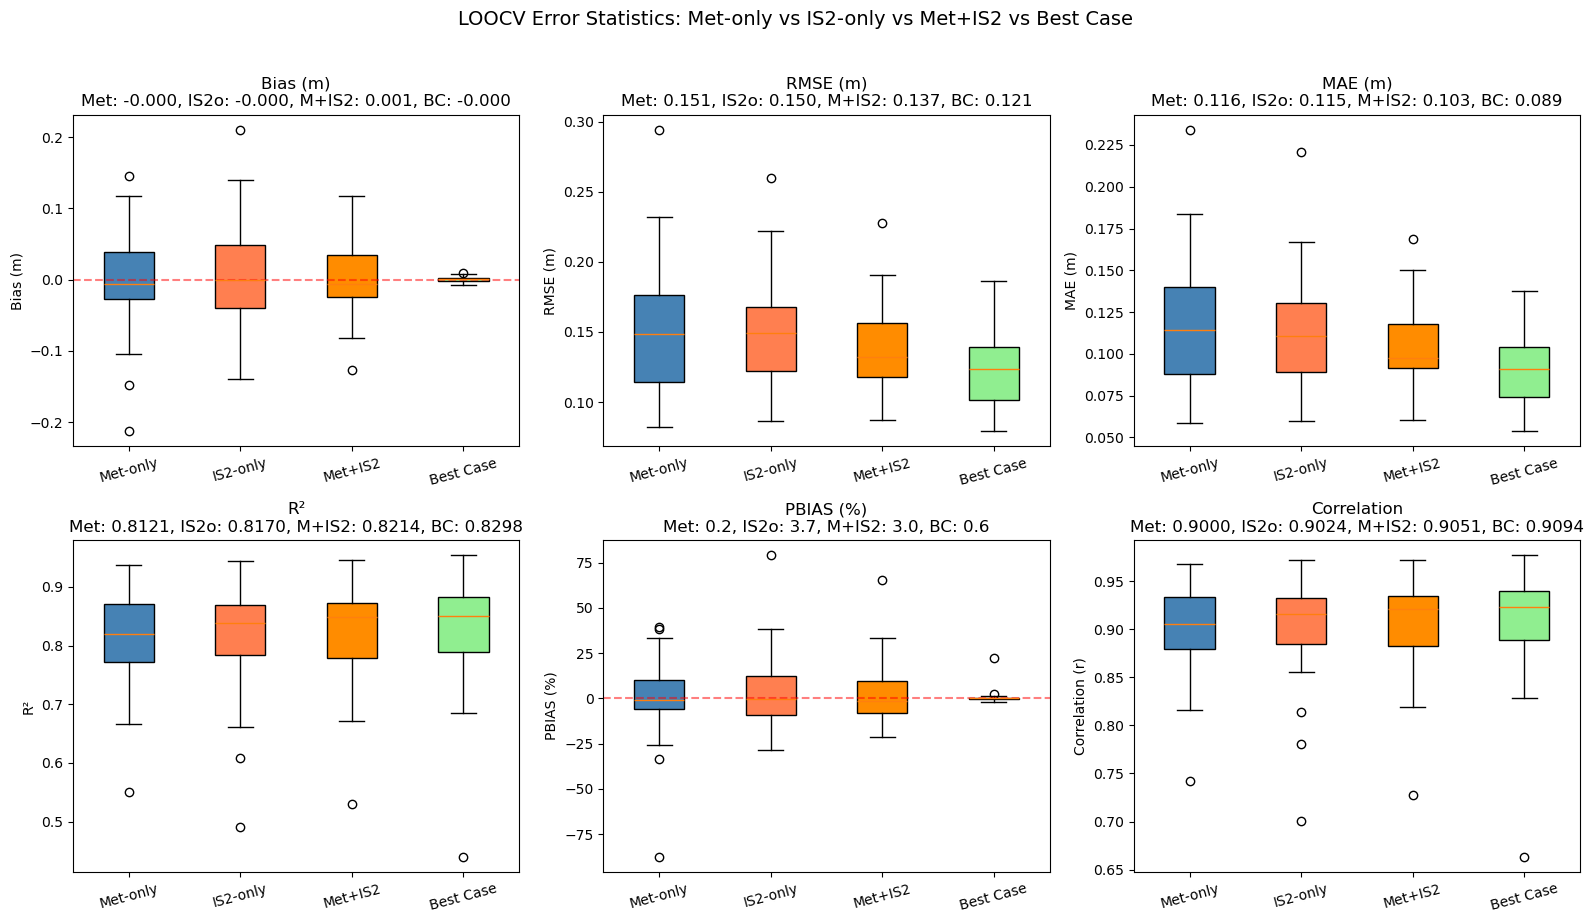

In [147]:
# === Boxplots of Error Statistics: Met-only vs IS2-only vs Met+IS2 vs Best Case ===
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

box_colors = ['steelblue', 'coral', 'darkorange', 'lightgreen']
labels = ['Met-only', 'IS2-only', 'Met+IS2', 'Best Case']

# Bias
ax = axes[0, 0]
bp = ax.boxplot([error_stats_df['bias'], error_stats_df['is2only_bias'], error_stats_df['is2_bias'], error_stats_df['bestcase_bias']], 
                vert=True, patch_artist=True, labels=labels)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_ylabel('Bias (m)')
ax.set_title(f'Bias (m)\nMet: {error_stats_df["bias"].mean():.3f}, IS2o: {error_stats_df["is2only_bias"].mean():.3f}, M+IS2: {error_stats_df["is2_bias"].mean():.3f}, BC: {error_stats_df["bestcase_bias"].mean():.3f}')
ax.tick_params(axis='x', rotation=15)

# RMSE
ax = axes[0, 1]
bp = ax.boxplot([error_stats_df['rmse'], error_stats_df['is2only_rmse'], error_stats_df['is2_rmse'], error_stats_df['bestcase_rmse']], 
                vert=True, patch_artist=True, labels=labels)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
ax.set_ylabel('RMSE (m)')
ax.set_title(f'RMSE (m)\nMet: {error_stats_df["rmse"].mean():.3f}, IS2o: {error_stats_df["is2only_rmse"].mean():.3f}, M+IS2: {error_stats_df["is2_rmse"].mean():.3f}, BC: {error_stats_df["bestcase_rmse"].mean():.3f}')
ax.tick_params(axis='x', rotation=15)

# MAE
ax = axes[0, 2]
bp = ax.boxplot([error_stats_df['mae'], error_stats_df['is2only_mae'], error_stats_df['is2_mae'], error_stats_df['bestcase_mae']], 
                vert=True, patch_artist=True, labels=labels)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
ax.set_ylabel('MAE (m)')
ax.set_title(f'MAE (m)\nMet: {error_stats_df["mae"].mean():.3f}, IS2o: {error_stats_df["is2only_mae"].mean():.3f}, M+IS2: {error_stats_df["is2_mae"].mean():.3f}, BC: {error_stats_df["bestcase_mae"].mean():.3f}')
ax.tick_params(axis='x', rotation=15)

# R²
ax = axes[1, 0]
bp = ax.boxplot([error_stats_df['r_squared'], error_stats_df['is2only_r_squared'], error_stats_df['is2_r_squared'], error_stats_df['bestcase_r_squared']], 
                vert=True, patch_artist=True, labels=labels)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
ax.set_ylabel('R²')
ax.set_title(f'R²\nMet: {error_stats_df["r_squared"].mean():.4f}, IS2o: {error_stats_df["is2only_r_squared"].mean():.4f}, M+IS2: {error_stats_df["is2_r_squared"].mean():.4f}, BC: {error_stats_df["bestcase_r_squared"].mean():.4f}')
ax.tick_params(axis='x', rotation=15)

# PBIAS
ax = axes[1, 1]
bp = ax.boxplot([error_stats_df['pbias'], error_stats_df['is2only_pbias'], error_stats_df['is2_pbias'], error_stats_df['bestcase_pbias']], 
                vert=True, patch_artist=True, labels=labels)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_ylabel('PBIAS (%)')
ax.set_title(f'PBIAS (%)\nMet: {error_stats_df["pbias"].mean():.1f}, IS2o: {error_stats_df["is2only_pbias"].mean():.1f}, M+IS2: {error_stats_df["is2_pbias"].mean():.1f}, BC: {error_stats_df["bestcase_pbias"].mean():.1f}')
ax.tick_params(axis='x', rotation=15)

# Correlation
ax = axes[1, 2]
bp = ax.boxplot([error_stats_df['r'], error_stats_df['is2only_r'], error_stats_df['is2_r'], error_stats_df['bestcase_r']], 
                vert=True, patch_artist=True, labels=labels)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
ax.set_ylabel('Correlation (r)')
ax.set_title(f'Correlation\nMet: {error_stats_df["r"].mean():.4f}, IS2o: {error_stats_df["is2only_r"].mean():.4f}, M+IS2: {error_stats_df["is2_r"].mean():.4f}, BC: {error_stats_df["bestcase_r"].mean():.4f}')
ax.tick_params(axis='x', rotation=15)

plt.suptitle('LOOCV Error Statistics: Met-only vs IS2-only vs Met+IS2 vs Best Case', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#plt.savefig('../figures/loocv_error_boxplots.png', dpi=150, bbox_inches='tight')

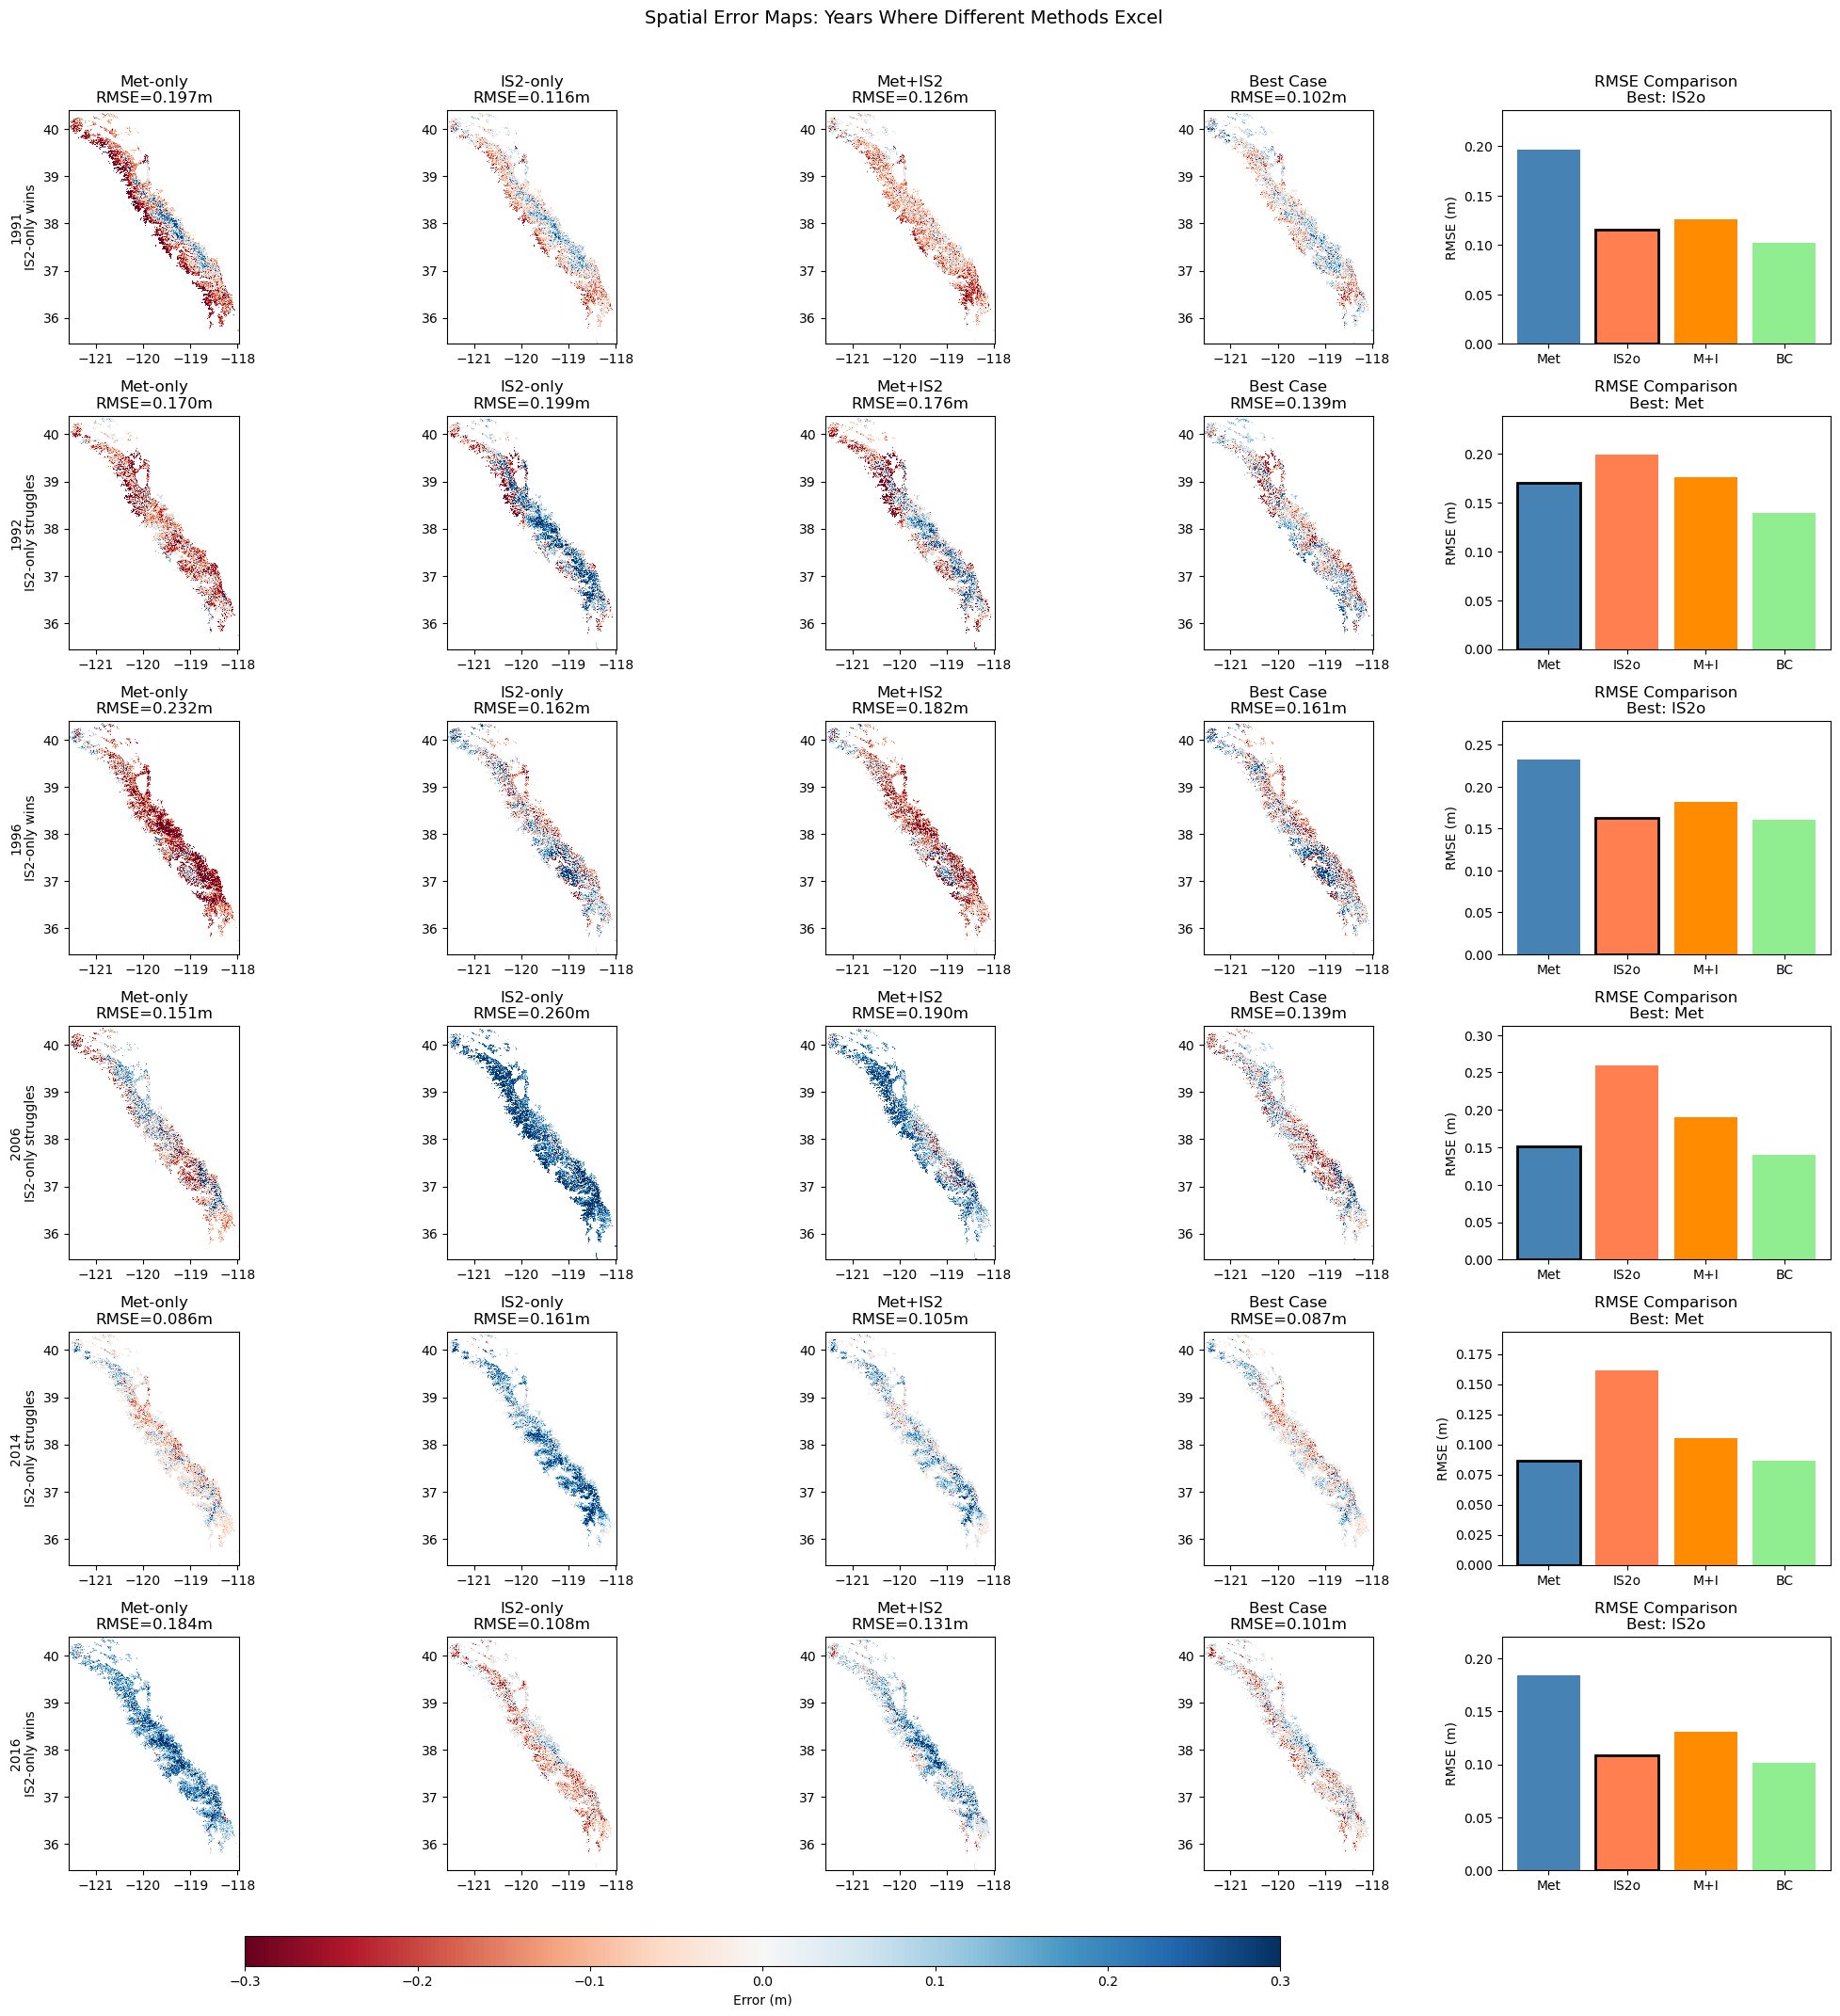


RMSE Summary for Selected Years:
--------------------------------------------------------------------------------
Year   Type                   Met-only   IS2-only    Met+IS2       Best
--------------------------------------------------------------------------------
1991   IS2-only wins            0.1968     0.1158     0.1257     0.1020
1992   IS2-only struggles       0.1701     0.1990     0.1764     0.1391
1996   IS2-only wins            0.2318     0.1622     0.1819     0.1609
2006   IS2-only struggles       0.1515     0.2597     0.1903     0.1394
2014   IS2-only struggles       0.0861     0.1613     0.1051     0.0866
2016   IS2-only wins            0.1836     0.1084     0.1305     0.1014

MULTI-METRIC SUMMARY FOR SELECTED YEARS (RMSE / Correlation R / Volume Bias %)
Year   Metric           Met-only       IS2-only        Met+IS2 Winner      
----------------------------------------------------------------------------------------------------
1991   RMSE(m)            0.1968         0.

In [155]:
# === Spatial Error Maps for Years Where Methods Struggle ===
# Years where IS2-only struggles (much worse than Met-only): 1992, 2006, 2014
# Years where Met-only struggles (IS2-only does better): 1991, 1996, 2016

# Interesting years to visualize
interesting_years = [
    (1991, 'IS2-only wins'),  # 0.197 met vs 0.116 is2only
    (1992, 'IS2-only struggles'),  # 0.170 met vs 0.199 is2only
    (1996, 'IS2-only wins'),  # 0.232 met vs 0.162 is2only
    (2006, 'IS2-only struggles'),  # 0.151 met vs 0.260 is2only
    (2014, 'IS2-only struggles'),  # 0.086 met vs 0.161 is2only
    (2016, 'IS2-only wins'),  # 0.184 met vs 0.108 is2only
]

fig, axes = plt.subplots(len(interesting_years), 5, figsize=(20, len(interesting_years)*3.5))

vmin, vmax = -0.3, 0.3
cmap = 'RdBu'

for i, (year, label) in enumerate(interesting_years):
    # Get error stats for this year
    yr_stats = error_stats_df[error_stats_df['water_year'] == year].iloc[0]
    
    # Get time index
    time_idx = list(all_years).index(year)
    
    # Get error maps
    met_error = loocv_ds['error'].isel(time=time_idx)
    is2only_error = loocv_ds['is2only_error'].isel(time=time_idx)
    is2_error = loocv_ds['is2_error'].isel(time=time_idx)
    bc_error = loocv_ds['bestcase_error'].isel(time=time_idx)
    
    # Met-only error
    ax = axes[i, 0]
    im = met_error.plot(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
    ax.set_title(f'Met-only\nRMSE={yr_stats["rmse"]:.3f}m')
    ax.set_xlabel('')
    ax.set_ylabel(f'{year}\n{label}' if i == 0 else f'{year}\n{label}', fontsize=10)
    ax.set_aspect('equal')
    
    # IS2-only error
    ax = axes[i, 1]
    is2only_error.plot(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
    ax.set_title(f'IS2-only\nRMSE={yr_stats["is2only_rmse"]:.3f}m')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')
    
    # Met+IS2 error
    ax = axes[i, 2]
    is2_error.plot(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
    ax.set_title(f'Met+IS2\nRMSE={yr_stats["is2_rmse"]:.3f}m')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')
    
    # Best case error
    ax = axes[i, 3]
    bc_error.plot(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
    ax.set_title(f'Best Case\nRMSE={yr_stats["bestcase_rmse"]:.3f}m')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')
    
    # Summary bar chart for this year
    ax = axes[i, 4]
    methods = ['Met', 'IS2o', 'M+I', 'BC']
    rmses = [yr_stats['rmse'], yr_stats['is2only_rmse'], yr_stats['is2_rmse'], yr_stats['bestcase_rmse']]
    colors = ['steelblue', 'coral', 'darkorange', 'lightgreen']
    bars = ax.bar(methods, rmses, color=colors)
    ax.set_ylabel('RMSE (m)')
    ax.set_ylim(0, max(rmses) * 1.2)
    # Highlight the best (lowest RMSE, excluding BC)
    min_idx = np.argmin(rmses[:3])
    bars[min_idx].set_edgecolor('black')
    bars[min_idx].set_linewidth(2)
    ax.set_title(f'RMSE Comparison\nBest: {methods[min_idx]}')

# Add colorbar
cbar_ax = fig.add_axes([0.15, 0.02, 0.55, 0.015])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Error (m)')

plt.suptitle('Spatial Error Maps: Years Where Different Methods Excel', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Summary table
print("\nRMSE Summary for Selected Years:")
print("-" * 80)
print(f"{'Year':<6} {'Type':<20} {'Met-only':>10} {'IS2-only':>10} {'Met+IS2':>10} {'Best':>10}")
print("-" * 80)
for year, label in interesting_years:
    yr_stats = error_stats_df[error_stats_df['water_year'] == year].iloc[0]
    rmses = [yr_stats['rmse'], yr_stats['is2only_rmse'], yr_stats['is2_rmse'], yr_stats['bestcase_rmse']]
    best_method = ['Met-only', 'IS2-only', 'Met+IS2'][np.argmin(rmses[:3])]
    combined_vs_best = yr_stats['is2_rmse'] - min(yr_stats['rmse'], yr_stats['is2only_rmse'])
    print(f"{year:<6} {label:<20} {yr_stats['rmse']:>10.4f} {yr_stats['is2only_rmse']:>10.4f} {yr_stats['is2_rmse']:>10.4f} {yr_stats['bestcase_rmse']:>10.4f}")

# Multi-metric summary table
print("\n" + "="*100)
print("MULTI-METRIC SUMMARY FOR SELECTED YEARS (RMSE / Correlation R / Volume Bias %)")
print("="*100)
print(f"{'Year':<6} {'Metric':<10} {'Met-only':>14} {'IS2-only':>14} {'Met+IS2':>14} {'Winner':<12}")
print("-"*100)
for year, label in interesting_years:
    yr_stats = error_stats_df[error_stats_df['water_year'] == year].iloc[0]
    
    # RMSE row
    rmses = [yr_stats['rmse'], yr_stats['is2only_rmse'], yr_stats['is2_rmse']]
    rmse_winner = ['Met-only', 'IS2-only', 'Met+IS2'][np.argmin(rmses)]
    print(f"{year:<6} {'RMSE(m)':<10} {yr_stats['rmse']:>14.4f} {yr_stats['is2only_rmse']:>14.4f} {yr_stats['is2_rmse']:>14.4f} {rmse_winner:<12}")
    
    # Correlation row
    rs = [yr_stats['r'], yr_stats['is2only_r'], yr_stats['is2_r']]
    r_winner = ['Met-only', 'IS2-only', 'Met+IS2'][np.argmax(rs)]
    print(f"{'':6} {'R':<10} {yr_stats['r']:>14.4f} {yr_stats['is2only_r']:>14.4f} {yr_stats['is2_r']:>14.4f} {r_winner:<12}")
    
    # Percent bias row
    pbs = [abs(yr_stats['pbias']), abs(yr_stats['is2only_pbias']), abs(yr_stats['is2_pbias'])]
    pb_winner = ['Met-only', 'IS2-only', 'Met+IS2'][np.argmin(pbs)]
    print(f"{'':6} {'|Pbias|%':<10} {abs(yr_stats['pbias']):>14.2f} {abs(yr_stats['is2only_pbias']):>14.2f} {abs(yr_stats['is2_pbias']):>14.2f} {pb_winner:<12}")
    
    # Count wins
    wins = {'Met-only': 0, 'IS2-only': 0, 'Met+IS2': 0}
    wins[rmse_winner] += 1
    wins[r_winner] += 1
    wins[pb_winner] += 1
    overall = max(wins, key=wins.get)
    print(f"{'':6} {'OVERALL':<10} {wins['Met-only']}/3{' ':>10} {wins['IS2-only']}/3{' ':>10} {wins['Met+IS2']}/3{' ':>10} {overall:<12}")
    print("-"*100)

In [153]:
# === Multi-Metric Winner Analysis ===
# Evaluate winners based on RMSE, Correlation, and Percent Volume Bias

print("="*90)
print("MULTI-METRIC WINNER ANALYSIS: RMSE, Correlation, and Volume Bias")
print("="*90)

# Create a comprehensive comparison table
multi_metric_results = []

for _, row in error_stats_df.iterrows():
    yr = int(row['water_year'])
    
    # Extract all metrics for each method
    metrics = {
        'Met-only': {
            'rmse': row['rmse'],
            'r': row['r'],
            'pbias': row['pbias']
        },
        'IS2-only': {
            'rmse': row['is2only_rmse'],
            'r': row['is2only_r'],
            'pbias': row['is2only_pbias']
        },
        'Met+IS2': {
            'rmse': row['is2_rmse'],
            'r': row['is2_r'],
            'pbias': row['is2_pbias']
        }
    }
    
    # Determine winner for each metric
    # RMSE: lower is better
    rmse_vals = {m: metrics[m]['rmse'] for m in metrics}
    rmse_winner = min(rmse_vals, key=rmse_vals.get)
    
    # Correlation: higher is better
    r_vals = {m: metrics[m]['r'] for m in metrics}
    r_winner = max(r_vals, key=r_vals.get)
    
    # Percent bias: closer to 0 is better (use absolute value)
    pbias_vals = {m: abs(metrics[m]['pbias']) for m in metrics}
    pbias_winner = min(pbias_vals, key=pbias_vals.get)
    
    # Count wins per method
    wins = {'Met-only': 0, 'IS2-only': 0, 'Met+IS2': 0}
    wins[rmse_winner] += 1
    wins[r_winner] += 1
    wins[pbias_winner] += 1
    
    # Overall winner based on majority
    overall_winner = max(wins, key=wins.get)
    max_wins = wins[overall_winner]
    # Handle ties
    tied_methods = [m for m, w in wins.items() if w == max_wins]
    is_tie = len(tied_methods) > 1
    
    multi_metric_results.append({
        'year': yr,
        'rmse_winner': rmse_winner,
        'r_winner': r_winner,
        'pbias_winner': pbias_winner,
        'met_wins': wins['Met-only'],
        'is2only_wins': wins['IS2-only'],
        'metis2_wins': wins['Met+IS2'],
        'overall_winner': overall_winner if not is_tie else f"Tie: {'/'.join(tied_methods)}",
        # Store actual values
        'met_rmse': metrics['Met-only']['rmse'],
        'is2only_rmse': metrics['IS2-only']['rmse'],
        'metis2_rmse': metrics['Met+IS2']['rmse'],
        'met_r': metrics['Met-only']['r'],
        'is2only_r': metrics['IS2-only']['r'],
        'metis2_r': metrics['Met+IS2']['r'],
        'met_pbias': metrics['Met-only']['pbias'],
        'is2only_pbias': metrics['IS2-only']['pbias'],
        'metis2_pbias': metrics['Met+IS2']['pbias']
    })

multi_metric_df = pd.DataFrame(multi_metric_results)

# Print detailed table
print("\nYear-by-Year Results (winner per metric: lower RMSE, higher R, lower |pbias|):")
print("-"*90)
print(f"{'Year':<6} {'RMSE Winner':<12} {'R Winner':<12} {'PBias Winner':<14} {'Met':>4} {'IS2o':>4} {'M+I':>4} {'Overall Winner':<20}")
print("-"*90)
for _, row in multi_metric_df.iterrows():
    print(f"{row['year']:<6} {row['rmse_winner']:<12} {row['r_winner']:<12} {row['pbias_winner']:<14} {row['met_wins']:>4} {row['is2only_wins']:>4} {row['metis2_wins']:>4} {row['overall_winner']:<20}")

# Summary statistics
print("\n" + "="*90)
print("SUMMARY: How Often Each Method Wins Each Metric")
print("="*90)
print(f"\n{'Metric':<20} {'Met-only':>12} {'IS2-only':>12} {'Met+IS2':>12}")
print("-"*60)
rmse_counts = multi_metric_df['rmse_winner'].value_counts()
r_counts = multi_metric_df['r_winner'].value_counts()
pbias_counts = multi_metric_df['pbias_winner'].value_counts()
overall_counts = multi_metric_df['overall_winner'].value_counts()

for method in ['Met-only', 'IS2-only', 'Met+IS2']:
    print(f"RMSE wins: {rmse_counts.get(method, 0)} | R wins: {r_counts.get(method, 0)} | Pbias wins: {pbias_counts.get(method, 0)}")
    
print(f"\n{'RMSE wins':<20} {rmse_counts.get('Met-only', 0):>12} {rmse_counts.get('IS2-only', 0):>12} {rmse_counts.get('Met+IS2', 0):>12}")
print(f"{'Correlation wins':<20} {r_counts.get('Met-only', 0):>12} {r_counts.get('IS2-only', 0):>12} {r_counts.get('Met+IS2', 0):>12}")
print(f"{'% Volume wins':<20} {pbias_counts.get('Met-only', 0):>12} {pbias_counts.get('IS2-only', 0):>12} {pbias_counts.get('Met+IS2', 0):>12}")

# Overall winner categorization
print("\n" + "="*90)
print("OVERALL WINNER (majority of 3 metrics)")
print("="*90)
for winner, count in overall_counts.items():
    pct = count / len(multi_metric_df) * 100
    years = multi_metric_df[multi_metric_df['overall_winner'] == winner]['year'].tolist()
    print(f"\n{winner}: {count} years ({pct:.1f}%)")
    print(f"  Years: {years}")

# Mean metrics summary
print("\n" + "="*90)
print("MEAN VALUES BY METHOD")
print("="*90)
print(f"\n{'Metric':<25} {'Met-only':>12} {'IS2-only':>12} {'Met+IS2':>12} {'Best':>8}")
print("-"*75)
print(f"{'RMSE (m)':<25} {error_stats_df['rmse'].mean():>12.4f} {error_stats_df['is2only_rmse'].mean():>12.4f} {error_stats_df['is2_rmse'].mean():>12.4f} {'Met+IS2':>8}")
print(f"{'Correlation (R)':<25} {error_stats_df['r'].mean():>12.4f} {error_stats_df['is2only_r'].mean():>12.4f} {error_stats_df['is2_r'].mean():>12.4f} {'Met+IS2':>8}")
print(f"{'Volume Bias (% abs)':<25} {error_stats_df['pbias'].abs().mean():>12.2f} {error_stats_df['is2only_pbias'].abs().mean():>12.2f} {error_stats_df['is2_pbias'].abs().mean():>12.2f} {'Met+IS2':>8}")

MULTI-METRIC WINNER ANALYSIS: RMSE, Correlation, and Volume Bias

Year-by-Year Results (winner per metric: lower RMSE, higher R, lower |pbias|):
------------------------------------------------------------------------------------------
Year   RMSE Winner  R Winner     PBias Winner    Met IS2o  M+I Overall Winner      
------------------------------------------------------------------------------------------
1985   IS2-only     IS2-only     Met+IS2           0    2    1 IS2-only            
1986   IS2-only     Met+IS2      Met-only          1    1    1 Tie: Met-only/IS2-only/Met+IS2
1987   IS2-only     IS2-only     IS2-only          0    3    0 IS2-only            
1988   Met-only     Met-only     Met-only          3    0    0 Met-only            
1989   Met+IS2      IS2-only     Met+IS2           0    1    2 Met+IS2             
1990   Met+IS2      Met+IS2      Met+IS2           0    0    3 Met+IS2             
1991   IS2-only     Met+IS2      IS2-only          0    2    1 IS2-only    

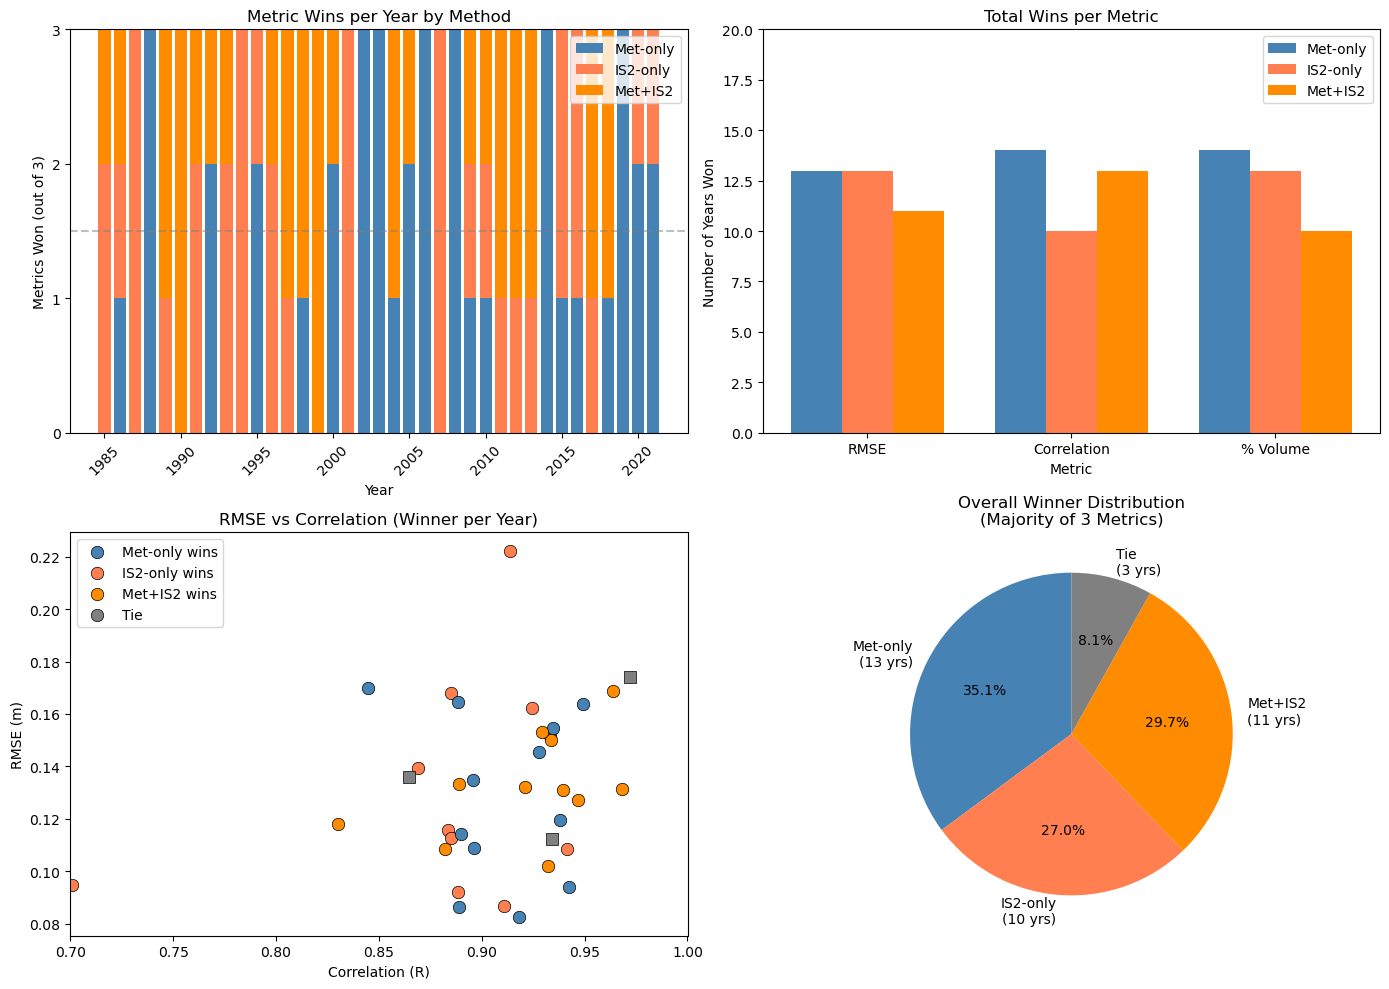


KEY FINDINGS:
1. Met+IS2 has the best MEAN performance across all metrics
   - Lowest RMSE: 0.1374 m
   - Highest R: 0.9051
   - Lowest |pbias|: 11.40%

2. On a per-year basis:
   - Met-only is best in 13 years
   - IS2-only is best in 10 years
   - Met+IS2 is best in 11 years
   - 3 years are ties

3. The methods have complementary strengths - combining them leverages both


In [154]:
# === Multi-Metric Winner Visualization ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Stacked bar: Wins per year by method per metric
ax = axes[0, 0]
x = np.arange(len(multi_metric_df))
width = 0.8
colors = {'Met-only': 'steelblue', 'IS2-only': 'coral', 'Met+IS2': 'darkorange'}

# Create stacked bars showing which method won each metric per year
bottom = np.zeros(len(multi_metric_df))
for method in ['Met-only', 'IS2-only', 'Met+IS2']:
    wins = multi_metric_df.apply(lambda row: 
        (1 if row['rmse_winner'] == method else 0) +
        (1 if row['r_winner'] == method else 0) +
        (1 if row['pbias_winner'] == method else 0), axis=1).values
    ax.bar(x, wins, width, bottom=bottom, label=method, color=colors[method])
    bottom += wins

ax.set_xlabel('Year')
ax.set_ylabel('Metrics Won (out of 3)')
ax.set_title('Metric Wins per Year by Method')
ax.set_xticks(x[::5])
ax.set_xticklabels(multi_metric_df['year'].values[::5], rotation=45)
ax.legend(loc='upper right')
ax.axhline(y=1.5, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks([0, 1, 2, 3])

# 2. Summary: Total wins per metric per method  
ax = axes[0, 1]
metrics = ['RMSE', 'Correlation', '% Volume']
x = np.arange(len(metrics))
width = 0.25

rmse_wins = [
    (multi_metric_df['rmse_winner'] == 'Met-only').sum(),
    (multi_metric_df['rmse_winner'] == 'IS2-only').sum(),
    (multi_metric_df['rmse_winner'] == 'Met+IS2').sum()
]
r_wins = [
    (multi_metric_df['r_winner'] == 'Met-only').sum(),
    (multi_metric_df['r_winner'] == 'IS2-only').sum(),
    (multi_metric_df['r_winner'] == 'Met+IS2').sum()
]
pbias_wins = [
    (multi_metric_df['pbias_winner'] == 'Met-only').sum(),
    (multi_metric_df['pbias_winner'] == 'IS2-only').sum(),
    (multi_metric_df['pbias_winner'] == 'Met+IS2').sum()
]

methods_order = ['Met-only', 'IS2-only', 'Met+IS2']
method_wins = {
    'Met-only': [rmse_wins[0], r_wins[0], pbias_wins[0]],
    'IS2-only': [rmse_wins[1], r_wins[1], pbias_wins[1]],
    'Met+IS2': [rmse_wins[2], r_wins[2], pbias_wins[2]]
}

for i, method in enumerate(methods_order):
    ax.bar(x + i*width, method_wins[method], width, label=method, color=colors[method])

ax.set_xlabel('Metric')
ax.set_ylabel('Number of Years Won')
ax.set_title('Total Wins per Metric')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 20)

# 3. Scatter: RMSE vs Correlation colored by overall winner
ax = axes[1, 0]
winner_colors = {
    'Met-only': 'steelblue', 
    'IS2-only': 'coral', 
    'Met+IS2': 'darkorange',
    'Tie: Met-only/IS2-only/Met+IS2': 'gray'
}

for winner in multi_metric_df['overall_winner'].unique():
    subset = multi_metric_df[multi_metric_df['overall_winner'] == winner]
    # Plot the winning method's values
    for _, row in subset.iterrows():
        if 'Met-only' in winner and 'Tie' not in winner:
            ax.scatter(row['met_r'], row['met_rmse'], c=winner_colors.get(winner, 'gray'), 
                      s=80, edgecolors='black', linewidth=0.5)
        elif 'IS2-only' in winner and 'Tie' not in winner:
            ax.scatter(row['is2only_r'], row['is2only_rmse'], c=winner_colors.get(winner, 'gray'),
                      s=80, edgecolors='black', linewidth=0.5)
        elif 'Met+IS2' in winner and 'Tie' not in winner:
            ax.scatter(row['metis2_r'], row['metis2_rmse'], c=winner_colors.get(winner, 'gray'),
                      s=80, edgecolors='black', linewidth=0.5)
        else:  # Tie
            ax.scatter(row['metis2_r'], row['metis2_rmse'], c='gray', s=80, 
                      edgecolors='black', linewidth=0.5, marker='s')

# Add legend
for method, color in [('Met-only wins', 'steelblue'), ('IS2-only wins', 'coral'), 
                       ('Met+IS2 wins', 'darkorange'), ('Tie', 'gray')]:
    ax.scatter([], [], c=color, label=method, s=80, edgecolors='black', linewidth=0.5)
ax.legend(loc='upper left')
ax.set_xlabel('Correlation (R)')
ax.set_ylabel('RMSE (m)')
ax.set_title('RMSE vs Correlation (Winner per Year)')
ax.set_xlim(0.7, 1.0)

# 4. Overall winner pie chart
ax = axes[1, 1]
overall_counts = multi_metric_df['overall_winner'].value_counts()
labels = []
sizes = []
pie_colors = []
for winner in ['Met-only', 'IS2-only', 'Met+IS2', 'Tie: Met-only/IS2-only/Met+IS2']:
    if winner in overall_counts.index:
        label = winner.replace('Tie: Met-only/IS2-only/Met+IS2', 'Tie')
        labels.append(f"{label}\n({overall_counts[winner]} yrs)")
        sizes.append(overall_counts[winner])
        pie_colors.append(winner_colors.get(winner, 'gray'))

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=pie_colors, autopct='%1.1f%%',
                                   startangle=90, textprops={'fontsize': 10})
ax.set_title('Overall Winner Distribution\n(Majority of 3 Metrics)')

plt.tight_layout()
plt.show()

# Print conclusive summary
print("\n" + "="*90)
print("KEY FINDINGS:")
print("="*90)
print(f"1. Met+IS2 has the best MEAN performance across all metrics")
print(f"   - Lowest RMSE: {error_stats_df['is2_rmse'].mean():.4f} m")
print(f"   - Highest R: {error_stats_df['is2_r'].mean():.4f}")
print(f"   - Lowest |pbias|: {error_stats_df['is2_pbias'].abs().mean():.2f}%")
print(f"\n2. On a per-year basis:")
print(f"   - Met-only is best in {(multi_metric_df['overall_winner'] == 'Met-only').sum()} years")
print(f"   - IS2-only is best in {(multi_metric_df['overall_winner'] == 'IS2-only').sum()} years")
print(f"   - Met+IS2 is best in {(multi_metric_df['overall_winner'] == 'Met+IS2').sum()} years")
print(f"   - {(multi_metric_df['overall_winner'].str.contains('Tie')).sum()} years are ties")
print(f"\n3. The methods have complementary strengths - combining them leverages both")

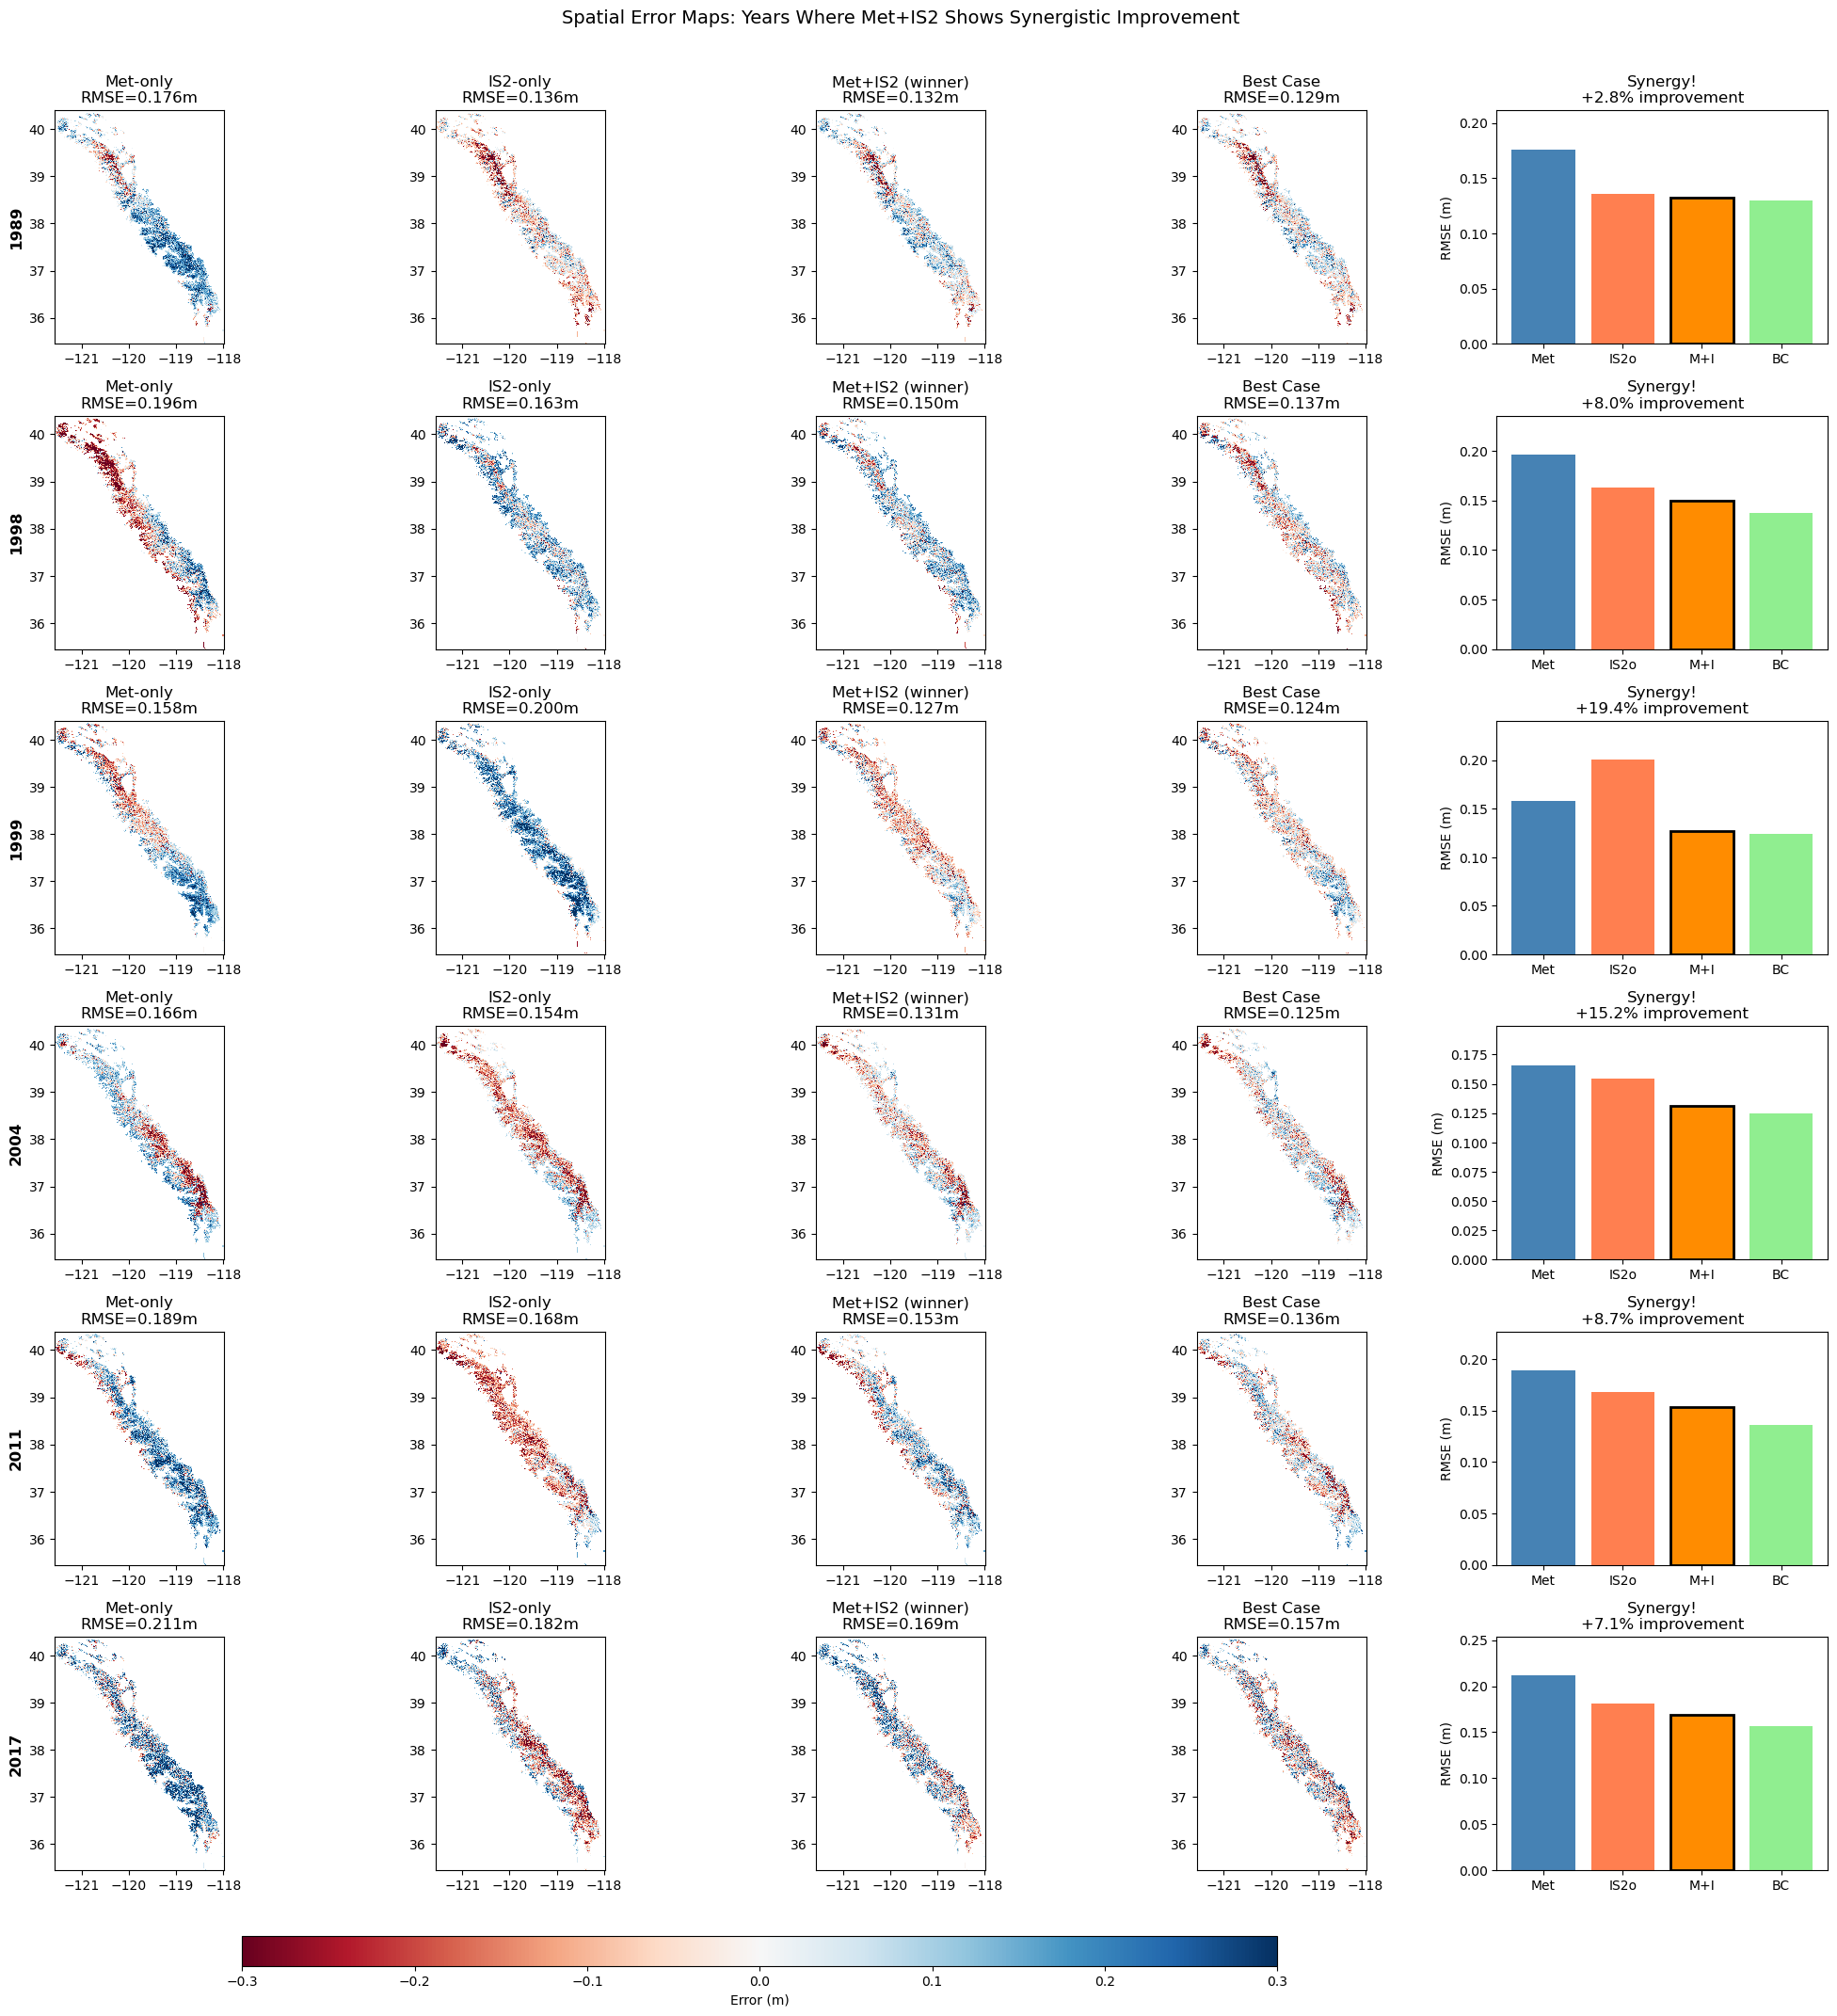

In [151]:
# === Spatial Error Maps: Years with Synergistic Improvement ===
# Years where Met+IS2 beats both individual methods

synergy_years_to_plot = [1989, 1998, 1999, 2004, 2011, 2017]  # Sample of best synergy years

fig, axes = plt.subplots(len(synergy_years_to_plot), 5, figsize=(20, len(synergy_years_to_plot)*3.5))

vmin, vmax = -0.3, 0.3
cmap = 'RdBu'

for i, year in enumerate(synergy_years_to_plot):
    # Get error stats for this year
    yr_stats = error_stats_df[error_stats_df['water_year'] == year].iloc[0]
    
    # Get time index
    time_idx = list(all_years).index(year)
    
    # Get error maps
    met_error = loocv_ds['error'].isel(time=time_idx)
    is2only_error = loocv_ds['is2only_error'].isel(time=time_idx)
    is2_error = loocv_ds['is2_error'].isel(time=time_idx)
    bc_error = loocv_ds['bestcase_error'].isel(time=time_idx)
    
    # Met-only error
    ax = axes[i, 0]
    im = met_error.plot(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
    ax.set_title(f'Met-only\nRMSE={yr_stats["rmse"]:.3f}m')
    ax.set_xlabel('')
    ax.set_ylabel(f'{year}', fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    
    # IS2-only error
    ax = axes[i, 1]
    is2only_error.plot(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
    ax.set_title(f'IS2-only\nRMSE={yr_stats["is2only_rmse"]:.3f}m')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')
    
    # Met+IS2 error
    ax = axes[i, 2]
    is2_error.plot(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
    ax.set_title(f'Met+IS2 (winner)\nRMSE={yr_stats["is2_rmse"]:.3f}m')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')
    
    # Best case error
    ax = axes[i, 3]
    bc_error.plot(ax=ax, vmin=vmin, vmax=vmax, cmap=cmap, add_colorbar=False)
    ax.set_title(f'Best Case\nRMSE={yr_stats["bestcase_rmse"]:.3f}m')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal')
    
    # Summary bar chart for this year
    ax = axes[i, 4]
    methods = ['Met', 'IS2o', 'M+I', 'BC']
    rmses = [yr_stats['rmse'], yr_stats['is2only_rmse'], yr_stats['is2_rmse'], yr_stats['bestcase_rmse']]
    colors = ['steelblue', 'coral', 'darkorange', 'lightgreen']
    bars = ax.bar(methods, rmses, color=colors)
    ax.set_ylabel('RMSE (m)')
    ax.set_ylim(0, max(rmses) * 1.2)
    # Highlight Met+IS2 as the winner
    bars[2].set_edgecolor('black')
    bars[2].set_linewidth(2)
    improvement = (min(yr_stats['rmse'], yr_stats['is2only_rmse']) - yr_stats['is2_rmse']) / min(yr_stats['rmse'], yr_stats['is2only_rmse']) * 100
    ax.set_title(f'Synergy!\n+{improvement:.1f}% improvement')

# Add colorbar
cbar_ax = fig.add_axes([0.15, 0.02, 0.55, 0.015])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Error (m)')

plt.suptitle('Spatial Error Maps: Years Where Met+IS2 Shows Synergistic Improvement', fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

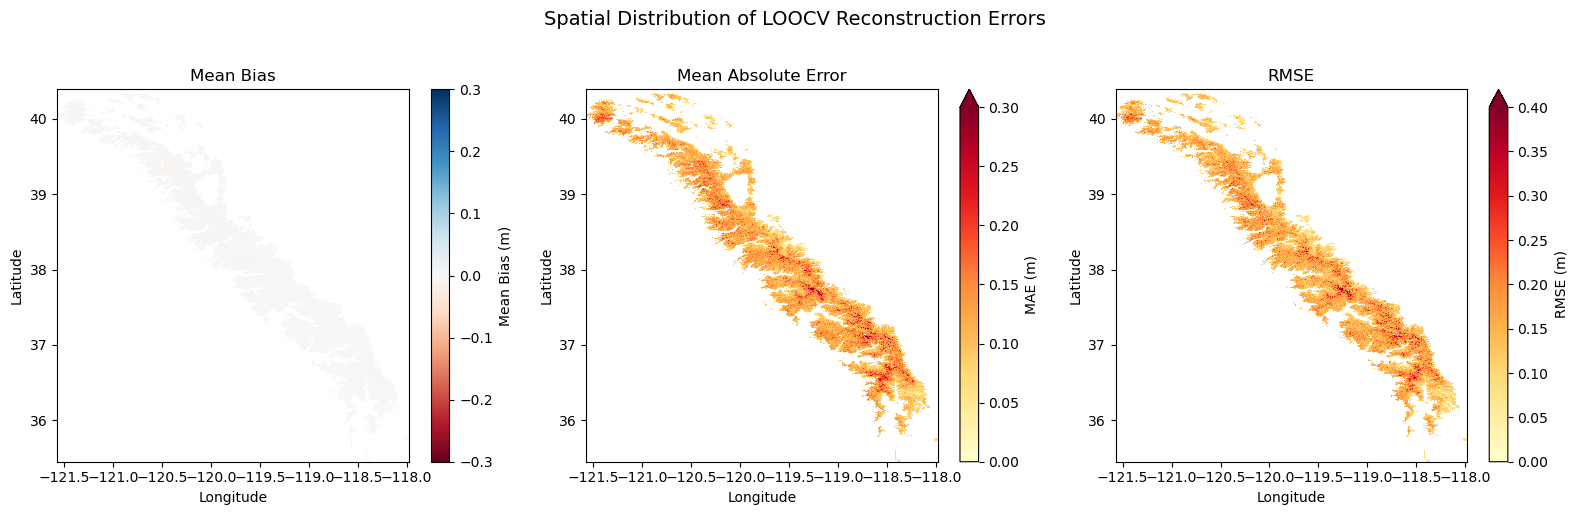

In [67]:
# === Spatial Maps of Mean Errors ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Mean Bias (per pixel)
ax = axes[0]
mean_error = loocv_ds['error'].mean(dim='time')
im = mean_error.plot(ax=ax, cmap='RdBu', vmin=-0.3, vmax=0.3, add_colorbar=True,
                     cbar_kwargs={'label': 'Mean Bias (m)'})
ax.set_title('Mean Bias')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Mean Absolute Error (per pixel)
ax = axes[1]
mae_spatial = np.abs(loocv_ds['error']).mean(dim='time')
im = mae_spatial.plot(ax=ax, cmap='YlOrRd', vmin=0, vmax=0.3, add_colorbar=True,
                      cbar_kwargs={'label': 'MAE (m)'})
ax.set_title('Mean Absolute Error')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# RMSE (per pixel)
ax = axes[2]
rmse_spatial = np.sqrt((loocv_ds['error']**2).mean(dim='time'))
im = rmse_spatial.plot(ax=ax, cmap='YlOrRd', vmin=0, vmax=0.4, add_colorbar=True,
                       cbar_kwargs={'label': 'RMSE (m)'})
ax.set_title('RMSE')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.suptitle('Spatial Distribution of LOOCV Reconstruction Errors', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/loocv_spatial_errors.png', dpi=150, bbox_inches='tight')
plt.show()

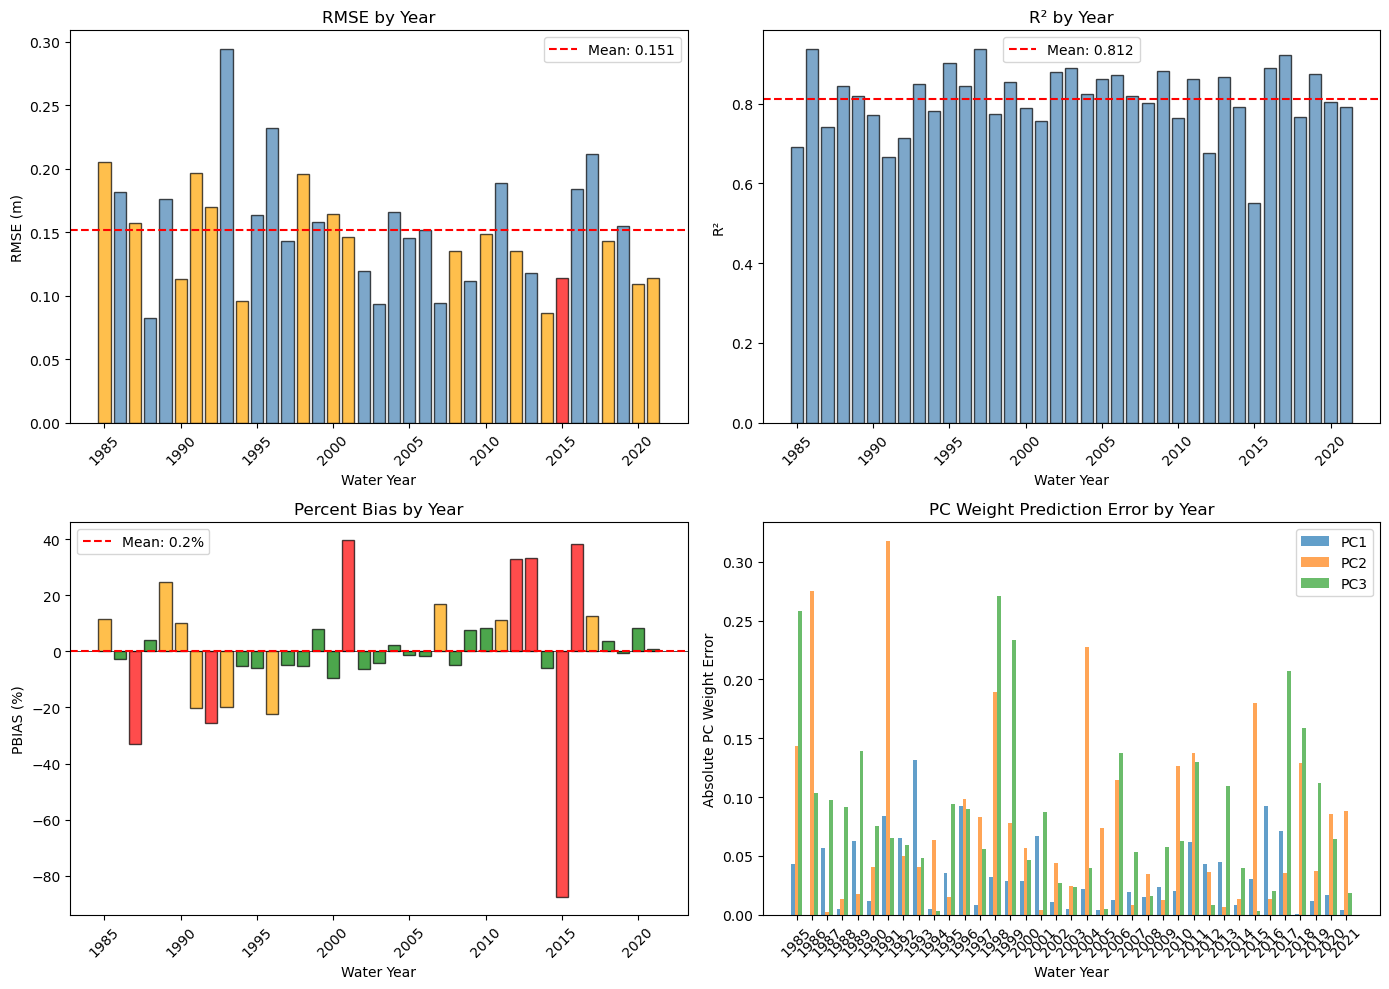


PC Weight Prediction Errors (Mean Absolute):
  PC1: 0.0345
  PC2: 0.0789
  PC3: 0.0841


In [73]:
# === Error Statistics by Year ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

years = error_stats_df['water_year'].values

# RMSE by year
ax = axes[0, 0]
colors = ['steelblue' if r > 0.9 else 'orange' if r > 0.8 else 'red' for r in error_stats_df['r']]
ax.bar(years, error_stats_df['rmse'], color=colors, edgecolor='k', alpha=0.7)
ax.axhline(error_stats_df['rmse'].mean(), color='r', linestyle='--', label=f'Mean: {error_stats_df["rmse"].mean():.3f}')
ax.set_xlabel('Water Year')
ax.set_ylabel('RMSE (m)')
ax.set_title('RMSE by Year')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# R² by year
ax = axes[0, 1]
ax.bar(years, error_stats_df['r_squared'], color='steelblue', edgecolor='k', alpha=0.7)
ax.axhline(error_stats_df['r_squared'].mean(), color='r', linestyle='--', label=f'Mean: {error_stats_df["r_squared"].mean():.3f}')
ax.set_xlabel('Water Year')
ax.set_ylabel('R²')
ax.set_title('R² by Year')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# PBIAS by year
ax = axes[1, 0]
colors = ['green' if abs(p) < 10 else 'orange' if abs(p) < 25 else 'red' for p in error_stats_df['pbias']]
ax.bar(years, error_stats_df['pbias'], color=colors, edgecolor='k', alpha=0.7)
ax.axhline(0, color='k', linestyle='-', linewidth=0.5)
ax.axhline(error_stats_df['pbias'].mean(), color='r', linestyle='--', label=f'Mean: {error_stats_df["pbias"].mean():.1f}%')
ax.set_xlabel('Water Year')
ax.set_ylabel('PBIAS (%)')
ax.set_title('Percent Bias by Year')
ax.legend()
ax.tick_params(axis='x', rotation=45)

# PC weight prediction accuracy
ax = axes[1, 1]
pc1_err = np.abs(error_stats_df['pred_pc1'] - error_stats_df['actual_pc1'])
pc2_err = np.abs(error_stats_df['pred_pc2'] - error_stats_df['actual_pc2'])
pc3_err = np.abs(error_stats_df['pred_pc3'] - error_stats_df['actual_pc3'])
x = np.arange(len(years))
width = 0.25
ax.bar(x - width, pc1_err, width, label='PC1', alpha=0.7)
ax.bar(x, pc2_err, width, label='PC2', alpha=0.7)
ax.bar(x + width, pc3_err, width, label='PC3', alpha=0.7)
ax.set_xlabel('Water Year')
ax.set_ylabel('Absolute PC Weight Error')
ax.set_title('PC Weight Prediction Error by Year')
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.legend()

plt.tight_layout()
#plt.savefig('../figures/loocv_error_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPC Weight Prediction Errors (Mean Absolute):")
print(f"  PC1: {pc1_err.mean():.4f}")
print(f"  PC2: {pc2_err.mean():.4f}")
print(f"  PC3: {pc3_err.mean():.4f}")

Original DEM shape: (20953, 15163)
Original DEM CRS: EPSG:4326
Original DEM resolution: (0.00026949458523585647, -0.00026949458523585647)

Target SWE grid shape: (1047, 796)
Target SWE CRS: EPSG:4326

Reprojected DEM shape: (1047, 796)
Elevation range: 282 - 4230 m


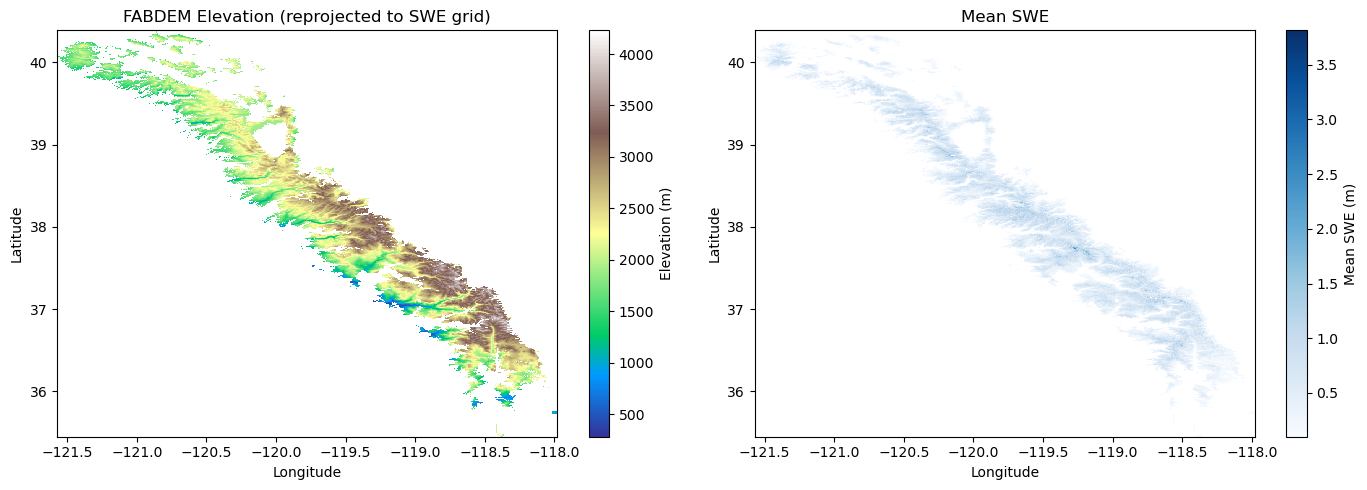

In [74]:
# === Load FABDEM Elevation Data and Reproject to SWE Grid ===
import rioxarray as rxr
from rasterio.enums import Resampling

# Load FABDEM elevation data
dem_path = '../data/misc/fabdem_sierra_nevada.tif'
dem = rxr.open_rasterio(dem_path).squeeze()
print(f"Original DEM shape: {dem.shape}")
print(f"Original DEM CRS: {dem.rio.crs}")
print(f"Original DEM resolution: {dem.rio.resolution()}")

# Get the target grid from the SWE data
target_template = swe_masked.isel(time=0)
print(f"\nTarget SWE grid shape: {target_template.shape}")
print(f"Target SWE CRS: {target_template.rio.crs if hasattr(target_template, 'rio') else 'Not set'}")

# Ensure SWE data has CRS set (EPSG:4326 for WGS84 lat/lon)
if not hasattr(target_template, 'rio') or target_template.rio.crs is None:
    target_template = target_template.rio.write_crs("EPSG:4326")

# Reproject and resample DEM to match SWE grid
dem_reprojected = dem.rio.reproject_match(
    target_template,
    resampling=Resampling.bilinear
)

# Apply the EOF mask
dem_masked = dem_reprojected.where(eof_mask)

print(f"\nReprojected DEM shape: {dem_masked.shape}")
print(f"Elevation range: {float(dem_masked.min()):.0f} - {float(dem_masked.max()):.0f} m")

# Quick plot to verify
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
dem_masked.plot(ax=ax, cmap='terrain', add_colorbar=True, cbar_kwargs={'label': 'Elevation (m)'})
ax.set_title('FABDEM Elevation (reprojected to SWE grid)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax = axes[1]
swe_masked.mean(dim='time').plot(ax=ax, cmap='Blues', add_colorbar=True, cbar_kwargs={'label': 'Mean SWE (m)'})
ax.set_title('Mean SWE')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

In [75]:
# === Analyze Error Distribution by Elevation ===

# Create elevation bins
elev_bins = np.arange(1500, 4500, 250)  # 250m bins from 1500 to 4250m
elev_labels = [f"{b}-{b+250}" for b in elev_bins[:-1]]

# Flatten arrays for analysis
dem_flat = dem_masked.values.flatten()
mean_error_flat = loocv_ds['error'].mean(dim='time').values.flatten()
mean_bc_error_flat = loocv_ds['bestcase_error'].mean(dim='time').values.flatten()
rmse_flat = np.sqrt((loocv_ds['error']**2).mean(dim='time')).values.flatten()
rmse_bc_flat = np.sqrt((loocv_ds['bestcase_error']**2).mean(dim='time')).values.flatten()
mae_flat = np.abs(loocv_ds['error']).mean(dim='time').values.flatten()
mae_bc_flat = np.abs(loocv_ds['bestcase_error']).mean(dim='time').values.flatten()

# Create mask for valid data
valid_mask = ~np.isnan(dem_flat) & ~np.isnan(mean_error_flat)

# Bin the elevation data
elev_binned = np.digitize(dem_flat[valid_mask], elev_bins)

# Calculate statistics by elevation bin
stats_by_elev = []
for i, (low, high) in enumerate(zip(elev_bins[:-1], elev_bins[1:])):
    bin_mask = elev_binned == (i + 1)
    if bin_mask.sum() > 0:
        stats_by_elev.append({
            'elev_bin': f"{low}-{high}",
            'elev_mid': (low + high) / 2,
            'n_pixels': bin_mask.sum(),
            'mean_error': mean_error_flat[valid_mask][bin_mask].mean(),
            'mean_bc_error': mean_bc_error_flat[valid_mask][bin_mask].mean(),
            'rmse': rmse_flat[valid_mask][bin_mask].mean(),
            'rmse_bc': rmse_bc_flat[valid_mask][bin_mask].mean(),
            'mae': mae_flat[valid_mask][bin_mask].mean(),
            'mae_bc': mae_bc_flat[valid_mask][bin_mask].mean(),
            'std_error': mean_error_flat[valid_mask][bin_mask].std()
        })

elev_stats_df = pd.DataFrame(stats_by_elev)
print("Error Statistics by Elevation Band:")
print(elev_stats_df.to_string(index=False))

Error Statistics by Elevation Band:
 elev_bin  elev_mid  n_pixels  mean_error  mean_bc_error     rmse  rmse_bc      mae   mae_bc  std_error
1500-1750    1625.0     12011   -0.000622   6.763695e-08 0.145420 0.115163 0.112160 0.087107   0.002123
1750-2000    1875.0     17831   -0.001175   6.961737e-08 0.145991 0.115039 0.112900 0.087396   0.002432
2000-2250    2125.0     19560   -0.001289   2.023472e-08 0.151233 0.117624 0.117016 0.089406   0.002707
2250-2500    2375.0     15922   -0.000682  -7.336310e-08 0.149761 0.115814 0.115643 0.087883   0.002697
2500-2750    2625.0     13857    0.000201  -1.757152e-07 0.148127 0.113869 0.114300 0.086623   0.002445
2750-3000    2875.0     10610    0.000889  -2.776046e-07 0.155045 0.118085 0.120118 0.090439   0.002153
3000-3250    3125.0      8094    0.001469  -3.510632e-07 0.162060 0.123378 0.125856 0.095109   0.001969
3250-3500    3375.0      5814    0.002150  -4.159650e-07 0.165927 0.126578 0.128926 0.097771   0.001708
3500-3750    3625.0      315

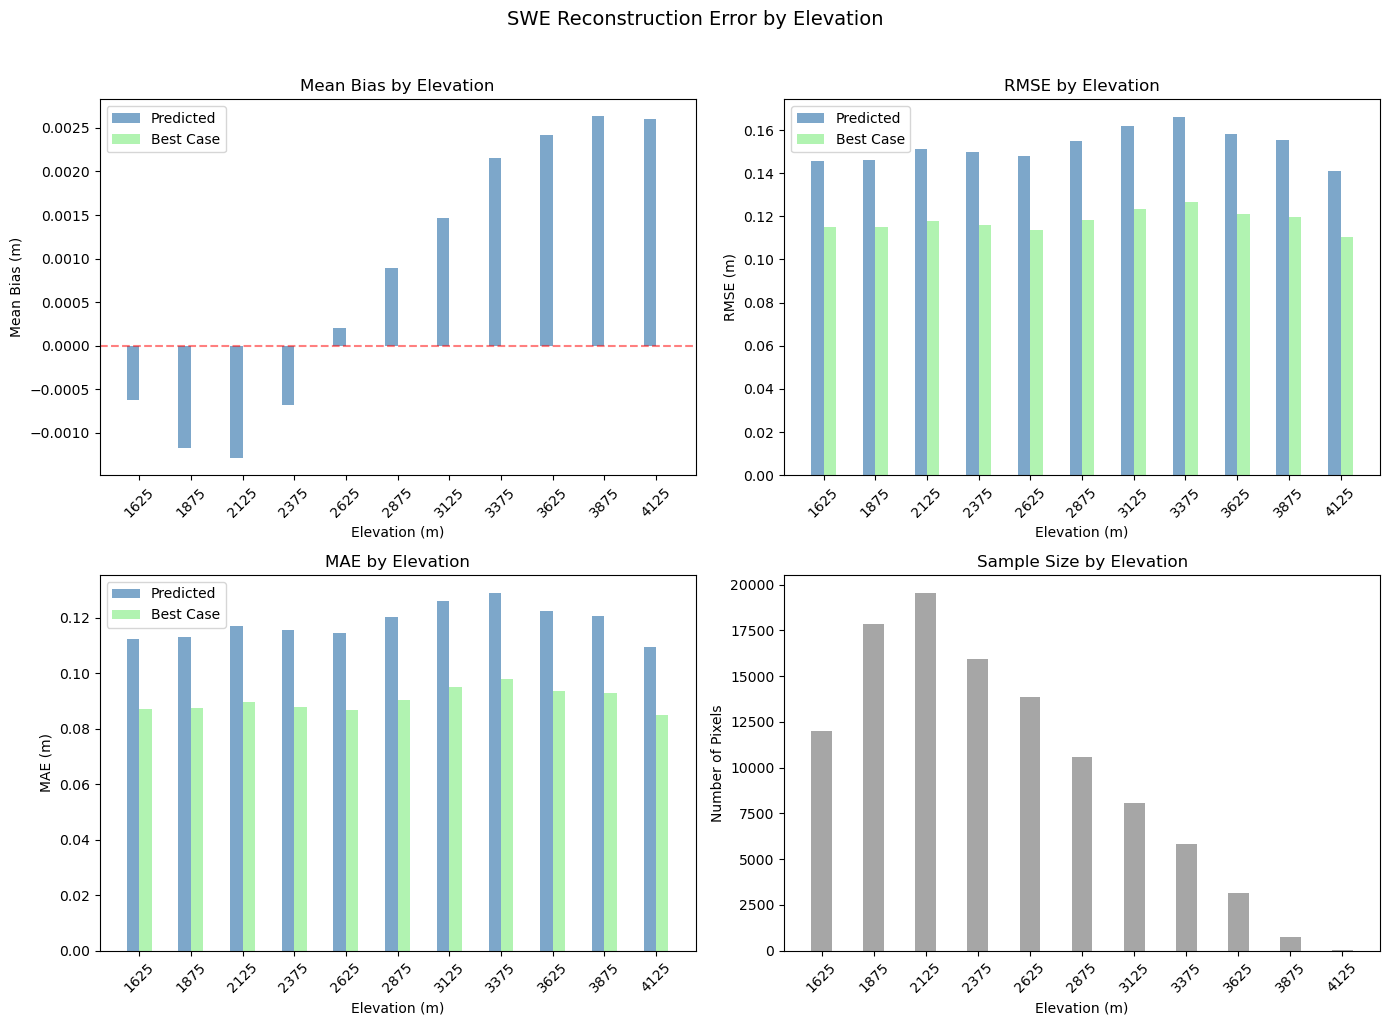


Error increases with elevation:
  Low elev (1500-2000m): RMSE = 0.1457 m
  Mid elev (2000-3000m): RMSE = 0.1510 m
  High elev (>3000m):    RMSE = 0.1566 m


In [ ]:
# === Plot Error Distribution by Elevation ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Mean Bias by Elevation
ax = axes[0, 0]
x = elev_stats_df['elev_mid']
ax.bar(x - 30, elev_stats_df['mean_error'], width=60, label='Predicted', color='steelblue', alpha=0.7)
ax.bar(x + 30, elev_stats_df['mean_bc_error'], width=60, label='Best Case', color='lightgreen', alpha=0.7)
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Mean Bias (m)')
ax.set_title('Mean Bias by Elevation')
ax.legend()
ax.set_xticks(x)
ax.set_xticklabels([f"{int(e)}" for e in x], rotation=45)

# 2. RMSE by Elevation
ax = axes[0, 1]
ax.bar(x - 30, elev_stats_df['rmse'], width=60, label='Predicted', color='steelblue', alpha=0.7)
ax.bar(x + 30, elev_stats_df['rmse_bc'], width=60, label='Best Case', color='lightgreen', alpha=0.7)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('RMSE (m)')
ax.set_title('RMSE by Elevation')
ax.legend()
ax.set_xticks(x)
ax.set_xticklabels([f"{int(e)}" for e in x], rotation=45)

# 3. MAE by Elevation
ax = axes[1, 0]
ax.bar(x - 30, elev_stats_df['mae'], width=60, label='Predicted', color='steelblue', alpha=0.7)
ax.bar(x + 30, elev_stats_df['mae_bc'], width=60, label='Best Case', color='lightgreen', alpha=0.7)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('MAE (m)')
ax.set_title('MAE by Elevation')
ax.legend()
ax.set_xticks(x)
ax.set_xticklabels([f"{int(e)}" for e in x], rotation=45)

# 4. Number of pixels per elevation bin
ax = axes[1, 1]
ax.bar(x, elev_stats_df['n_pixels'], width=100, color='gray', alpha=0.7)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Number of Pixels')
ax.set_title('Sample Size by Elevation')
ax.set_xticks(x)
ax.set_xticklabels([f"{int(e)}" for e in x], rotation=45)

plt.suptitle('SWE Reconstruction Error by Elevation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/loocv_error_by_elevation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nError increases with elevation:")
print(f"  Low elev (1500-2000m): RMSE = {elev_stats_df[elev_stats_df['elev_mid'] < 2000]['rmse'].mean():.4f} m")
print(f"  Mid elev (2000-3000m): RMSE = {elev_stats_df[(elev_stats_df['elev_mid'] >= 2000) & (elev_stats_df['elev_mid'] < 3000)]['rmse'].mean():.4f} m")
print(f"  High elev (>3000m):    RMSE = {elev_stats_df[elev_stats_df['elev_mid'] >= 3000]['rmse'].mean():.4f} m")

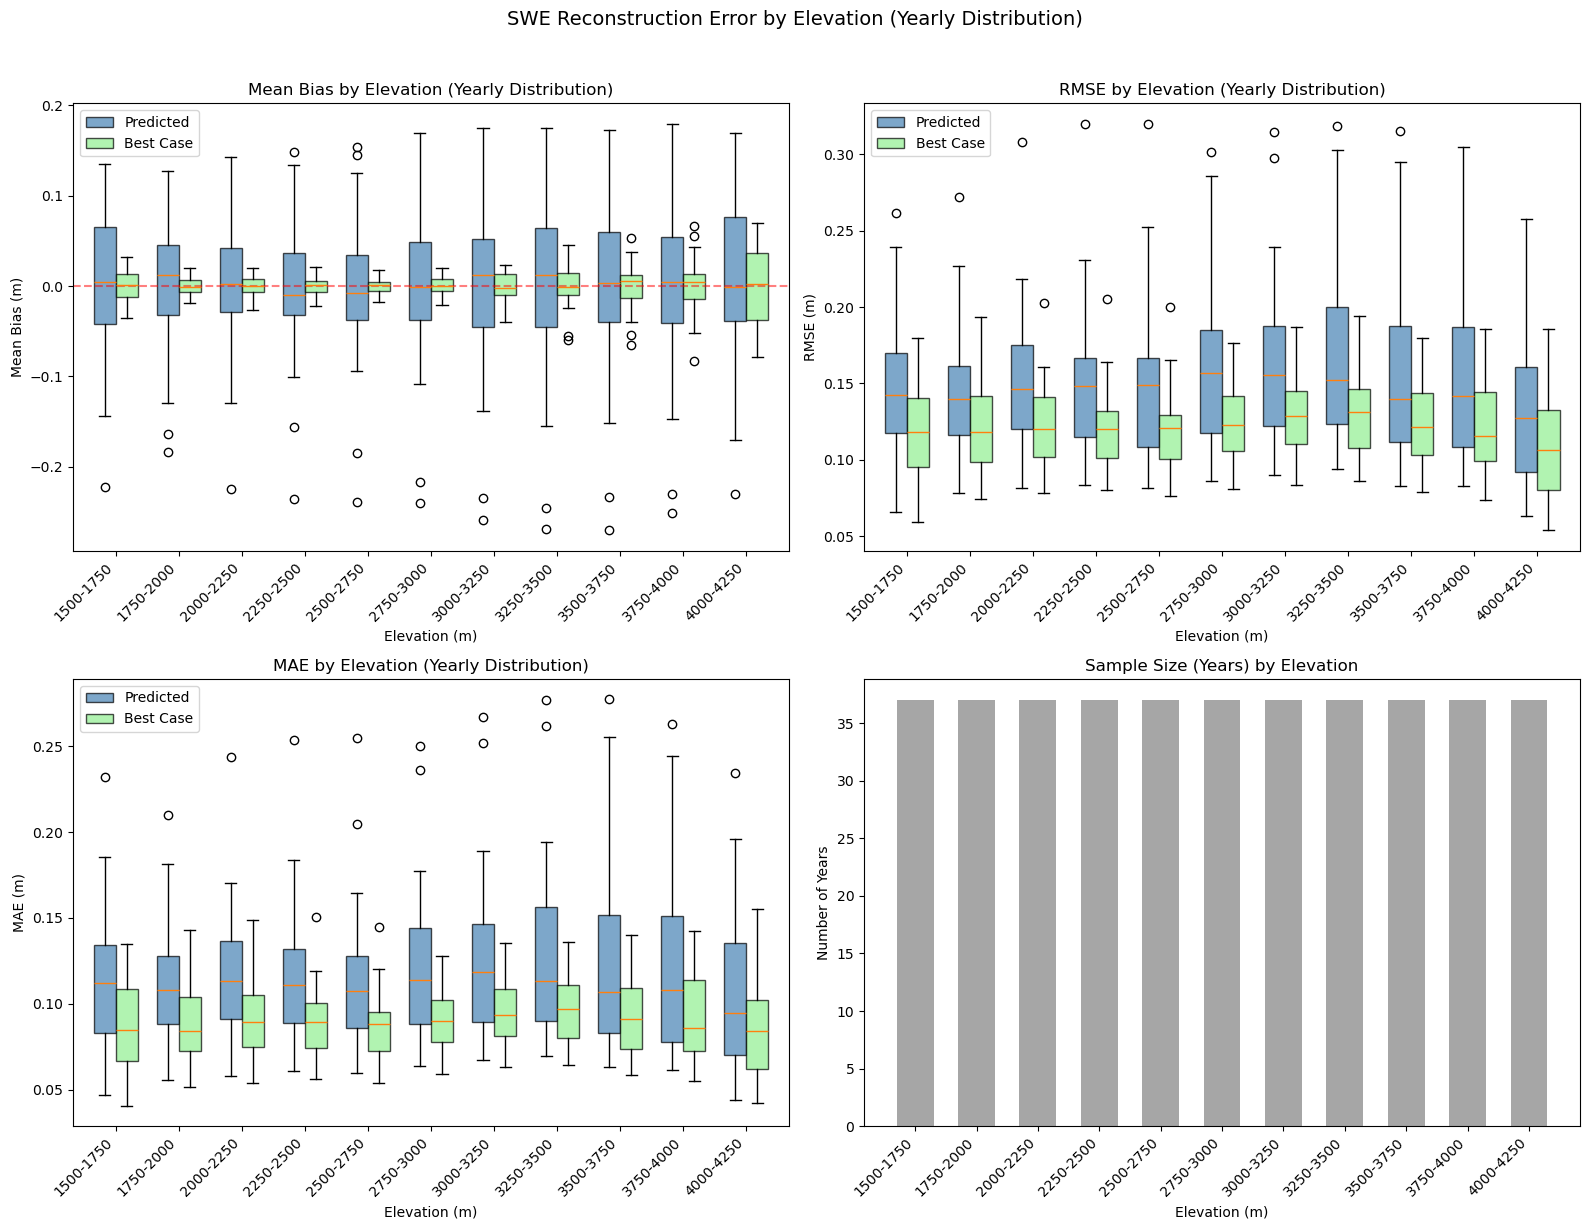


Median RMSE by elevation zone (across years):
  Low elev (<2000m):     0.1422 m
  Mid elev (2000-3000m): 0.1493 m
  High elev (>3000m):    0.1455 m


In [79]:
# === Boxplots: Error by Elevation from Yearly Data ===

# Calculate error statistics by elevation band for EACH year
yearly_elev_stats = []

for yr_idx, year in enumerate(all_years):
    # Get error maps for this year
    error_yr = loocv_ds['error'].isel(time=yr_idx).values.flatten()
    bc_error_yr = loocv_ds['bestcase_error'].isel(time=yr_idx).values.flatten()
    
    # Use same valid mask as before (based on DEM)
    for i, (low, high) in enumerate(zip(elev_bins[:-1], elev_bins[1:])):
        bin_mask = (dem_flat >= low) & (dem_flat < high) & valid_mask
        if bin_mask.sum() > 0:
            yearly_elev_stats.append({
                'water_year': year,
                'elev_bin': f"{low}-{high}",
                'elev_mid': (low + high) / 2,
                'mean_error': np.nanmean(error_yr[bin_mask]),
                'mean_bc_error': np.nanmean(bc_error_yr[bin_mask]),
                'rmse': np.sqrt(np.nanmean(error_yr[bin_mask]**2)),
                'rmse_bc': np.sqrt(np.nanmean(bc_error_yr[bin_mask]**2)),
                'mae': np.nanmean(np.abs(error_yr[bin_mask])),
                'mae_bc': np.nanmean(np.abs(bc_error_yr[bin_mask]))
            })

yearly_elev_df = pd.DataFrame(yearly_elev_stats)

# Get unique elevation bins (sorted by mid elevation)
elev_mids = sorted(yearly_elev_df['elev_mid'].unique())
bin_labels = [f"{int(e-125)}-{int(e+125)}" for e in elev_mids]

# Create boxplot data grouped by elevation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Mean Bias by Elevation
ax = axes[0, 0]
positions = np.arange(len(elev_mids))
width = 0.35

# Predicted
bias_by_elev = [yearly_elev_df[yearly_elev_df['elev_mid'] == e]['mean_error'].values for e in elev_mids]
bp1 = ax.boxplot(bias_by_elev, positions=positions - width/2, widths=width, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

# Best case
bc_bias_by_elev = [yearly_elev_df[yearly_elev_df['elev_mid'] == e]['mean_bc_error'].values for e in elev_mids]
bp2 = ax.boxplot(bc_bias_by_elev, positions=positions + width/2, widths=width, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)

ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Mean Bias (m)')
ax.set_title('Mean Bias by Elevation (Yearly Distribution)')
ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Predicted', 'Best Case'], loc='upper left')

# 2. RMSE by Elevation
ax = axes[0, 1]
rmse_by_elev = [yearly_elev_df[yearly_elev_df['elev_mid'] == e]['rmse'].values for e in elev_mids]
bp1 = ax.boxplot(rmse_by_elev, positions=positions - width/2, widths=width, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

bc_rmse_by_elev = [yearly_elev_df[yearly_elev_df['elev_mid'] == e]['rmse_bc'].values for e in elev_mids]
bp2 = ax.boxplot(bc_rmse_by_elev, positions=positions + width/2, widths=width, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('RMSE (m)')
ax.set_title('RMSE by Elevation (Yearly Distribution)')
ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Predicted', 'Best Case'], loc='upper left')

# 3. MAE by Elevation
ax = axes[1, 0]
mae_by_elev = [yearly_elev_df[yearly_elev_df['elev_mid'] == e]['mae'].values for e in elev_mids]
bp1 = ax.boxplot(mae_by_elev, positions=positions - width/2, widths=width, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

bc_mae_by_elev = [yearly_elev_df[yearly_elev_df['elev_mid'] == e]['mae_bc'].values for e in elev_mids]
bp2 = ax.boxplot(bc_mae_by_elev, positions=positions + width/2, widths=width, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('MAE (m)')
ax.set_title('MAE by Elevation (Yearly Distribution)')
ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Predicted', 'Best Case'], loc='upper left')

# 4. Number of years per elevation bin (should be constant)
ax = axes[1, 1]
n_years_per_bin = [len(yearly_elev_df[yearly_elev_df['elev_mid'] == e]) for e in elev_mids]
ax.bar(positions, n_years_per_bin, width=0.6, color='gray', alpha=0.7)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Number of Years')
ax.set_title('Sample Size (Years) by Elevation')
ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')

plt.suptitle('SWE Reconstruction Error by Elevation (Yearly Distribution)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/loocv_error_by_elevation_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nMedian RMSE by elevation zone (across years):")
low_rmse = yearly_elev_df[yearly_elev_df['elev_mid'] < 2000]['rmse'].median()
mid_rmse = yearly_elev_df[(yearly_elev_df['elev_mid'] >= 2000) & (yearly_elev_df['elev_mid'] < 3000)]['rmse'].median()
high_rmse = yearly_elev_df[yearly_elev_df['elev_mid'] >= 3000]['rmse'].median()
print(f"  Low elev (<2000m):     {low_rmse:.4f} m")
print(f"  Mid elev (2000-3000m): {mid_rmse:.4f} m")
print(f"  High elev (>3000m):    {high_rmse:.4f} m")

EOF Region Pixel Counts:
  EOF2+ / EOF3+: 31,533 pixels
  EOF2+ / EOF3-: 28,043 pixels
  EOF2- / EOF3+: 28,631 pixels
  EOF2- / EOF3-: 28,926 pixels

=== Error Statistics by EOF Region (averaged across years) ===
               mean_error      rmse       mae   rmse_bc  n_pixels
region                                                           
EOF2+ / EOF3+    0.002377  0.170936  0.134284  0.134179   31533.0
EOF2+ / EOF3-   -0.002368  0.158023  0.123073  0.128688   28043.0
EOF2- / EOF3+    0.001485  0.126178  0.099253  0.099995   28631.0
EOF2- / EOF3-   -0.002226  0.138002  0.107577  0.112916   28926.0


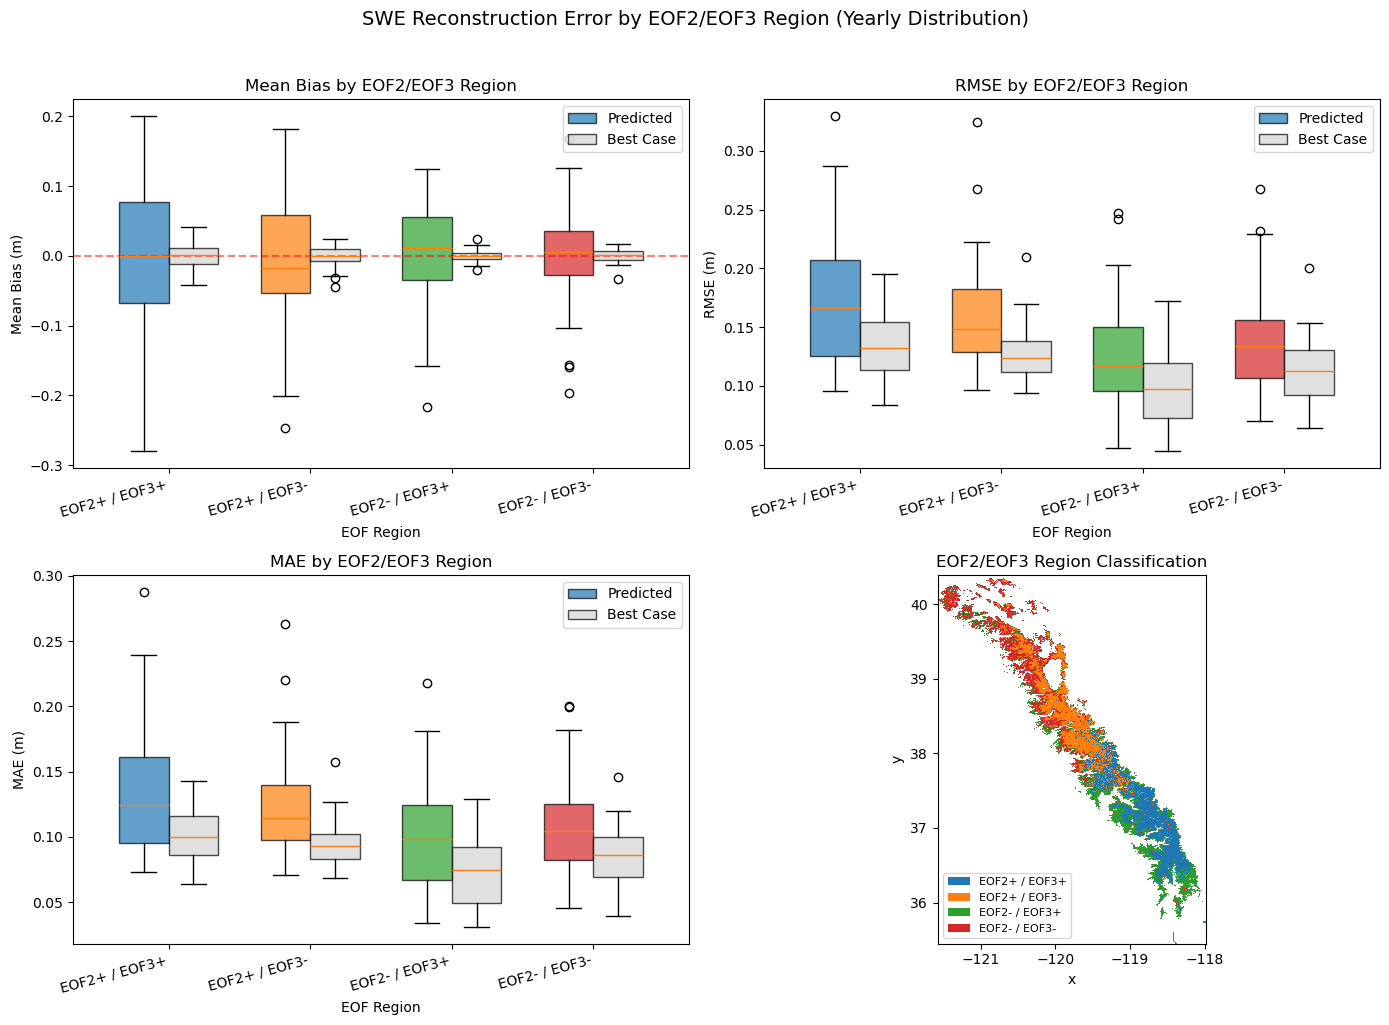


=== Median RMSE by EOF Region (across all years) ===
  EOF2+ / EOF3+: Predicted=0.1667 m, Best Case=0.1321 m
  EOF2+ / EOF3-: Predicted=0.1481 m, Best Case=0.1237 m
  EOF2- / EOF3+: Predicted=0.1166 m, Best Case=0.0977 m
  EOF2- / EOF3-: Predicted=0.1344 m, Best Case=0.1128 m


In [88]:
# === Error Analysis by EOF2/EOF3 Regions ===
# Divide domain into 4 regions based on signs of EOF2 and EOF3

# Get EOF patterns in spatial form (flattened to match analysis domain)
# eof1, eof2, eof3 are already defined above as U_anom_swe[:, i] * S_anom_swe[i]

# Create spatial version of EOF patterns to define regions
eof2_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
eof2_spatial.values = eof2.reshape(-1, 1)
eof2_spatial = eof2_spatial.unstack('space').sortby(['y', 'x']).squeeze()

eof3_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
eof3_spatial.values = eof3.reshape(-1, 1)
eof3_spatial = eof3_spatial.unstack('space').sortby(['y', 'x']).squeeze()

# Get flattened versions aligned with loocv_ds
eof2_flat = eof2_spatial.values.flatten()
eof3_flat = eof3_spatial.values.flatten()

# Define the 4 regions based on signs
region_names = ['EOF2+ / EOF3+', 'EOF2+ / EOF3-', 'EOF2- / EOF3+', 'EOF2- / EOF3-']
region_masks = [
    (eof2_flat > 0) & (eof3_flat > 0),
    (eof2_flat > 0) & (eof3_flat <= 0),
    (eof2_flat <= 0) & (eof3_flat > 0),
    (eof2_flat <= 0) & (eof3_flat <= 0)
]

# Print region sizes
print("EOF Region Pixel Counts:")
for name, mask in zip(region_names, region_masks):
    valid_in_region = mask & ~np.isnan(loocv_ds['error'].isel(time=0).values.flatten())
    print(f"  {name}: {valid_in_region.sum():,} pixels")

# Calculate error statistics by EOF region for EACH year
yearly_eof_stats = []

for yr_idx, year in enumerate(all_years):
    # Get error maps for this year
    error_yr = loocv_ds['error'].isel(time=yr_idx).values.flatten()
    bc_error_yr = loocv_ds['bestcase_error'].isel(time=yr_idx).values.flatten()
    
    for region_idx, (region_name, region_mask) in enumerate(zip(region_names, region_masks)):
        # Combine region mask with valid data mask
        combined_mask = region_mask & ~np.isnan(error_yr)
        
        if combined_mask.sum() > 0:
            yearly_eof_stats.append({
                'water_year': year,
                'region': region_name,
                'region_idx': region_idx,
                'mean_error': np.nanmean(error_yr[combined_mask]),
                'mean_bc_error': np.nanmean(bc_error_yr[combined_mask]),
                'rmse': np.sqrt(np.nanmean(error_yr[combined_mask]**2)),
                'rmse_bc': np.sqrt(np.nanmean(bc_error_yr[combined_mask]**2)),
                'mae': np.nanmean(np.abs(error_yr[combined_mask])),
                'mae_bc': np.nanmean(np.abs(bc_error_yr[combined_mask])),
                'n_pixels': combined_mask.sum()
            })

eof_region_df = pd.DataFrame(yearly_eof_stats)
print("\n=== Error Statistics by EOF Region (averaged across years) ===")
summary = eof_region_df.groupby('region')[['mean_error', 'rmse', 'mae', 'rmse_bc', 'n_pixels']].mean()
print(summary.to_string())

# === Create Boxplots for EOF Regions ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

positions = np.arange(len(region_names))
width = 0.35
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 1. Mean Bias by EOF Region
ax = axes[0, 0]
bias_data = [eof_region_df[eof_region_df['region'] == r]['mean_error'].values for r in region_names]
bc_bias_data = [eof_region_df[eof_region_df['region'] == r]['mean_bc_error'].values for r in region_names]

bp1 = ax.boxplot(bias_data, positions=positions - width/2, widths=width, patch_artist=True)
for i, patch in enumerate(bp1['boxes']):
    patch.set_facecolor(colors[i])
    patch.set_alpha(0.7)

bp2 = ax.boxplot(bc_bias_data, positions=positions + width/2, widths=width, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightgray')
    patch.set_alpha(0.7)

ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('EOF Region')
ax.set_ylabel('Mean Bias (m)')
ax.set_title('Mean Bias by EOF2/EOF3 Region')
ax.set_xticks(positions)
ax.set_xticklabels(region_names, rotation=15, ha='right')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Predicted', 'Best Case'], loc='upper right')

# 2. RMSE by EOF Region
ax = axes[0, 1]
rmse_data = [eof_region_df[eof_region_df['region'] == r]['rmse'].values for r in region_names]
rmse_bc_data = [eof_region_df[eof_region_df['region'] == r]['rmse_bc'].values for r in region_names]

bp1 = ax.boxplot(rmse_data, positions=positions - width/2, widths=width, patch_artist=True)
for i, patch in enumerate(bp1['boxes']):
    patch.set_facecolor(colors[i])
    patch.set_alpha(0.7)

bp2 = ax.boxplot(rmse_bc_data, positions=positions + width/2, widths=width, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightgray')
    patch.set_alpha(0.7)

ax.set_xlabel('EOF Region')
ax.set_ylabel('RMSE (m)')
ax.set_title('RMSE by EOF2/EOF3 Region')
ax.set_xticks(positions)
ax.set_xticklabels(region_names, rotation=15, ha='right')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Predicted', 'Best Case'], loc='upper right')

# 3. MAE by EOF Region
ax = axes[1, 0]
mae_data = [eof_region_df[eof_region_df['region'] == r]['mae'].values for r in region_names]
mae_bc_data = [eof_region_df[eof_region_df['region'] == r]['mae_bc'].values for r in region_names]

bp1 = ax.boxplot(mae_data, positions=positions - width/2, widths=width, patch_artist=True)
for i, patch in enumerate(bp1['boxes']):
    patch.set_facecolor(colors[i])
    patch.set_alpha(0.7)

bp2 = ax.boxplot(mae_bc_data, positions=positions + width/2, widths=width, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('lightgray')
    patch.set_alpha(0.7)

ax.set_xlabel('EOF Region')
ax.set_ylabel('MAE (m)')
ax.set_title('MAE by EOF2/EOF3 Region')
ax.set_xticks(positions)
ax.set_xticklabels(region_names, rotation=15, ha='right')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Predicted', 'Best Case'], loc='upper right')

# 4. Spatial map showing EOF regions
ax = axes[1, 1]

# Create region classification map
region_map = np.full_like(eof2_spatial.values, np.nan)
for region_idx, region_mask in enumerate(region_masks):
    region_map_flat = region_map.flatten()
    region_map_flat[region_mask] = region_idx
    region_map = region_map_flat.reshape(region_map.shape)

# Create a custom colormap
from matplotlib.colors import ListedColormap
cmap = ListedColormap(colors)

im = ax.pcolormesh(eof2_spatial.x, eof2_spatial.y, region_map, cmap=cmap, vmin=-0.5, vmax=3.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('EOF2/EOF3 Region Classification')
ax.set_aspect('equal')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=region_names[i]) for i in range(4)]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8)

plt.suptitle('SWE Reconstruction Error by EOF2/EOF3 Region (Yearly Distribution)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/loocv_error_by_eof_region.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n=== Median RMSE by EOF Region (across all years) ===")
for region in region_names:
    median_rmse = eof_region_df[eof_region_df['region'] == region]['rmse'].median()
    median_bc = eof_region_df[eof_region_df['region'] == region]['rmse_bc'].median()
    print(f"  {region}: Predicted={median_rmse:.4f} m, Best Case={median_bc:.4f} m")

In [80]:
# === Decompose Error by PC Weight Contribution ===
# Error = Σ (pred_weight_i - true_weight_i) × (EOF_i × S_i)
# We can compute the spatial RMSE contribution from each PC's weight error

# Get the EOF patterns and singular values for PCs 1-3
eof1 = U_anom_swe[:, 0] * S_anom_swe[0]
eof2 = U_anom_swe[:, 1] * S_anom_swe[1]
eof3 = U_anom_swe[:, 2] * S_anom_swe[2]

# Calculate per-year error contributions from each PC
pc_error_contributions = []

for idx, row in error_stats_df.iterrows():
    year = row['water_year']
    
    # Weight errors for each PC
    pc1_weight_err = row['pred_pc1'] - row['actual_pc1']
    pc2_weight_err = row['pred_pc2'] - row['actual_pc2']
    pc3_weight_err = row['pred_pc3'] - row['actual_pc3']
    
    # Spatial error contribution from each PC (before unstacking)
    error_pc1 = pc1_weight_err * eof1
    error_pc2 = pc2_weight_err * eof2
    error_pc3 = pc3_weight_err * eof3
    
    # Convert anomaly error to SWE error (scale by std, since anomaly was normalized)
    swe_std = swe_masked.std(dim='time').values.flatten()
    valid_std = ~np.isnan(swe_std)
    std_for_scale = np.nanmean(swe_std)  # Use mean std for approximate scaling
    
    # RMS of each component's error contribution
    rmse_pc1 = np.sqrt(np.nanmean(error_pc1**2)) * std_for_scale
    rmse_pc2 = np.sqrt(np.nanmean(error_pc2**2)) * std_for_scale
    rmse_pc3 = np.sqrt(np.nanmean(error_pc3**2)) * std_for_scale
    
    # Total error from sum of PC errors
    total_pc_error = error_pc1 + error_pc2 + error_pc3
    rmse_total_from_pcs = np.sqrt(np.nanmean(total_pc_error**2)) * std_for_scale
    
    # Variance contribution (squared weight error × EOF variance)
    var_pc1 = (pc1_weight_err**2) * np.nanmean(eof1**2) * std_for_scale**2
    var_pc2 = (pc2_weight_err**2) * np.nanmean(eof2**2) * std_for_scale**2
    var_pc3 = (pc3_weight_err**2) * np.nanmean(eof3**2) * std_for_scale**2
    total_var = var_pc1 + var_pc2 + var_pc3
    
    # Fractional contribution to variance (without covariance terms)
    frac_pc1 = var_pc1 / total_var if total_var > 0 else 0
    frac_pc2 = var_pc2 / total_var if total_var > 0 else 0
    frac_pc3 = var_pc3 / total_var if total_var > 0 else 0
    
    pc_error_contributions.append({
        'water_year': year,
        'pc1_weight_err': pc1_weight_err,
        'pc2_weight_err': pc2_weight_err,
        'pc3_weight_err': pc3_weight_err,
        'rmse_pc1': rmse_pc1,
        'rmse_pc2': rmse_pc2,
        'rmse_pc3': rmse_pc3,
        'rmse_total_decomposed': rmse_total_from_pcs,
        'frac_var_pc1': frac_pc1,
        'frac_var_pc2': frac_pc2,
        'frac_var_pc3': frac_pc3,
        'actual_rmse': row['rmse']
    })

pc_error_df = pd.DataFrame(pc_error_contributions)

# Display summary
print("=== PC Weight Prediction Errors (Predicted - Actual) ===")
print(pc_error_df[['water_year', 'pc1_weight_err', 'pc2_weight_err', 'pc3_weight_err']].to_string(index=False))

print("\n=== RMSE Contribution from Each PC ===")
print(pc_error_df[['water_year', 'rmse_pc1', 'rmse_pc2', 'rmse_pc3', 'actual_rmse']].round(4).to_string(index=False))

print("\n=== Mean Fractional Variance Contribution ===")
print(f"  PC1: {pc_error_df['frac_var_pc1'].mean()*100:.1f}%")
print(f"  PC2: {pc_error_df['frac_var_pc2'].mean()*100:.1f}%")
print(f"  PC3: {pc_error_df['frac_var_pc3'].mean()*100:.1f}%")

=== PC Weight Prediction Errors (Predicted - Actual) ===
 water_year  pc1_weight_err  pc2_weight_err  pc3_weight_err
     1985.0        0.042868       -0.143390       -0.258460
     1986.0       -0.000164       -0.275279       -0.103187
     1987.0       -0.056675        0.002596        0.097282
     1988.0        0.005165        0.013144        0.091666
     1989.0        0.062429        0.017809        0.139118
     1990.0        0.012056        0.040838       -0.075811
     1991.0       -0.083778        0.317727       -0.064965
     1992.0       -0.065161        0.050065       -0.059384
     1993.0       -0.131897       -0.040486       -0.048514
     1994.0       -0.004839       -0.063718       -0.002766
     1995.0       -0.035529        0.015106        0.093712
     1996.0       -0.092120       -0.098767       -0.089626
     1997.0       -0.008656       -0.083478       -0.056091
     1998.0       -0.032119        0.189298        0.270979
     1999.0        0.028337       -0.077889

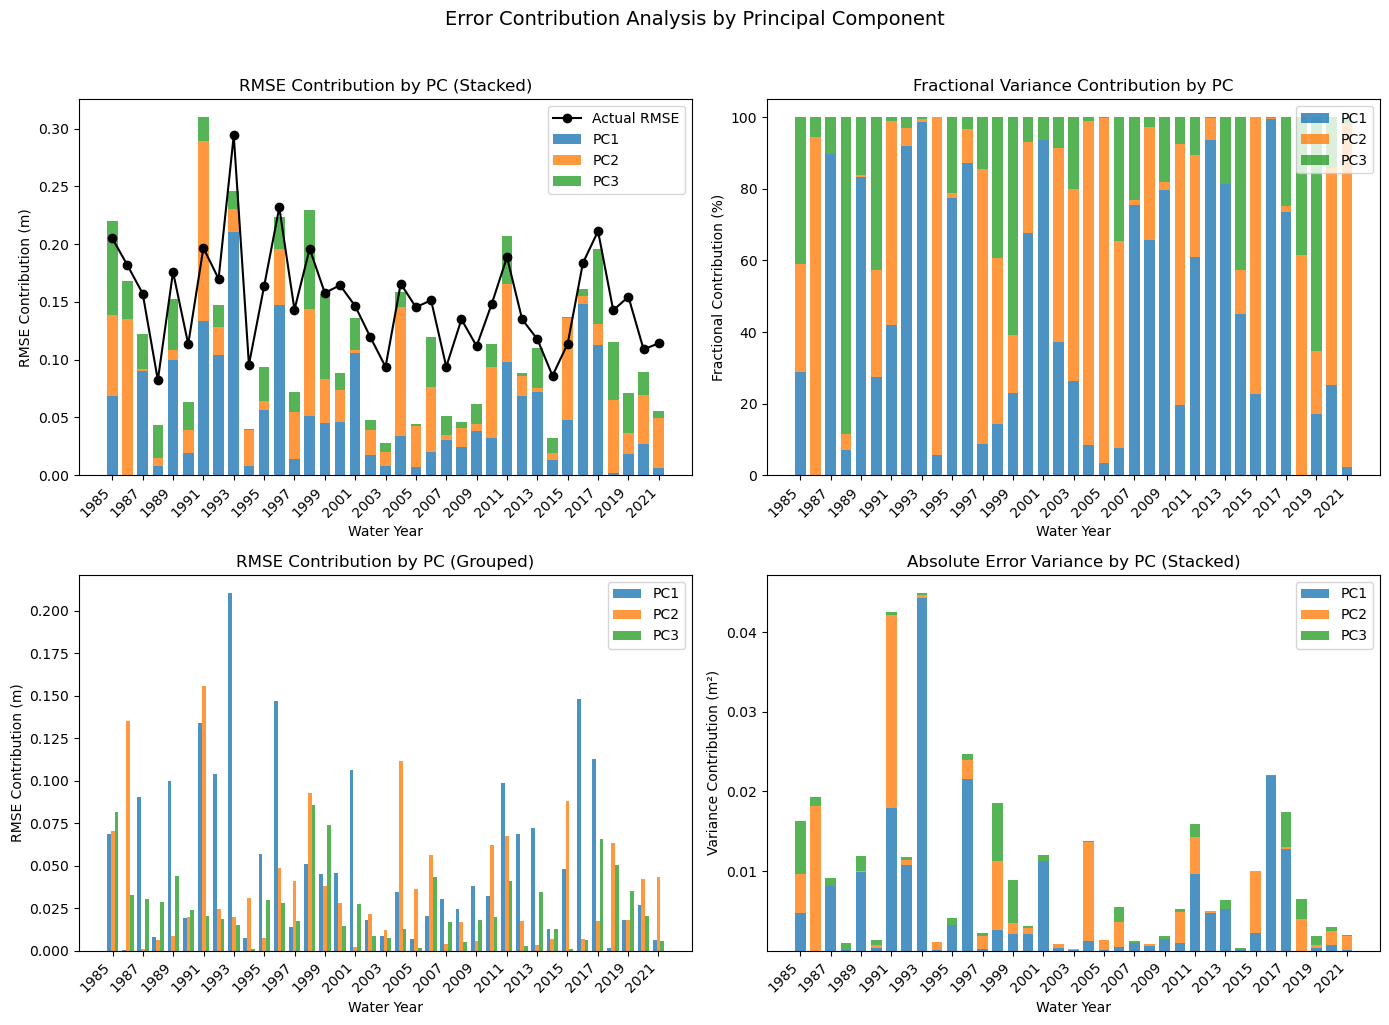


=== Summary: Which PC contributes most to error? ===
Mean variance fraction: PC1=45.7%, PC2=35.5%, PC3=18.7%
Spearman corr between |PC1 error| and RMSE: r=0.647, p=0.000
Spearman corr between |PC2 error| and RMSE: r=0.372, p=0.024
Spearman corr between |PC3 error| and RMSE: r=0.455, p=0.005


In [87]:
# === Visualize Error Contributions by PC ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Stacked bar: RMSE contribution by PC for each year
ax = axes[0, 0]
years = pc_error_df['water_year'].values
x = np.arange(len(years))
width = 0.7

# Show every other year for readability
x_ticks_sparse = x[::2]
year_labels_sparse = years[::2].astype(int)

ax.bar(x, pc_error_df['rmse_pc1'], width, label='PC1', color='#1f77b4', alpha=0.8)
ax.bar(x, pc_error_df['rmse_pc2'], width, bottom=pc_error_df['rmse_pc1'], label='PC2', color='#ff7f0e', alpha=0.8)
ax.bar(x, pc_error_df['rmse_pc3'], width, bottom=pc_error_df['rmse_pc1'] + pc_error_df['rmse_pc2'], 
       label='PC3', color='#2ca02c', alpha=0.8)
ax.plot(x, pc_error_df['actual_rmse'], 'ko-', markersize=6, label='Actual RMSE')
ax.set_xlabel('Water Year')
ax.set_ylabel('RMSE Contribution (m)')
ax.set_title('RMSE Contribution by PC (Stacked)')
ax.set_xticks(x_ticks_sparse)
ax.set_xticklabels(year_labels_sparse, rotation=45, ha='right')
ax.legend(loc='upper right')

# 2. Fractional variance contribution (stacked 100%)
ax = axes[0, 1]
ax.bar(x, pc_error_df['frac_var_pc1']*100, width, label='PC1', color='#1f77b4', alpha=0.8)
ax.bar(x, pc_error_df['frac_var_pc2']*100, width, bottom=pc_error_df['frac_var_pc1']*100, 
       label='PC2', color='#ff7f0e', alpha=0.8)
ax.bar(x, pc_error_df['frac_var_pc3']*100, width, 
       bottom=(pc_error_df['frac_var_pc1'] + pc_error_df['frac_var_pc2'])*100, 
       label='PC3', color='#2ca02c', alpha=0.8)
ax.set_xlabel('Water Year')
ax.set_ylabel('Fractional Contribution (%)')
ax.set_title('Fractional Variance Contribution by PC')
ax.set_xticks(x_ticks_sparse)
ax.set_xticklabels(year_labels_sparse, rotation=45, ha='right')
ax.set_ylim(0, 105)
ax.legend(loc='upper right')

# 3. RMSE contributions as grouped bars (side-by-side, not stacked)
ax = axes[1, 0]
bar_width = 0.25
ax.bar(x - bar_width, pc_error_df['rmse_pc1'], bar_width, label='PC1', color='#1f77b4', alpha=0.8)
ax.bar(x, pc_error_df['rmse_pc2'], bar_width, label='PC2', color='#ff7f0e', alpha=0.8)
ax.bar(x + bar_width, pc_error_df['rmse_pc3'], bar_width, label='PC3', color='#2ca02c', alpha=0.8)
ax.set_xlabel('Water Year')
ax.set_ylabel('RMSE Contribution (m)')
ax.set_title('RMSE Contribution by PC (Grouped)')
ax.legend()
ax.set_xticks(x_ticks_sparse)
ax.set_xticklabels(year_labels_sparse, rotation=45, ha='right')

# 4. Absolute variance contributions (stacked) - shows total error magnitude AND breakdown
ax = axes[1, 1]
# Calculate variance contributions in m² (actual magnitude, not fractional)
swe_std = swe_masked.std(dim='time').values.flatten()
std_for_scale = np.nanmean(swe_std)
var_pc1_abs = (pc_error_df['pc1_weight_err']**2) * np.nanmean(eof1**2) * std_for_scale**2
var_pc2_abs = (pc_error_df['pc2_weight_err']**2) * np.nanmean(eof2**2) * std_for_scale**2
var_pc3_abs = (pc_error_df['pc3_weight_err']**2) * np.nanmean(eof3**2) * std_for_scale**2

ax.bar(x, var_pc1_abs, width, label='PC1', color='#1f77b4', alpha=0.8)
ax.bar(x, var_pc2_abs, width, bottom=var_pc1_abs, label='PC2', color='#ff7f0e', alpha=0.8)
ax.bar(x, var_pc3_abs, width, bottom=var_pc1_abs + var_pc2_abs, label='PC3', color='#2ca02c', alpha=0.8)
ax.set_xlabel('Water Year')
ax.set_ylabel('Variance Contribution (m²)')
ax.set_title('Absolute Error Variance by PC (Stacked)')
ax.legend(loc='upper right')
ax.set_xticks(x_ticks_sparse)
ax.set_xticklabels(year_labels_sparse, rotation=45, ha='right')

plt.suptitle('Error Contribution Analysis by Principal Component', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/loocv_error_by_pc.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n=== Summary: Which PC contributes most to error? ===")
mean_frac = pc_error_df[['frac_var_pc1', 'frac_var_pc2', 'frac_var_pc3']].mean()
print(f"Mean variance fraction: PC1={mean_frac['frac_var_pc1']*100:.1f}%, "
      f"PC2={mean_frac['frac_var_pc2']*100:.1f}%, PC3={mean_frac['frac_var_pc3']*100:.1f}%")

# Correlation between weight errors and RMSE
from scipy.stats import spearmanr
for pc in ['pc1', 'pc2', 'pc3']:
    r, p = spearmanr(np.abs(pc_error_df[f'{pc}_weight_err']), pc_error_df['actual_rmse'])
    print(f"Spearman corr between |{pc.upper()} error| and RMSE: r={r:.3f}, p={p:.3f}")

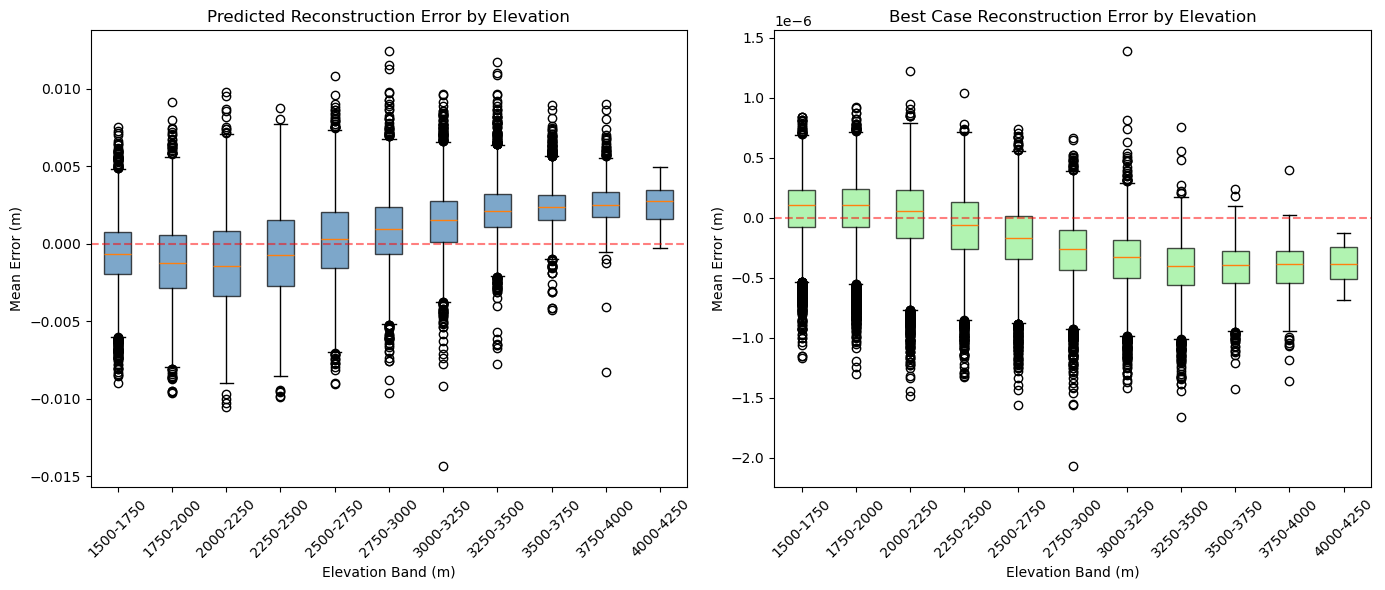

In [78]:
# === Boxplots of Error by Elevation Band ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data for boxplots - use the valid_mask from the analysis cell
# valid_mask was defined as ~np.isnan(dem_flat) & ~np.isnan(mean_error_flat)
elev_binned_valid = elev_binned  # elev_binned was already created on valid data only
error_valid = mean_error_flat[~np.isnan(dem_flat) & ~np.isnan(mean_error_flat)]
bc_error_valid = mean_bc_error_flat[~np.isnan(dem_flat) & ~np.isnan(mean_bc_error_flat)]

# Group errors by elevation bin
error_by_bin = [error_valid[elev_binned_valid == (i + 1)] for i in range(len(elev_bins) - 1)]
bc_error_by_bin = [bc_error_valid[elev_binned_valid == (i + 1)] for i in range(len(elev_bins) - 1)]

# Filter out empty bins
non_empty = [i for i, arr in enumerate(error_by_bin) if len(arr) > 0]
error_by_bin_filtered = [error_by_bin[i] for i in non_empty]
bc_error_by_bin_filtered = [bc_error_by_bin[i] for i in non_empty]
bin_labels = [f"{elev_bins[i]}-{elev_bins[i+1]}" for i in non_empty]

# Predicted reconstruction
ax = axes[0]
bp = ax.boxplot(error_by_bin_filtered, patch_artist=True, labels=bin_labels)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Elevation Band (m)')
ax.set_ylabel('Mean Error (m)')
ax.set_title('Predicted Reconstruction Error by Elevation')
ax.tick_params(axis='x', rotation=45)

# Best case reconstruction
ax = axes[1]
bp = ax.boxplot(bc_error_by_bin_filtered, patch_artist=True, labels=bin_labels)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
    patch.set_alpha(0.7)
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Elevation Band (m)')
ax.set_ylabel('Mean Error (m)')
ax.set_title('Best Case Reconstruction Error by Elevation')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/loocv_error_boxplots_by_elevation.png', dpi=150, bbox_inches='tight')
plt.show()

In [82]:
# === PC1-Only Reconstruction: LOOCV with Estimated vs True PC1 Weights ===
from tqdm import tqdm

print("Running PC1-only reconstruction for all years...")

# Storage for PC1-only results
pc1_only_stats = []
pc1_only_recon_all = []
pc1_only_true_recon_all = []

for test_year in tqdm(all_years, desc="PC1-only LOOCV"):
    # === Split train/test ===
    train_mask = df_valid['water_year'] != test_year
    df_train = df_valid[train_mask].reset_index(drop=True)
    df_test = df_valid[~train_mask].reset_index(drop=True)
    
    # === PC1: Predict from cum_snowfall ===
    X_train_pc1 = df_train[['cum_snowfall']].values
    y_train_pc1 = df_train['PC1_swe'].values
    X_test_pc1 = df_test[['cum_snowfall']].values
    
    model_pc1 = LinearRegression()
    model_pc1.fit(X_train_pc1, y_train_pc1)
    pred_pc1 = model_pc1.predict(X_test_pc1)[0]
    
    # True PC1 weight
    true_pc1 = df_test['PC1_swe'].values[0]
    
    # === Reconstruct using ONLY EOF1 × PC1 ===
    # With PREDICTED PC1 weight
    swe_anom_pred_pc1 = np.dot(U_anom_swe[:, 0:1] * S_anom_swe[0:1], np.array([[pred_pc1]]))
    
    # With TRUE PC1 weight
    swe_anom_true_pc1 = np.dot(U_anom_swe[:, 0:1] * S_anom_swe[0:1], np.array([[true_pc1]]))
    
    # Convert to spatial format - predicted
    swe_anom_pred_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
    swe_anom_pred_spatial.values = swe_anom_pred_pc1
    swe_anom_pred_unstacked = swe_anom_pred_spatial.unstack('space')
    swe_anom_pred_sorted = swe_anom_pred_unstacked.sortby(['y', 'x'])
    recon_pred = (swe_anom_pred_sorted * swe_masked.std(dim='time')) + swe_masked.mean(dim='time')
    recon_pred = recon_pred.where(eof_mask)
    
    # Convert to spatial format - true weights
    swe_anom_true_spatial = xr.full_like(swe_2d_clean_anom.isel(time=[0]).T, np.nan)
    swe_anom_true_spatial.values = swe_anom_true_pc1
    swe_anom_true_unstacked = swe_anom_true_spatial.unstack('space')
    swe_anom_true_sorted = swe_anom_true_unstacked.sortby(['y', 'x'])
    recon_true = (swe_anom_true_sorted * swe_masked.std(dim='time')) + swe_masked.mean(dim='time')
    recon_true = recon_true.where(eof_mask)
    
    # Get true SWE for this year
    time_str = f"{test_year}-04-01"
    true_swe_year = swe_masked.sel(time=time_str)
    
    # Calculate error statistics
    true_vals = true_swe_year.values.flatten()
    pred_vals = recon_pred.squeeze().values.flatten()
    true_recon_vals = recon_true.squeeze().values.flatten()
    valid = ~np.isnan(true_vals) & ~np.isnan(pred_vals)
    
    true_valid = true_vals[valid]
    pred_valid = pred_vals[valid]
    true_recon_valid = true_recon_vals[valid]
    
    # Predicted PC1 reconstruction error stats
    bias_pred = np.mean(pred_valid - true_valid)
    rmse_pred = np.sqrt(np.mean((pred_valid - true_valid)**2))
    mae_pred = np.mean(np.abs(pred_valid - true_valid))
    r_pred, _ = pearsonr(true_valid, pred_valid)
    
    # True PC1 reconstruction error stats (best case for PC1-only)
    bias_true = np.mean(true_recon_valid - true_valid)
    rmse_true = np.sqrt(np.mean((true_recon_valid - true_valid)**2))
    mae_true = np.mean(np.abs(true_recon_valid - true_valid))
    r_true, _ = pearsonr(true_valid, true_recon_valid)
    
    pc1_only_stats.append({
        'water_year': test_year,
        'pred_pc1': pred_pc1,
        'true_pc1': true_pc1,
        'pc1_error': pred_pc1 - true_pc1,
        'bias_pred_pc1': bias_pred,
        'rmse_pred_pc1': rmse_pred,
        'mae_pred_pc1': mae_pred,
        'r_pred_pc1': r_pred,
        'bias_true_pc1': bias_true,
        'rmse_true_pc1': rmse_true,
        'mae_true_pc1': mae_true,
        'r_true_pc1': r_true
    })
    
    pc1_only_recon_all.append(recon_pred.squeeze().values)
    pc1_only_true_recon_all.append(recon_true.squeeze().values)

pc1_only_df = pd.DataFrame(pc1_only_stats)

# Display summary
print("\n=== PC1-Only Reconstruction: Error Statistics ===")
print(pc1_only_df[['water_year', 'pred_pc1', 'true_pc1', 'pc1_error', 
                   'rmse_pred_pc1', 'rmse_true_pc1']].round(4).to_string(index=False))

print("\n=== Mean Statistics ===")
print(f"Using PREDICTED PC1:")
print(f"  Mean RMSE: {pc1_only_df['rmse_pred_pc1'].mean():.4f} m")
print(f"  Mean MAE:  {pc1_only_df['mae_pred_pc1'].mean():.4f} m")
print(f"  Mean R:    {pc1_only_df['r_pred_pc1'].mean():.4f}")

print(f"\nUsing TRUE PC1:")
print(f"  Mean RMSE: {pc1_only_df['rmse_true_pc1'].mean():.4f} m")
print(f"  Mean MAE:  {pc1_only_df['mae_true_pc1'].mean():.4f} m")
print(f"  Mean R:    {pc1_only_df['r_true_pc1'].mean():.4f}")

# Compare to 3-PC reconstruction
print(f"\n=== Comparison to 3-PC Reconstruction ===")
print(f"3-PC (predicted weights) Mean RMSE: {error_stats_df['rmse'].mean():.4f} m")
print(f"3-PC (true weights) Mean RMSE:      {error_stats_df['bestcase_rmse'].mean():.4f} m")
print(f"PC1-only (predicted) Mean RMSE:     {pc1_only_df['rmse_pred_pc1'].mean():.4f} m")
print(f"PC1-only (true) Mean RMSE:          {pc1_only_df['rmse_true_pc1'].mean():.4f} m")

Running PC1-only reconstruction for all years...


PC1-only LOOCV: 100%|██████████| 37/37 [00:02<00:00, 12.81it/s]


=== PC1-Only Reconstruction: Error Statistics ===
 water_year  pred_pc1  true_pc1  pc1_error  rmse_pred_pc1  rmse_true_pc1
       1985    0.0621    0.0192     0.0429         0.1966         0.1823
       1986    0.1508    0.1509    -0.0002         0.2855         0.2854
       1987   -0.1881   -0.1314    -0.0567         0.1586         0.1234
       1988   -0.1747   -0.1799     0.0052         0.0878         0.0874
       1989    0.0049   -0.0576     0.0624         0.1668         0.1456
       1990   -0.1453   -0.1573     0.0121         0.1116         0.1091
       1991   -0.0451    0.0387    -0.0838         0.1799         0.1664
       1992   -0.1196   -0.0544    -0.0652         0.1915         0.1757
       1993    0.2371    0.3690    -0.1319         0.2845         0.1961
       1994   -0.1495   -0.1447    -0.0048         0.0996         0.1005
       1995    0.2814    0.3170    -0.0355         0.1609         0.1506
       1996    0.0155    0.1076    -0.0921         0.2476         0.1792


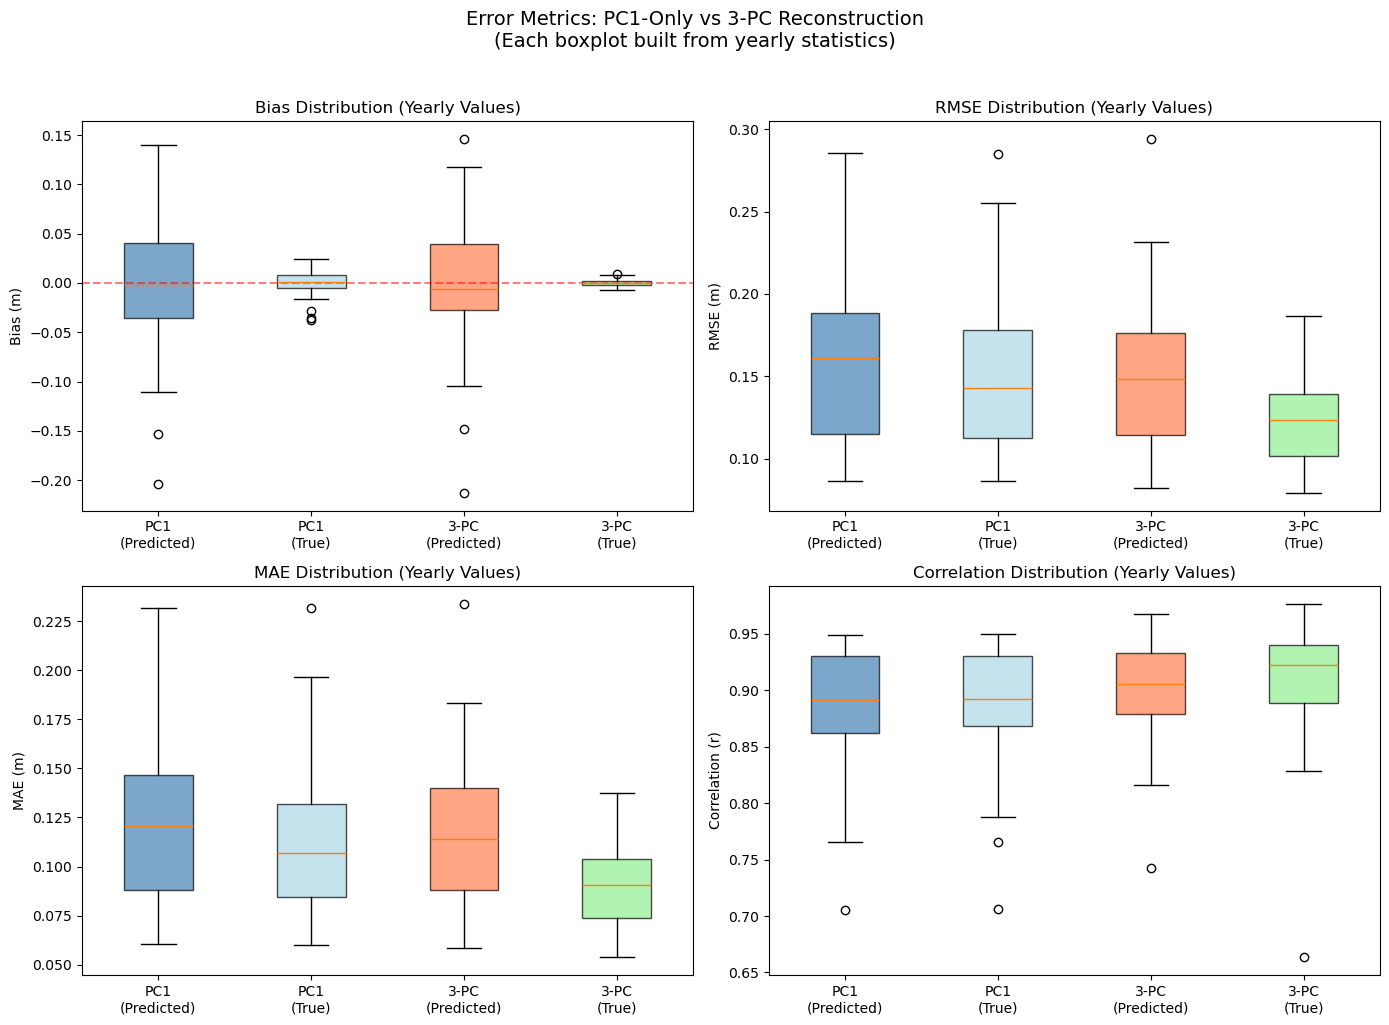

=== Summary Statistics (Mean ± Std across years) ===

PC1-Only (Predicted):
  RMSE: 0.1639 ± 0.0558 m
  MAE:  0.1260 ± 0.0465 m
  R:    0.8869 ± 0.0516

PC1-Only (True):
  RMSE: 0.1499 ± 0.0493 m
  MAE:  0.1124 ± 0.0408 m
  R:    0.8883 ± 0.0514

3-PC (Predicted):
  RMSE: 0.1513 ± 0.0446 m
  MAE:  0.1164 ± 0.0373 m
  R:    0.9000 ± 0.0469

3-PC (True):
  RMSE: 0.1209 ± 0.0263 m
  MAE:  0.0888 ± 0.0206 m
  R:    0.9094 ± 0.0533

=== Value Added by Higher PCs ===
RMSE reduction from adding PC2+PC3 (true weights): 0.0290 m
Percentage improvement: 19.4%


In [85]:
# === Visualize PC1-Only vs 3-PC: Boxplots from Yearly Error Metrics ===
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Collect yearly metrics for all 4 approaches
# Data structure: each list contains one value per year

# 1. Bias boxplots
ax = axes[0, 0]
bias_data = [
    pc1_only_df['bias_pred_pc1'].values,
    pc1_only_df['bias_true_pc1'].values,
    error_stats_df['bias'].values,
    error_stats_df['bestcase_bias'].values
]
labels = ['PC1\n(Predicted)', 'PC1\n(True)', '3-PC\n(Predicted)', '3-PC\n(True)']
bp = ax.boxplot(bias_data, labels=labels, patch_artist=True)
colors = ['steelblue', 'lightblue', 'coral', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_ylabel('Bias (m)')
ax.set_title('Bias Distribution (Yearly Values)')

# 2. RMSE boxplots
ax = axes[0, 1]
rmse_data = [
    pc1_only_df['rmse_pred_pc1'].values,
    pc1_only_df['rmse_true_pc1'].values,
    error_stats_df['rmse'].values,
    error_stats_df['bestcase_rmse'].values
]
bp = ax.boxplot(rmse_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('RMSE (m)')
ax.set_title('RMSE Distribution (Yearly Values)')

# 3. MAE boxplots
ax = axes[1, 0]
mae_data = [
    pc1_only_df['mae_pred_pc1'].values,
    pc1_only_df['mae_true_pc1'].values,
    error_stats_df['mae'].values,
    error_stats_df['bestcase_mae'].values
]
bp = ax.boxplot(mae_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('MAE (m)')
ax.set_title('MAE Distribution (Yearly Values)')

# 4. Correlation boxplots
ax = axes[1, 1]
r_data = [
    pc1_only_df['r_pred_pc1'].values,
    pc1_only_df['r_true_pc1'].values,
    error_stats_df['r'].values,
    error_stats_df['bestcase_r'].values
]
bp = ax.boxplot(r_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Correlation (r)')
ax.set_title('Correlation Distribution (Yearly Values)')

plt.suptitle('Error Metrics: PC1-Only vs 3-PC Reconstruction\n(Each boxplot built from yearly statistics)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/pc1_vs_3pc_yearly_metrics_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("=== Summary Statistics (Mean ± Std across years) ===")
print(f"\nPC1-Only (Predicted):")
print(f"  RMSE: {pc1_only_df['rmse_pred_pc1'].mean():.4f} ± {pc1_only_df['rmse_pred_pc1'].std():.4f} m")
print(f"  MAE:  {pc1_only_df['mae_pred_pc1'].mean():.4f} ± {pc1_only_df['mae_pred_pc1'].std():.4f} m")
print(f"  R:    {pc1_only_df['r_pred_pc1'].mean():.4f} ± {pc1_only_df['r_pred_pc1'].std():.4f}")

print(f"\nPC1-Only (True):")
print(f"  RMSE: {pc1_only_df['rmse_true_pc1'].mean():.4f} ± {pc1_only_df['rmse_true_pc1'].std():.4f} m")
print(f"  MAE:  {pc1_only_df['mae_true_pc1'].mean():.4f} ± {pc1_only_df['mae_true_pc1'].std():.4f} m")
print(f"  R:    {pc1_only_df['r_true_pc1'].mean():.4f} ± {pc1_only_df['r_true_pc1'].std():.4f}")

print(f"\n3-PC (Predicted):")
print(f"  RMSE: {error_stats_df['rmse'].mean():.4f} ± {error_stats_df['rmse'].std():.4f} m")
print(f"  MAE:  {error_stats_df['mae'].mean():.4f} ± {error_stats_df['mae'].std():.4f} m")
print(f"  R:    {error_stats_df['r'].mean():.4f} ± {error_stats_df['r'].std():.4f}")

print(f"\n3-PC (True):")
print(f"  RMSE: {error_stats_df['bestcase_rmse'].mean():.4f} ± {error_stats_df['bestcase_rmse'].std():.4f} m")
print(f"  MAE:  {error_stats_df['bestcase_mae'].mean():.4f} ± {error_stats_df['bestcase_mae'].std():.4f} m")
print(f"  R:    {error_stats_df['bestcase_r'].mean():.4f} ± {error_stats_df['bestcase_r'].std():.4f}")

# Value added analysis
print("\n=== Value Added by Higher PCs ===")
rmse_reduction = pc1_only_df['rmse_true_pc1'].mean() - error_stats_df['bestcase_rmse'].mean()
print(f"RMSE reduction from adding PC2+PC3 (true weights): {rmse_reduction:.4f} m")
print(f"Percentage improvement: {100*rmse_reduction/pc1_only_df['rmse_true_pc1'].mean():.1f}%")

=== Sample sizes by EOF3 region and elevation ===
elev_bin     1500-1750  1750-2000  2000-2250  2250-2500  2500-2750  2750-3000  3000-3250  3250-3500  3500-3750  3750-4000  4000-4250
eof3_region                                                                                                                         
EOF3+           5211.0     6097.0     6864.0     6695.0     7305.0     6600.0     6026.0     5138.0     3022.0      752.0       48.0
EOF3-           6800.0    11734.0    12696.0     9227.0     6552.0     4010.0     2068.0      676.0      134.0       16.0        NaN


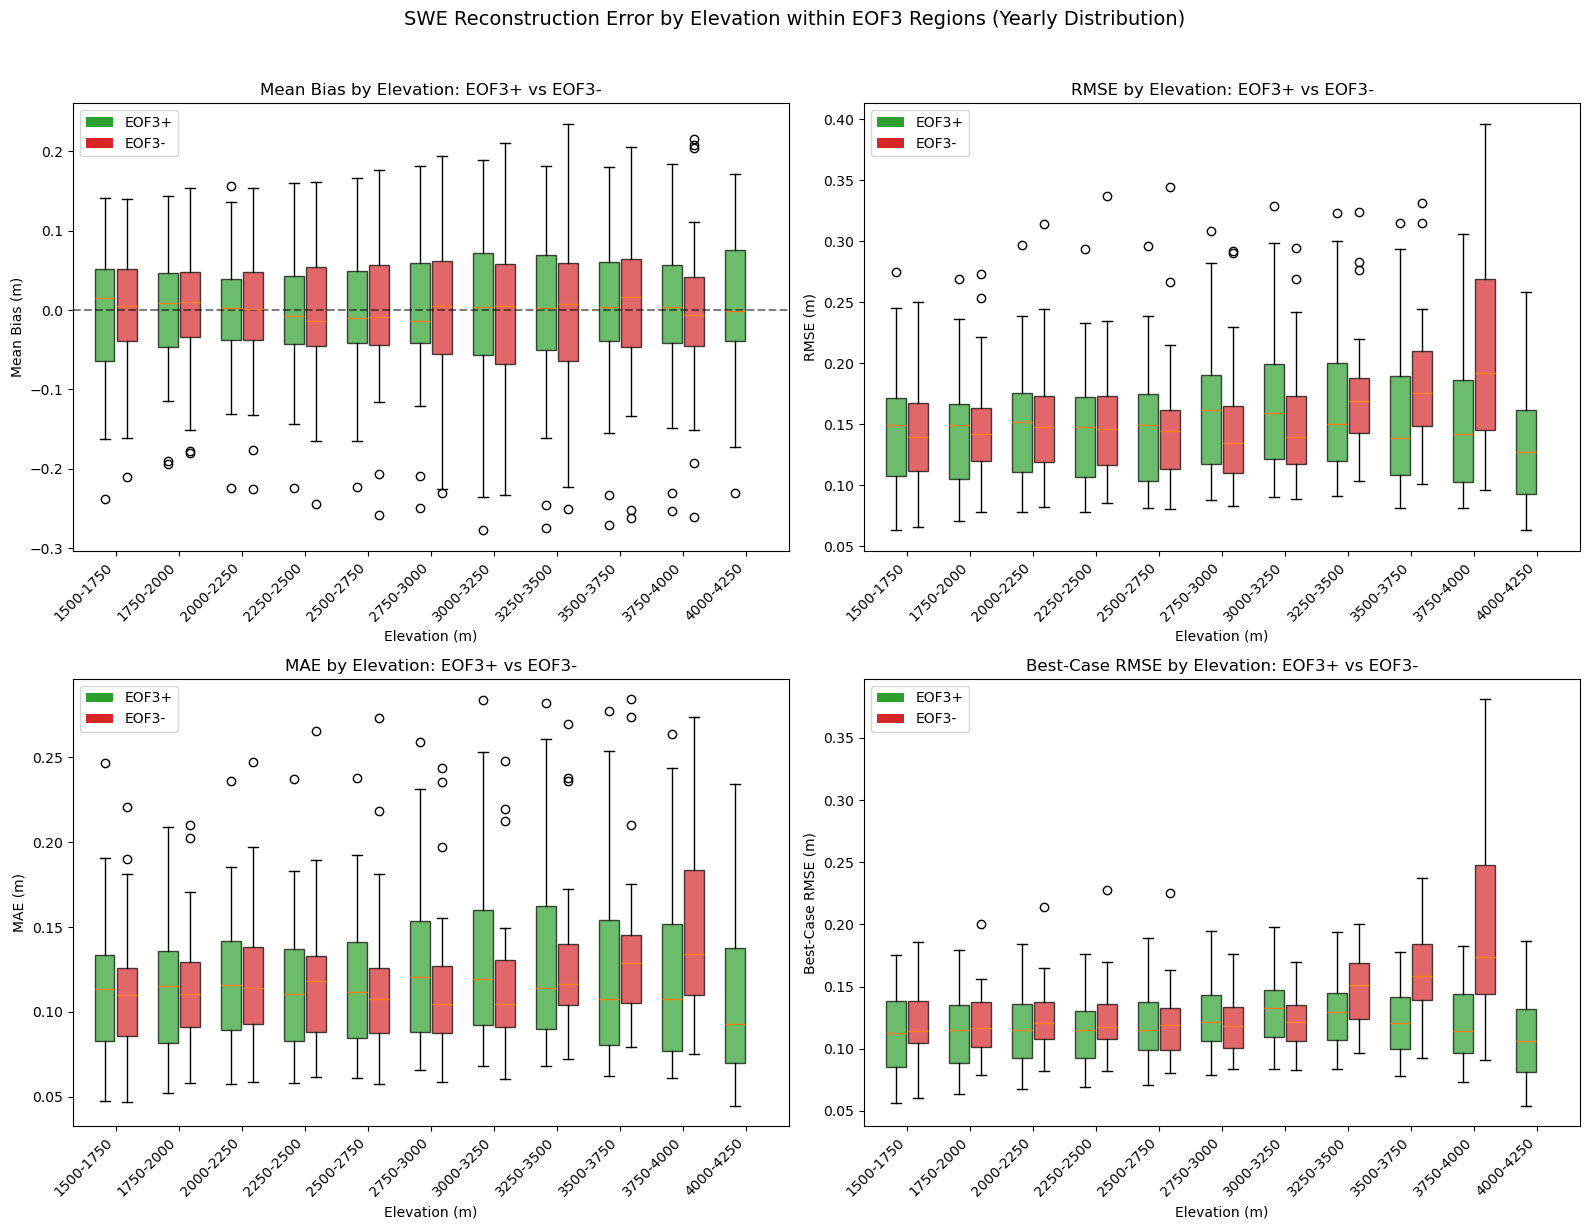


=== Median RMSE by Elevation and EOF3 Region ===

EOF3+:
  Low (<2000m): RMSE=0.1497 m, BC=0.1151 m
  Mid (2000-3000m): RMSE=0.1492 m, BC=0.1172 m
  High (>3000m): RMSE=0.1443 m, BC=0.1192 m

EOF3-:
  Low (<2000m): RMSE=0.1412 m, BC=0.1170 m
  Mid (2000-3000m): RMSE=0.1443 m, BC=0.1189 m
  High (>3000m): RMSE=0.1681 m, BC=0.1475 m


In [89]:
# === Error by Elevation within EOF3+ and EOF3- Regions ===
# Separate analysis for EOF3+ vs EOF3- areas

# Define EOF3 regions
eof3_pos_mask = eof3_flat > 0
eof3_neg_mask = eof3_flat <= 0

# Storage for yearly stats by elevation and EOF3 region
eof3_elev_stats = []

for yr_idx, year in enumerate(all_years):
    # Get error maps for this year
    error_yr = loocv_ds['error'].isel(time=yr_idx).values.flatten()
    bc_error_yr = loocv_ds['bestcase_error'].isel(time=yr_idx).values.flatten()
    
    for eof3_region, eof3_name in [(eof3_pos_mask, 'EOF3+'), (eof3_neg_mask, 'EOF3-')]:
        for i, (low, high) in enumerate(zip(elev_bins[:-1], elev_bins[1:])):
            # Combine EOF3 region + elevation bin + valid data
            combined_mask = eof3_region & (dem_flat >= low) & (dem_flat < high) & valid_mask
            
            if combined_mask.sum() > 10:  # Require minimum pixels
                eof3_elev_stats.append({
                    'water_year': year,
                    'eof3_region': eof3_name,
                    'elev_bin': f"{low}-{high}",
                    'elev_mid': (low + high) / 2,
                    'mean_error': np.nanmean(error_yr[combined_mask]),
                    'mean_bc_error': np.nanmean(bc_error_yr[combined_mask]),
                    'rmse': np.sqrt(np.nanmean(error_yr[combined_mask]**2)),
                    'rmse_bc': np.sqrt(np.nanmean(bc_error_yr[combined_mask]**2)),
                    'mae': np.nanmean(np.abs(error_yr[combined_mask])),
                    'n_pixels': combined_mask.sum()
                })

eof3_elev_df = pd.DataFrame(eof3_elev_stats)

# Summary
print("=== Sample sizes by EOF3 region and elevation ===")
pivot = eof3_elev_df.groupby(['eof3_region', 'elev_bin'])['n_pixels'].mean().unstack()
print(pivot.to_string())

# Get unique elevation bins
elev_mids = sorted(eof3_elev_df['elev_mid'].unique())
bin_labels = [f"{int(e-125)}-{int(e+125)}" for e in elev_mids]

# === Create Boxplots: RMSE by Elevation for EOF3+ vs EOF3- ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

positions = np.arange(len(elev_mids))
width = 0.35

# Colors for EOF3 regions
eof3_colors = {'EOF3+': '#2ca02c', 'EOF3-': '#d62728'}

# 1. Mean Bias by Elevation (EOF3+ vs EOF3-)
ax = axes[0, 0]
for offset, (eof3_name, color) in enumerate(zip(['EOF3+', 'EOF3-'], ['#2ca02c', '#d62728'])):
    bias_data = [eof3_elev_df[(eof3_elev_df['eof3_region'] == eof3_name) & 
                              (eof3_elev_df['elev_mid'] == e)]['mean_error'].values 
                 for e in elev_mids]
    # Filter out empty arrays
    bias_data = [d if len(d) > 0 else [np.nan] for d in bias_data]
    bp = ax.boxplot(bias_data, positions=positions + (offset - 0.5) * width, 
                    widths=width * 0.9, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Mean Bias (m)')
ax.set_title('Mean Bias by Elevation: EOF3+ vs EOF3-')
ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#2ca02c', label='EOF3+'), 
                   Patch(facecolor='#d62728', label='EOF3-')], loc='upper left')

# 2. RMSE by Elevation (EOF3+ vs EOF3-)
ax = axes[0, 1]
for offset, (eof3_name, color) in enumerate(zip(['EOF3+', 'EOF3-'], ['#2ca02c', '#d62728'])):
    rmse_data = [eof3_elev_df[(eof3_elev_df['eof3_region'] == eof3_name) & 
                              (eof3_elev_df['elev_mid'] == e)]['rmse'].values 
                 for e in elev_mids]
    rmse_data = [d if len(d) > 0 else [np.nan] for d in rmse_data]
    bp = ax.boxplot(rmse_data, positions=positions + (offset - 0.5) * width, 
                    widths=width * 0.9, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('RMSE (m)')
ax.set_title('RMSE by Elevation: EOF3+ vs EOF3-')
ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.legend(handles=[Patch(facecolor='#2ca02c', label='EOF3+'), 
                   Patch(facecolor='#d62728', label='EOF3-')], loc='upper left')

# 3. MAE by Elevation (EOF3+ vs EOF3-)
ax = axes[1, 0]
for offset, (eof3_name, color) in enumerate(zip(['EOF3+', 'EOF3-'], ['#2ca02c', '#d62728'])):
    mae_data = [eof3_elev_df[(eof3_elev_df['eof3_region'] == eof3_name) & 
                             (eof3_elev_df['elev_mid'] == e)]['mae'].values 
                for e in elev_mids]
    mae_data = [d if len(d) > 0 else [np.nan] for d in mae_data]
    bp = ax.boxplot(mae_data, positions=positions + (offset - 0.5) * width, 
                    widths=width * 0.9, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('MAE (m)')
ax.set_title('MAE by Elevation: EOF3+ vs EOF3-')
ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.legend(handles=[Patch(facecolor='#2ca02c', label='EOF3+'), 
                   Patch(facecolor='#d62728', label='EOF3-')], loc='upper left')

# 4. Best-case RMSE by Elevation (to see irreducible error differences)
ax = axes[1, 1]
for offset, (eof3_name, color) in enumerate(zip(['EOF3+', 'EOF3-'], ['#2ca02c', '#d62728'])):
    rmse_bc_data = [eof3_elev_df[(eof3_elev_df['eof3_region'] == eof3_name) & 
                                 (eof3_elev_df['elev_mid'] == e)]['rmse_bc'].values 
                    for e in elev_mids]
    rmse_bc_data = [d if len(d) > 0 else [np.nan] for d in rmse_bc_data]
    bp = ax.boxplot(rmse_bc_data, positions=positions + (offset - 0.5) * width, 
                    widths=width * 0.9, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Best-Case RMSE (m)')
ax.set_title('Best-Case RMSE by Elevation: EOF3+ vs EOF3-')
ax.set_xticks(positions)
ax.set_xticklabels(bin_labels, rotation=45, ha='right')
ax.legend(handles=[Patch(facecolor='#2ca02c', label='EOF3+'), 
                   Patch(facecolor='#d62728', label='EOF3-')], loc='upper left')

plt.suptitle('SWE Reconstruction Error by Elevation within EOF3 Regions (Yearly Distribution)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/loocv_error_by_elevation_eof3_regions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n=== Median RMSE by Elevation and EOF3 Region ===")
for eof3_region in ['EOF3+', 'EOF3-']:
    print(f"\n{eof3_region}:")
    for elev_zone, low_e, high_e in [('Low (<2000m)', 0, 2000), 
                                      ('Mid (2000-3000m)', 2000, 3000), 
                                      ('High (>3000m)', 3000, 5000)]:
        subset = eof3_elev_df[(eof3_elev_df['eof3_region'] == eof3_region) & 
                              (eof3_elev_df['elev_mid'] >= low_e) & 
                              (eof3_elev_df['elev_mid'] < high_e)]
        if len(subset) > 0:
            print(f"  {elev_zone}: RMSE={subset['rmse'].median():.4f} m, BC={subset['rmse_bc'].median():.4f} m")

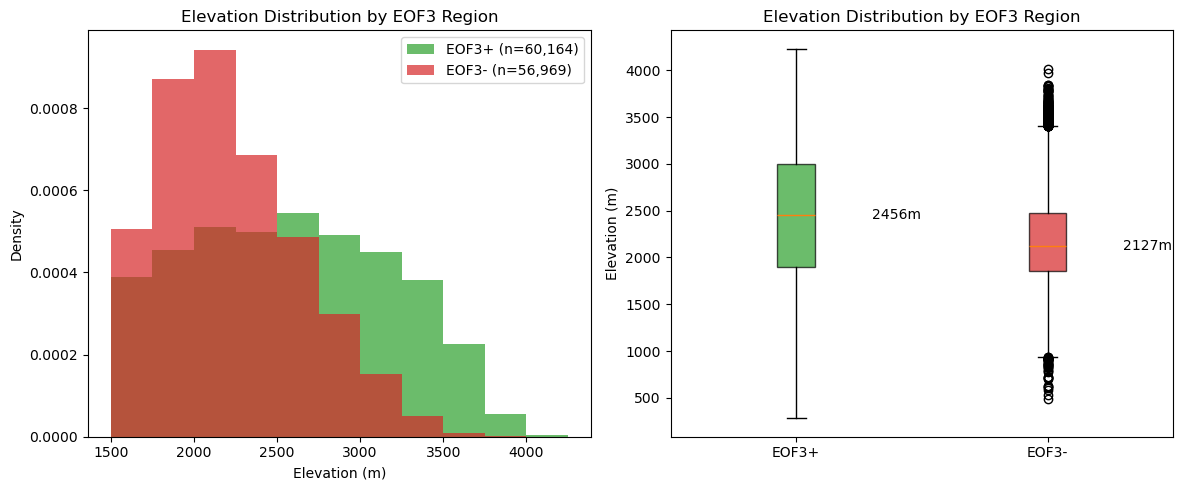

EOF3+ elevation: median=2456m, mean=2427m, range=282-4230m
EOF3- elevation: median=2127m, mean=2176m, range=489-4017m


In [90]:
# === Elevation Distribution in EOF3+ vs EOF3- Regions ===
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Get valid elevations for each region
elev_eof3_pos = dem_flat[eof3_pos_mask & valid_mask]
elev_eof3_neg = dem_flat[eof3_neg_mask & valid_mask]

# 1. Histograms
ax = axes[0]
ax.hist(elev_eof3_pos, bins=elev_bins, alpha=0.7, color='#2ca02c', label=f'EOF3+ (n={len(elev_eof3_pos):,})', density=True)
ax.hist(elev_eof3_neg, bins=elev_bins, alpha=0.7, color='#d62728', label=f'EOF3- (n={len(elev_eof3_neg):,})', density=True)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Density')
ax.set_title('Elevation Distribution by EOF3 Region')
ax.legend()

# 2. Box plot comparison
ax = axes[1]
bp = ax.boxplot([elev_eof3_pos, elev_eof3_neg], 
                labels=['EOF3+', 'EOF3-'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('#2ca02c')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#d62728')
bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('Elevation (m)')
ax.set_title('Elevation Distribution by EOF3 Region')

# Add median values as text
for i, (data, name) in enumerate([(elev_eof3_pos, 'EOF3+'), (elev_eof3_neg, 'EOF3-')]):
    median = np.median(data)
    ax.annotate(f'{median:.0f}m', xy=(i+1, median), xytext=(i+1.3, median),
                fontsize=10, va='center')

plt.tight_layout()
plt.savefig('../figures/elevation_distribution_eof3_regions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f"EOF3+ elevation: median={np.median(elev_eof3_pos):.0f}m, mean={np.mean(elev_eof3_pos):.0f}m, range={elev_eof3_pos.min():.0f}-{elev_eof3_pos.max():.0f}m")
print(f"EOF3- elevation: median={np.median(elev_eof3_neg):.0f}m, mean={np.mean(elev_eof3_neg):.0f}m, range={elev_eof3_neg.min():.0f}-{elev_eof3_neg.max():.0f}m")

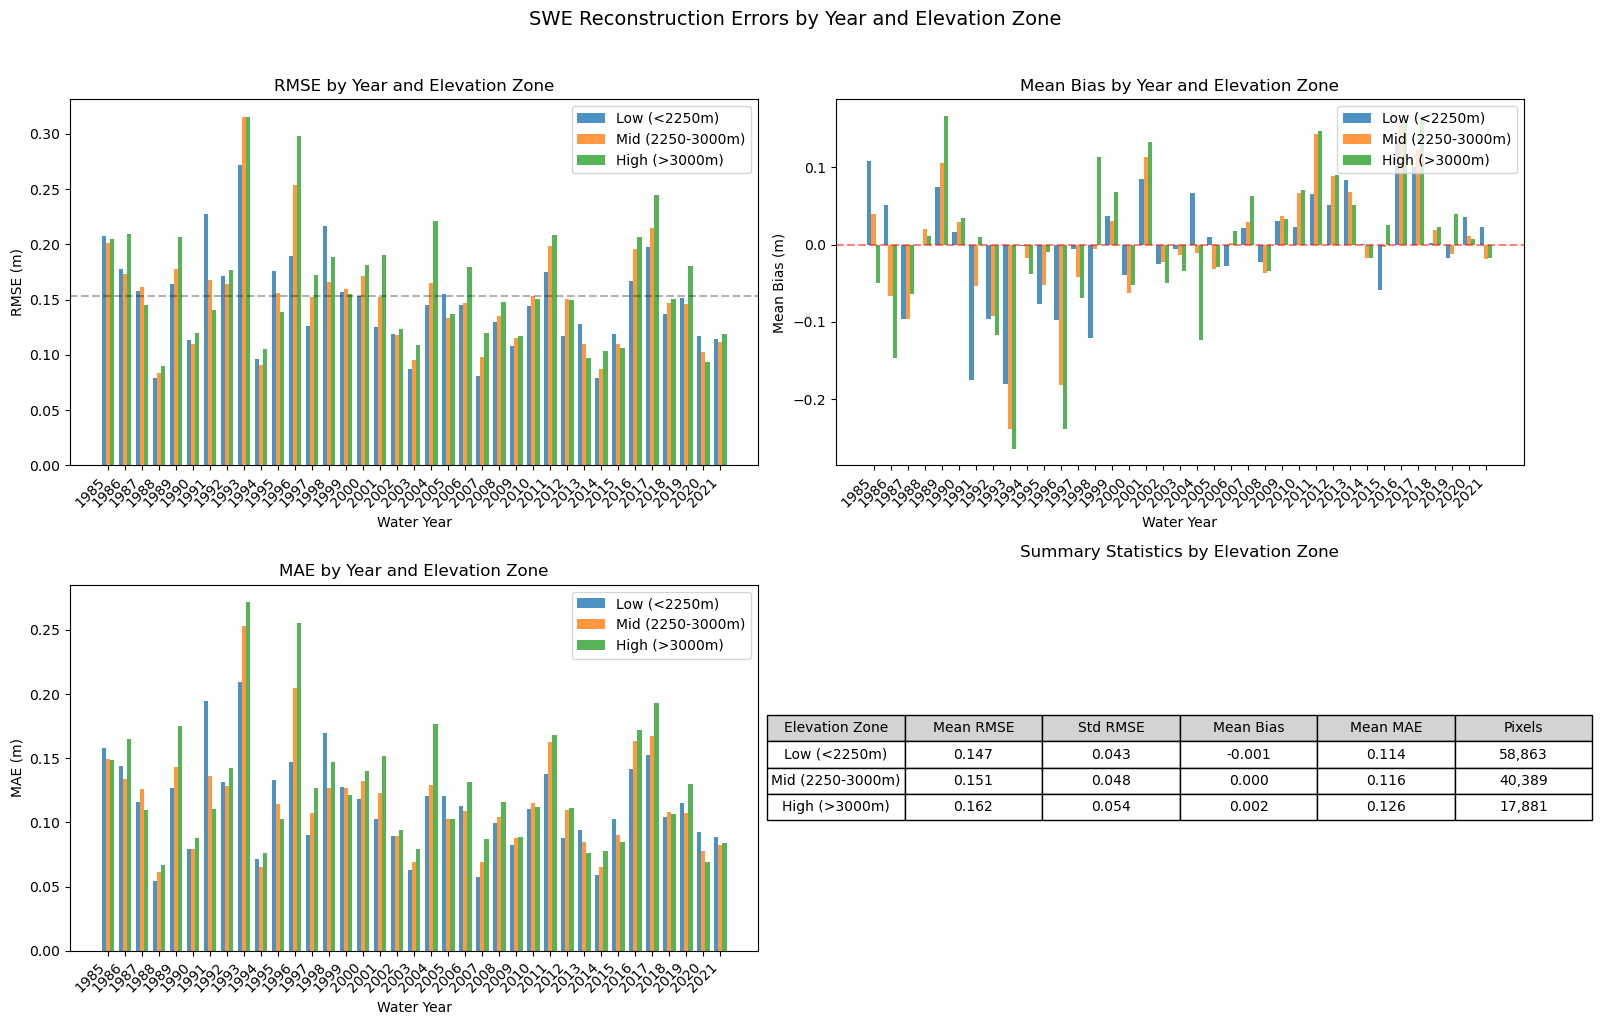


=== RMSE by Year and Elevation Zone ===
zone        High (>3000m)  Low (<2250m)  Mid (2250-3000m)
water_year                                               
1985                0.205         0.207             0.202
1986                0.210         0.178             0.174
1987                0.146         0.158             0.162
1988                0.090         0.079             0.083
1989                0.207         0.164             0.178
1990                0.120         0.114             0.110
1991                0.141         0.228             0.168
1992                0.177         0.172             0.164
1993                0.316         0.272             0.315
1994                0.105         0.096             0.091
1995                0.138         0.176             0.156
1996                0.298         0.189             0.254
1997                0.172         0.126             0.153
1998                0.188         0.216             0.166
1999                0.155      

In [91]:
# === Error Metrics by Year for 3 Elevation Bands ===

# Define 3 elevation zones
elev_zones = [
    ('Low (<2250m)', 0, 2250),
    ('Mid (2250-3000m)', 2250, 3000),
    ('High (>3000m)', 3000, 5000)
]
zone_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Calculate yearly stats for each elevation zone
yearly_zone_stats = []

for yr_idx, year in enumerate(all_years):
    error_yr = loocv_ds['error'].isel(time=yr_idx).values.flatten()
    bc_error_yr = loocv_ds['bestcase_error'].isel(time=yr_idx).values.flatten()
    
    for zone_name, low_e, high_e in elev_zones:
        zone_mask = (dem_flat >= low_e) & (dem_flat < high_e) & valid_mask
        
        if zone_mask.sum() > 0:
            yearly_zone_stats.append({
                'water_year': year,
                'zone': zone_name,
                'mean_error': np.nanmean(error_yr[zone_mask]),
                'mean_bc_error': np.nanmean(bc_error_yr[zone_mask]),
                'rmse': np.sqrt(np.nanmean(error_yr[zone_mask]**2)),
                'rmse_bc': np.sqrt(np.nanmean(bc_error_yr[zone_mask]**2)),
                'mae': np.nanmean(np.abs(error_yr[zone_mask])),
                'n_pixels': zone_mask.sum()
            })

zone_df = pd.DataFrame(yearly_zone_stats)

# === Plot yearly metrics by elevation zone ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

years = zone_df['water_year'].unique()
x = np.arange(len(years))
bar_width = 0.25

# 1. RMSE by Year and Elevation Zone
ax = axes[0, 0]
for i, (zone_name, color) in enumerate(zip([z[0] for z in elev_zones], zone_colors)):
    zone_data = zone_df[zone_df['zone'] == zone_name].set_index('water_year')['rmse'].reindex(years)
    ax.bar(x + i*bar_width, zone_data, bar_width, label=zone_name, color=color, alpha=0.8)
ax.set_xlabel('Water Year')
ax.set_ylabel('RMSE (m)')
ax.set_title('RMSE by Year and Elevation Zone')
ax.set_xticks(x + bar_width)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.legend(loc='upper right')
ax.axhline(zone_df['rmse'].mean(), color='k', linestyle='--', alpha=0.3, label='Overall mean')

# 2. Mean Bias by Year and Elevation Zone
ax = axes[0, 1]
for i, (zone_name, color) in enumerate(zip([z[0] for z in elev_zones], zone_colors)):
    zone_data = zone_df[zone_df['zone'] == zone_name].set_index('water_year')['mean_error'].reindex(years)
    ax.bar(x + i*bar_width, zone_data, bar_width, label=zone_name, color=color, alpha=0.8)
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Water Year')
ax.set_ylabel('Mean Bias (m)')
ax.set_title('Mean Bias by Year and Elevation Zone')
ax.set_xticks(x + bar_width)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.legend(loc='upper right')

# 3. MAE by Year and Elevation Zone
ax = axes[1, 0]
for i, (zone_name, color) in enumerate(zip([z[0] for z in elev_zones], zone_colors)):
    zone_data = zone_df[zone_df['zone'] == zone_name].set_index('water_year')['mae'].reindex(years)
    ax.bar(x + i*bar_width, zone_data, bar_width, label=zone_name, color=color, alpha=0.8)
ax.set_xlabel('Water Year')
ax.set_ylabel('MAE (m)')
ax.set_title('MAE by Year and Elevation Zone')
ax.set_xticks(x + bar_width)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.legend(loc='upper right')

# 4. Table of summary statistics
ax = axes[1, 1]
ax.axis('off')

# Create summary table
summary_data = []
for zone_name in [z[0] for z in elev_zones]:
    subset = zone_df[zone_df['zone'] == zone_name]
    summary_data.append([
        zone_name,
        f"{subset['rmse'].mean():.3f}",
        f"{subset['rmse'].std():.3f}",
        f"{subset['mean_error'].mean():.3f}",
        f"{subset['mae'].mean():.3f}",
        f"{int(subset['n_pixels'].mean()):,}"
    ])

table = ax.table(
    cellText=summary_data,
    colLabels=['Elevation Zone', 'Mean RMSE', 'Std RMSE', 'Mean Bias', 'Mean MAE', 'Pixels'],
    cellLoc='center',
    loc='center',
    colColours=['lightgray']*6
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title('Summary Statistics by Elevation Zone', pad=20)

plt.suptitle('SWE Reconstruction Errors by Year and Elevation Zone', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/loocv_error_by_year_elevation_zone.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detailed yearly breakdown
print("\n=== RMSE by Year and Elevation Zone ===")
pivot_rmse = zone_df.pivot(index='water_year', columns='zone', values='rmse')
print(pivot_rmse.round(3).to_string())

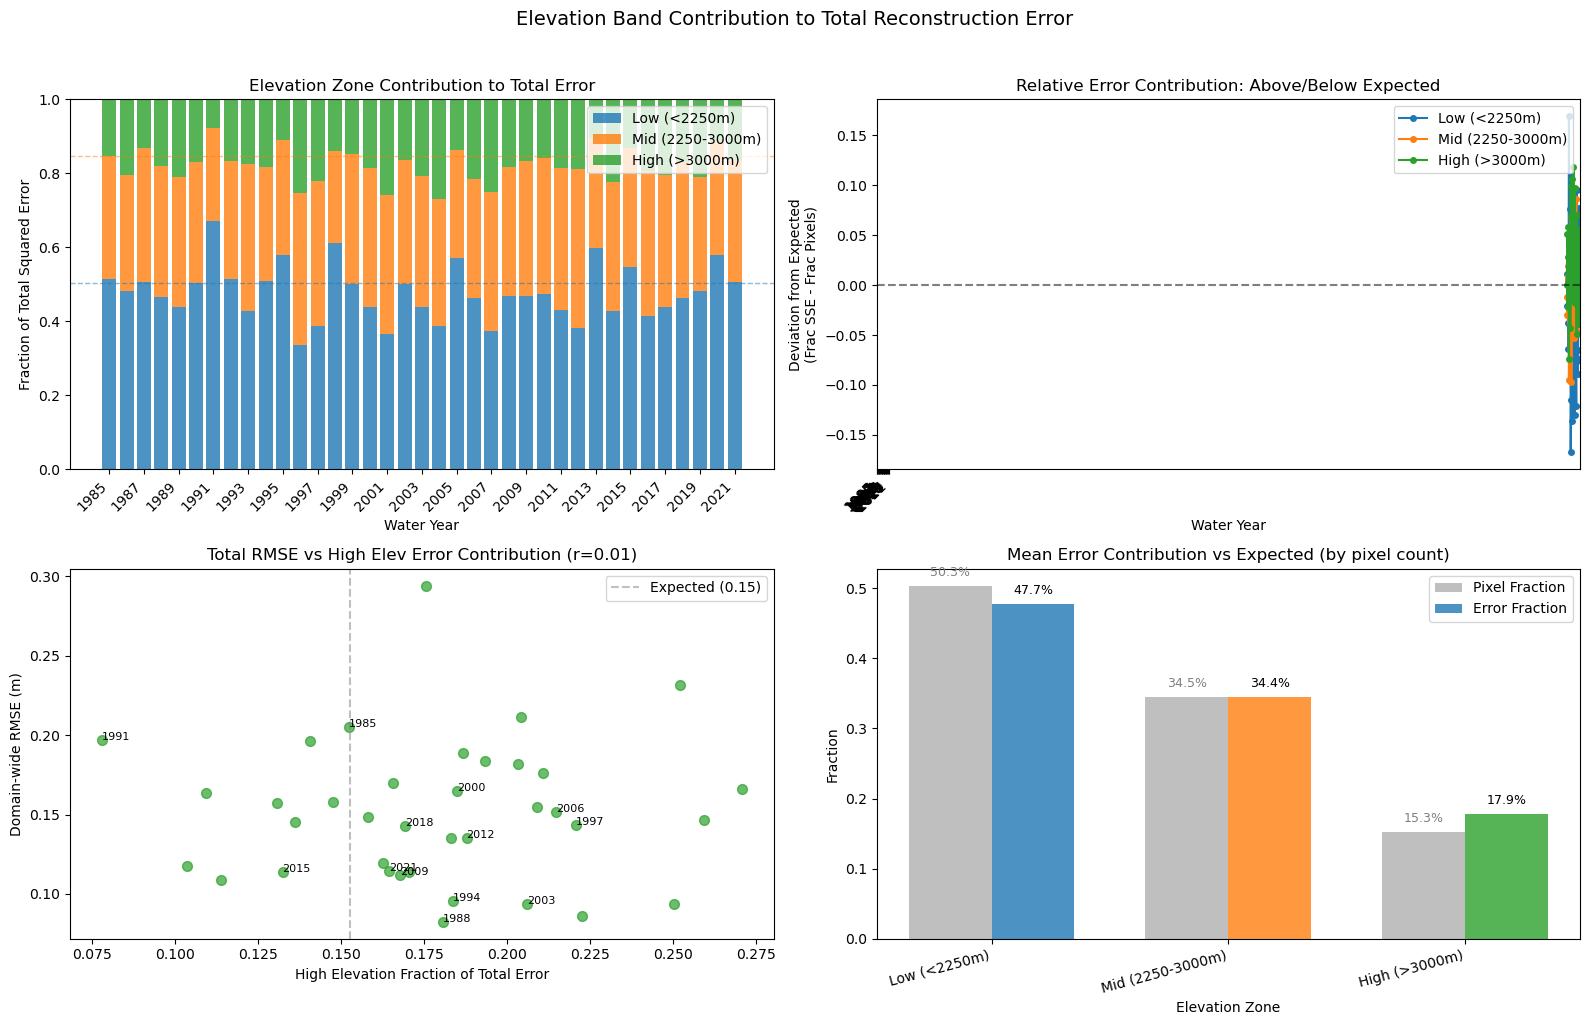


=== Error Contribution vs Expected (by pixel count) ===
Zone                 Pixel Frac   Error Frac   Difference  
Low (<2250m)         50.3%         47.7%         -2.5%
Mid (2250-3000m)     34.5%         34.4%         -0.1%
High (>3000m)        15.3%         17.9%         +2.6%


In [92]:
# === Contribution to Total Error by Elevation Band ===
# Calculate the fraction of total squared error from each elevation zone

# Recalculate with total squared error sums (not just RMSE)
elev_error_contrib = []

for yr_idx, year in enumerate(all_years):
    error_yr = loocv_ds['error'].isel(time=yr_idx).values.flatten()
    
    zone_sse = {}  # Sum of squared errors per zone
    zone_n = {}    # Number of pixels per zone
    
    for zone_name, low_e, high_e in elev_zones:
        zone_mask = (dem_flat >= low_e) & (dem_flat < high_e) & valid_mask
        if zone_mask.sum() > 0:
            zone_sse[zone_name] = np.nansum(error_yr[zone_mask]**2)
            zone_n[zone_name] = zone_mask.sum()
    
    total_sse = sum(zone_sse.values())
    
    for zone_name in [z[0] for z in elev_zones]:
        if zone_name in zone_sse:
            elev_error_contrib.append({
                'water_year': year,
                'zone': zone_name,
                'sse': zone_sse[zone_name],
                'frac_sse': zone_sse[zone_name] / total_sse if total_sse > 0 else 0,
                'n_pixels': zone_n[zone_name],
                'frac_pixels': zone_n[zone_name] / sum(zone_n.values())
            })

contrib_df = pd.DataFrame(elev_error_contrib)

# === Plot: Stacked bars showing fractional contribution to total error ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

years = contrib_df['water_year'].unique()
x = np.arange(len(years))

# 1. Stacked bar: Fraction of total squared error by elevation
ax = axes[0, 0]
bottom = np.zeros(len(years))
for zone_name, color in zip([z[0] for z in elev_zones], zone_colors):
    zone_data = contrib_df[contrib_df['zone'] == zone_name].set_index('water_year')['frac_sse'].reindex(years).fillna(0)
    ax.bar(x, zone_data, bottom=bottom, label=zone_name, color=color, alpha=0.8)
    bottom += zone_data.values

# Add horizontal line for expected contribution based on pixel count
mean_frac_pixels = contrib_df.groupby('zone')['frac_pixels'].mean()
ax.axhline(mean_frac_pixels['Low (<2250m)'], color=zone_colors[0], linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(mean_frac_pixels['Low (<2250m)'] + mean_frac_pixels['Mid (2250-3000m)'], 
           color=zone_colors[1], linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('Water Year')
ax.set_ylabel('Fraction of Total Squared Error')
ax.set_title('Elevation Zone Contribution to Total Error')
ax.set_xticks(x[::2])
ax.set_xticklabels(years[::2], rotation=45, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)

# 2. Deviation from expected contribution
ax = axes[0, 1]
for zone_name, color in zip([z[0] for z in elev_zones], zone_colors):
    zone_data = contrib_df[contrib_df['zone'] == zone_name].set_index('water_year')
    deviation = zone_data['frac_sse'] - zone_data['frac_pixels']
    ax.plot(years, deviation.reindex(years), 'o-', color=color, label=zone_name, markersize=4)

ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Water Year')
ax.set_ylabel('Deviation from Expected\n(Frac SSE - Frac Pixels)')
ax.set_title('Relative Error Contribution: Above/Below Expected')
ax.set_xticks(x[::2])
ax.set_xticklabels(years[::2], rotation=45, ha='right')
ax.legend(loc='upper right')

# 3. Correlation between total error and high-elevation contribution
ax = axes[1, 0]
total_rmse_by_year = error_stats_df.set_index('water_year')['rmse']
high_frac = contrib_df[contrib_df['zone'] == 'High (>3000m)'].set_index('water_year')['frac_sse']

ax.scatter(high_frac, total_rmse_by_year.reindex(high_frac.index), c=zone_colors[2], s=50, alpha=0.7)
for yr in years[::3]:
    ax.annotate(str(yr), (high_frac.loc[yr], total_rmse_by_year.loc[yr]), fontsize=8)

# Add correlation
r, p = pearsonr(high_frac.values, total_rmse_by_year.reindex(high_frac.index).values)
ax.set_xlabel('High Elevation Fraction of Total Error')
ax.set_ylabel('Domain-wide RMSE (m)')
ax.set_title(f'Total RMSE vs High Elev Error Contribution (r={r:.2f})')
ax.axvline(mean_frac_pixels['High (>3000m)'], color='gray', linestyle='--', alpha=0.5, 
           label=f'Expected ({mean_frac_pixels["High (>3000m)"]:.2f})')
ax.legend()

# 4. Summary: Mean contribution vs pixel fraction
ax = axes[1, 1]
mean_frac_sse = contrib_df.groupby('zone')['frac_sse'].mean()
x_pos = np.arange(3)
width = 0.35

bars1 = ax.bar(x_pos - width/2, mean_frac_pixels[[z[0] for z in elev_zones]], width, 
               label='Pixel Fraction', color='gray', alpha=0.5)
bars2 = ax.bar(x_pos + width/2, mean_frac_sse[[z[0] for z in elev_zones]], width, 
               label='Error Fraction', color=[zone_colors[i] for i in range(3)], alpha=0.8)

ax.set_xlabel('Elevation Zone')
ax.set_ylabel('Fraction')
ax.set_title('Mean Error Contribution vs Expected (by pixel count)')
ax.set_xticks(x_pos)
ax.set_xticklabels([z[0] for z in elev_zones], rotation=15, ha='right')
ax.legend()

# Add percentage labels
for bar, val in zip(bars1, mean_frac_pixels[[z[0] for z in elev_zones]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', 
            ha='center', va='bottom', fontsize=9, color='gray')
for bar, val in zip(bars2, mean_frac_sse[[z[0] for z in elev_zones]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.1%}', 
            ha='center', va='bottom', fontsize=9)

plt.suptitle('Elevation Band Contribution to Total Reconstruction Error', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/loocv_error_contribution_by_elevation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n=== Error Contribution vs Expected (by pixel count) ===")
print(f"{'Zone':<20} {'Pixel Frac':<12} {'Error Frac':<12} {'Difference':<12}")
for zone in [z[0] for z in elev_zones]:
    pix = mean_frac_pixels[zone]
    err = mean_frac_sse[zone]
    print(f"{zone:<20} {pix:.1%}         {err:.1%}         {err-pix:+.1%}")